# Jet Engine Hospital — Stage 2: FD003

## Multi-Fault Remaining Useful Life and Maintenance Risk Analysis

This notebook extends the locked FD001 workflow to the NASA C-MAPSS FD003 subset.

FD003 contains one operating condition and two fault modes. The workflow preserves the same leakage-safe contracts used for FD001:

- engine-level train, validation, and internal-test splits;
- causal feature engineering using current and past cycles only;
- validation-only model selection and threshold tuning;
- a single final evaluation on the internal test split;
- official NASA test evaluation using one terminal observation per engine;
- engine-level uncertainty estimation;
- reproducible artifacts and evaluation tables.

### Stage 2 objectives

1. Audit the FD003 dataset and operating conditions.
2. construct leakage-safe temporal features;
3. compare current-cycle and window-based regression models;
4. predict failure risk at 10, 20, and 30-cycle horizons;
5. compare four anomaly-detection approaches;
6. quantify uncertainty with conformal prediction and engine bootstrap;
7. compare FD003 results against the locked FD001 baseline.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Resolve project root.
# ---------------------------------------------------------

candidate_roots = [
    Path.cwd(),
    *Path.cwd().parents,
]

PROJECT_ROOT = next(
    (
        candidate
        for candidate in candidate_roots
        if (
            candidate / "src"
        ).exists()
        and (
            candidate / "data"
        ).exists()
        and (
            candidate / "reports"
        ).exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Project root could not be located. "
        "Run this notebook from the repository root "
        "or the notebooks directory."
    )


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )


# ---------------------------------------------------------
# Project imports.
# ---------------------------------------------------------

from src.config import (
    RANDOM_STATE,
    SPLITS_DIR,
)

from src.data_loading import (
    add_training_targets,
    load_cmapss_subset,
)

from src.data_splitting import (
    apply_engine_splits,
)


# ---------------------------------------------------------
# Output directories.
# ---------------------------------------------------------

TABLES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

MODELS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "models"
)


for directory in [
    TABLES_DIR,
    FIGURES_DIR,
    MODELS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ---------------------------------------------------------
# Required FD003 files.
# ---------------------------------------------------------

required_paths = [
    PROJECT_ROOT
    / "data"
    / "raw"
    / "train_FD003.txt",

    PROJECT_ROOT
    / "data"
    / "raw"
    / "test_FD003.txt",

    PROJECT_ROOT
    / "data"
    / "raw"
    / "RUL_FD003.txt",

    SPLITS_DIR
    / "fd003_engine_splits.json",
]


missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]


if missing_paths:
    raise FileNotFoundError(
        "Required FD003 files are missing:\n"
        + "\n".join(
            str(path)
            for path in missing_paths
        )
    )


pd.set_option(
    "display.max_columns",
    None,
)

pd.set_option(
    "display.width",
    160,
)


print(
    "Project root:",
    PROJECT_ROOT,
)

print(
    "Random state:",
    RANDOM_STATE,
)

print(
    "FD003 setup completed."
)

Project root: c:\Users\User\Desktop\ML\FinalProject
Random state: 42
FD003 setup completed.


## 1. Data Loading and Target Construction

The raw C-MAPSS rows are loaded with explicit engine, cycle, operating-setting, and sensor columns.

For every training observation, remaining useful life is defined as:

\[
RUL_{i,t} = \max(\text{cycle}_i) - t
\]

where \(i\) identifies the engine and \(t\) is the current cycle.

The official test RUL file is kept separate and will be used only for final terminal-observation evaluation.

In [2]:
fd003_train_df, fd003_official_test_df, fd003_official_test_rul_df = (
    load_cmapss_subset(
        "FD003"
    )
)


fd003_train_labeled_df = (
    add_training_targets(
        fd003_train_df
    )
)


assert (
    fd003_train_df[
        "engine_id"
    ].nunique()
    == 100
)

assert (
    fd003_official_test_df[
        "engine_id"
    ].nunique()
    == 100
)

assert len(
    fd003_official_test_rul_df
) == 100

assert (
    fd003_train_labeled_df[
        "RUL"
    ]
    >= 0
).all()


fd003_dataset_summary_df = pd.DataFrame(
    {
        "Dataset": [
            "Training",
            "Official test",
            "Official test RUL",
        ],
        "Rows": [
            len(
                fd003_train_df
            ),
            len(
                fd003_official_test_df
            ),
            len(
                fd003_official_test_rul_df
            ),
        ],
        "Columns": [
            fd003_train_df.shape[1],
            fd003_official_test_df.shape[1],
            fd003_official_test_rul_df.shape[1],
        ],
        "Unique engines": [
            fd003_train_df[
                "engine_id"
            ].nunique(),
            fd003_official_test_df[
                "engine_id"
            ].nunique(),
            len(
                fd003_official_test_rul_df
            ),
        ],
    }
)


fd003_dataset_summary_df.to_csv(
    TABLES_DIR
    / "fd003_dataset_summary.csv",
    index=False,
)


display(
    fd003_dataset_summary_df
)

display(
    fd003_train_labeled_df.head()
)

,Dataset,Rows,Columns,Unique engines
0,Training,24720,26,100
1,Official test,16596,26,100
2,Official test RUL,100,1,100


,engine_id,cycle,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,final_cycle,RUL,failure_within_10,failure_within_20,failure_within_30
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,21.61,553.97,2387.96,9062.17,1.3,47.30,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537,259,258,0,0,0
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,21.61,554.55,2388.00,9061.78,1.3,47.23,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491,259,257,0,0,0
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,21.61,554.43,2388.03,9070.23,1.3,47.22,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669,259,256,0,0,0
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,21.61,555.21,2388.00,9064.57,1.3,47.24,522.49,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951,259,255,0,0,0
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,21.61,554.74,2388.04,9076.14,1.3,47.15,522.58,2388.03,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583,259,254,0,0,0


## 2. Data Quality and Structural Audit

This audit verifies:

- missing and infinite values;
- exact duplicate rows;
- duplicate engine-cycle keys;
- cycle continuity within every engine;
- constant and near-constant features;
- operating-setting variability;
- valid RUL construction.

In [5]:
numeric_train_df = (
    fd003_train_df.select_dtypes(
        include=[
            np.number,
        ]
    )
)


missing_value_count = int(
    fd003_train_df
    .isna()
    .sum()
    .sum()
)

infinite_value_count = int(
    np.isinf(
        numeric_train_df.to_numpy(
            dtype=float
        )
    ).sum()
)

exact_duplicate_count = int(
    fd003_train_df
    .duplicated()
    .sum()
)

duplicate_engine_cycle_count = int(
    fd003_train_df
    .duplicated(
        subset=[
            "engine_id",
            "cycle",
        ]
    )
    .sum()
)


sorted_train_df = (
    fd003_train_df
    .sort_values(
        [
            "engine_id",
            "cycle",
        ]
    )
    .reset_index(drop=True)
)


cycle_differences = (
    sorted_train_df
    .groupby(
        "engine_id",
        sort=False,
    )[
        "cycle"
    ]
    .diff()
    .dropna()
)


cycle_gap_count = int(
    cycle_differences
    .ne(1)
    .sum()
)


feature_unique_counts = (
    fd003_train_df
    .nunique(
        dropna=False
    )
    .sort_values()
)


constant_features = (
    feature_unique_counts.loc[
        feature_unique_counts
        <= 1
    ]
    .index
    .tolist()
)


operating_setting_columns = [
    column
    for column in fd003_train_df.columns
    if column.startswith(
        "operational_setting_"
    )
]


fd003_operating_settings_summary_df = pd.DataFrame(
    {
        "Feature": operating_setting_columns,
        "Unique values": [
            int(
                fd003_train_df[
                    column
                ].nunique()
            )
            for column
            in operating_setting_columns
        ],
        "Minimum": [
            float(
                fd003_train_df[
                    column
                ].min()
            )
            for column
            in operating_setting_columns
        ],
        "Maximum": [
            float(
                fd003_train_df[
                    column
                ].max()
            )
            for column
            in operating_setting_columns
        ],
        "Standard deviation": [
            float(
                fd003_train_df[
                    column
                ].std()
            )
            for column
            in operating_setting_columns
        ],
    }
)


fd003_data_quality_summary_df = pd.DataFrame(
    [
        {
            "Training rows": len(
                fd003_train_df
            ),
            "Training engines": int(
                fd003_train_df[
                    "engine_id"
                ].nunique()
            ),
            "Missing values": (
                missing_value_count
            ),
            "Infinite values": (
                infinite_value_count
            ),
            "Exact duplicate rows": (
                exact_duplicate_count
            ),
            "Duplicate engine-cycle keys": (
                duplicate_engine_cycle_count
            ),
            "Non-unit cycle gaps": (
                cycle_gap_count
            ),
            "Constant feature count": len(
                constant_features
            ),
            "Minimum RUL": float(
                fd003_train_labeled_df[
                    "RUL"
                ].min()
            ),
            "Maximum RUL": float(
                fd003_train_labeled_df[
                    "RUL"
                ].max()
            ),
        }
    ]
)


assert missing_value_count == 0
assert infinite_value_count == 0
assert duplicate_engine_cycle_count == 0
assert cycle_gap_count == 0


fd003_data_quality_summary_df.to_csv(
    TABLES_DIR
    / "fd003_data_quality_summary.csv",
    index=False,
)

fd003_operating_settings_summary_df.to_csv(
    TABLES_DIR
    / "fd003_operating_settings_summary.csv",
    index=False,
)


print(
    "Constant features:"
)

print(
    constant_features
)


display(
    fd003_data_quality_summary_df
)

display(
    fd003_operating_settings_summary_df
)

Constant features:
['sensor_1', 'operational_setting_3', 'sensor_5', 'sensor_18', 'sensor_19', 'sensor_16']


,Training rows,Training engines,Missing values,Infinite values,Exact duplicate rows,Duplicate engine-cycle keys,Non-unit cycle gaps,Constant feature count,Minimum RUL,Maximum RUL
0,24720,100,0,0,0,0,0,6,0.0,524.0


,Feature,Unique values,Minimum,Maximum,Standard deviation
0,operational_setting_1,160,-0.0086,0.0086,0.002194
1,operational_setting_2,14,-0.0006,0.0007,0.000294
2,operational_setting_3,1,100.0000,100.0000,0.000000


## 3. Leakage-Safe Engine-Level Split

All observations belonging to one engine remain in exactly one subset.

The deterministic split contains:

- 70 training engines;
- 15 validation engines;
- 15 internal-test engines.

No preprocessing, feature fitting, model selection, calibration, or threshold selection may use internal-test engines.

In [4]:
fd003_split_path = (
    SPLITS_DIR
    / "fd003_engine_splits.json"
)


with fd003_split_path.open(
    encoding="utf-8",
) as split_file:
    fd003_split_payload = json.load(
        split_file
    )


fd003_engine_splits = (
    fd003_split_payload[
        "engine_ids"
    ]
)


fd003_split_dataframes = (
    apply_engine_splits(
        fd003_train_labeled_df,
        fd003_engine_splits,
    )
)


fd003_train_split_df = (
    fd003_split_dataframes[
        "train"
    ]
)

fd003_validation_split_df = (
    fd003_split_dataframes[
        "validation"
    ]
)

fd003_internal_test_split_df = (
    fd003_split_dataframes[
        "test"
    ]
)


fd003_train_ids = set(
    fd003_engine_splits[
        "train"
    ]
)

fd003_validation_ids = set(
    fd003_engine_splits[
        "validation"
    ]
)

fd003_internal_test_ids = set(
    fd003_engine_splits[
        "test"
    ]
)


assert len(
    fd003_train_ids
) == 70

assert len(
    fd003_validation_ids
) == 15

assert len(
    fd003_internal_test_ids
) == 15

assert not (
    fd003_train_ids
    & fd003_validation_ids
)

assert not (
    fd003_train_ids
    & fd003_internal_test_ids
)

assert not (
    fd003_validation_ids
    & fd003_internal_test_ids
)


fd003_split_summary_df = pd.DataFrame(
    {
        "Split": [
            "Train",
            "Validation",
            "Internal test",
        ],
        "Engines": [
            fd003_train_split_df[
                "engine_id"
            ].nunique(),
            fd003_validation_split_df[
                "engine_id"
            ].nunique(),
            fd003_internal_test_split_df[
                "engine_id"
            ].nunique(),
        ],
        "Rows": [
            len(
                fd003_train_split_df
            ),
            len(
                fd003_validation_split_df
            ),
            len(
                fd003_internal_test_split_df
            ),
        ],
        "Minimum RUL": [
            fd003_train_split_df[
                "RUL"
            ].min(),
            fd003_validation_split_df[
                "RUL"
            ].min(),
            fd003_internal_test_split_df[
                "RUL"
            ].min(),
        ],
        "Maximum RUL": [
            fd003_train_split_df[
                "RUL"
            ].max(),
            fd003_validation_split_df[
                "RUL"
            ].max(),
            fd003_internal_test_split_df[
                "RUL"
            ].max(),
        ],
    }
)


fd003_split_summary_df.to_csv(
    TABLES_DIR
    / "fd003_split_summary.csv",
    index=False,
)


display(
    fd003_split_summary_df
)


print(
    "Train/validation overlap:",
    len(
        fd003_train_ids
        & fd003_validation_ids
    ),
)

print(
    "Train/internal-test overlap:",
    len(
        fd003_train_ids
        & fd003_internal_test_ids
    ),
)

print(
    "Validation/internal-test overlap:",
    len(
        fd003_validation_ids
        & fd003_internal_test_ids
    ),
)

print(
    "FD003 engine-level split audit passed."
)

,Split,Engines,Rows,Minimum RUL,Maximum RUL
0,Train,70,17406,0,493
1,Validation,15,3688,0,524
2,Internal test,15,3626,0,405


Train/validation overlap: 0
Train/internal-test overlap: 0
Validation/internal-test overlap: 0
FD003 engine-level split audit passed.


## 4. Exploratory Data Analysis and Filtering Decisions

This section examines engine sequence lengths, RUL distributions, operating
settings, sensor variability, and degradation relationships.

All filtering decisions are documented explicitly. No observation is removed
from FD003. Only constant input features and non-predictive identifier or target
columns are excluded from model inputs.

In [6]:
from src.feature_engineering import (
    build_time_series_features,
    get_model_feature_columns,
)


# ---------------------------------------------------------
# Identify feature groups.
# ---------------------------------------------------------

fd003_sensor_columns = [
    column
    for column in fd003_train_labeled_df.columns
    if column.startswith(
        "sensor_"
    )
]

fd003_constant_sensor_columns = [
    column
    for column in constant_features
    if column.startswith(
        "sensor_"
    )
]

fd003_candidate_sensor_columns = [
    column
    for column in fd003_sensor_columns
    if column not in constant_features
]

fd003_nonconstant_setting_columns = [
    column
    for column in operating_setting_columns
    if column not in constant_features
]


print(
    "Total sensors:",
    len(fd003_sensor_columns),
)

print(
    "Constant sensors:",
    len(fd003_constant_sensor_columns),
)

print(
    "Candidate sensors:",
    len(fd003_candidate_sensor_columns),
)

print(
    "Non-constant operating settings:",
    fd003_nonconstant_setting_columns,
)


assert len(
    fd003_sensor_columns
) == 21

assert len(
    fd003_constant_sensor_columns
) == 5

assert len(
    fd003_candidate_sensor_columns
) == 16

assert (
    "operational_setting_3"
    in constant_features
)


# ---------------------------------------------------------
# Engine sequence-length summary.
# ---------------------------------------------------------

fd003_engine_length_df = (
    fd003_train_labeled_df
    .groupby(
        "engine_id"
    )
    .size()
    .rename(
        "Sequence length"
    )
    .reset_index()
)


fd003_engine_length_summary_df = pd.DataFrame(
    [
        {
            "Engines": int(
                len(
                    fd003_engine_length_df
                )
            ),
            "Minimum sequence length": int(
                fd003_engine_length_df[
                    "Sequence length"
                ].min()
            ),
            "Median sequence length": float(
                fd003_engine_length_df[
                    "Sequence length"
                ].median()
            ),
            "Mean sequence length": float(
                fd003_engine_length_df[
                    "Sequence length"
                ].mean()
            ),
            "Maximum sequence length": int(
                fd003_engine_length_df[
                    "Sequence length"
                ].max()
            ),
            "Standard deviation": float(
                fd003_engine_length_df[
                    "Sequence length"
                ].std()
            ),
        }
    ]
)


# ---------------------------------------------------------
# RUL summary for all locked splits.
# ---------------------------------------------------------

fd003_rul_distribution_rows = []

for split_name, split_frame in [
    (
        "Train",
        fd003_train_split_df,
    ),
    (
        "Validation",
        fd003_validation_split_df,
    ),
    (
        "Internal test",
        fd003_internal_test_split_df,
    ),
]:
    fd003_rul_distribution_rows.append(
        {
            "Split": split_name,
            "Rows": int(
                len(split_frame)
            ),
            "Engines": int(
                split_frame[
                    "engine_id"
                ].nunique()
            ),
            "Minimum RUL": float(
                split_frame[
                    "RUL"
                ].min()
            ),
            "25% RUL": float(
                split_frame[
                    "RUL"
                ].quantile(
                    0.25
                )
            ),
            "Median RUL": float(
                split_frame[
                    "RUL"
                ].median()
            ),
            "Mean RUL": float(
                split_frame[
                    "RUL"
                ].mean()
            ),
            "75% RUL": float(
                split_frame[
                    "RUL"
                ].quantile(
                    0.75
                )
            ),
            "Maximum RUL": float(
                split_frame[
                    "RUL"
                ].max()
            ),
        }
    )


fd003_rul_distribution_summary_df = pd.DataFrame(
    fd003_rul_distribution_rows
)


# ---------------------------------------------------------
# Sensor statistics and degradation relationships.
# Use training engines only.
# ---------------------------------------------------------

fd003_sensor_statistics_rows = []

for sensor_column in fd003_sensor_columns:
    sensor_series = (
        fd003_train_split_df[
            sensor_column
        ]
    )

    sensor_rul_correlation = (
        fd003_train_split_df[
            [
                sensor_column,
                "RUL",
            ]
        ]
        .corr(
            method="spearman"
        )
        .iloc[
            0,
            1
        ]
    )

    fd003_sensor_statistics_rows.append(
        {
            "Sensor": sensor_column,
            "Unique values": int(
                sensor_series.nunique()
            ),
            "Minimum": float(
                sensor_series.min()
            ),
            "Maximum": float(
                sensor_series.max()
            ),
            "Mean": float(
                sensor_series.mean()
            ),
            "Standard deviation": float(
                sensor_series.std()
            ),
            "Constant": bool(
                sensor_column
                in constant_features
            ),
            "Spearman correlation with RUL": float(
                sensor_rul_correlation
                if pd.notna(
                    sensor_rul_correlation
                )
                else 0.0
            ),
            "Absolute Spearman correlation": float(
                abs(
                    sensor_rul_correlation
                )
                if pd.notna(
                    sensor_rul_correlation
                )
                else 0.0
            ),
        }
    )


fd003_sensor_statistics_df = (
    pd.DataFrame(
        fd003_sensor_statistics_rows
    )
    .sort_values(
        [
            "Constant",
            "Absolute Spearman correlation",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)


fd003_top_sensor_correlations_df = (
    fd003_sensor_statistics_df.loc[
        ~fd003_sensor_statistics_df[
            "Constant"
        ]
    ]
    .head(10)
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# Explicit filtering decisions.
# ---------------------------------------------------------

excluded_identifier_target_columns = [
    "engine_id",
    "final_cycle",
    "RUL",
    "failure_within_10",
    "failure_within_20",
    "failure_within_30",
]


fd003_filtering_decisions_df = pd.DataFrame(
    [
        {
            "Decision": (
                "Remove constant input features"
            ),
            "Removed features": (
                ", ".join(
                    constant_features
                )
            ),
            "Removed feature count": int(
                len(
                    constant_features
                )
            ),
            "Removed rows": 0,
            "Affected engines": 100,
            "Rationale": (
                "Constant features contain no "
                "discriminative information."
            ),
        },
        {
            "Decision": (
                "Exclude identifiers and targets "
                "from model inputs"
            ),
            "Removed features": (
                ", ".join(
                    excluded_identifier_target_columns
                )
            ),
            "Removed feature count": int(
                len(
                    excluded_identifier_target_columns
                )
            ),
            "Removed rows": 0,
            "Affected engines": 100,
            "Rationale": (
                "Identifiers and target columns "
                "must not be used as predictors."
            ),
        },
        {
            "Decision": (
                "Preserve all valid observations"
            ),
            "Removed features": "",
            "Removed feature count": 0,
            "Removed rows": 0,
            "Affected engines": 0,
            "Rationale": (
                "No missing values, duplicate keys, "
                "infinite values, or cycle gaps exist."
            ),
        },
    ]
)


# ---------------------------------------------------------
# Save EDA tables.
# ---------------------------------------------------------

fd003_engine_length_df.to_csv(
    TABLES_DIR
    / "fd003_engine_sequence_lengths.csv",
    index=False,
)

fd003_engine_length_summary_df.to_csv(
    TABLES_DIR
    / "fd003_engine_sequence_length_summary.csv",
    index=False,
)

fd003_rul_distribution_summary_df.to_csv(
    TABLES_DIR
    / "fd003_rul_distribution_summary.csv",
    index=False,
)

fd003_sensor_statistics_df.to_csv(
    TABLES_DIR
    / "fd003_sensor_statistics.csv",
    index=False,
)

fd003_top_sensor_correlations_df.to_csv(
    TABLES_DIR
    / "fd003_top_sensor_correlations.csv",
    index=False,
)

fd003_filtering_decisions_df.to_csv(
    TABLES_DIR
    / "fd003_filtering_decisions.csv",
    index=False,
)


display(
    fd003_engine_length_summary_df
)

display(
    fd003_rul_distribution_summary_df.round(4)
)

display(
    fd003_top_sensor_correlations_df.round(6)
)

display(
    fd003_filtering_decisions_df
)

Total sensors: 21
Constant sensors: 5
Candidate sensors: 16
Non-constant operating settings: ['operational_setting_1', 'operational_setting_2']


,Engines,Minimum sequence length,Median sequence length,Mean sequence length,Maximum sequence length,Standard deviation
0,100,145,220.5,247.2,525,86.48384


,Split,Rows,Engines,Minimum RUL,25% RUL,Median RUL,Mean RUL,75% RUL,Maximum RUL
0,Train,17406,70,0.0,62.0,124.0,138.1746,191.0,493.0
1,Validation,3688,15,0.0,61.0,122.0,145.0033,196.0,524.0
2,Internal test,3626,15,0.0,60.0,120.0,130.5643,183.0,405.0


,Sensor,Unique values,Minimum,Maximum,Mean,Standard deviation,Constant,Spearman correlation with RUL,Absolute Spearman correlation
0,sensor_11,166,46.69,48.43,47.410958,0.298656,False,-0.760545,0.760545
1,sensor_13,160,2387.00,2388.61,2388.073462,0.159346,False,-0.754856,0.754856
2,sensor_8,156,2386.98,2388.60,2388.073186,0.159255,False,-0.753529,0.753529
3,sensor_4,4071,1378.37,1439.98,1404.300259,9.702830,False,-0.723748,0.723748
4,sensor_17,12,388.00,399.00,392.546651,1.758431,False,-0.705292,0.705292
5,sensor_3,3149,1564.30,1615.39,1588.025515,6.779431,False,-0.677599,0.677599
6,sensor_2,325,640.99,645.11,642.450016,0.519406,False,-0.645209,0.645209
7,sensor_9,6258,9017.98,9228.91,9064.171198,20.002022,False,-0.613375,0.613375
8,sensor_14,5644,8099.68,8278.39,8144.311290,16.532584,False,-0.528080,0.528080
9,sensor_10,4,1.29,1.32,1.301328,0.003593,False,-0.460118,0.460118


,Decision,Removed features,Removed feature count,Removed rows,Affected engines,Rationale
0,Remove constant input features,"sensor_1, operational_setting_3, sensor_5, sen...",6,0,100,Constant features contain no discriminative in...
1,Exclude identifiers and targets from model inputs,"engine_id, final_cycle, RUL, failure_within_10...",6,0,100,Identifiers and target columns must not be use...
2,Preserve all valid observations,,0,0,0,"No missing values, duplicate keys, infinite va..."


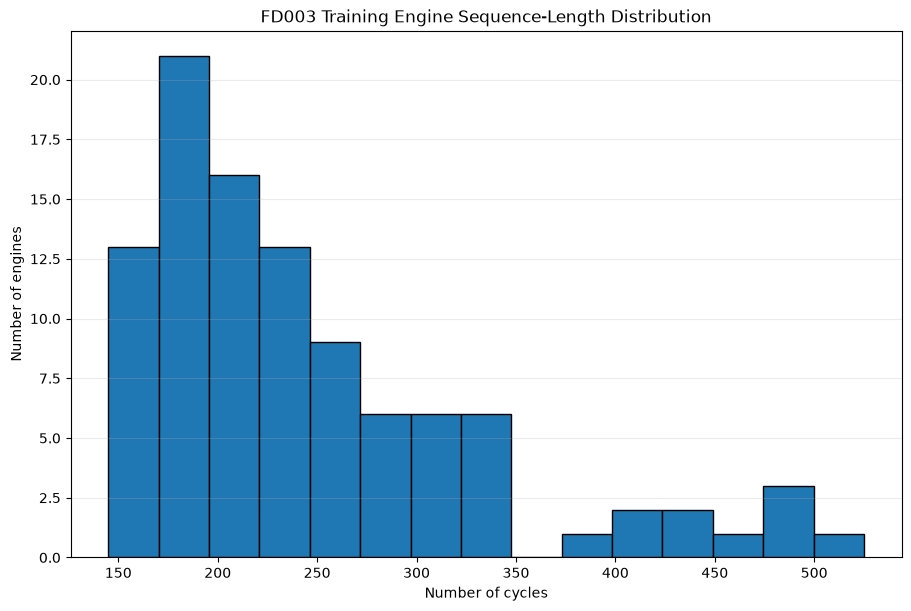

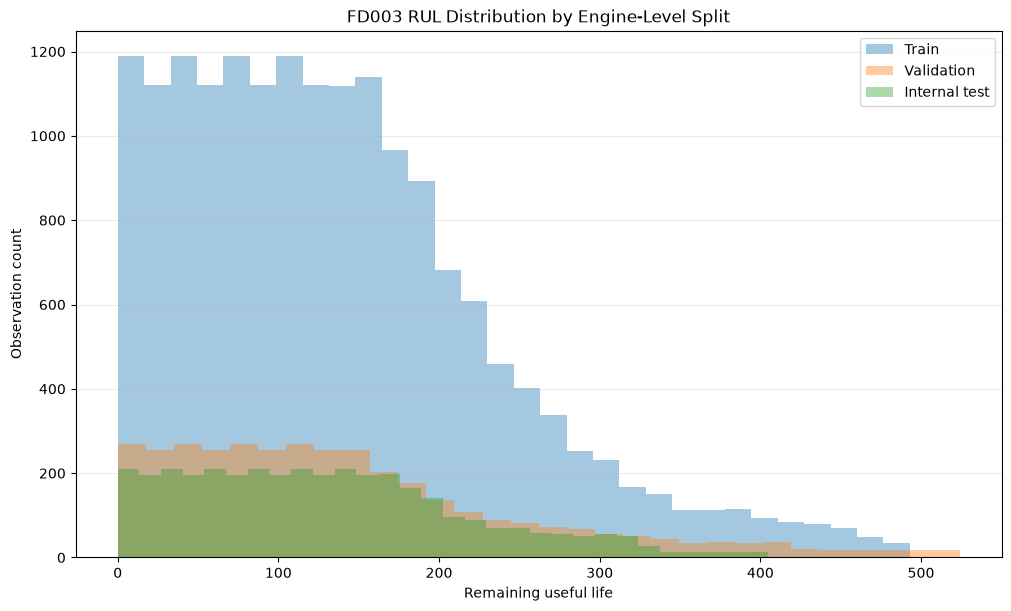

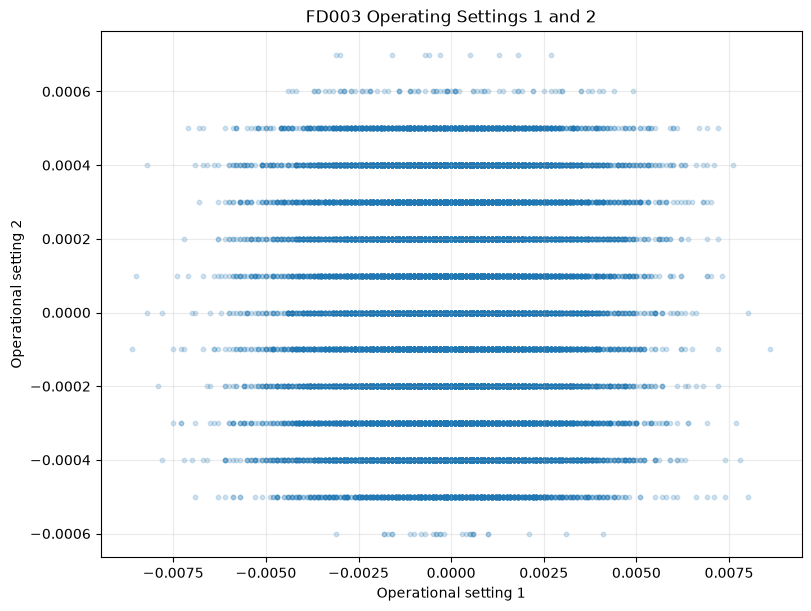

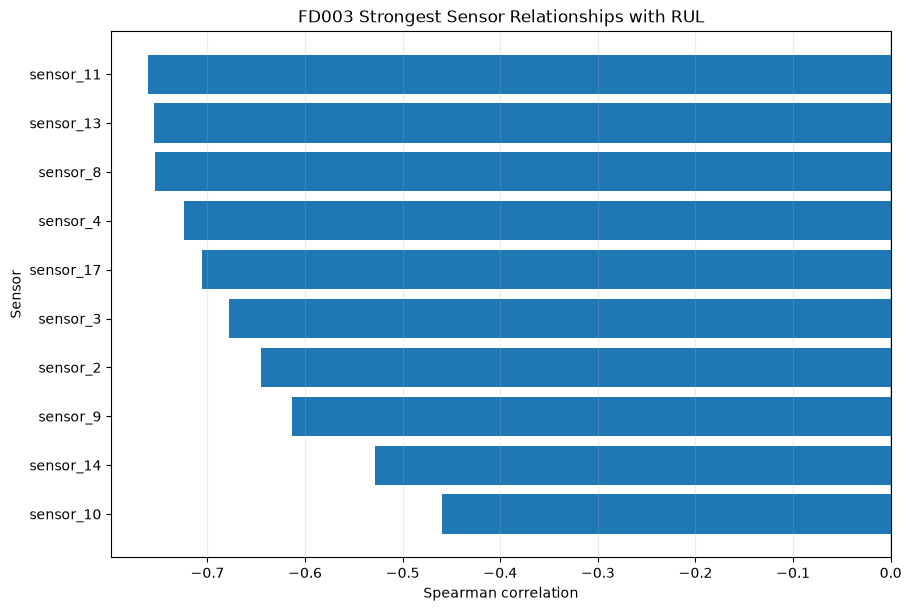

In [7]:
# ---------------------------------------------------------
# Figure 1: engine sequence-length distribution.
# ---------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(9, 6),
    constrained_layout=True,
)

axis.hist(
    fd003_engine_length_df[
        "Sequence length"
    ],
    bins=15,
    edgecolor="black",
)

axis.set_title(
    "FD003 Training Engine Sequence-Length Distribution"
)

axis.set_xlabel(
    "Number of cycles"
)

axis.set_ylabel(
    "Number of engines"
)

axis.grid(
    axis="y",
    alpha=0.25,
)

figure.savefig(
    FIGURES_DIR
    / "fd003_engine_sequence_length_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


# ---------------------------------------------------------
# Figure 2: RUL distribution by split.
# ---------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(10, 6),
    constrained_layout=True,
)

for split_name, split_frame in [
    (
        "Train",
        fd003_train_split_df,
    ),
    (
        "Validation",
        fd003_validation_split_df,
    ),
    (
        "Internal test",
        fd003_internal_test_split_df,
    ),
]:
    axis.hist(
        split_frame[
            "RUL"
        ],
        bins=30,
        alpha=0.40,
        label=split_name,
    )

axis.set_title(
    "FD003 RUL Distribution by Engine-Level Split"
)

axis.set_xlabel(
    "Remaining useful life"
)

axis.set_ylabel(
    "Observation count"
)

axis.legend()

axis.grid(
    axis="y",
    alpha=0.25,
)

figure.savefig(
    FIGURES_DIR
    / "fd003_rul_distribution_by_split.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


# ---------------------------------------------------------
# Figure 3: operating-condition distribution.
# ---------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(8, 6),
    constrained_layout=True,
)

axis.scatter(
    fd003_train_df[
        "operational_setting_1"
    ],
    fd003_train_df[
        "operational_setting_2"
    ],
    s=10,
    alpha=0.20,
)

axis.set_title(
    "FD003 Operating Settings 1 and 2"
)

axis.set_xlabel(
    "Operational setting 1"
)

axis.set_ylabel(
    "Operational setting 2"
)

axis.grid(
    alpha=0.25,
)

figure.savefig(
    FIGURES_DIR
    / "fd003_operating_settings_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)


# ---------------------------------------------------------
# Figure 4: strongest sensor-RUL relationships.
# ---------------------------------------------------------

correlation_plot_df = (
    fd003_top_sensor_correlations_df
    .sort_values(
        "Absolute Spearman correlation",
        ascending=True,
    )
)

figure, axis = plt.subplots(
    figsize=(9, 6),
    constrained_layout=True,
)

axis.barh(
    correlation_plot_df[
        "Sensor"
    ],
    correlation_plot_df[
        "Spearman correlation with RUL"
    ],
)

axis.axvline(
    0.0,
    linewidth=1.0,
)

axis.set_title(
    "FD003 Strongest Sensor Relationships with RUL"
)

axis.set_xlabel(
    "Spearman correlation"
)

axis.set_ylabel(
    "Sensor"
)

axis.grid(
    axis="x",
    alpha=0.25,
)

figure.savefig(
    FIGURES_DIR
    / "fd003_sensor_rul_correlations.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)

## 5. Explicit Temporal Causality Test

A valid temporal feature at cycle \(t\) must depend only on observations from
cycles \(1,\ldots,t\).

The test below verifies two equivalent contracts:

1. Removing all observations after a selected cutoff does not change features
   at or before the cutoff.
2. Arbitrarily corrupting all future sensor readings does not change features
   at or before the cutoff.

In [8]:
# ---------------------------------------------------------
# Select a representative training engine.
# ---------------------------------------------------------

fd003_train_engine_lengths = (
    fd003_train_split_df
    .groupby(
        "engine_id"
    )
    .size()
    .sort_values()
)


eligible_engine_lengths = (
    fd003_train_engine_lengths.loc[
        fd003_train_engine_lengths
        >= 100
    ]
)


if eligible_engine_lengths.empty:
    raise RuntimeError(
        "No sufficiently long engine was available "
        "for the causality test."
    )


causality_engine_id = int(
    eligible_engine_lengths.index[
        len(
            eligible_engine_lengths
        )
        // 2
    ]
)


causality_engine_df = (
    fd003_train_split_df.loc[
        fd003_train_split_df[
            "engine_id"
        ]
        .eq(
            causality_engine_id
        )
    ]
    .sort_values(
        "cycle"
    )
    .reset_index(drop=True)
)


causality_cutoff_position = (
    len(
        causality_engine_df
    )
    // 2
)

causality_cutoff_cycle = int(
    causality_engine_df.iloc[
        causality_cutoff_position
    ][
        "cycle"
    ]
)


print(
    "Causality-test engine:",
    causality_engine_id,
)

print(
    "Engine rows:",
    len(
        causality_engine_df
    ),
)

print(
    "Cutoff cycle:",
    causality_cutoff_cycle,
)


# ---------------------------------------------------------
# Version A: complete original trajectory.
# ---------------------------------------------------------

causality_full_features_df = (
    build_time_series_features(
        causality_engine_df.copy(),
        sensor_columns=(
            fd003_candidate_sensor_columns
        ),
    )
)


# ---------------------------------------------------------
# Version B: truncate the trajectory at the cutoff.
# ---------------------------------------------------------

causality_prefix_input_df = (
    causality_engine_df.loc[
        causality_engine_df[
            "cycle"
        ]
        <= causality_cutoff_cycle
    ]
    .copy()
)


causality_prefix_features_df = (
    build_time_series_features(
        causality_prefix_input_df,
        sensor_columns=(
            fd003_candidate_sensor_columns
        ),
    )
)


# ---------------------------------------------------------
# Version C: corrupt every future sensor observation.
# ---------------------------------------------------------

causality_perturbed_input_df = (
    causality_engine_df.copy()
)


future_row_mask = (
    causality_perturbed_input_df[
        "cycle"
    ]
    > causality_cutoff_cycle
)


for sensor_index, sensor_column in enumerate(
    fd003_candidate_sensor_columns,
    start=1,
):
    causality_perturbed_input_df.loc[
        future_row_mask,
        sensor_column,
    ] = (
        causality_perturbed_input_df.loc[
            future_row_mask,
            sensor_column,
        ]
        + sensor_index
        * 1_000_000.0
    )


causality_perturbed_features_df = (
    build_time_series_features(
        causality_perturbed_input_df,
        sensor_columns=(
            fd003_candidate_sensor_columns
        ),
    )
)


# ---------------------------------------------------------
# Compare model features at and before the cutoff.
# ---------------------------------------------------------

causality_model_feature_columns = (
    get_model_feature_columns(
        causality_full_features_df,
        constant_features=(
            constant_features
        ),
    )
)


full_prefix_features_df = (
    causality_full_features_df.loc[
        causality_full_features_df[
            "cycle"
        ]
        <= causality_cutoff_cycle,
        causality_model_feature_columns,
    ]
    .reset_index(drop=True)
)


truncated_prefix_features_df = (
    causality_prefix_features_df[
        causality_model_feature_columns
    ]
    .reset_index(drop=True)
)


perturbed_prefix_features_df = (
    causality_perturbed_features_df.loc[
        causality_perturbed_features_df[
            "cycle"
        ]
        <= causality_cutoff_cycle,
        causality_model_feature_columns,
    ]
    .reset_index(drop=True)
)


assert (
    full_prefix_features_df.shape
    == truncated_prefix_features_df.shape
)

assert (
    full_prefix_features_df.shape
    == perturbed_prefix_features_df.shape
)


truncation_max_difference = float(
    np.max(
        np.abs(
            full_prefix_features_df.to_numpy(
                dtype=float
            )
            - truncated_prefix_features_df.to_numpy(
                dtype=float
            )
        )
    )
)


perturbation_max_difference = float(
    np.max(
        np.abs(
            full_prefix_features_df.to_numpy(
                dtype=float
            )
            - perturbed_prefix_features_df.to_numpy(
                dtype=float
            )
        )
    )
)


np.testing.assert_allclose(
    full_prefix_features_df,
    truncated_prefix_features_df,
    rtol=0.0,
    atol=1e-12,
)


np.testing.assert_allclose(
    full_prefix_features_df,
    perturbed_prefix_features_df,
    rtol=0.0,
    atol=1e-12,
)


fd003_causality_test_summary_df = pd.DataFrame(
    [
        {
            "Engine ID": (
                causality_engine_id
            ),
            "Engine rows": int(
                len(
                    causality_engine_df
                )
            ),
            "Cutoff cycle": (
                causality_cutoff_cycle
            ),
            "Compared prefix rows": int(
                len(
                    full_prefix_features_df
                )
            ),
            "Compared feature columns": int(
                len(
                    causality_model_feature_columns
                )
            ),
            "Maximum difference after truncation": (
                truncation_max_difference
            ),
            "Maximum difference after future perturbation": (
                perturbation_max_difference
            ),
            "Causality test passed": True,
        }
    ]
)


fd003_causality_test_summary_df.to_csv(
    TABLES_DIR
    / "fd003_causality_test_summary.csv",
    index=False,
)


display(
    fd003_causality_test_summary_df
)

print(
    "FD003 TEMPORAL CAUSALITY TEST PASSED"
)

Causality-test engine: 29
Engine rows: 223
Cutoff cycle: 112


,Engine ID,Engine rows,Cutoff cycle,Compared prefix rows,Compared feature columns,Maximum difference after truncation,Maximum difference after future perturbation,Causality test passed
0,29,223,112,112,147,0.0,0.0,True


FD003 TEMPORAL CAUSALITY TEST PASSED


## 6. Leakage-Safe Temporal Features

Causal temporal features are generated independently inside each engine and
inside each locked split. No rolling window crosses an engine or split
boundary.

Two feature representations are retained for a fair comparison:

1. **Current-cycle features:** cycle, non-constant operating settings, and
   current sensor measurements.
2. **Temporal features:** the current-cycle variables plus causal lag
   differences and trailing-window statistics.

The internal-test features are constructed deterministically but are not used
for model selection or hyperparameter tuning.

In [9]:
from time import perf_counter

from src.regression import (
    evaluate_regression,
    evaluate_rul_regions,
    make_dummy_regressor,
    make_gradient_boosting_regressor,
    make_polynomial_ridge_regressor,
    make_random_forest_regressor,
    make_ridge_regressor,
)

In [10]:
# ---------------------------------------------------------
# Build causal temporal features independently by split.
# ---------------------------------------------------------

fd003_train_features_df = (
    build_time_series_features(
        fd003_train_split_df,
        sensor_columns=(
            fd003_candidate_sensor_columns
        ),
    )
)

fd003_validation_features_df = (
    build_time_series_features(
        fd003_validation_split_df,
        sensor_columns=(
            fd003_candidate_sensor_columns
        ),
    )
)

fd003_internal_test_features_df = (
    build_time_series_features(
        fd003_internal_test_split_df,
        sensor_columns=(
            fd003_candidate_sensor_columns
        ),
    )
)


# ---------------------------------------------------------
# Resolve the final temporal model feature schema.
# ---------------------------------------------------------

fd003_temporal_feature_columns = (
    get_model_feature_columns(
        fd003_train_features_df,
        constant_features=(
            constant_features
        ),
    )
)


# Current-cycle representation.
fd003_current_cycle_feature_columns = [
    "cycle",
    *fd003_nonconstant_setting_columns,
    *fd003_candidate_sensor_columns,
]


# ---------------------------------------------------------
# Feature-schema contracts.
# ---------------------------------------------------------

assert len(
    fd003_current_cycle_feature_columns
) == 19

assert len(
    fd003_temporal_feature_columns
) > len(
    fd003_current_cycle_feature_columns
)

assert set(
    fd003_current_cycle_feature_columns
).issubset(
    fd003_temporal_feature_columns
)

for feature_column in (
    fd003_temporal_feature_columns
):
    assert (
        feature_column
        in fd003_validation_features_df.columns
    )

    assert (
        feature_column
        in fd003_internal_test_features_df.columns
    )


# Feature construction must not remove rows.
assert len(
    fd003_train_features_df
) == len(
    fd003_train_split_df
)

assert len(
    fd003_validation_features_df
) == len(
    fd003_validation_split_df
)

assert len(
    fd003_internal_test_features_df
) == len(
    fd003_internal_test_split_df
)


# ---------------------------------------------------------
# Finite-value audit.
# ---------------------------------------------------------

for split_name, feature_frame in [
    (
        "Train",
        fd003_train_features_df,
    ),
    (
        "Validation",
        fd003_validation_features_df,
    ),
    (
        "Internal test",
        fd003_internal_test_features_df,
    ),
]:
    model_values = feature_frame[
        fd003_temporal_feature_columns
    ].to_numpy(
        dtype=float
    )

    missing_count = int(
        np.isnan(
            model_values
        ).sum()
    )

    infinite_count = int(
        np.isinf(
            model_values
        ).sum()
    )

    assert missing_count == 0, (
        f"{split_name} contains missing "
        "model features."
    )

    assert infinite_count == 0, (
        f"{split_name} contains infinite "
        "model features."
    )


# ---------------------------------------------------------
# First-cycle delta contract.
# ---------------------------------------------------------

fd003_delta_columns = [
    column
    for column
    in fd003_train_features_df.columns
    if "_delta_" in column
]

fd003_first_engine_rows_df = (
    fd003_train_features_df
    .sort_values(
        [
            "engine_id",
            "cycle",
        ]
    )
    .groupby(
        "engine_id",
        as_index=False,
        sort=False,
    )
    .head(1)
)


maximum_first_cycle_delta = float(
    fd003_first_engine_rows_df[
        fd003_delta_columns
    ]
    .abs()
    .to_numpy(
        dtype=float
    )
    .max()
)


assert np.isclose(
    maximum_first_cycle_delta,
    0.0,
    atol=1e-12,
)


# ---------------------------------------------------------
# Save feature audit.
# ---------------------------------------------------------

fd003_feature_engineering_summary_df = pd.DataFrame(
    [
        {
            "Train rows": len(
                fd003_train_features_df
            ),
            "Validation rows": len(
                fd003_validation_features_df
            ),
            "Internal-test rows": len(
                fd003_internal_test_features_df
            ),
            "Current-cycle feature count": len(
                fd003_current_cycle_feature_columns
            ),
            "Temporal feature count": len(
                fd003_temporal_feature_columns
            ),
            "Generated temporal features": (
                len(
                    fd003_temporal_feature_columns
                )
                - len(
                    fd003_current_cycle_feature_columns
                )
            ),
            "Delta feature count": len(
                fd003_delta_columns
            ),
            "Maximum first-cycle delta": (
                maximum_first_cycle_delta
            ),
            "Missing model features": 0,
            "Infinite model features": 0,
            "Causality test passed": True,
        }
    ]
)


fd003_model_feature_schema_df = pd.DataFrame(
    {
        "Feature": (
            fd003_temporal_feature_columns
        ),
        "Current-cycle feature": [
            feature
            in fd003_current_cycle_feature_columns
            for feature
            in fd003_temporal_feature_columns
        ],
        "Temporal-derived feature": [
            feature
            not in fd003_current_cycle_feature_columns
            for feature
            in fd003_temporal_feature_columns
        ],
    }
)


fd003_feature_engineering_summary_df.to_csv(
    TABLES_DIR
    / "fd003_feature_engineering_summary.csv",
    index=False,
)

fd003_model_feature_schema_df.to_csv(
    TABLES_DIR
    / "fd003_model_feature_schema.csv",
    index=False,
)


print(
    "FD003 temporal features created."
)

print(
    "Train shape:",
    fd003_train_features_df.shape,
)

print(
    "Validation shape:",
    fd003_validation_features_df.shape,
)

print(
    "Internal-test shape:",
    fd003_internal_test_features_df.shape,
)


display(
    fd003_feature_engineering_summary_df
)

display(
    fd003_model_feature_schema_df.head(20)
)

FD003 temporal features created.
Train shape: (17406, 159)
Validation shape: (3688, 159)
Internal-test shape: (3626, 159)


,Train rows,Validation rows,Internal-test rows,Current-cycle feature count,Temporal feature count,Generated temporal features,Delta feature count,Maximum first-cycle delta,Missing model features,Infinite model features,Causality test passed
0,17406,3688,3626,19,147,128,32,0.0,0,0,True


,Feature,Current-cycle feature,Temporal-derived feature
0,cycle,True,False
1,operational_setting_1,True,False
2,operational_setting_2,True,False
3,sensor_2,True,False
4,sensor_3,True,False
5,sensor_4,True,False
6,sensor_6,True,False
7,sensor_7,True,False
8,sensor_8,True,False
9,sensor_9,True,False


## 7. RUL Regression — Validation Model Comparison

The following model families are compared only on the validation engines:

- dummy mean baseline;
- Ridge regression with current-cycle features;
- Polynomial Ridge with current-cycle features;
- Ridge regression with temporal features;
- Random Forest with temporal features;
- Gradient Boosting with temporal features.

Negative RUL predictions are clipped to zero. The maintenance-oriented NASA
Score is the primary ranking metric, followed by RMSE.

In [11]:
# ---------------------------------------------------------
# Current-cycle matrices.
# ---------------------------------------------------------

fd003_X_train_current = (
    fd003_train_features_df[
        fd003_current_cycle_feature_columns
    ]
)

fd003_X_validation_current = (
    fd003_validation_features_df[
        fd003_current_cycle_feature_columns
    ]
)


# ---------------------------------------------------------
# Temporal matrices.
# ---------------------------------------------------------

fd003_X_train_temporal = (
    fd003_train_features_df[
        fd003_temporal_feature_columns
    ]
)

fd003_X_validation_temporal = (
    fd003_validation_features_df[
        fd003_temporal_feature_columns
    ]
)


# ---------------------------------------------------------
# Targets.
# ---------------------------------------------------------

fd003_y_train = (
    fd003_train_features_df[
        "RUL"
    ]
)

fd003_y_validation = (
    fd003_validation_features_df[
        "RUL"
    ]
)


assert len(
    fd003_X_train_current
) == len(
    fd003_y_train
)

assert len(
    fd003_X_validation_current
) == len(
    fd003_y_validation
)

assert (
    fd003_X_train_current.columns.tolist()
    == fd003_X_validation_current.columns.tolist()
)

assert (
    fd003_X_train_temporal.columns.tolist()
    == fd003_X_validation_temporal.columns.tolist()
)


print(
    "Current-cycle train matrix:",
    fd003_X_train_current.shape,
)

print(
    "Temporal train matrix:",
    fd003_X_train_temporal.shape,
)

print(
    "Validation target:",
    fd003_y_validation.shape,
)

Current-cycle train matrix: (17406, 19)
Temporal train matrix: (17406, 147)
Validation target: (3688,)


In [12]:
fd003_regression_experiments = [
    {
        "name": "Dummy Mean",
        "feature_configuration": (
            "Current cycle"
        ),
        "model": (
            make_dummy_regressor()
        ),
        "X_train": (
            fd003_X_train_current
        ),
        "X_validation": (
            fd003_X_validation_current
        ),
    },
    {
        "name": "Ridge — Current Cycle",
        "feature_configuration": (
            "Current cycle"
        ),
        "model": (
            make_ridge_regressor(
                alpha=1.0
            )
        ),
        "X_train": (
            fd003_X_train_current
        ),
        "X_validation": (
            fd003_X_validation_current
        ),
    },
    {
        "name": (
            "Polynomial Ridge — Current Cycle"
        ),
        "feature_configuration": (
            "Current cycle"
        ),
        "model": (
            make_polynomial_ridge_regressor(
                degree=2,
                alpha=10.0,
            )
        ),
        "X_train": (
            fd003_X_train_current
        ),
        "X_validation": (
            fd003_X_validation_current
        ),
    },
    {
        "name": "Ridge — Temporal",
        "feature_configuration": (
            "Temporal"
        ),
        "model": (
            make_ridge_regressor(
                alpha=1.0
            )
        ),
        "X_train": (
            fd003_X_train_temporal
        ),
        "X_validation": (
            fd003_X_validation_temporal
        ),
    },
    {
        "name": (
            "Random Forest — Temporal"
        ),
        "feature_configuration": (
            "Temporal"
        ),
        "model": (
            make_random_forest_regressor()
        ),
        "X_train": (
            fd003_X_train_temporal
        ),
        "X_validation": (
            fd003_X_validation_temporal
        ),
    },
    {
        "name": (
            "Gradient Boosting — Temporal"
        ),
        "feature_configuration": (
            "Temporal"
        ),
        "model": (
            make_gradient_boosting_regressor()
        ),
        "X_train": (
            fd003_X_train_temporal
        ),
        "X_validation": (
            fd003_X_validation_temporal
        ),
    },
]


fd003_validation_regression_rows = []

fd003_validation_regression_predictions = {}

fd003_validation_regression_models = {}


for experiment in (
    fd003_regression_experiments
):
    model_name = experiment[
        "name"
    ]

    model = experiment[
        "model"
    ]

    print(
        "Training:",
        model_name,
    )


    fit_start = perf_counter()

    model.fit(
        experiment[
            "X_train"
        ],
        fd003_y_train,
    )

    fit_seconds = (
        perf_counter()
        - fit_start
    )


    prediction_start = perf_counter()

    predictions = model.predict(
        experiment[
            "X_validation"
        ]
    )

    prediction_seconds = (
        perf_counter()
        - prediction_start
    )


    predictions = np.clip(
        predictions,
        a_min=0.0,
        a_max=None,
    )


    metrics = evaluate_regression(
        model_name=model_name,
        y_true=(
            fd003_y_validation
        ),
        y_pred=predictions,
    )


    metrics[
        "Feature configuration"
    ] = experiment[
        "feature_configuration"
    ]

    metrics[
        "Feature count"
    ] = int(
        experiment[
            "X_train"
        ].shape[1]
    )

    metrics[
        "Fit time (seconds)"
    ] = float(
        fit_seconds
    )

    metrics[
        "Prediction ms per 1000 rows"
    ] = float(
        prediction_seconds
        * 1_000_000.0
        / len(
            predictions
        )
    )


    fd003_validation_regression_rows.append(
        metrics
    )

    fd003_validation_regression_predictions[
        model_name
    ] = predictions

    fd003_validation_regression_models[
        model_name
    ] = model


print(
    "FD003 validation regression "
    "comparison completed."
)


fd003_validation_regression_results_df = (
    pd.DataFrame(
        fd003_validation_regression_rows
    )
    .sort_values(
        by=[
            "NASA Score",
            "RMSE",
        ],
        ascending=True,
    )
    .reset_index(
        drop=True
    )
)


fd003_best_validation_model_name = str(
    fd003_validation_regression_results_df
    .iloc[0][
        "Model"
    ]
)


print()
print(
    "Best validation model:",
    fd003_best_validation_model_name,
)


fd003_validation_regression_results_df.to_csv(
    TABLES_DIR
    / "fd003_validation_regression_results.csv",
    index=False,
)


display(
    fd003_validation_regression_results_df
    .round(6)
)

Training: Dummy Mean
Training: Ridge — Current Cycle
Training: Polynomial Ridge — Current Cycle
Training: Ridge — Temporal
Training: Random Forest — Temporal
Training: Gradient Boosting — Temporal
FD003 validation regression comparison completed.

Best validation model: Ridge — Current Cycle


,Model,MAE,RMSE,R2,NASA Score,Near-failure MAE,Late prediction rate,Feature configuration,Feature count,Fit time (seconds),Prediction ms per 1000 rows
0,Ridge — Current Cycle,51.618535,66.479234,0.641430,1.622397e+09,18.287255,0.549892,Current cycle,19,0.080122,2.581426
1,Polynomial Ridge — Current Cycle,50.748667,65.077696,0.656389,3.109235e+09,14.426930,0.596800,Current cycle,19,0.826446,20.830667
2,Random Forest — Temporal,42.420465,63.351058,0.674381,5.401314e+09,4.847852,0.533351,Temporal,147,53.511608,59.410548
3,Ridge — Temporal,49.250355,64.872745,0.658550,8.053524e+09,16.546052,0.545011,Temporal,147,0.744112,13.735060
4,Gradient Boosting — Temporal,45.305783,66.438013,0.641874,1.305836e+11,9.255812,0.570228,Temporal,147,157.861455,8.597478
5,Dummy Mean,85.043968,111.229219,-0.003783,1.047362e+14,123.174595,0.565347,Current cycle,19,2.255712,0.333758


In [13]:
fd003_validation_regional_rows = []


for model_name, predictions in (
    fd003_validation_regression_predictions.items()
):
    model_regional_rows = (
        evaluate_rul_regions(
            model_name=model_name,
            y_true=(
                fd003_y_validation
            ),
            y_pred=predictions,
        )
    )

    fd003_validation_regional_rows.extend(
        model_regional_rows
    )


fd003_validation_regional_results_df = (
    pd.DataFrame(
        fd003_validation_regional_rows
    )
    .sort_values(
        by=[
            "Region",
            "MAE",
        ],
        ascending=True,
    )
    .reset_index(
        drop=True
    )
)


fd003_validation_regional_results_df.to_csv(
    TABLES_DIR
    / "fd003_validation_regression_regions.csv",
    index=False,
)


display(
    fd003_validation_regional_results_df
    .round(6)
)

,Model,Region,Samples,MAE,RMSE,Bias
0,Ridge — Temporal,Early life: RUL > 125,1798,62.529671,80.022539,-30.201850
1,Ridge — Current Cycle,Early life: RUL > 125,1798,62.788433,79.029848,-30.762706
2,Random Forest — Temporal,Early life: RUL > 125,1798,63.170748,83.144450,-36.698247
3,Polynomial Ridge — Current Cycle,Early life: RUL > 125,1798,65.840840,80.139636,-25.990815
4,Gradient Boosting — Temporal,Early life: RUL > 125,1798,66.278434,87.366312,-30.991485
5,Dummy Mean,Early life: RUL > 125,1798,94.892753,134.039742,-93.553436
6,Random Forest — Temporal,Mid life: RUL 31–125,1425,28.499241,40.478880,21.306928
7,Gradient Boosting — Temporal,Mid life: RUL 31–125,1425,30.607125,41.779834,24.337956
8,Ridge — Temporal,Mid life: RUL 31–125,1425,43.167051,51.346718,30.932354
9,Polynomial Ridge — Current Cycle,Mid life: RUL 31–125,1425,43.558408,52.254667,38.825320


## 8. Validation Error Diagnostics

The validation results reveal a trade-off between average regression accuracy
and maintenance-oriented asymmetric risk.

Temporal tree models reduce MAE and near-failure error, but a small number of
large RUL overestimations can dominate the exponential NASA Score. Therefore,
model selection must inspect:

- systematic prediction bias;
- the frequency and magnitude of RUL overestimation;
- engine-level NASA penalties;
- the worst safety-critical validation predictions.

The internal-test split remains untouched.

In [14]:
# ---------------------------------------------------------
# Validation error diagnostics for every baseline model.
# ---------------------------------------------------------

fd003_validation_identity_df = (
    fd003_validation_features_df[
        [
            "engine_id",
            "cycle",
            "RUL",
        ]
    ]
    .reset_index(drop=True)
    .copy()
)


fd003_validation_error_summary_rows = []
fd003_validation_worst_overprediction_rows = []
fd003_validation_per_engine_rows = []


for model_name, predictions in (
    fd003_validation_regression_predictions.items()
):
    predictions = np.asarray(
        predictions,
        dtype=float,
    )

    actual_rul = (
        fd003_y_validation
        .to_numpy(
            dtype=float
        )
    )

    residuals = (
        predictions
        - actual_rul
    )

    absolute_errors = np.abs(
        residuals
    )

    model_metrics = evaluate_regression(
        model_name=model_name,
        y_true=actual_rul,
        y_pred=predictions,
    )


    fd003_validation_error_summary_rows.append(
        {
            "Model": model_name,
            "Samples": int(
                len(
                    actual_rul
                )
            ),
            "MAE": float(
                model_metrics[
                    "MAE"
                ]
            ),
            "RMSE": float(
                model_metrics[
                    "RMSE"
                ]
            ),
            "R2": float(
                model_metrics[
                    "R2"
                ]
            ),
            "NASA Score": float(
                model_metrics[
                    "NASA Score"
                ]
            ),
            "Near-failure MAE": float(
                model_metrics[
                    "Near-failure MAE"
                ]
            ),
            "Mean residual": float(
                residuals.mean()
            ),
            "Median residual": float(
                np.median(
                    residuals
                )
            ),
            "Late-prediction rate": float(
                (
                    residuals > 0.0
                ).mean()
            ),
            "Mean overprediction": float(
                residuals[
                    residuals > 0.0
                ].mean()
                if (
                    residuals > 0.0
                ).any()
                else 0.0
            ),
            "P95 overprediction": float(
                np.quantile(
                    residuals[
                        residuals > 0.0
                    ],
                    0.95,
                )
                if (
                    residuals > 0.0
                ).any()
                else 0.0
            ),
            "Maximum overprediction": float(
                residuals.max()
            ),
            "Maximum underprediction magnitude": float(
                abs(
                    residuals.min()
                )
            ),
            "P90 absolute error": float(
                np.quantile(
                    absolute_errors,
                    0.90,
                )
            ),
            "Maximum absolute error": float(
                absolute_errors.max()
            ),
        }
    )


    model_error_df = (
        fd003_validation_identity_df.copy()
    )

    model_error_df[
        "Model"
    ] = model_name

    model_error_df[
        "Predicted RUL"
    ] = predictions

    model_error_df[
        "Residual"
    ] = residuals

    model_error_df[
        "Absolute error"
    ] = absolute_errors


    model_worst_overpredictions_df = (
        model_error_df.loc[
            model_error_df[
                "Residual"
            ]
            > 0.0
        ]
        .sort_values(
            [
                "Residual",
                "engine_id",
                "cycle",
            ],
            ascending=[
                False,
                True,
                True,
            ],
        )
        .head(20)
    )


    fd003_validation_worst_overprediction_rows.extend(
        model_worst_overpredictions_df
        .to_dict(
            orient="records"
        )
    )


    for engine_id, engine_frame in (
        model_error_df.groupby(
            "engine_id",
            sort=True,
        )
    ):
        engine_metrics = evaluate_regression(
            model_name=model_name,
            y_true=(
                engine_frame[
                    "RUL"
                ].to_numpy(
                    dtype=float
                )
            ),
            y_pred=(
                engine_frame[
                    "Predicted RUL"
                ].to_numpy(
                    dtype=float
                )
            ),
        )

        fd003_validation_per_engine_rows.append(
            {
                "Model": model_name,
                "engine_id": int(
                    engine_id
                ),
                "Rows": int(
                    len(
                        engine_frame
                    )
                ),
                "MAE": float(
                    engine_metrics[
                        "MAE"
                    ]
                ),
                "RMSE": float(
                    engine_metrics[
                        "RMSE"
                    ]
                ),
                "NASA Score": float(
                    engine_metrics[
                        "NASA Score"
                    ]
                ),
                "Near-failure MAE": float(
                    engine_metrics[
                        "Near-failure MAE"
                    ]
                ),
                "Mean residual": float(
                    engine_frame[
                        "Residual"
                    ].mean()
                ),
                "Late-prediction rate": float(
                    (
                        engine_frame[
                            "Residual"
                        ]
                        > 0.0
                    ).mean()
                ),
                "Maximum overprediction": float(
                    engine_frame[
                        "Residual"
                    ].max()
                ),
            }
        )


fd003_validation_error_summary_df = (
    pd.DataFrame(
        fd003_validation_error_summary_rows
    )
    .sort_values(
        [
            "NASA Score",
            "RMSE",
        ]
    )
    .reset_index(drop=True)
)


fd003_validation_worst_overpredictions_df = (
    pd.DataFrame(
        fd003_validation_worst_overprediction_rows
    )
    .sort_values(
        [
            "Residual",
            "Model",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)


fd003_validation_per_engine_error_df = (
    pd.DataFrame(
        fd003_validation_per_engine_rows
    )
    .sort_values(
        [
            "Model",
            "NASA Score",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)


fd003_validation_error_summary_df.to_csv(
    TABLES_DIR
    / "fd003_validation_error_summary.csv",
    index=False,
)

fd003_validation_worst_overpredictions_df.to_csv(
    TABLES_DIR
    / "fd003_validation_worst_overpredictions.csv",
    index=False,
)

fd003_validation_per_engine_error_df.to_csv(
    TABLES_DIR
    / "fd003_validation_per_engine_regression.csv",
    index=False,
)


display(
    fd003_validation_error_summary_df
    .round(6)
)

display(
    fd003_validation_worst_overpredictions_df[
        [
            "Model",
            "engine_id",
            "cycle",
            "RUL",
            "Predicted RUL",
            "Residual",
            "Absolute error",
        ]
    ]
    .head(20)
    .round(6)
)

,Model,Samples,MAE,RMSE,R2,NASA Score,Near-failure MAE,Mean residual,Median residual,Late-prediction rate,Mean overprediction,P95 overprediction,Maximum overprediction,Maximum underprediction magnitude,P90 absolute error,Maximum absolute error
0,Ridge — Current Cycle,3688,51.618535,66.479234,0.641430,1.622397e+09,18.287255,0.548748,7.738434,0.549892,47.434157,107.173153,187.627387,255.095152,108.866783,255.095152
1,Polynomial Ridge — Current Cycle,3688,50.748667,65.077696,0.656389,3.109235e+09,14.426930,3.008762,15.392291,0.596800,45.038028,98.433535,212.786150,236.661653,105.022676,236.661653
2,Random Forest — Temporal,3688,42.420465,63.351058,0.674381,5.401314e+09,4.847852,-9.229799,1.468248,0.533351,31.115195,103.820624,205.449462,210.689070,115.832131,210.689070
3,Ridge — Temporal,3688,49.250355,64.872745,0.658550,8.053524e+09,16.546052,-1.865729,6.353397,0.545011,43.471270,102.091379,217.693287,255.249284,106.454108,255.249284
4,Gradient Boosting — Temporal,3688,45.305783,66.438013,0.641874,1.305836e+11,9.255812,-4.736420,5.298934,0.570228,35.572946,107.156650,237.800780,257.728794,115.838157,257.728794
5,Dummy Mean,3688,85.043968,111.229219,-0.003783,1.047362e+14,123.174595,-6.828659,16.174595,0.565347,69.174595,131.974595,138.174595,385.825405,168.125405,385.825405


,Model,engine_id,cycle,RUL,Predicted RUL,Residual,Absolute error
0,Gradient Boosting — Temporal,89,15,192,429.800780,237.800780,237.800780
1,Gradient Boosting — Temporal,89,5,202,435.178024,233.178024,233.178024
2,Gradient Boosting — Temporal,89,16,191,423.513117,232.513117,232.513117
3,Gradient Boosting — Temporal,89,14,193,424.391261,231.391261,231.391261
4,Gradient Boosting — Temporal,89,12,195,425.457113,230.457113,230.457113
5,Gradient Boosting — Temporal,89,13,194,421.923030,227.923030,227.923030
6,Gradient Boosting — Temporal,89,7,200,426.481280,226.481280,226.481280
7,Gradient Boosting — Temporal,89,10,197,422.666799,225.666799,225.666799
8,Gradient Boosting — Temporal,89,19,188,413.096255,225.096255,225.096255
9,Gradient Boosting — Temporal,89,17,190,411.717317,221.717317,221.717317


## 9. Validation-Only Hyperparameter Tuning

A deliberately small hyperparameter search is performed on the validation
engines. The search covers the three computationally efficient linear model
families that produced the strongest raw NASA Scores:

- Ridge with current-cycle features;
- Polynomial Ridge with current-cycle features;
- Ridge with temporal features.

The search space is declared before evaluation. The internal-test engines are
not accessed.

In [15]:
# ---------------------------------------------------------
# Declared limited tuning grid.
# ---------------------------------------------------------

fd003_ridge_alpha_grid = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
    1000.0,
]

fd003_polynomial_alpha_grid = [
    0.01,
    0.1,
    1.0,
    10.0,
    100.0,
]


fd003_tuning_experiments = []


for alpha in (
    fd003_ridge_alpha_grid
):
    fd003_tuning_experiments.append(
        {
            "family": (
                "Ridge — Current Cycle"
            ),
            "configuration": (
                f"alpha={alpha:g}"
            ),
            "model": (
                make_ridge_regressor(
                    alpha=alpha
                )
            ),
            "X_train": (
                fd003_X_train_current
            ),
            "X_validation": (
                fd003_X_validation_current
            ),
            "feature_configuration": (
                "Current cycle"
            ),
            "feature_count": len(
                fd003_current_cycle_feature_columns
            ),
        }
    )


for alpha in (
    fd003_polynomial_alpha_grid
):
    fd003_tuning_experiments.append(
        {
            "family": (
                "Polynomial Ridge — Current Cycle"
            ),
            "configuration": (
                f"degree=2, alpha={alpha:g}"
            ),
            "model": (
                make_polynomial_ridge_regressor(
                    degree=2,
                    alpha=alpha,
                )
            ),
            "X_train": (
                fd003_X_train_current
            ),
            "X_validation": (
                fd003_X_validation_current
            ),
            "feature_configuration": (
                "Current cycle"
            ),
            "feature_count": len(
                fd003_current_cycle_feature_columns
            ),
        }
    )


for alpha in (
    fd003_ridge_alpha_grid
):
    fd003_tuning_experiments.append(
        {
            "family": (
                "Ridge — Temporal"
            ),
            "configuration": (
                f"alpha={alpha:g}"
            ),
            "model": (
                make_ridge_regressor(
                    alpha=alpha
                )
            ),
            "X_train": (
                fd003_X_train_temporal
            ),
            "X_validation": (
                fd003_X_validation_temporal
            ),
            "feature_configuration": (
                "Temporal"
            ),
            "feature_count": len(
                fd003_temporal_feature_columns
            ),
        }
    )


fd003_tuning_rows = []

fd003_tuned_models = {}

fd003_tuned_validation_predictions = {}


for experiment_number, experiment in enumerate(
    fd003_tuning_experiments,
    start=1,
):
    family = experiment[
        "family"
    ]

    configuration = experiment[
        "configuration"
    ]

    candidate_key = (
        f"{family} | {configuration}"
    )


    print(
        f"[{experiment_number}/"
        f"{len(fd003_tuning_experiments)}] "
        f"{candidate_key}"
    )


    candidate_model = experiment[
        "model"
    ]


    fit_start = perf_counter()

    candidate_model.fit(
        experiment[
            "X_train"
        ],
        fd003_y_train,
    )

    fit_seconds = (
        perf_counter()
        - fit_start
    )


    prediction_start = perf_counter()

    candidate_predictions = (
        candidate_model.predict(
            experiment[
                "X_validation"
            ]
        )
    )

    prediction_seconds = (
        perf_counter()
        - prediction_start
    )


    candidate_predictions = np.clip(
        candidate_predictions,
        a_min=0.0,
        a_max=None,
    )


    candidate_metrics = evaluate_regression(
        model_name=candidate_key,
        y_true=(
            fd003_y_validation
        ),
        y_pred=(
            candidate_predictions
        ),
    )


    fd003_tuning_rows.append(
        {
            "Candidate": candidate_key,
            "Family": family,
            "Configuration": configuration,
            "Feature configuration": (
                experiment[
                    "feature_configuration"
                ]
            ),
            "Feature count": int(
                experiment[
                    "feature_count"
                ]
            ),
            "MAE": float(
                candidate_metrics[
                    "MAE"
                ]
            ),
            "RMSE": float(
                candidate_metrics[
                    "RMSE"
                ]
            ),
            "R2": float(
                candidate_metrics[
                    "R2"
                ]
            ),
            "NASA Score": float(
                candidate_metrics[
                    "NASA Score"
                ]
            ),
            "Near-failure MAE": float(
                candidate_metrics[
                    "Near-failure MAE"
                ]
            ),
            "Late prediction rate": float(
                candidate_metrics[
                    "Late prediction rate"
                ]
            ),
            "Fit time (seconds)": float(
                fit_seconds
            ),
            "Prediction ms per 1000 rows": float(
                prediction_seconds
                * 1_000_000.0
                / len(
                    candidate_predictions
                )
            ),
        }
    )


    fd003_tuned_models[
        candidate_key
    ] = candidate_model

    fd003_tuned_validation_predictions[
        candidate_key
    ] = candidate_predictions


fd003_regression_tuning_results_df = (
    pd.DataFrame(
        fd003_tuning_rows
    )
    .sort_values(
        [
            "NASA Score",
            "RMSE",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)


fd003_regression_tuning_results_df.to_csv(
    TABLES_DIR
    / "fd003_regression_tuning_results.csv",
    index=False,
)


display(
    fd003_regression_tuning_results_df
    .round(6)
)

[1/17] Ridge — Current Cycle | alpha=0.01
[2/17] Ridge — Current Cycle | alpha=0.1
[3/17] Ridge — Current Cycle | alpha=1
[4/17] Ridge — Current Cycle | alpha=10
[5/17] Ridge — Current Cycle | alpha=100
[6/17] Ridge — Current Cycle | alpha=1000
[7/17] Polynomial Ridge — Current Cycle | degree=2, alpha=0.01
[8/17] Polynomial Ridge — Current Cycle | degree=2, alpha=0.1
[9/17] Polynomial Ridge — Current Cycle | degree=2, alpha=1
[10/17] Polynomial Ridge — Current Cycle | degree=2, alpha=10
[11/17] Polynomial Ridge — Current Cycle | degree=2, alpha=100
[12/17] Ridge — Temporal | alpha=0.01
[13/17] Ridge — Temporal | alpha=0.1
[14/17] Ridge — Temporal | alpha=1
[15/17] Ridge — Temporal | alpha=10
[16/17] Ridge — Temporal | alpha=100
[17/17] Ridge — Temporal | alpha=1000


,Candidate,Family,Configuration,Feature configuration,Feature count,MAE,RMSE,R2,NASA Score,Near-failure MAE,Late prediction rate,Fit time (seconds),Prediction ms per 1000 rows
0,Ridge — Temporal | alpha=1000,Ridge — Temporal,alpha=1000,Temporal,147,48.727128,64.447649,0.663011,1.357810e+09,14.873434,0.547993,0.637756,10.555016
1,"Polynomial Ridge — Current Cycle | degree=2, a...",Polynomial Ridge — Current Cycle,"degree=2, alpha=0.01",Current cycle,19,46.222346,61.177240,0.696344,1.411905e+09,15.950481,0.605748,0.260367,4.843194
2,Ridge — Current Cycle | alpha=0.01,Ridge — Current Cycle,alpha=0.01,Current cycle,19,51.619227,66.479260,0.641430,1.622011e+09,18.287721,0.549892,0.052278,2.401979
3,Ridge — Current Cycle | alpha=0.1,Ridge — Current Cycle,alpha=0.1,Current cycle,19,51.619164,66.479258,0.641430,1.622046e+09,18.287679,0.549892,0.023304,1.430287
4,Ridge — Current Cycle | alpha=1,Ridge — Current Cycle,alpha=1,Current cycle,19,51.618535,66.479234,0.641430,1.622397e+09,18.287255,0.549892,0.030875,1.240076
5,Ridge — Current Cycle | alpha=10,Ridge — Current Cycle,alpha=10,Current cycle,19,51.612264,66.479013,0.641432,1.625916e+09,18.283032,0.549892,0.032286,1.196882
6,Ridge — Current Cycle | alpha=100,Ridge — Current Cycle,alpha=100,Current cycle,19,51.551306,66.477830,0.641445,1.662332e+09,18.242559,0.550705,0.037216,1.167571
7,"Polynomial Ridge — Current Cycle | degree=2, a...",Polynomial Ridge — Current Cycle,"degree=2, alpha=0.1",Current cycle,19,46.719080,61.709356,0.691039,2.052875e+09,14.882669,0.603579,0.230443,8.499187
8,Ridge — Current Cycle | alpha=1000,Ridge — Current Cycle,alpha=1000,Current cycle,19,51.102211,66.548281,0.640685,2.123357e+09,17.990936,0.554772,0.037488,2.058785
9,"Polynomial Ridge — Current Cycle | degree=2, a...",Polynomial Ridge — Current Cycle,"degree=2, alpha=100",Current cycle,19,51.229954,65.675038,0.650053,2.507072e+09,14.217905,0.594631,0.659629,15.327196


In [16]:
fd003_best_candidate_per_family_df = (
    fd003_regression_tuning_results_df
    .sort_values(
        [
            "NASA Score",
            "RMSE",
        ]
    )
    .groupby(
        "Family",
        as_index=False,
        sort=False,
    )
    .first()
)


# Add the untuned Random Forest as a nonlinear challenger.
fd003_random_forest_candidate_name = (
    "Random Forest — Temporal"
)

fd003_random_forest_validation_predictions = (
    fd003_validation_regression_predictions[
        fd003_random_forest_candidate_name
    ]
)

fd003_random_forest_validation_metrics = (
    evaluate_regression(
        model_name=(
            fd003_random_forest_candidate_name
        ),
        y_true=(
            fd003_y_validation
        ),
        y_pred=(
            fd003_random_forest_validation_predictions
        ),
    )
)


fd003_validation_candidate_rows = (
    fd003_best_candidate_per_family_df
    .to_dict(
        orient="records"
    )
)


fd003_validation_candidate_rows.append(
    {
        "Candidate": (
            fd003_random_forest_candidate_name
        ),
        "Family": (
            fd003_random_forest_candidate_name
        ),
        "Configuration": (
            "Project default"
        ),
        "Feature configuration": (
            "Temporal"
        ),
        "Feature count": len(
            fd003_temporal_feature_columns
        ),
        "MAE": float(
            fd003_random_forest_validation_metrics[
                "MAE"
            ]
        ),
        "RMSE": float(
            fd003_random_forest_validation_metrics[
                "RMSE"
            ]
        ),
        "R2": float(
            fd003_random_forest_validation_metrics[
                "R2"
            ]
        ),
        "NASA Score": float(
            fd003_random_forest_validation_metrics[
                "NASA Score"
            ]
        ),
        "Near-failure MAE": float(
            fd003_random_forest_validation_metrics[
                "Near-failure MAE"
            ]
        ),
        "Late prediction rate": float(
            fd003_random_forest_validation_metrics[
                "Late prediction rate"
            ]
        ),
        "Fit time (seconds)": np.nan,
        "Prediction ms per 1000 rows": np.nan,
    }
)


fd003_validation_finalist_models_df = (
    pd.DataFrame(
        fd003_validation_candidate_rows
    )
    .sort_values(
        [
            "NASA Score",
            "RMSE",
        ]
    )
    .reset_index(drop=True)
)


display(
    fd003_validation_finalist_models_df
    .round(6)
)

,Family,Candidate,Configuration,Feature configuration,Feature count,MAE,RMSE,R2,NASA Score,Near-failure MAE,Late prediction rate,Fit time (seconds),Prediction ms per 1000 rows
0,Ridge — Temporal,Ridge — Temporal | alpha=1000,alpha=1000,Temporal,147,48.727128,64.447649,0.663011,1.357810e+09,14.873434,0.547993,0.637756,10.555016
1,Polynomial Ridge — Current Cycle,"Polynomial Ridge — Current Cycle | degree=2, a...","degree=2, alpha=0.01",Current cycle,19,46.222346,61.177240,0.696344,1.411905e+09,15.950481,0.605748,0.260367,4.843194
2,Ridge — Current Cycle,Ridge — Current Cycle | alpha=0.01,alpha=0.01,Current cycle,19,51.619227,66.479260,0.641430,1.622011e+09,18.287721,0.549892,0.052278,2.401979
3,Random Forest — Temporal,Random Forest — Temporal,Project default,Temporal,147,42.420465,63.351058,0.674381,5.401314e+09,4.847852,0.533351,NaN,NaN


## 10. Validation-Only Safety Offset Calibration

The NASA scoring function penalizes dangerous RUL overestimation more heavily
than conservative underestimation.

For each finalist model, a non-negative safety offset is selected on the
validation split:

\[
\widehat{RUL}_{safe}
=
\max(0,\widehat{RUL}_{raw}-b)
\]

where \(b\) is chosen from a fixed grid using NASA Score as the primary metric
and RMSE as the tie-breaker.

This postprocessing parameter is locked before internal-test evaluation.

In [17]:
fd003_safety_offset_grid = np.arange(
    0.0,
    102.0,
    2.0,
)


fd003_family_best_candidates = {
    row["Family"]: row["Candidate"]
    for _, row in (
        fd003_best_candidate_per_family_df
        .iterrows()
    )
}


fd003_finalist_prediction_map = {
    candidate_name: (
        fd003_tuned_validation_predictions[
            candidate_name
        ]
    )
    for candidate_name in (
        fd003_family_best_candidates.values()
    )
}


fd003_finalist_prediction_map[
    fd003_random_forest_candidate_name
] = (
    fd003_random_forest_validation_predictions
)


fd003_safety_offset_rows = []


for candidate_name, raw_predictions in (
    fd003_finalist_prediction_map.items()
):
    raw_predictions = np.asarray(
        raw_predictions,
        dtype=float,
    )


    for safety_offset in (
        fd003_safety_offset_grid
    ):
        safe_predictions = np.clip(
            raw_predictions
            - safety_offset,
            a_min=0.0,
            a_max=None,
        )


        safe_metrics = evaluate_regression(
            model_name=candidate_name,
            y_true=(
                fd003_y_validation
            ),
            y_pred=safe_predictions,
        )


        residuals = (
            safe_predictions
            - fd003_y_validation.to_numpy(
                dtype=float
            )
        )


        fd003_safety_offset_rows.append(
            {
                "Candidate": candidate_name,
                "Safety offset": float(
                    safety_offset
                ),
                "MAE": float(
                    safe_metrics[
                        "MAE"
                    ]
                ),
                "RMSE": float(
                    safe_metrics[
                        "RMSE"
                    ]
                ),
                "R2": float(
                    safe_metrics[
                        "R2"
                    ]
                ),
                "NASA Score": float(
                    safe_metrics[
                        "NASA Score"
                    ]
                ),
                "Near-failure MAE": float(
                    safe_metrics[
                        "Near-failure MAE"
                    ]
                ),
                "Late prediction rate": float(
                    safe_metrics[
                        "Late prediction rate"
                    ]
                ),
                "Maximum overprediction": float(
                    residuals.max()
                ),
                "Mean residual": float(
                    residuals.mean()
                ),
            }
        )


fd003_safety_offset_search_df = (
    pd.DataFrame(
        fd003_safety_offset_rows
    )
)


fd003_best_safety_offset_per_model_df = (
    fd003_safety_offset_search_df
    .sort_values(
        [
            "NASA Score",
            "RMSE",
        ]
    )
    .groupby(
        "Candidate",
        as_index=False,
        sort=False,
    )
    .first()
    .sort_values(
        [
            "NASA Score",
            "RMSE",
        ]
    )
    .reset_index(drop=True)
)


fd003_locked_regression_selection = (
    fd003_best_safety_offset_per_model_df
    .iloc[0]
)


fd003_locked_regression_candidate = str(
    fd003_locked_regression_selection[
        "Candidate"
    ]
)

fd003_locked_safety_offset = float(
    fd003_locked_regression_selection[
        "Safety offset"
    ]
)


fd003_safety_offset_search_df.to_csv(
    TABLES_DIR
    / "fd003_safety_offset_search.csv",
    index=False,
)

fd003_best_safety_offset_per_model_df.to_csv(
    TABLES_DIR
    / "fd003_best_safety_offset_per_model.csv",
    index=False,
)


print(
    "Locked regression candidate:",
    fd003_locked_regression_candidate,
)

print(
    "Locked safety offset:",
    fd003_locked_safety_offset,
)


display(
    fd003_best_safety_offset_per_model_df
    .round(6)
)

Locked regression candidate: Ridge — Temporal | alpha=1000
Locked safety offset: 14.0


,Candidate,Safety offset,MAE,RMSE,R2,NASA Score,Near-failure MAE,Late prediction rate,Maximum overprediction,Mean residual
0,Ridge — Temporal | alpha=1000,14.0,48.074718,65.767613,0.649065,7.443824e+08,10.807656,0.436280,184.894917,-13.532017
1,"Polynomial Ridge — Current Cycle | degree=2, a...",10.0,44.608230,61.274464,0.695378,9.864182e+08,13.775653,0.526030,194.075189,-5.724604
2,Ridge — Current Cycle | alpha=0.01,0.0,51.619227,66.479260,0.641430,1.622011e+09,18.287721,0.549892,187.636441,0.548459
3,Random Forest — Temporal,16.0,45.259826,67.493869,0.630401,2.263189e+09,10.564927,0.306941,189.449462,-24.764310


## 11. Validation-Only Prediction Ceiling Calibration

A small number of extreme RUL overestimations dominate the asymmetric NASA
Score. These errors primarily occur during early-life observations where exact
RUL estimation is intrinsically difficult.

A maintenance-oriented prediction ceiling is therefore evaluated together with
the previously introduced safety offset:

\[
\widehat{RUL}_{safe}
=
\max\left(
0,
\min(\widehat{RUL}_{raw}, c)-b
\right)
\]

where:

- \(c\) is the maximum allowed predicted RUL;
- \(b\) is a conservative safety offset.

Both parameters are selected exclusively on the validation engines using a
small, predeclared grid. To prevent a degenerate overly conservative solution,
the selected configuration must satisfy validation RMSE and near-failure-error
guardrails.

The internal-test engines remain untouched.

In [18]:
# ---------------------------------------------------------
# Engine-level diagnostics for the current validation winner.
# ---------------------------------------------------------

fd003_current_validation_winner = str(
    fd003_best_safety_offset_per_model_df
    .iloc[0][
        "Candidate"
    ]
)

fd003_current_validation_offset = float(
    fd003_best_safety_offset_per_model_df
    .iloc[0][
        "Safety offset"
    ]
)


fd003_current_raw_predictions = np.asarray(
    fd003_finalist_prediction_map[
        fd003_current_validation_winner
    ],
    dtype=float,
)


fd003_current_safe_predictions = np.clip(
    fd003_current_raw_predictions
    - fd003_current_validation_offset,
    a_min=0.0,
    a_max=None,
)


fd003_validation_engine_identity_df = (
    fd003_validation_features_df[
        [
            "engine_id",
            "cycle",
            "RUL",
        ]
    ]
    .reset_index(drop=True)
    .copy()
)


fd003_current_validation_prediction_df = (
    fd003_validation_engine_identity_df.copy()
)

fd003_current_validation_prediction_df[
    "Predicted RUL"
] = fd003_current_safe_predictions

fd003_current_validation_prediction_df[
    "Residual"
] = (
    fd003_current_validation_prediction_df[
        "Predicted RUL"
    ]
    - fd003_current_validation_prediction_df[
        "RUL"
    ]
)


fd003_current_winner_engine_rows = []


for engine_id, engine_frame in (
    fd003_current_validation_prediction_df
    .groupby(
        "engine_id",
        sort=True,
    )
):
    engine_metrics = evaluate_regression(
        model_name=(
            fd003_current_validation_winner
        ),
        y_true=(
            engine_frame[
                "RUL"
            ].to_numpy(
                dtype=float
            )
        ),
        y_pred=(
            engine_frame[
                "Predicted RUL"
            ].to_numpy(
                dtype=float
            )
        ),
    )

    fd003_current_winner_engine_rows.append(
        {
            "engine_id": int(
                engine_id
            ),
            "Rows": int(
                len(
                    engine_frame
                )
            ),
            "MAE": float(
                engine_metrics[
                    "MAE"
                ]
            ),
            "RMSE": float(
                engine_metrics[
                    "RMSE"
                ]
            ),
            "NASA Score": float(
                engine_metrics[
                    "NASA Score"
                ]
            ),
            "Near-failure MAE": float(
                engine_metrics[
                    "Near-failure MAE"
                ]
            ),
            "Mean residual": float(
                engine_frame[
                    "Residual"
                ].mean()
            ),
            "Late-prediction rate": float(
                (
                    engine_frame[
                        "Residual"
                    ]
                    > 0.0
                ).mean()
            ),
            "Maximum overprediction": float(
                engine_frame[
                    "Residual"
                ].max()
            ),
        }
    )


fd003_current_winner_engine_df = (
    pd.DataFrame(
        fd003_current_winner_engine_rows
    )
    .sort_values(
        "NASA Score",
        ascending=False,
    )
    .reset_index(drop=True)
)


total_current_nasa_score = float(
    fd003_current_winner_engine_df[
        "NASA Score"
    ].sum()
)


fd003_current_winner_engine_df[
    "NASA score share"
] = (
    fd003_current_winner_engine_df[
        "NASA Score"
    ]
    / total_current_nasa_score
)


fd003_current_winner_engine_df.to_csv(
    TABLES_DIR
    / "fd003_current_winner_engine_diagnostics.csv",
    index=False,
)


print(
    "Current validation winner:",
    fd003_current_validation_winner,
)

print(
    "Current safety offset:",
    fd003_current_validation_offset,
)


display(
    fd003_current_winner_engine_df
    .head(10)
    .round(6)
)

Current validation winner: Ridge — Temporal | alpha=1000
Current safety offset: 14.0


,engine_id,Rows,MAE,RMSE,NASA Score,Near-failure MAE,Mean residual,Late-prediction rate,Maximum overprediction,NASA score share
0,55,525,85.355250,100.725208,3.797827e+08,15.000000,-85.355250,0.000000,0.000000,0.510198
1,89,207,82.875399,94.111583,2.960107e+08,7.736127,82.230459,0.927536,184.894917,0.397659
2,7,424,71.086325,91.446119,6.425389e+07,13.572099,-70.973237,0.016509,6.778018,0.086318
3,86,341,69.353447,79.646747,2.950115e+06,15.000000,-69.353447,0.000000,0.000000,0.003963
4,45,205,59.317559,67.050626,1.059012e+06,7.024078,58.509375,0.912195,108.926304,0.001423
5,59,299,32.150081,43.261962,1.217251e+05,11.808875,-22.298874,0.317726,40.580309,0.000164
6,75,259,37.324451,45.287429,1.203062e+05,7.148983,32.804486,0.768340,95.965233,0.000162
7,91,156,39.661832,44.812316,4.445080e+04,10.578219,39.391410,0.942308,81.586451,0.000060
8,50,161,40.337824,45.110371,2.918011e+04,24.582019,39.325126,0.906832,71.155951,0.000039
9,68,201,24.083062,27.689032,4.853391e+03,10.316508,20.994510,0.810945,55.524989,0.000007


In [19]:
# ---------------------------------------------------------
# Predeclared calibration grid.
# ---------------------------------------------------------

fd003_prediction_ceiling_grid = [
    None,
    125.0,
    150.0,
    175.0,
    200.0,
    225.0,
    250.0,
    300.0,
]

fd003_combined_offset_grid = np.arange(
    0.0,
    42.0,
    2.0,
)


# ---------------------------------------------------------
# Guardrails prevent a degenerate low-RUL solution.
# ---------------------------------------------------------

fd003_finalist_raw_rmse_minimum = float(
    fd003_validation_finalist_models_df[
        "RMSE"
    ].min()
)

fd003_rmse_guardrail = float(
    fd003_finalist_raw_rmse_minimum
    * 1.10
)

fd003_near_failure_mae_guardrail = 20.0


print(
    "Minimum raw finalist RMSE:",
    round(
        fd003_finalist_raw_rmse_minimum,
        6,
    ),
)

print(
    "RMSE guardrail:",
    round(
        fd003_rmse_guardrail,
        6,
    ),
)

print(
    "Near-failure MAE guardrail:",
    fd003_near_failure_mae_guardrail,
)


# ---------------------------------------------------------
# Validation-only combined calibration.
# ---------------------------------------------------------

fd003_ceiling_offset_rows = []


for candidate_name, raw_predictions in (
    fd003_finalist_prediction_map.items()
):
    raw_predictions = np.asarray(
        raw_predictions,
        dtype=float,
    )


    for prediction_ceiling in (
        fd003_prediction_ceiling_grid
    ):
        if prediction_ceiling is None:
            ceiling_predictions = (
                raw_predictions.copy()
            )

            ceiling_label = (
                "No ceiling"
            )

            numeric_ceiling = np.nan
        else:
            ceiling_predictions = np.minimum(
                raw_predictions,
                prediction_ceiling,
            )

            ceiling_label = (
                f"{prediction_ceiling:g}"
            )

            numeric_ceiling = float(
                prediction_ceiling
            )


        for safety_offset in (
            fd003_combined_offset_grid
        ):
            safe_predictions = np.clip(
                ceiling_predictions
                - safety_offset,
                a_min=0.0,
                a_max=None,
            )


            safe_metrics = evaluate_regression(
                model_name=candidate_name,
                y_true=(
                    fd003_y_validation
                ),
                y_pred=safe_predictions,
            )


            residuals = (
                safe_predictions
                - fd003_y_validation.to_numpy(
                    dtype=float
                )
            )


            operationally_admissible = bool(
                (
                    safe_metrics[
                        "RMSE"
                    ]
                    <= fd003_rmse_guardrail
                )
                and (
                    safe_metrics[
                        "Near-failure MAE"
                    ]
                    <= (
                        fd003_near_failure_mae_guardrail
                    )
                )
            )


            fd003_ceiling_offset_rows.append(
                {
                    "Candidate": (
                        candidate_name
                    ),
                    "Prediction ceiling label": (
                        ceiling_label
                    ),
                    "Prediction ceiling": (
                        numeric_ceiling
                    ),
                    "Safety offset": float(
                        safety_offset
                    ),
                    "MAE": float(
                        safe_metrics[
                            "MAE"
                        ]
                    ),
                    "RMSE": float(
                        safe_metrics[
                            "RMSE"
                        ]
                    ),
                    "R2": float(
                        safe_metrics[
                            "R2"
                        ]
                    ),
                    "NASA Score": float(
                        safe_metrics[
                            "NASA Score"
                        ]
                    ),
                    "Near-failure MAE": float(
                        safe_metrics[
                            "Near-failure MAE"
                        ]
                    ),
                    "Late prediction rate": float(
                        safe_metrics[
                            "Late prediction rate"
                        ]
                    ),
                    "Mean residual": float(
                        residuals.mean()
                    ),
                    "Maximum overprediction": float(
                        residuals.max()
                    ),
                    "Operationally admissible": (
                        operationally_admissible
                    ),
                }
            )


fd003_ceiling_offset_search_df = pd.DataFrame(
    fd003_ceiling_offset_rows
)


fd003_admissible_ceiling_offset_df = (
    fd003_ceiling_offset_search_df.loc[
        fd003_ceiling_offset_search_df[
            "Operationally admissible"
        ]
    ]
    .copy()
)


if fd003_admissible_ceiling_offset_df.empty:
    raise RuntimeError(
        "No calibration configuration satisfied "
        "the declared operational guardrails."
    )


fd003_best_ceiling_offset_per_model_df = (
    fd003_admissible_ceiling_offset_df
    .sort_values(
        [
            "NASA Score",
            "RMSE",
            "MAE",
        ],
        ascending=[
            True,
            True,
            True,
        ],
    )
    .groupby(
        "Candidate",
        as_index=False,
        sort=False,
    )
    .first()
    .sort_values(
        [
            "NASA Score",
            "RMSE",
            "MAE",
        ],
        ascending=[
            True,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)


fd003_locked_calibration_row = (
    fd003_best_ceiling_offset_per_model_df
    .iloc[0]
)


fd003_locked_regression_candidate = str(
    fd003_locked_calibration_row[
        "Candidate"
    ]
)

fd003_locked_prediction_ceiling = (
    None
    if pd.isna(
        fd003_locked_calibration_row[
            "Prediction ceiling"
        ]
    )
    else float(
        fd003_locked_calibration_row[
            "Prediction ceiling"
        ]
    )
)

fd003_locked_safety_offset = float(
    fd003_locked_calibration_row[
        "Safety offset"
    ]
)


fd003_ceiling_offset_search_df.to_csv(
    TABLES_DIR
    / "fd003_prediction_ceiling_offset_search.csv",
    index=False,
)

fd003_best_ceiling_offset_per_model_df.to_csv(
    TABLES_DIR
    / "fd003_best_ceiling_offset_per_model.csv",
    index=False,
)


print("=" * 72)
print("FD003 VALIDATION CALIBRATION COMPLETED")
print("=" * 72)

print(
    "Locked candidate:",
    fd003_locked_regression_candidate,
)

print(
    "Locked prediction ceiling:",
    fd003_locked_prediction_ceiling,
)

print(
    "Locked safety offset:",
    fd003_locked_safety_offset,
)


display(
    fd003_best_ceiling_offset_per_model_df
    .round(6)
)

Minimum raw finalist RMSE: 61.17724
RMSE guardrail: 67.294964
Near-failure MAE guardrail: 20.0
FD003 VALIDATION CALIBRATION COMPLETED
Locked candidate: Ridge — Temporal | alpha=1000
Locked prediction ceiling: 300.0
Locked safety offset: 0.0


,Candidate,Prediction ceiling label,Prediction ceiling,Safety offset,MAE,RMSE,R2,NASA Score,Near-failure MAE,Late prediction rate,Mean residual,Maximum overprediction,Operationally admissible
0,Ridge — Temporal | alpha=1000,300,300.0,0.0,49.046820,64.834496,0.658953,4.793368e+08,14.873434,0.546367,-1.807039,138.000000,True
1,"Polynomial Ridge — Current Cycle | degree=2, a...",300,300.0,0.0,46.674381,62.226628,0.685837,5.812365e+08,15.950481,0.605206,3.030856,143.173639,True
2,Ridge — Current Cycle | alpha=0.01,300,300.0,0.0,51.931224,67.084348,0.634872,1.489557e+09,18.287721,0.549349,-0.092521,127.848597,True
3,Random Forest — Temporal,300,300.0,2.0,42.330071,63.907592,0.668635,1.512178e+09,4.241399,0.484002,-12.499162,194.662214,True


In [20]:
# ---------------------------------------------------------
# Resolve the locked fitted model and feature schema.
# ---------------------------------------------------------

if (
    fd003_locked_regression_candidate
    in fd003_tuned_models
):
    fd003_locked_regression_model = (
        fd003_tuned_models[
            fd003_locked_regression_candidate
        ]
    )

elif (
    fd003_locked_regression_candidate
    == fd003_random_forest_candidate_name
):
    fd003_locked_regression_model = (
        fd003_validation_regression_models[
            fd003_random_forest_candidate_name
        ]
    )

else:
    raise KeyError(
        "The locked model object could not be resolved: "
        f"{fd003_locked_regression_candidate}"
    )


locked_candidate_metadata = (
    fd003_validation_finalist_models_df.loc[
        fd003_validation_finalist_models_df[
            "Candidate"
        ]
        .eq(
            fd003_locked_regression_candidate
        )
    ]
)


if locked_candidate_metadata.empty:
    raise RuntimeError(
        "Locked candidate metadata was not found."
    )


locked_candidate_metadata = (
    locked_candidate_metadata.iloc[0]
)


fd003_locked_feature_configuration = str(
    locked_candidate_metadata[
        "Feature configuration"
    ]
)


if (
    fd003_locked_feature_configuration
    == "Temporal"
):
    fd003_locked_feature_columns = (
        fd003_temporal_feature_columns
    )

elif (
    fd003_locked_feature_configuration
    == "Current cycle"
):
    fd003_locked_feature_columns = (
        fd003_current_cycle_feature_columns
    )

else:
    raise ValueError(
        "Unknown locked feature configuration: "
        f"{fd003_locked_feature_configuration}"
    )


fd003_locked_validation_metrics_df = (
    fd003_best_ceiling_offset_per_model_df
    .iloc[
        [
            0
        ]
    ]
    .copy()
)


fd003_locked_model_contract_df = pd.DataFrame(
    [
        {
            "Dataset": "FD003",
            "Selection split": "Validation",
            "Candidate": (
                fd003_locked_regression_candidate
            ),
            "Feature configuration": (
                fd003_locked_feature_configuration
            ),
            "Feature count": len(
                fd003_locked_feature_columns
            ),
            "Prediction ceiling": (
                fd003_locked_prediction_ceiling
            ),
            "Safety offset": (
                fd003_locked_safety_offset
            ),
            "Validation MAE": float(
                fd003_locked_calibration_row[
                    "MAE"
                ]
            ),
            "Validation RMSE": float(
                fd003_locked_calibration_row[
                    "RMSE"
                ]
            ),
            "Validation R2": float(
                fd003_locked_calibration_row[
                    "R2"
                ]
            ),
            "Validation NASA Score": float(
                fd003_locked_calibration_row[
                    "NASA Score"
                ]
            ),
            "Validation near-failure MAE": float(
                fd003_locked_calibration_row[
                    "Near-failure MAE"
                ]
            ),
            "Validation late-prediction rate": float(
                fd003_locked_calibration_row[
                    "Late prediction rate"
                ]
            ),
            "RMSE guardrail": (
                fd003_rmse_guardrail
            ),
            "Near-failure MAE guardrail": (
                fd003_near_failure_mae_guardrail
            ),
            "Internal test accessed": False,
        }
    ]
)


fd003_locked_model_contract_df.to_csv(
    TABLES_DIR
    / "fd003_locked_regression_contract.csv",
    index=False,
)


display(
    fd003_locked_model_contract_df
    .round(6)
)

print(
    "FD003 regression model is now locked "
    "using validation data only."
)

,Dataset,Selection split,Candidate,Feature configuration,Feature count,Prediction ceiling,Safety offset,Validation MAE,Validation RMSE,Validation R2,Validation NASA Score,Validation near-failure MAE,Validation late-prediction rate,RMSE guardrail,Near-failure MAE guardrail,Internal test accessed
0,FD003,Validation,Ridge — Temporal | alpha=1000,Temporal,147,300.0,0.0,49.04682,64.834496,0.658953,4.793368e+08,14.873434,0.546367,67.294964,20.0,False


FD003 regression model is now locked using validation data only.


## 12. One-Time Internal-Test Regression Evaluation

The regression model, feature configuration, regularization strength,
prediction ceiling, and safety offset were selected exclusively from the
training and validation engines.

This section performs the single permitted evaluation on the 15 locked
internal-test engines. No model parameter or postprocessing rule will be
changed after observing these results.

Both raw and operationally calibrated predictions are retained for auditability.

In [24]:
# ---------------------------------------------------------
# One-time internal-test matrix.
# ---------------------------------------------------------

fd003_X_internal_test_locked = (
    fd003_internal_test_features_df[
        fd003_locked_feature_columns
    ]
)

fd003_y_internal_test = (
    fd003_internal_test_features_df[
        "RUL"
    ]
)


assert (
    fd003_X_internal_test_locked.columns.tolist()
    == list(
        fd003_locked_feature_columns
    )
)

assert len(
    fd003_X_internal_test_locked
) == len(
    fd003_y_internal_test
)

assert (
    fd003_internal_test_features_df[
        "engine_id"
    ].nunique()
    == 15
)


# ---------------------------------------------------------
# Raw predictions from the validation-locked model.
# ---------------------------------------------------------

fd003_internal_test_raw_predictions = (
    fd003_locked_regression_model.predict(
        fd003_X_internal_test_locked
    )
)

fd003_internal_test_raw_predictions = np.asarray(
    fd003_internal_test_raw_predictions,
    dtype=float,
)


# ---------------------------------------------------------
# Apply the locked operational calibration.
# ---------------------------------------------------------

if (
    fd003_locked_prediction_ceiling
    is None
):
    fd003_internal_test_ceiling_predictions = (
        fd003_internal_test_raw_predictions.copy()
    )
else:
    fd003_internal_test_ceiling_predictions = (
        np.minimum(
            fd003_internal_test_raw_predictions,
            fd003_locked_prediction_ceiling,
        )
    )


fd003_internal_test_predictions = np.clip(
    (
        fd003_internal_test_ceiling_predictions
        - fd003_locked_safety_offset
    ),
    a_min=0.0,
    a_max=None,
)


assert len(
    fd003_internal_test_predictions
) == len(
    fd003_y_internal_test
)

assert np.isfinite(
    fd003_internal_test_predictions
).all()

assert (
    fd003_internal_test_predictions
    >= 0.0
).all()

if (
    fd003_locked_prediction_ceiling
    is not None
):
    assert (
        fd003_internal_test_predictions.max()
        <= (
            fd003_locked_prediction_ceiling
            + 1e-12
        )
    )


# ---------------------------------------------------------
# Raw and calibrated metrics.
# ---------------------------------------------------------

fd003_internal_test_raw_metrics = (
    evaluate_regression(
        model_name=(
            "FD003 Locked Model — Raw"
        ),
        y_true=(
            fd003_y_internal_test
        ),
        y_pred=(
            np.clip(
                fd003_internal_test_raw_predictions,
                a_min=0.0,
                a_max=None,
            )
        ),
    )
)


fd003_internal_test_locked_metrics = (
    evaluate_regression(
        model_name=(
            "FD003 Locked Model — Calibrated"
        ),
        y_true=(
            fd003_y_internal_test
        ),
        y_pred=(
            fd003_internal_test_predictions
        ),
    )
)


fd003_internal_test_regression_results_df = (
    pd.DataFrame(
        [
            {
                **fd003_internal_test_raw_metrics,
                "Dataset": (
                    "FD003 internal test"
                ),
                "Candidate": (
                    fd003_locked_regression_candidate
                ),
                "Feature configuration": (
                    fd003_locked_feature_configuration
                ),
                "Feature count": len(
                    fd003_locked_feature_columns
                ),
                "Prediction ceiling": np.nan,
                "Safety offset": 0.0,
                "Postprocessing": (
                    "Non-negative clipping only"
                ),
                "Evaluation rows": len(
                    fd003_y_internal_test
                ),
                "Evaluation engines": int(
                    fd003_internal_test_features_df[
                        "engine_id"
                    ].nunique()
                ),
            },
            {
                **fd003_internal_test_locked_metrics,
                "Dataset": (
                    "FD003 internal test"
                ),
                "Candidate": (
                    fd003_locked_regression_candidate
                ),
                "Feature configuration": (
                    fd003_locked_feature_configuration
                ),
                "Feature count": len(
                    fd003_locked_feature_columns
                ),
                "Prediction ceiling": (
                    fd003_locked_prediction_ceiling
                ),
                "Safety offset": (
                    fd003_locked_safety_offset
                ),
                "Postprocessing": (
                    "Locked ceiling and safety offset"
                ),
                "Evaluation rows": len(
                    fd003_y_internal_test
                ),
                "Evaluation engines": int(
                    fd003_internal_test_features_df[
                        "engine_id"
                    ].nunique()
                ),
            },
        ]
    )
)


# ---------------------------------------------------------
# Row-level audit table.
# ---------------------------------------------------------

fd003_internal_test_predictions_df = (
    fd003_internal_test_features_df[
        [
            "engine_id",
            "cycle",
            "RUL",
        ]
    ]
    .reset_index(drop=True)
    .copy()
)


fd003_internal_test_predictions_df[
    "Raw predicted RUL"
] = fd003_internal_test_raw_predictions

fd003_internal_test_predictions_df[
    "Predicted RUL"
] = fd003_internal_test_predictions

fd003_internal_test_predictions_df[
    "Residual"
] = (
    fd003_internal_test_predictions_df[
        "Predicted RUL"
    ]
    - fd003_internal_test_predictions_df[
        "RUL"
    ]
)

fd003_internal_test_predictions_df[
    "Absolute error"
] = (
    fd003_internal_test_predictions_df[
        "Residual"
    ].abs()
)

fd003_internal_test_predictions_df[
    "Late prediction"
] = (
    fd003_internal_test_predictions_df[
        "Residual"
    ]
    > 0.0
)


# ---------------------------------------------------------
# Persist the one-time evaluation immediately.
# ---------------------------------------------------------

fd003_internal_test_regression_results_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_regression_results.csv",
    index=False,
)

fd003_internal_test_predictions_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_regression_predictions.csv",
    index=False,
)


print("=" * 72)
print("FD003 ONE-TIME INTERNAL-TEST EVALUATION COMPLETED")
print("=" * 72)

print(
    "Locked candidate:",
    fd003_locked_regression_candidate,
)

print(
    "Prediction ceiling:",
    fd003_locked_prediction_ceiling,
)

print(
    "Safety offset:",
    fd003_locked_safety_offset,
)

print(
    "Evaluation rows:",
    len(
        fd003_internal_test_predictions_df
    ),
)

print(
    "Evaluation engines:",
    fd003_internal_test_predictions_df[
        "engine_id"
    ].nunique(),
)


display(
    fd003_internal_test_regression_results_df
    .round(6)
)

FD003 ONE-TIME INTERNAL-TEST EVALUATION COMPLETED
Locked candidate: Ridge — Temporal | alpha=1000
Prediction ceiling: 300.0
Safety offset: 0.0
Evaluation rows: 3626
Evaluation engines: 15


,Model,MAE,RMSE,R2,NASA Score,Near-failure MAE,Late prediction rate,Dataset,Candidate,Feature configuration,Feature count,Prediction ceiling,Safety offset,Postprocessing,Evaluation rows,Evaluation engines
0,FD003 Locked Model — Raw,43.197017,61.845940,0.503034,4.075557e+11,11.870666,0.470491,FD003 internal test,Ridge — Temporal | alpha=1000,Temporal,147,NaN,0.0,Non-negative clipping only,3626,15
1,FD003 Locked Model — Calibrated,42.522372,60.061392,0.531300,2.945930e+09,11.870666,0.470491,FD003 internal test,Ridge — Temporal | alpha=1000,Temporal,147,300.0,0.0,Locked ceiling and safety offset,3626,15


In [25]:
fd003_internal_test_regional_rows = (
    evaluate_rul_regions(
        model_name=(
            "FD003 Locked Model — Calibrated"
        ),
        y_true=(
            fd003_y_internal_test
        ),
        y_pred=(
            fd003_internal_test_predictions
        ),
    )
)


fd003_internal_test_regional_results_df = (
    pd.DataFrame(
        fd003_internal_test_regional_rows
    )
)


fd003_internal_test_regional_results_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_regression_regions.csv",
    index=False,
)


display(
    fd003_internal_test_regional_results_df
    .round(6)
)

,Model,Region,Samples,MAE,RMSE,Bias
0,FD003 Locked Model — Calibrated,Near failure: RUL 0–30,465,11.870666,15.304134,-0.430309
1,FD003 Locked Model — Calibrated,Mid life: RUL 31–125,1425,34.945053,48.753018,25.695197
2,FD003 Locked Model — Calibrated,Early life: RUL > 125,1736,56.952510,74.303196,-35.085591


In [26]:
fd003_internal_test_engine_rows = []


for engine_id, engine_frame in (
    fd003_internal_test_predictions_df
    .groupby(
        "engine_id",
        sort=True,
    )
):
    engine_metrics = evaluate_regression(
        model_name=(
            "FD003 Locked Model"
        ),
        y_true=(
            engine_frame[
                "RUL"
            ].to_numpy(
                dtype=float
            )
        ),
        y_pred=(
            engine_frame[
                "Predicted RUL"
            ].to_numpy(
                dtype=float
            )
        ),
    )


    fd003_internal_test_engine_rows.append(
        {
            "engine_id": int(
                engine_id
            ),
            "Rows": int(
                len(
                    engine_frame
                )
            ),
            "Minimum RUL": float(
                engine_frame[
                    "RUL"
                ].min()
            ),
            "Maximum RUL": float(
                engine_frame[
                    "RUL"
                ].max()
            ),
            "MAE": float(
                engine_metrics[
                    "MAE"
                ]
            ),
            "RMSE": float(
                engine_metrics[
                    "RMSE"
                ]
            ),
            "R2": float(
                engine_metrics[
                    "R2"
                ]
            ),
            "NASA Score": float(
                engine_metrics[
                    "NASA Score"
                ]
            ),
            "Near-failure MAE": float(
                engine_metrics[
                    "Near-failure MAE"
                ]
            ),
            "Mean residual": float(
                engine_frame[
                    "Residual"
                ].mean()
            ),
            "Late-prediction rate": float(
                engine_frame[
                    "Late prediction"
                ].mean()
            ),
            "Maximum overprediction": float(
                engine_frame[
                    "Residual"
                ].max()
            ),
            "Maximum underprediction magnitude": float(
                abs(
                    engine_frame[
                        "Residual"
                    ].min()
                )
            ),
        }
    )


fd003_internal_test_per_engine_df = (
    pd.DataFrame(
        fd003_internal_test_engine_rows
    )
    .sort_values(
        "NASA Score",
        ascending=False,
    )
    .reset_index(drop=True)
)


fd003_internal_test_total_nasa_score = float(
    fd003_internal_test_per_engine_df[
        "NASA Score"
    ].sum()
)


fd003_internal_test_per_engine_df[
    "NASA score share"
] = (
    fd003_internal_test_per_engine_df[
        "NASA Score"
    ]
    / fd003_internal_test_total_nasa_score
)


fd003_internal_test_per_engine_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_per_engine_regression.csv",
    index=False,
)


fd003_internal_test_worst_predictions_df = (
    fd003_internal_test_predictions_df
    .sort_values(
        [
            "Absolute error",
            "engine_id",
            "cycle",
        ],
        ascending=[
            False,
            True,
            True,
        ],
    )
    .head(25)
    .reset_index(drop=True)
)


fd003_internal_test_worst_predictions_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_worst_regression_predictions.csv",
    index=False,
)


display(
    fd003_internal_test_per_engine_df
    .head(10)
    .round(6)
)

display(
    fd003_internal_test_worst_predictions_df
    .head(15)
    .round(6)
)

,engine_id,Rows,Minimum RUL,Maximum RUL,MAE,RMSE,R2,NASA Score,Near-failure MAE,Mean residual,Late-prediction rate,Maximum overprediction,Maximum underprediction magnitude,NASA score share
0,42,193,0.0,192.0,116.312150,127.235873,-4.215518,2.656709e+09,15.128960,115.112589,0.906736,193.000000,13.039133,0.901824
1,9,406,0.0,405.0,90.122076,109.483371,0.127374,2.883849e+08,14.061751,-90.059145,0.007389,6.836456,215.992601,0.097893
2,66,165,0.0,164.0,58.225015,63.893469,-0.799460,3.358307e+05,10.994384,57.774598,0.939394,99.373386,6.456462,0.000114
3,20,338,0.0,337.0,42.094230,55.814143,0.672780,2.558556e+05,9.212088,-28.140640,0.369822,51.093919,124.383042,0.000087
4,36,324,0.0,323.0,39.395984,51.315212,0.698985,9.843931e+04,14.194073,-39.257400,0.033951,4.037254,106.210488,0.000033
5,67,263,0.0,262.0,41.025916,50.751792,0.553132,6.044885e+04,13.514130,-40.932556,0.015209,5.122874,107.828369,0.000021
6,37,324,0.0,323.0,30.222821,38.543078,0.830180,3.485239e+04,10.452965,5.122297,0.645062,76.010350,90.785453,0.000012
7,14,207,0.0,206.0,34.750527,39.400501,0.565235,2.032314e+04,19.883123,34.657149,0.966184,63.927096,3.000000,0.000007
8,15,202,0.0,201.0,29.995002,37.463434,0.587234,9.446637e+03,14.055406,-29.471185,0.044554,12.230524,82.044051,0.000003
9,23,196,0.0,195.0,28.925996,32.991056,0.660005,9.084360e+03,12.573892,25.835863,0.821429,56.707687,20.320340,0.000003


,engine_id,cycle,RUL,Raw predicted RUL,Predicted RUL,Residual,Absolute error,Late prediction
0,9,6,400,184.007399,184.007399,-215.992601,215.992601,False
1,9,15,391,175.871082,175.871082,-215.128918,215.128918,False
2,9,14,392,177.465904,177.465904,-214.534096,214.534096,False
3,9,9,397,182.518491,182.518491,-214.481509,214.481509,False
4,9,16,390,175.538309,175.538309,-214.461691,214.461691,False
5,9,5,401,187.046312,187.046312,-213.953688,213.953688,False
6,9,4,402,188.312611,188.312611,-213.687389,213.687389,False
7,9,17,389,176.140357,176.140357,-212.859643,212.859643,False
8,9,18,388,177.890720,177.890720,-210.109280,210.109280,False
9,9,13,393,185.099656,185.099656,-207.900344,207.900344,False


In [27]:
fd003_locked_model_contract_df.loc[
    0,
    "Internal test accessed"
] = True

fd003_locked_model_contract_df[
    "Internal-test evaluation count"
] = 1

fd003_locked_model_contract_df[
    "Post-evaluation tuning permitted"
] = False


fd003_locked_model_contract_df.to_csv(
    TABLES_DIR
    / "fd003_locked_regression_contract.csv",
    index=False,
)


assert bool(
    fd003_locked_model_contract_df.iloc[0][
        "Internal test accessed"
    ]
)

assert int(
    fd003_locked_model_contract_df.iloc[0][
        "Internal-test evaluation count"
    ]
) == 1

assert not bool(
    fd003_locked_model_contract_df.iloc[0][
        "Post-evaluation tuning permitted"
    ]
)


print(
    "FD003 internal-test regression result "
    "is now frozen."
)

display(
    fd003_locked_model_contract_df
    .round(6)
)

FD003 internal-test regression result is now frozen.


,Dataset,Selection split,Candidate,Feature configuration,Feature count,Prediction ceiling,Safety offset,Validation MAE,Validation RMSE,Validation R2,Validation NASA Score,Validation near-failure MAE,Validation late-prediction rate,RMSE guardrail,Near-failure MAE guardrail,Internal test accessed,Internal-test evaluation count,Post-evaluation tuning permitted
0,FD003,Validation,Ridge — Temporal | alpha=1000,Temporal,147,300.0,0.0,49.04682,64.834496,0.658953,4.793368e+08,14.873434,0.546367,67.294964,20.0,True,1,False


In [30]:
fd003_internal_test_regression_results_df.round(6)


,Model,MAE,RMSE,R2,NASA Score,Near-failure MAE,Late prediction rate,Dataset,Candidate,Feature configuration,Feature count,Prediction ceiling,Safety offset,Postprocessing,Evaluation rows,Evaluation engines
0,FD003 Locked Model — Raw,43.197017,61.845940,0.503034,4.075557e+11,11.870666,0.470491,FD003 internal test,Ridge — Temporal | alpha=1000,Temporal,147,NaN,0.0,Non-negative clipping only,3626,15
1,FD003 Locked Model — Calibrated,42.522372,60.061392,0.531300,2.945930e+09,11.870666,0.470491,FD003 internal test,Ridge — Temporal | alpha=1000,Temporal,147,300.0,0.0,Locked ceiling and safety offset,3626,15


In [29]:
fd003_internal_test_regional_results_df.round(6)


,Model,Region,Samples,MAE,RMSE,Bias
0,FD003 Locked Model — Calibrated,Near failure: RUL 0–30,465,11.870666,15.304134,-0.430309
1,FD003 Locked Model — Calibrated,Mid life: RUL 31–125,1425,34.945053,48.753018,25.695197
2,FD003 Locked Model — Calibrated,Early life: RUL > 125,1736,56.952510,74.303196,-35.085591


In [31]:
fd003_internal_test_per_engine_df.head(10).round(6)

,engine_id,Rows,Minimum RUL,Maximum RUL,MAE,RMSE,R2,NASA Score,Near-failure MAE,Mean residual,Late-prediction rate,Maximum overprediction,Maximum underprediction magnitude,NASA score share
0,42,193,0.0,192.0,116.312150,127.235873,-4.215518,2.656709e+09,15.128960,115.112589,0.906736,193.000000,13.039133,0.901824
1,9,406,0.0,405.0,90.122076,109.483371,0.127374,2.883849e+08,14.061751,-90.059145,0.007389,6.836456,215.992601,0.097893
2,66,165,0.0,164.0,58.225015,63.893469,-0.799460,3.358307e+05,10.994384,57.774598,0.939394,99.373386,6.456462,0.000114
3,20,338,0.0,337.0,42.094230,55.814143,0.672780,2.558556e+05,9.212088,-28.140640,0.369822,51.093919,124.383042,0.000087
4,36,324,0.0,323.0,39.395984,51.315212,0.698985,9.843931e+04,14.194073,-39.257400,0.033951,4.037254,106.210488,0.000033
5,67,263,0.0,262.0,41.025916,50.751792,0.553132,6.044885e+04,13.514130,-40.932556,0.015209,5.122874,107.828369,0.000021
6,37,324,0.0,323.0,30.222821,38.543078,0.830180,3.485239e+04,10.452965,5.122297,0.645062,76.010350,90.785453,0.000012
7,14,207,0.0,206.0,34.750527,39.400501,0.565235,2.032314e+04,19.883123,34.657149,0.966184,63.927096,3.000000,0.000007
8,15,202,0.0,201.0,29.995002,37.463434,0.587234,9.446637e+03,14.055406,-29.471185,0.044554,12.230524,82.044051,0.000003
9,23,196,0.0,195.0,28.925996,32.991056,0.660005,9.084360e+03,12.573892,25.835863,0.821429,56.707687,20.320340,0.000003


## 13. Engine-Level Bootstrap Confidence Intervals

Point estimates from 15 internal-test engines may be sensitive to individual
engine trajectories. Uncertainty is therefore quantified with a percentile
bootstrap that resamples complete engines rather than individual observations.

This preserves the temporal dependence within every engine and avoids treating
cycles from the same engine as independent observations.

The locked calibrated predictions are used without any further tuning.

In [32]:
# ---------------------------------------------------------
# Engine-level bootstrap configuration.
# ---------------------------------------------------------

fd003_bootstrap_repetitions = 5000
fd003_bootstrap_confidence_level = 0.95

fd003_bootstrap_alpha = (
    1.0
    - fd003_bootstrap_confidence_level
)

fd003_bootstrap_rng = (
    np.random.default_rng(
        RANDOM_STATE
    )
)


# ---------------------------------------------------------
# Prepare locked internal-test arrays by engine.
# ---------------------------------------------------------

fd003_bootstrap_source_df = (
    fd003_internal_test_predictions_df[
        [
            "engine_id",
            "cycle",
            "RUL",
            "Predicted RUL",
        ]
    ]
    .copy()
)


fd003_bootstrap_engine_ids = np.array(
    sorted(
        fd003_bootstrap_source_df[
            "engine_id"
        ]
        .astype(int)
        .unique()
    ),
    dtype=int,
)


assert len(
    fd003_bootstrap_engine_ids
) == 15


fd003_bootstrap_engine_arrays = {}


for engine_id in (
    fd003_bootstrap_engine_ids
):
    engine_frame = (
        fd003_bootstrap_source_df.loc[
            fd003_bootstrap_source_df[
                "engine_id"
            ]
            .eq(
                engine_id
            )
        ]
        .sort_values(
            "cycle"
        )
    )

    fd003_bootstrap_engine_arrays[
        int(
            engine_id
        )
    ] = {
        "actual": (
            engine_frame[
                "RUL"
            ]
            .to_numpy(
                dtype=float
            )
        ),
        "predicted": (
            engine_frame[
                "Predicted RUL"
            ]
            .to_numpy(
                dtype=float
            )
        ),
    }


# ---------------------------------------------------------
# Metric helper.
# ---------------------------------------------------------

def calculate_fd003_regression_metrics(
    actual: np.ndarray,
    predicted: np.ndarray,
) -> dict[str, float]:
    metric_result = evaluate_regression(
        model_name="FD003 Locked Model",
        y_true=actual,
        y_pred=predicted,
    )

    residuals = (
        predicted
        - actual
    )

    return {
        "MAE": float(
            metric_result[
                "MAE"
            ]
        ),
        "RMSE": float(
            metric_result[
                "RMSE"
            ]
        ),
        "R2": float(
            metric_result[
                "R2"
            ]
        ),
        "NASA Score": float(
            metric_result[
                "NASA Score"
            ]
        ),
        "NASA penalty per row": float(
            metric_result[
                "NASA Score"
            ]
            / len(
                actual
            )
        ),
        "Near-failure MAE": float(
            metric_result[
                "Near-failure MAE"
            ]
        ),
        "Late prediction rate": float(
            metric_result[
                "Late prediction rate"
            ]
        ),
        "Bias": float(
            residuals.mean()
        ),
    }


# ---------------------------------------------------------
# Locked point estimates.
# ---------------------------------------------------------

fd003_internal_test_point_metrics = (
    calculate_fd003_regression_metrics(
        actual=(
            fd003_internal_test_predictions_df[
                "RUL"
            ]
            .to_numpy(
                dtype=float
            )
        ),
        predicted=(
            fd003_internal_test_predictions_df[
                "Predicted RUL"
            ]
            .to_numpy(
                dtype=float
            )
        ),
    )
)


# ---------------------------------------------------------
# Resample complete engines.
# ---------------------------------------------------------

fd003_bootstrap_rows = []


for bootstrap_index in range(
    fd003_bootstrap_repetitions
):
    sampled_engine_ids = (
        fd003_bootstrap_rng.choice(
            fd003_bootstrap_engine_ids,
            size=len(
                fd003_bootstrap_engine_ids
            ),
            replace=True,
        )
    )


    bootstrap_actual = np.concatenate(
        [
            fd003_bootstrap_engine_arrays[
                int(
                    engine_id
                )
            ][
                "actual"
            ]
            for engine_id
            in sampled_engine_ids
        ]
    )


    bootstrap_predicted = np.concatenate(
        [
            fd003_bootstrap_engine_arrays[
                int(
                    engine_id
                )
            ][
                "predicted"
            ]
            for engine_id
            in sampled_engine_ids
        ]
    )


    bootstrap_metrics = (
        calculate_fd003_regression_metrics(
            actual=bootstrap_actual,
            predicted=bootstrap_predicted,
        )
    )


    fd003_bootstrap_rows.append(
        {
            "Bootstrap sample": int(
                bootstrap_index
                + 1
            ),
            "Sampled engines": int(
                len(
                    sampled_engine_ids
                )
            ),
            "Sampled rows": int(
                len(
                    bootstrap_actual
                )
            ),
            **bootstrap_metrics,
        }
    )


    if (
        bootstrap_index
        + 1
    ) % 1000 == 0:
        print(
            "Completed bootstrap samples:",
            bootstrap_index + 1,
        )


fd003_internal_test_bootstrap_df = (
    pd.DataFrame(
        fd003_bootstrap_rows
    )
)


# ---------------------------------------------------------
# Build percentile confidence intervals.
# ---------------------------------------------------------

fd003_bootstrap_metric_names = [
    "MAE",
    "RMSE",
    "R2",
    "NASA Score",
    "NASA penalty per row",
    "Near-failure MAE",
    "Late prediction rate",
    "Bias",
]


fd003_bootstrap_ci_rows = []


for metric_name in (
    fd003_bootstrap_metric_names
):
    bootstrap_values = (
        fd003_internal_test_bootstrap_df[
            metric_name
        ]
        .to_numpy(
            dtype=float
        )
    )


    ci_lower = float(
        np.quantile(
            bootstrap_values,
            fd003_bootstrap_alpha
            / 2.0,
        )
    )


    ci_upper = float(
        np.quantile(
            bootstrap_values,
            1.0
            - fd003_bootstrap_alpha
            / 2.0,
        )
    )


    fd003_bootstrap_ci_rows.append(
        {
            "Metric": metric_name,
            "Estimate": float(
                fd003_internal_test_point_metrics[
                    metric_name
                ]
            ),
            "CI lower": ci_lower,
            "CI upper": ci_upper,
            "Confidence level": (
                fd003_bootstrap_confidence_level
            ),
            "Method": (
                "Engine-level percentile bootstrap"
            ),
            "Bootstrap samples": (
                fd003_bootstrap_repetitions
            ),
            "Engine count": int(
                len(
                    fd003_bootstrap_engine_ids
                )
            ),
        }
    )


fd003_internal_test_regression_ci_df = (
    pd.DataFrame(
        fd003_bootstrap_ci_rows
    )
)


# ---------------------------------------------------------
# Save bootstrap outputs.
# ---------------------------------------------------------

fd003_internal_test_bootstrap_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_regression_bootstrap_samples.csv",
    index=False,
)

fd003_internal_test_regression_ci_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_regression_confidence_intervals.csv",
    index=False,
)


print("=" * 72)
print("FD003 ENGINE-LEVEL BOOTSTRAP COMPLETED")
print("=" * 72)

display(
    fd003_internal_test_regression_ci_df
    .round(6)
)

Completed bootstrap samples: 1000
Completed bootstrap samples: 2000
Completed bootstrap samples: 3000
Completed bootstrap samples: 4000
Completed bootstrap samples: 5000
FD003 ENGINE-LEVEL BOOTSTRAP COMPLETED


,Metric,Estimate,CI lower,CI upper,Confidence level,Method,Bootstrap samples,Engine count
0,MAE,4.252237e+01,29.131292,5.797535e+01,0.95,Engine-level percentile bootstrap,5000,15
1,RMSE,6.006139e+01,38.133995,7.907149e+01,0.95,Engine-level percentile bootstrap,5000,15
2,R2,5.313000e-01,0.222348,7.617840e-01,0.95,Engine-level percentile bootstrap,5000,15
3,NASA Score,2.945930e+09,602851.930073,8.547364e+09,0.95,Engine-level percentile bootstrap,5000,15
4,NASA penalty per row,8.124463e+05,174.108171,2.458538e+06,0.95,Engine-level percentile bootstrap,5000,15
5,Near-failure MAE,1.187067e+01,10.204796,1.365792e+01,0.95,Engine-level percentile bootstrap,5000,15
6,Late prediction rate,4.704910e-01,0.296045,6.661830e-01,0.95,Engine-level percentile bootstrap,5000,15
7,Bias,-6.754833e+00,-30.680337,1.985316e+01,0.95,Engine-level percentile bootstrap,5000,15


## 14. Official NASA FD003 Test Evaluation

The regression architecture, feature schema, hyperparameters, prediction
ceiling, and safety offset are already locked.

For the official NASA test evaluation:

1. the same model is refitted on all 100 FD003 training engines;
2. temporal features are constructed causally for the official test sequences;
3. only the final available observation from each test engine is evaluated;
4. the official RUL file provides one target value per engine;
5. no parameter is adjusted after observing the official-test result.

In [36]:
from sklearn.base import clone


# ---------------------------------------------------------
# Construct causal features for all 100 training engines.
# ---------------------------------------------------------

fd003_full_training_features_df = (
    build_time_series_features(
        fd003_train_labeled_df,
        sensor_columns=(
            fd003_candidate_sensor_columns
        ),
    )
)


# ---------------------------------------------------------
# Construct causal features for official test trajectories.
# ---------------------------------------------------------

fd003_official_test_features_df = (
    build_time_series_features(
        fd003_official_test_df,
        sensor_columns=(
            fd003_candidate_sensor_columns
        ),
    )
)


# ---------------------------------------------------------
# Preserve the validation-locked feature schema.
# ---------------------------------------------------------

missing_full_train_features = [
    feature
    for feature
    in fd003_locked_feature_columns
    if feature
    not in fd003_full_training_features_df.columns
]


missing_official_test_features = [
    feature
    for feature
    in fd003_locked_feature_columns
    if feature
    not in fd003_official_test_features_df.columns
]


assert not missing_full_train_features, (
    "Missing full-training features: "
    f"{missing_full_train_features}"
)

assert not missing_official_test_features, (
    "Missing official-test features: "
    f"{missing_official_test_features}"
)


fd003_X_full_training = (
    fd003_full_training_features_df[
        fd003_locked_feature_columns
    ]
)

fd003_y_full_training = (
    fd003_full_training_features_df[
        "RUL"
    ]
)


assert (
    fd003_full_training_features_df[
        "engine_id"
    ].nunique()
    == 100
)


# ---------------------------------------------------------
# Refit an exact clone of the locked model.
# ---------------------------------------------------------

fd003_full_training_regression_model = clone(
    fd003_locked_regression_model
)


fd003_full_training_regression_model.fit(
    fd003_X_full_training,
    fd003_y_full_training,
)


print(
    "FD003 locked regression model refitted "
    "on all 100 training engines."
)

print(
    "Training rows:",
    len(
        fd003_X_full_training
    ),
)

print(
    "Training engines:",
    fd003_full_training_features_df[
        "engine_id"
    ].nunique(),
)

FD003 locked regression model refitted on all 100 training engines.
Training rows: 24720
Training engines: 100


In [38]:
# ---------------------------------------------------------
# Exactly one terminal observation per official-test engine.
# ---------------------------------------------------------

fd003_official_terminal_features_df = (
    fd003_official_test_features_df
    .sort_values(
        [
            "engine_id",
            "cycle",
        ]
    )
    .groupby(
        "engine_id",
        as_index=False,
        sort=True,
    )
    .tail(1)
    .sort_values(
        "engine_id"
    )
    .reset_index(drop=True)
)


assert len(
    fd003_official_terminal_features_df
) == 100

assert (
    fd003_official_terminal_features_df[
        "engine_id"
    ].nunique()
    == 100
)


fd003_X_official_terminal = (
    fd003_official_terminal_features_df[
        fd003_locked_feature_columns
    ]
)


# ---------------------------------------------------------
# Resolve official RUL target column robustly.
# ---------------------------------------------------------

if (
    "RUL"
    in fd003_official_test_rul_df.columns
):
    fd003_official_rul_column = "RUL"
else:
    fd003_official_rul_column = (
        fd003_official_test_rul_df
        .columns[
            0
        ]
    )


fd003_y_official_test = (
    fd003_official_test_rul_df[
        fd003_official_rul_column
    ]
    .reset_index(
        drop=True
    )
    .astype(float)
)


assert len(
    fd003_y_official_test
) == 100

assert (
    fd003_y_official_test
    >= 0.0
).all()


print(
    "Official terminal feature shape:",
    fd003_X_official_terminal.shape,
)

print(
    "Official target shape:",
    fd003_y_official_test.shape,
)

Official terminal feature shape: (100, 147)
Official target shape: (100,)


In [39]:
# ---------------------------------------------------------
# Raw official-test predictions.
# ---------------------------------------------------------

fd003_official_raw_predictions = (
    fd003_full_training_regression_model.predict(
        fd003_X_official_terminal
    )
)


fd003_official_raw_predictions = np.asarray(
    fd003_official_raw_predictions,
    dtype=float,
)


# ---------------------------------------------------------
# Apply the locked calibration without modification.
# ---------------------------------------------------------

if (
    fd003_locked_prediction_ceiling
    is None
):
    fd003_official_ceiling_predictions = (
        fd003_official_raw_predictions.copy()
    )
else:
    fd003_official_ceiling_predictions = (
        np.minimum(
            fd003_official_raw_predictions,
            fd003_locked_prediction_ceiling,
        )
    )


fd003_official_predictions = np.clip(
    (
        fd003_official_ceiling_predictions
        - fd003_locked_safety_offset
    ),
    a_min=0.0,
    a_max=None,
)


assert len(
    fd003_official_predictions
) == 100

assert np.isfinite(
    fd003_official_predictions
).all()

assert (
    fd003_official_predictions
    >= 0.0
).all()


# ---------------------------------------------------------
# Raw and calibrated official metrics.
# ---------------------------------------------------------

fd003_official_raw_metrics = (
    evaluate_regression(
        model_name=(
            "FD003 Official Test — Raw"
        ),
        y_true=(
            fd003_y_official_test
        ),
        y_pred=(
            np.clip(
                fd003_official_raw_predictions,
                a_min=0.0,
                a_max=None,
            )
        ),
    )
)


fd003_official_locked_metrics = (
    evaluate_regression(
        model_name=(
            "FD003 Official Test — Calibrated"
        ),
        y_true=(
            fd003_y_official_test
        ),
        y_pred=(
            fd003_official_predictions
        ),
    )
)


fd003_official_test_regression_results_df = (
    pd.DataFrame(
        [
            {
                **fd003_official_raw_metrics,
                "Dataset": (
                    "NASA C-MAPSS FD003 official test"
                ),
                "Candidate": (
                    fd003_locked_regression_candidate
                ),
                "Feature configuration": (
                    fd003_locked_feature_configuration
                ),
                "Feature count": len(
                    fd003_locked_feature_columns
                ),
                "Prediction ceiling": np.nan,
                "Safety offset": 0.0,
                "Postprocessing": (
                    "Non-negative clipping only"
                ),
                "Evaluation rows": 100,
                "Evaluation unit": (
                    "Final observation per engine"
                ),
                "Training engines": 100,
            },
            {
                **fd003_official_locked_metrics,
                "Dataset": (
                    "NASA C-MAPSS FD003 official test"
                ),
                "Candidate": (
                    fd003_locked_regression_candidate
                ),
                "Feature configuration": (
                    fd003_locked_feature_configuration
                ),
                "Feature count": len(
                    fd003_locked_feature_columns
                ),
                "Prediction ceiling": (
                    fd003_locked_prediction_ceiling
                ),
                "Safety offset": (
                    fd003_locked_safety_offset
                ),
                "Postprocessing": (
                    "Locked ceiling and safety offset"
                ),
                "Evaluation rows": 100,
                "Evaluation unit": (
                    "Final observation per engine"
                ),
                "Training engines": 100,
            },
        ]
    )
)


# ---------------------------------------------------------
# Official row-level audit.
# ---------------------------------------------------------

fd003_official_test_predictions_df = (
    fd003_official_terminal_features_df[
        [
            "engine_id",
            "cycle",
        ]
    ]
    .copy()
)


fd003_official_test_predictions_df[
    "Actual RUL"
] = (
    fd003_y_official_test
    .to_numpy(
        dtype=float
    )
)

fd003_official_test_predictions_df[
    "Raw predicted RUL"
] = (
    fd003_official_raw_predictions
)

fd003_official_test_predictions_df[
    "Predicted RUL"
] = (
    fd003_official_predictions
)

fd003_official_test_predictions_df[
    "Residual"
] = (
    fd003_official_test_predictions_df[
        "Predicted RUL"
    ]
    - fd003_official_test_predictions_df[
        "Actual RUL"
    ]
)

fd003_official_test_predictions_df[
    "Absolute error"
] = (
    fd003_official_test_predictions_df[
        "Residual"
    ].abs()
)

fd003_official_test_predictions_df[
    "Late prediction"
] = (
    fd003_official_test_predictions_df[
        "Residual"
    ]
    > 0.0
)


# ---------------------------------------------------------
# Save official outputs.
# ---------------------------------------------------------

fd003_official_test_regression_results_df.to_csv(
    TABLES_DIR
    / "fd003_official_test_regression_results.csv",
    index=False,
)

fd003_official_test_predictions_df.to_csv(
    TABLES_DIR
    / "fd003_official_test_predictions.csv",
    index=False,
)


print("=" * 72)
print("FD003 OFFICIAL TEST EVALUATION COMPLETED")
print("=" * 72)

display(
    fd003_official_test_regression_results_df
    .round(6)
)

FD003 OFFICIAL TEST EVALUATION COMPLETED


,Model,MAE,RMSE,R2,NASA Score,Near-failure MAE,Late prediction rate,Dataset,Candidate,Feature configuration,Feature count,Prediction ceiling,Safety offset,Postprocessing,Evaluation rows,Evaluation unit,Training engines
0,FD003 Official Test — Raw,35.744537,46.749087,-0.275374,2.738523e+07,16.029875,0.8,NASA C-MAPSS FD003 official test,Ridge — Temporal | alpha=1000,Temporal,147,NaN,0.0,Non-negative clipping only,100,Final observation per engine,100
1,FD003 Official Test — Calibrated,35.703198,46.599346,-0.267216,1.822448e+07,16.029875,0.8,NASA C-MAPSS FD003 official test,Ridge — Temporal | alpha=1000,Temporal,147,300.0,0.0,Locked ceiling and safety offset,100,Final observation per engine,100


In [40]:
fd003_official_test_regional_rows = (
    evaluate_rul_regions(
        model_name=(
            "FD003 Official Test — Calibrated"
        ),
        y_true=(
            fd003_y_official_test
        ),
        y_pred=(
            fd003_official_predictions
        ),
    )
)


fd003_official_test_regional_results_df = (
    pd.DataFrame(
        fd003_official_test_regional_rows
    )
)


fd003_official_test_worst_predictions_df = (
    fd003_official_test_predictions_df
    .sort_values(
        [
            "Absolute error",
            "engine_id",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .head(20)
    .reset_index(drop=True)
)


fd003_official_test_regional_results_df.to_csv(
    TABLES_DIR
    / "fd003_official_test_regional_results.csv",
    index=False,
)

fd003_official_test_worst_predictions_df.to_csv(
    TABLES_DIR
    / "fd003_official_test_worst_predictions.csv",
    index=False,
)


display(
    fd003_official_test_regional_results_df
    .round(6)
)

display(
    fd003_official_test_worst_predictions_df
    .head(10)
    .round(6)
)

,Model,Region,Samples,MAE,RMSE,Bias
0,FD003 Official Test — Calibrated,Near failure: RUL 0–30,20,16.029875,20.167674,6.995506
1,FD003 Official Test — Calibrated,Mid life: RUL 31–125,65,38.770125,47.888358,35.221655
2,FD003 Official Test — Calibrated,Early life: RUL > 125,15,48.644279,63.219742,43.986331


,engine_id,cycle,Actual RUL,Raw predicted RUL,Predicted RUL,Residual,Absolute error,Late prediction
0,80,85,133.0,304.133888,300.000000,167.000000,167.000000,True
1,16,126,56.0,179.645192,179.645192,123.645192,123.645192,True
2,61,78,129.0,232.984681,232.984681,103.984681,103.984681,True
3,85,118,56.0,153.699821,153.699821,97.699821,97.699821,True
4,89,120,41.0,137.539179,137.539179,96.539179,96.539179,True
5,74,68,117.0,209.154192,209.154192,92.154192,92.154192,True
6,5,138,101.0,180.614613,180.614613,79.614613,79.614613,True
7,35,144,87.0,164.695896,164.695896,77.695896,77.695896,True
8,54,50,87.0,163.398182,163.398182,76.398182,76.398182,True
9,15,112,108.0,182.284469,182.284469,74.284469,74.284469,True


In [41]:
fd003_internal_test_regression_ci_df.round(6)

,Metric,Estimate,CI lower,CI upper,Confidence level,Method,Bootstrap samples,Engine count
0,MAE,4.252237e+01,29.131292,5.797535e+01,0.95,Engine-level percentile bootstrap,5000,15
1,RMSE,6.006139e+01,38.133995,7.907149e+01,0.95,Engine-level percentile bootstrap,5000,15
2,R2,5.313000e-01,0.222348,7.617840e-01,0.95,Engine-level percentile bootstrap,5000,15
3,NASA Score,2.945930e+09,602851.930073,8.547364e+09,0.95,Engine-level percentile bootstrap,5000,15
4,NASA penalty per row,8.124463e+05,174.108171,2.458538e+06,0.95,Engine-level percentile bootstrap,5000,15
5,Near-failure MAE,1.187067e+01,10.204796,1.365792e+01,0.95,Engine-level percentile bootstrap,5000,15
6,Late prediction rate,4.704910e-01,0.296045,6.661830e-01,0.95,Engine-level percentile bootstrap,5000,15
7,Bias,-6.754833e+00,-30.680337,1.985316e+01,0.95,Engine-level percentile bootstrap,5000,15


In [42]:
fd003_official_test_regression_results_df.round(6)

,Model,MAE,RMSE,R2,NASA Score,Near-failure MAE,Late prediction rate,Dataset,Candidate,Feature configuration,Feature count,Prediction ceiling,Safety offset,Postprocessing,Evaluation rows,Evaluation unit,Training engines
0,FD003 Official Test — Raw,35.744537,46.749087,-0.275374,2.738523e+07,16.029875,0.8,NASA C-MAPSS FD003 official test,Ridge — Temporal | alpha=1000,Temporal,147,NaN,0.0,Non-negative clipping only,100,Final observation per engine,100
1,FD003 Official Test — Calibrated,35.703198,46.599346,-0.267216,1.822448e+07,16.029875,0.8,NASA C-MAPSS FD003 official test,Ridge — Temporal | alpha=1000,Temporal,147,300.0,0.0,Locked ceiling and safety offset,100,Final observation per engine,100


In [43]:
fd003_official_test_regional_results_df.round(6)

,Model,Region,Samples,MAE,RMSE,Bias
0,FD003 Official Test — Calibrated,Near failure: RUL 0–30,20,16.029875,20.167674,6.995506
1,FD003 Official Test — Calibrated,Mid life: RUL 31–125,65,38.770125,47.888358,35.221655
2,FD003 Official Test — Calibrated,Early life: RUL > 125,15,48.644279,63.219742,43.986331


## 15. Failure-Risk Classification

Regression estimates the remaining useful life as a continuous value. For
maintenance operations, it is also useful to estimate the probability that an
engine will fail within a fixed future horizon.

Three binary classification targets are evaluated:

- failure within 10 cycles;
- failure within 20 cycles;
- failure within 30 cycles.

The classification workflow follows these contracts:

1. temporal features remain causal and engine-safe;
2. model comparison is performed only on validation engines;
3. class imbalance is handled explicitly;
4. calibration is trained from group-aware out-of-fold training predictions;
5. thresholds are selected using a declared asymmetric maintenance cost;
6. internal-test engines remain untouched until all choices are locked.

In [44]:
from __future__ import annotations

from time import perf_counter

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight


fd003_classification_horizons = [
    10,
    20,
    30,
]


fd003_classification_target_columns = {
    10: "failure_within_10",
    20: "failure_within_20",
    30: "failure_within_30",
}


# ---------------------------------------------------------
# Classification matrices.
# ---------------------------------------------------------

fd003_X_classification_train = (
    fd003_train_features_df[
        fd003_temporal_feature_columns
    ]
)

fd003_X_classification_validation = (
    fd003_validation_features_df[
        fd003_temporal_feature_columns
    ]
)


fd003_classification_train_groups = (
    fd003_train_features_df[
        "engine_id"
    ]
    .to_numpy(
        dtype=int
    )
)


assert (
    fd003_X_classification_train.columns.tolist()
    == fd003_X_classification_validation.columns.tolist()
)

assert len(
    np.unique(
        fd003_classification_train_groups
    )
) == 70


# ---------------------------------------------------------
# Class-balance audit.
# ---------------------------------------------------------

fd003_class_balance_rows = []


for horizon in (
    fd003_classification_horizons
):
    target_column = (
        fd003_classification_target_columns[
            horizon
        ]
    )

    for split_name, frame in [
        (
            "Train",
            fd003_train_features_df,
        ),
        (
            "Validation",
            fd003_validation_features_df,
        ),
        (
            "Internal test — not evaluated",
            fd003_internal_test_features_df,
        ),
    ]:
        target_values = (
            frame[
                target_column
            ]
            .to_numpy(
                dtype=int
            )
        )

        positive_count = int(
            target_values.sum()
        )

        sample_count = int(
            len(
                target_values
            )
        )

        fd003_class_balance_rows.append(
            {
                "Horizon": horizon,
                "Split": split_name,
                "Samples": sample_count,
                "Positive samples": positive_count,
                "Negative samples": (
                    sample_count
                    - positive_count
                ),
                "Positive rate": float(
                    positive_count
                    / sample_count
                ),
                "Engines": int(
                    frame[
                        "engine_id"
                    ].nunique()
                ),
            }
        )


fd003_classification_class_balance_df = (
    pd.DataFrame(
        fd003_class_balance_rows
    )
)


fd003_classification_class_balance_df.to_csv(
    TABLES_DIR
    / "fd003_classification_class_balance.csv",
    index=False,
)


display(
    fd003_classification_class_balance_df
    .round(6)
)

,Horizon,Split,Samples,Positive samples,Negative samples,Positive rate,Engines
0,10,Train,17406,770,16636,0.044238,70
1,10,Validation,3688,165,3523,0.044740,15
2,10,Internal test — not evaluated,3626,165,3461,0.045505,15
3,20,Train,17406,1470,15936,0.084454,70
4,20,Validation,3688,315,3373,0.085412,15
5,20,Internal test — not evaluated,3626,315,3311,0.086873,15
6,30,Train,17406,2170,15236,0.124670,70
7,30,Validation,3688,465,3223,0.126085,15
8,30,Internal test — not evaluated,3626,465,3161,0.128240,15


In [45]:
def make_fd003_classification_models():
    return {
        "Dummy Prior": (
            DummyClassifier(
                strategy="prior",
            )
        ),

        "Weighted Logistic": (
            Pipeline(
                steps=[
                    (
                        "scaler",
                        StandardScaler(),
                    ),
                    (
                        "classifier",
                        LogisticRegression(
                            class_weight="balanced",
                            max_iter=4000,
                            solver="lbfgs",
                            random_state=RANDOM_STATE,
                        ),
                    ),
                ]
            )
        ),

        "Balanced Random Forest": (
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=3,
                max_features="sqrt",
                class_weight=(
                    "balanced_subsample"
                ),
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )
        ),

        "Weighted HistGradientBoosting": (
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=200,
                max_leaf_nodes=31,
                min_samples_leaf=20,
                l2_regularization=1.0,
                early_stopping=False,
                random_state=RANDOM_STATE,
            )
        ),
    }


def fit_fd003_classifier(
    model_name,
    model,
    X,
    y,
):
    if (
        model_name
        == "Weighted HistGradientBoosting"
    ):
        sample_weights = (
            compute_sample_weight(
                class_weight="balanced",
                y=y,
            )
        )

        model.fit(
            X,
            y,
            sample_weight=sample_weights,
        )

    else:
        model.fit(
            X,
            y,
        )

    return model


def calculate_fd003_classification_metrics(
    *,
    y_true,
    probabilities,
    threshold=0.5,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    predictions = (
        probabilities
        >= threshold
    ).astype(int)


    true_negative, false_positive, false_negative, true_positive = (
        confusion_matrix(
            y_true,
            predictions,
            labels=[
                0,
                1,
            ],
        )
        .ravel()
    )


    clipped_probabilities = np.clip(
        probabilities,
        1e-12,
        1.0 - 1e-12,
    )


    return {
        "Threshold": float(
            threshold
        ),
        "Samples": int(
            len(
                y_true
            )
        ),
        "Positive rate": float(
            y_true.mean()
        ),
        "Predicted positive rate": float(
            predictions.mean()
        ),
        "Accuracy": float(
            accuracy_score(
                y_true,
                predictions,
            )
        ),
        "Precision": float(
            precision_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "Recall": float(
            recall_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "F1": float(
            f1_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "ROC-AUC": float(
            roc_auc_score(
                y_true,
                probabilities,
            )
        ),
        "PR-AUC": float(
            average_precision_score(
                y_true,
                probabilities,
            )
        ),
        "Brier score": float(
            brier_score_loss(
                y_true,
                probabilities,
            )
        ),
        "Log loss": float(
            log_loss(
                y_true,
                clipped_probabilities,
                labels=[
                    0,
                    1,
                ],
            )
        ),
        "True negatives": int(
            true_negative
        ),
        "False positives": int(
            false_positive
        ),
        "False negatives": int(
            false_negative
        ),
        "True positives": int(
            true_positive
        ),
    }

## 16. Validation Classification Model Comparison

Four classifier families are compared with a common temporal feature schema.

Model selection uses validation PR-AUC as the primary ranking metric because
the positive classes are rare. Brier score and log loss are used as secondary
probability-quality metrics.

The default threshold of 0.5 is reported only for diagnostic purposes.
Operational thresholds are selected later from an asymmetric cost function.

In [46]:
fd003_classification_validation_rows = []

fd003_classification_raw_models = {}

fd003_classification_raw_validation_probabilities = {}


for horizon in (
    fd003_classification_horizons
):
    target_column = (
        fd003_classification_target_columns[
            horizon
        ]
    )

    y_train_horizon = (
        fd003_train_features_df[
            target_column
        ]
        .to_numpy(
            dtype=int
        )
    )

    y_validation_horizon = (
        fd003_validation_features_df[
            target_column
        ]
        .to_numpy(
            dtype=int
        )
    )


    horizon_models = (
        make_fd003_classification_models()
    )


    for model_name, model in (
        horizon_models.items()
    ):
        print(
            f"Training horizon={horizon}, "
            f"model={model_name}"
        )


        fit_start = perf_counter()

        fitted_model = (
            fit_fd003_classifier(
                model_name,
                model,
                fd003_X_classification_train,
                y_train_horizon,
            )
        )

        fit_seconds = (
            perf_counter()
            - fit_start
        )


        prediction_start = perf_counter()

        validation_probabilities = (
            fitted_model.predict_proba(
                fd003_X_classification_validation
            )[
                :,
                1
            ]
        )

        prediction_seconds = (
            perf_counter()
            - prediction_start
        )


        metrics = (
            calculate_fd003_classification_metrics(
                y_true=(
                    y_validation_horizon
                ),
                probabilities=(
                    validation_probabilities
                ),
                threshold=0.5,
            )
        )


        fd003_classification_validation_rows.append(
            {
                "Horizon": horizon,
                "Model": model_name,
                **metrics,
                "Fit time (seconds)": float(
                    fit_seconds
                ),
                "Prediction ms per 1000 rows": float(
                    prediction_seconds
                    * 1_000_000.0
                    / len(
                        validation_probabilities
                    )
                ),
            }
        )


        fd003_classification_raw_models[
            (
                horizon,
                model_name,
            )
        ] = fitted_model

        fd003_classification_raw_validation_probabilities[
            (
                horizon,
                model_name,
            )
        ] = validation_probabilities


fd003_classification_validation_results_df = (
    pd.DataFrame(
        fd003_classification_validation_rows
    )
    .sort_values(
        [
            "Horizon",
            "PR-AUC",
            "Brier score",
        ],
        ascending=[
            True,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)


fd003_classification_validation_results_df.to_csv(
    TABLES_DIR
    / "fd003_classification_validation_results.csv",
    index=False,
)


fd003_best_raw_classifier_per_horizon_df = (
    fd003_classification_validation_results_df
    .sort_values(
        [
            "Horizon",
            "PR-AUC",
            "Brier score",
            "Log loss",
        ],
        ascending=[
            True,
            False,
            True,
            True,
        ],
    )
    .groupby(
        "Horizon",
        as_index=False,
        sort=True,
    )
    .first()
)


print(
    "Raw validation classification "
    "comparison completed."
)


display(
    fd003_classification_validation_results_df
    .round(6)
)

print(
    "Best raw model per horizon:"
)

display(
    fd003_best_raw_classifier_per_horizon_df[
        [
            "Horizon",
            "Model",
            "PR-AUC",
            "ROC-AUC",
            "Brier score",
            "Log loss",
            "Precision",
            "Recall",
            "F1",
        ]
    ]
    .round(6)
)

Training horizon=10, model=Dummy Prior
Training horizon=10, model=Weighted Logistic
Training horizon=10, model=Balanced Random Forest
Training horizon=10, model=Weighted HistGradientBoosting
Training horizon=20, model=Dummy Prior
Training horizon=20, model=Weighted Logistic
Training horizon=20, model=Balanced Random Forest
Training horizon=20, model=Weighted HistGradientBoosting
Training horizon=30, model=Dummy Prior
Training horizon=30, model=Weighted Logistic
Training horizon=30, model=Balanced Random Forest
Training horizon=30, model=Weighted HistGradientBoosting
Raw validation classification comparison completed.


,Horizon,Model,Threshold,Samples,Positive rate,Predicted positive rate,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier score,Log loss,True negatives,False positives,False negatives,True positives,Fit time (seconds),Prediction ms per 1000 rows
0,10,Weighted Logistic,0.5,3688,0.044740,0.050705,0.990781,0.850267,0.963636,0.903409,0.999197,0.982993,0.006598,0.023520,3495,28,6,159,1.037361,4.747722
1,10,Weighted HistGradientBoosting,0.5,3688,0.044740,0.047180,0.992679,0.896552,0.945455,0.920354,0.998806,0.975376,0.006119,0.022628,3505,18,9,156,61.556180,7.466106
2,10,Balanced Random Forest,0.5,3688,0.044740,0.045824,0.988612,0.863905,0.884848,0.874251,0.997421,0.943168,0.008407,0.028185,3500,23,19,146,6.776831,142.147261
3,10,Dummy Prior,0.5,3688,0.044740,0.000000,0.955260,0.000000,0.000000,0.000000,0.500000,0.044740,0.042738,0.182728,3523,0,165,0,0.003886,0.194848
4,20,Weighted Logistic,0.5,3688,0.085412,0.098698,0.980748,0.835165,0.965079,0.895434,0.998333,0.983878,0.013516,0.043345,3313,60,11,304,1.169572,3.772722
5,20,Weighted HistGradientBoosting,0.5,3688,0.085412,0.091649,0.983460,0.875740,0.939683,0.906585,0.997272,0.973896,0.014055,0.052342,3331,42,19,296,36.868976,8.459382
6,20,Balanced Random Forest,0.5,3688,0.085412,0.086768,0.980748,0.881250,0.895238,0.888189,0.995923,0.961043,0.014253,0.046365,3335,38,33,282,3.443259,37.942571
7,20,Dummy Prior,0.5,3688,0.085412,0.000000,0.914588,0.000000,0.000000,0.000000,0.500000,0.085412,0.078118,0.291799,3373,0,315,0,0.003014,0.101437
8,30,Weighted Logistic,0.5,3688,0.126085,0.141811,0.973427,0.850860,0.956989,0.900810,0.996201,0.976115,0.020805,0.074177,3145,78,20,445,0.932850,3.290184
9,30,Weighted HistGradientBoosting,0.5,3688,0.126085,0.132592,0.975054,0.881391,0.926882,0.903564,0.995647,0.972009,0.020179,0.076369,3165,58,34,431,36.040818,8.346312


Best raw model per horizon:


,Horizon,Model,PR-AUC,ROC-AUC,Brier score,Log loss,Precision,Recall,F1
0,10,Weighted Logistic,0.982993,0.999197,0.006598,0.023520,0.850267,0.963636,0.903409
1,20,Weighted Logistic,0.983878,0.998333,0.013516,0.043345,0.835165,0.965079,0.895434
2,30,Weighted Logistic,0.976115,0.996201,0.020805,0.074177,0.850860,0.956989,0.900810


## 17. Group-Aware Probability Calibration

Probability calibration must not mix observations from the same engine between
a fitting fold and its held-out calibration fold.

Five-fold group-aware out-of-fold predictions are generated from the 70
training engines. Two calibration mappings are compared:

- sigmoid calibration;
- isotonic calibration.

The selected base classifier is then fitted on all 70 training engines.
Calibration method selection uses validation Brier score, followed by log loss.

In [47]:
def fd003_safe_logit(
    probabilities,
):
    clipped = np.clip(
        np.asarray(
            probabilities,
            dtype=float,
        ),
        1e-6,
        1.0 - 1e-6,
    )

    return np.log(
        clipped
        / (
            1.0
            - clipped
        )
    )


def apply_fd003_calibrator(
    calibrator,
    method,
    raw_probabilities,
):
    raw_probabilities = np.asarray(
        raw_probabilities,
        dtype=float,
    )

    if method == "Raw":
        calibrated = (
            raw_probabilities.copy()
        )

    elif method == "Sigmoid":
        calibrated = (
            calibrator.predict_proba(
                fd003_safe_logit(
                    raw_probabilities
                )
                .reshape(
                    -1,
                    1,
                )
            )[
                :,
                1
            ]
        )

    elif method == "Isotonic":
        calibrated = (
            calibrator.predict(
                raw_probabilities
            )
        )

    else:
        raise ValueError(
            f"Unknown calibration method: {method}"
        )


    return np.clip(
        calibrated,
        0.0,
        1.0,
    )


fd003_group_folds = GroupKFold(
    n_splits=5
)


fd003_calibration_comparison_rows = []

fd003_classification_bundles = {}

fd003_validation_calibrated_probability_map = {}


for horizon in (
    fd003_classification_horizons
):
    selected_model_name = str(
        fd003_best_raw_classifier_per_horizon_df.loc[
            fd003_best_raw_classifier_per_horizon_df[
                "Horizon"
            ]
            .eq(
                horizon
            ),
            "Model",
        ].iloc[0]
    )


    target_column = (
        fd003_classification_target_columns[
            horizon
        ]
    )


    y_train_horizon = (
        fd003_train_features_df[
            target_column
        ]
        .to_numpy(
            dtype=int
        )
    )

    y_validation_horizon = (
        fd003_validation_features_df[
            target_column
        ]
        .to_numpy(
            dtype=int
        )
    )


    oof_raw_probabilities = np.zeros(
        len(
            y_train_horizon
        ),
        dtype=float,
    )


    for fold_index, (
        fold_train_indices,
        fold_calibration_indices,
    ) in enumerate(
        fd003_group_folds.split(
            fd003_X_classification_train,
            y_train_horizon,
            groups=(
                fd003_classification_train_groups
            ),
        ),
        start=1,
    ):
        fold_models = (
            make_fd003_classification_models()
        )

        fold_model = fold_models[
            selected_model_name
        ]


        fold_model = (
            fit_fd003_classifier(
                selected_model_name,
                fold_model,
                fd003_X_classification_train.iloc[
                    fold_train_indices
                ],
                y_train_horizon[
                    fold_train_indices
                ],
            )
        )


        oof_raw_probabilities[
            fold_calibration_indices
        ] = (
            fold_model.predict_proba(
                fd003_X_classification_train.iloc[
                    fold_calibration_indices
                ]
            )[
                :,
                1
            ]
        )


    assert np.isfinite(
        oof_raw_probabilities
    ).all()


    # Fit sigmoid calibration on group-aware OOF probabilities.
    sigmoid_calibrator = LogisticRegression(
        C=1_000_000.0,
        solver="lbfgs",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )

    sigmoid_calibrator.fit(
        fd003_safe_logit(
            oof_raw_probabilities
        )
        .reshape(
            -1,
            1,
        ),
        y_train_horizon,
    )


    # Fit isotonic calibration on group-aware OOF probabilities.
    isotonic_calibrator = IsotonicRegression(
        y_min=0.0,
        y_max=1.0,
        out_of_bounds="clip",
    )

    isotonic_calibrator.fit(
        oof_raw_probabilities,
        y_train_horizon,
    )


    # Fit the selected base model on all 70 training engines.
    full_models = (
        make_fd003_classification_models()
    )

    full_base_model = full_models[
        selected_model_name
    ]

    full_base_model = fit_fd003_classifier(
        selected_model_name,
        full_base_model,
        fd003_X_classification_train,
        y_train_horizon,
    )


    validation_raw_probabilities = (
        full_base_model.predict_proba(
            fd003_X_classification_validation
        )[
            :,
            1
        ]
    )


    calibration_candidates = {
        "Raw": (
            None,
            validation_raw_probabilities,
        ),
        "Sigmoid": (
            sigmoid_calibrator,
            apply_fd003_calibrator(
                sigmoid_calibrator,
                "Sigmoid",
                validation_raw_probabilities,
            ),
        ),
        "Isotonic": (
            isotonic_calibrator,
            apply_fd003_calibrator(
                isotonic_calibrator,
                "Isotonic",
                validation_raw_probabilities,
            ),
        ),
    }


    for method, (
        calibrator,
        validation_probabilities,
    ) in calibration_candidates.items():
        metrics = (
            calculate_fd003_classification_metrics(
                y_true=(
                    y_validation_horizon
                ),
                probabilities=(
                    validation_probabilities
                ),
                threshold=0.5,
            )
        )


        fd003_calibration_comparison_rows.append(
            {
                "Horizon": horizon,
                "Base model": (
                    selected_model_name
                ),
                "Calibration method": method,
                **metrics,
            }
        )


        fd003_validation_calibrated_probability_map[
            (
                horizon,
                method,
            )
        ] = validation_probabilities


    fd003_classification_bundles[
        horizon
    ] = {
        "model_name": (
            selected_model_name
        ),
        "base_model": (
            full_base_model
        ),
        "sigmoid_calibrator": (
            sigmoid_calibrator
        ),
        "isotonic_calibrator": (
            isotonic_calibrator
        ),
    }


fd003_classification_calibration_comparison_df = (
    pd.DataFrame(
        fd003_calibration_comparison_rows
    )
    .sort_values(
        [
            "Horizon",
            "Brier score",
            "Log loss",
        ],
        ascending=[
            True,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)


fd003_best_calibration_per_horizon_df = (
    fd003_classification_calibration_comparison_df
    .sort_values(
        [
            "Horizon",
            "Brier score",
            "Log loss",
        ]
    )
    .groupby(
        "Horizon",
        as_index=False,
        sort=True,
    )
    .first()
)


for _, selected_row in (
    fd003_best_calibration_per_horizon_df
    .iterrows()
):
    horizon = int(
        selected_row[
            "Horizon"
        ]
    )

    fd003_classification_bundles[
        horizon
    ][
        "calibration_method"
    ] = str(
        selected_row[
            "Calibration method"
        ]
    )


fd003_classification_calibration_comparison_df.to_csv(
    TABLES_DIR
    / "fd003_classification_calibration_comparison.csv",
    index=False,
)

fd003_best_calibration_per_horizon_df.to_csv(
    TABLES_DIR
    / "fd003_classification_best_calibration.csv",
    index=False,
)


display(
    fd003_classification_calibration_comparison_df
    .round(6)
)

print(
    "Selected calibration per horizon:"
)

display(
    fd003_best_calibration_per_horizon_df[
        [
            "Horizon",
            "Base model",
            "Calibration method",
            "PR-AUC",
            "ROC-AUC",
            "Brier score",
            "Log loss",
        ]
    ]
    .round(6)
)

,Horizon,Base model,Calibration method,Threshold,Samples,Positive rate,Predicted positive rate,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier score,Log loss,True negatives,False positives,False negatives,True positives
0,10,Weighted Logistic,Sigmoid,0.5,3688,0.044740,0.041486,0.993492,0.960784,0.890909,0.924528,0.999197,0.982993,0.004851,0.016730,3517,6,18,147
1,10,Weighted Logistic,Isotonic,0.5,3688,0.044740,0.040672,0.993221,0.966667,0.878788,0.920635,0.999217,0.980274,0.005052,0.016942,3518,5,20,145
2,10,Weighted Logistic,Raw,0.5,3688,0.044740,0.050705,0.990781,0.850267,0.963636,0.903409,0.999197,0.982993,0.006598,0.023520,3495,28,6,159
3,20,Weighted Logistic,Isotonic,0.5,3688,0.085412,0.079718,0.987256,0.955782,0.892063,0.922824,0.998327,0.981399,0.009200,0.029581,3360,13,34,281
4,20,Weighted Logistic,Sigmoid,0.5,3688,0.085412,0.082972,0.987256,0.937908,0.911111,0.924316,0.998333,0.983878,0.009252,0.030239,3354,19,28,287
5,20,Weighted Logistic,Raw,0.5,3688,0.085412,0.098698,0.980748,0.835165,0.965079,0.895434,0.998333,0.983878,0.013516,0.043345,3313,60,11,304
6,30,Weighted Logistic,Isotonic,0.5,3688,0.126085,0.116866,0.975597,0.935035,0.866667,0.899554,0.995979,0.969382,0.016352,0.064699,3195,28,62,403
7,30,Weighted Logistic,Sigmoid,0.5,3688,0.126085,0.124458,0.976139,0.910675,0.898925,0.904762,0.996201,0.976115,0.016511,0.052540,3182,41,47,418
8,30,Weighted Logistic,Raw,0.5,3688,0.126085,0.141811,0.973427,0.850860,0.956989,0.900810,0.996201,0.976115,0.020805,0.074177,3145,78,20,445


Selected calibration per horizon:


,Horizon,Base model,Calibration method,PR-AUC,ROC-AUC,Brier score,Log loss
0,10,Weighted Logistic,Sigmoid,0.982993,0.999197,0.004851,0.016730
1,20,Weighted Logistic,Isotonic,0.981399,0.998327,0.009200,0.029581
2,30,Weighted Logistic,Isotonic,0.969382,0.995979,0.016352,0.064699


In [48]:
fd003_validation_selected_probabilities = {}


for horizon in (
    fd003_classification_horizons
):
    selected_method = (
        fd003_classification_bundles[
            horizon
        ][
            "calibration_method"
        ]
    )

    selected_probabilities = (
        fd003_validation_calibrated_probability_map[
            (
                horizon,
                selected_method,
            )
        ]
    )

    fd003_validation_selected_probabilities[
        horizon
    ] = np.asarray(
        selected_probabilities,
        dtype=float,
    )


fd003_validation_probability_matrix = (
    np.column_stack(
        [
            fd003_validation_selected_probabilities[
                horizon
            ]
            for horizon
            in fd003_classification_horizons
        ]
    )
)


# Enforce P(failure <= 10) <= P(failure <= 20) <= P(failure <= 30).
fd003_validation_monotonic_probability_matrix = (
    np.maximum.accumulate(
        fd003_validation_probability_matrix,
        axis=1,
    )
)


assert (
    fd003_validation_monotonic_probability_matrix[
        :,
        0
    ]
    <= fd003_validation_monotonic_probability_matrix[
        :,
        1
    ]
).all()

assert (
    fd003_validation_monotonic_probability_matrix[
        :,
        1
    ]
    <= fd003_validation_monotonic_probability_matrix[
        :,
        2
    ]
).all()


fd003_validation_risk_df = (
    fd003_validation_features_df[
        [
            "engine_id",
            "cycle",
            "RUL",
            "failure_within_10",
            "failure_within_20",
            "failure_within_30",
        ]
    ]
    .reset_index(drop=True)
    .copy()
)


for column_index, horizon in enumerate(
    fd003_classification_horizons
):
    fd003_validation_risk_df[
        f"raw_probability_{horizon}"
    ] = (
        fd003_validation_probability_matrix[
            :,
            column_index
        ]
    )

    fd003_validation_risk_df[
        f"probability_{horizon}"
    ] = (
        fd003_validation_monotonic_probability_matrix[
            :,
            column_index
        ]
    )


fd003_validation_risk_df.to_csv(
    TABLES_DIR
    / "fd003_validation_classification_probabilities.csv",
    index=False,
)


print(
    "FD003 validation probabilities calibrated "
    "and monotonicized."
)

display(
    fd003_validation_risk_df.head()
)

FD003 validation probabilities calibrated and monotonicized.


,engine_id,cycle,RUL,failure_within_10,failure_within_20,failure_within_30,raw_probability_10,probability_10,raw_probability_20,probability_20,raw_probability_30,probability_30
0,7,1,423,0,0,0,0.000312,0.000312,0.0,0.000312,0.0,0.000312
1,7,2,422,0,0,0,0.000312,0.000312,0.0,0.000312,0.0,0.000312
2,7,3,421,0,0,0,0.000312,0.000312,0.0,0.000312,0.0,0.000312
3,7,4,420,0,0,0,0.000312,0.000312,0.0,0.000312,0.0,0.000312
4,7,5,419,0,0,0,0.000312,0.000312,0.0,0.000312,0.0,0.000312


## 18. Validation-Only Asymmetric Threshold Selection

Missing an imminent failure is more costly than generating an unnecessary
inspection alert.

The declared costs are:

- 10-cycle false negative: 15 units;
- 20-cycle false negative: 10 units;
- 30-cycle false negative: 7 units;
- every false positive: 1 unit.

A joint threshold search enforces:

\[
t_{10} \geq t_{20} \geq t_{30}
\]

Together with monotonic probabilities, this prevents a shorter-horizon alert
from being logically weaker than its longer-horizon counterpart.

All thresholds are selected exclusively on validation engines.

In [49]:
fd003_false_negative_costs = {
    10: 15.0,
    20: 10.0,
    30: 7.0,
}

fd003_false_positive_costs = {
    10: 1.0,
    20: 1.0,
    30: 1.0,
}


fd003_threshold_grid = np.unique(
    np.concatenate(
        [
            np.arange(
                0.01,
                0.11,
                0.01,
            ),
            np.arange(
                0.15,
                0.96,
                0.05,
            ),
        ]
    )
)


fd003_validation_targets = {
    horizon: (
        fd003_validation_features_df[
            fd003_classification_target_columns[
                horizon
            ]
        ]
        .to_numpy(
            dtype=int
        )
    )
    for horizon
    in fd003_classification_horizons
}


fd003_validation_monotonic_probabilities = {
    horizon: (
        fd003_validation_monotonic_probability_matrix[
            :,
            column_index
        ]
    )
    for column_index, horizon in enumerate(
        fd003_classification_horizons
    )
}


fd003_joint_threshold_rows = []


for threshold_10 in (
    fd003_threshold_grid
):
    for threshold_20 in (
        fd003_threshold_grid
    ):
        if (
            threshold_20
            > threshold_10
        ):
            continue


        for threshold_30 in (
            fd003_threshold_grid
        ):
            if (
                threshold_30
                > threshold_20
            ):
                continue


            threshold_map = {
                10: float(
                    threshold_10
                ),
                20: float(
                    threshold_20
                ),
                30: float(
                    threshold_30
                ),
            }


            total_cost = 0.0
            total_false_positives = 0
            total_false_negatives = 0
            horizon_recalls = []
            horizon_f1_scores = []


            for horizon in (
                fd003_classification_horizons
            ):
                y_true = (
                    fd003_validation_targets[
                        horizon
                    ]
                )

                predictions = (
                    fd003_validation_monotonic_probabilities[
                        horizon
                    ]
                    >= threshold_map[
                        horizon
                    ]
                ).astype(int)


                true_negative, false_positive, false_negative, true_positive = (
                    confusion_matrix(
                        y_true,
                        predictions,
                        labels=[
                            0,
                            1,
                        ],
                    )
                    .ravel()
                )


                horizon_cost = (
                    false_positive
                    * fd003_false_positive_costs[
                        horizon
                    ]
                    + false_negative
                    * fd003_false_negative_costs[
                        horizon
                    ]
                )


                total_cost += float(
                    horizon_cost
                )

                total_false_positives += int(
                    false_positive
                )

                total_false_negatives += int(
                    false_negative
                )


                horizon_recalls.append(
                    recall_score(
                        y_true,
                        predictions,
                        zero_division=0,
                    )
                )

                horizon_f1_scores.append(
                    f1_score(
                        y_true,
                        predictions,
                        zero_division=0,
                    )
                )


            fd003_joint_threshold_rows.append(
                {
                    "Threshold 10": float(
                        threshold_10
                    ),
                    "Threshold 20": float(
                        threshold_20
                    ),
                    "Threshold 30": float(
                        threshold_30
                    ),
                    "Total asymmetric cost": float(
                        total_cost
                    ),
                    "Total false positives": int(
                        total_false_positives
                    ),
                    "Total false negatives": int(
                        total_false_negatives
                    ),
                    "Mean recall": float(
                        np.mean(
                            horizon_recalls
                        )
                    ),
                    "Mean F1": float(
                        np.mean(
                            horizon_f1_scores
                        )
                    ),
                }
            )


fd003_joint_threshold_search_df = (
    pd.DataFrame(
        fd003_joint_threshold_rows
    )
    .sort_values(
        [
            "Total asymmetric cost",
            "Mean recall",
            "Mean F1",
            "Total false positives",
        ],
        ascending=[
            True,
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)


fd003_locked_classification_thresholds = {
    10: float(
        fd003_joint_threshold_search_df.iloc[0][
            "Threshold 10"
        ]
    ),
    20: float(
        fd003_joint_threshold_search_df.iloc[0][
            "Threshold 20"
        ]
    ),
    30: float(
        fd003_joint_threshold_search_df.iloc[0][
            "Threshold 30"
        ]
    ),
}


fd003_joint_threshold_search_df.to_csv(
    TABLES_DIR
    / "fd003_classification_joint_threshold_search.csv",
    index=False,
)


print(
    "Locked classification thresholds:",
    fd003_locked_classification_thresholds,
)

display(
    fd003_joint_threshold_search_df
    .head(20)
    .round(6)
)

Locked classification thresholds: {10: 0.09999999999999999, 20: 0.08, 30: 0.08}


,Threshold 10,Threshold 20,Threshold 30,Total asymmetric cost,Total false positives,Total false negatives,Mean recall,Mean F1
0,0.10,0.08,0.08,350.0,308,6,0.995699,0.859842
1,0.10,0.09,0.08,350.0,308,6,0.995699,0.859842
2,0.10,0.09,0.09,350.0,308,6,0.995699,0.859842
3,0.10,0.10,0.08,350.0,308,6,0.995699,0.859842
4,0.10,0.10,0.09,350.0,308,6,0.995699,0.859842
5,0.10,0.10,0.10,350.0,308,6,0.995699,0.859842
6,0.10,0.07,0.07,353.0,311,6,0.995699,0.859027
7,0.10,0.08,0.07,353.0,311,6,0.995699,0.859027
8,0.10,0.09,0.07,353.0,311,6,0.995699,0.859027
9,0.10,0.10,0.07,353.0,311,6,0.995699,0.859027


In [50]:
fd003_validation_selected_classification_rows = []


for horizon in (
    fd003_classification_horizons
):
    y_true = (
        fd003_validation_targets[
            horizon
        ]
    )

    probabilities = (
        fd003_validation_monotonic_probabilities[
            horizon
        ]
    )

    threshold = (
        fd003_locked_classification_thresholds[
            horizon
        ]
    )


    selected_metrics = (
        calculate_fd003_classification_metrics(
            y_true=y_true,
            probabilities=probabilities,
            threshold=threshold,
        )
    )


    false_positive_cost = (
        selected_metrics[
            "False positives"
        ]
        * fd003_false_positive_costs[
            horizon
        ]
    )

    false_negative_cost = (
        selected_metrics[
            "False negatives"
        ]
        * fd003_false_negative_costs[
            horizon
        ]
    )


    selected_method = (
        fd003_classification_bundles[
            horizon
        ][
            "calibration_method"
        ]
    )

    selected_model_name = (
        fd003_classification_bundles[
            horizon
        ][
            "model_name"
        ]
    )


    fd003_validation_selected_classification_rows.append(
        {
            "Dataset": "FD003 validation",
            "Horizon": horizon,
            "Model": selected_model_name,
            "Calibration method": (
                selected_method
            ),
            **selected_metrics,
            "False-positive cost": float(
                false_positive_cost
            ),
            "False-negative cost": float(
                false_negative_cost
            ),
            "Total asymmetric cost": float(
                false_positive_cost
                + false_negative_cost
            ),
        }
    )


fd003_validation_selected_classification_df = (
    pd.DataFrame(
        fd003_validation_selected_classification_rows
    )
)


fd003_validation_selected_classification_df.to_csv(
    TABLES_DIR
    / "fd003_classification_selected_validation_results.csv",
    index=False,
)


fd003_classification_contract_df = pd.DataFrame(
    [
        {
            "Dataset": "FD003",
            "Selection split": "Validation",
            "Feature configuration": "Temporal",
            "Feature count": len(
                fd003_temporal_feature_columns
            ),
            "Threshold 10": (
                fd003_locked_classification_thresholds[
                    10
                ]
            ),
            "Threshold 20": (
                fd003_locked_classification_thresholds[
                    20
                ]
            ),
            "Threshold 30": (
                fd003_locked_classification_thresholds[
                    30
                ]
            ),
            "False-negative cost 10": (
                fd003_false_negative_costs[
                    10
                ]
            ),
            "False-negative cost 20": (
                fd003_false_negative_costs[
                    20
                ]
            ),
            "False-negative cost 30": (
                fd003_false_negative_costs[
                    30
                ]
            ),
            "False-positive cost": 1.0,
            "Probability monotonicity": True,
            "Internal test accessed": False,
        }
    ]
)


fd003_classification_contract_df.to_csv(
    TABLES_DIR
    / "fd003_classification_contract.csv",
    index=False,
)


display(
    fd003_validation_selected_classification_df
    .round(6)
)

display(
    fd003_classification_contract_df
)

,Dataset,Horizon,Model,Calibration method,Threshold,Samples,Positive rate,Predicted positive rate,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier score,Log loss,True negatives,False positives,False negatives,True positives,False-positive cost,False-negative cost,Total asymmetric cost
0,FD003 validation,10,Weighted Logistic,Sigmoid,0.10,3688,0.044740,0.056670,0.988069,0.789474,1.000000,0.882353,0.999197,0.982993,0.004851,0.016730,3479,44,0,165,44.0,0.0,44.0
1,FD003 validation,20,Weighted Logistic,Isotonic,0.08,3688,0.085412,0.120119,0.965293,0.711061,1.000000,0.831135,0.998327,0.981399,0.009200,0.029832,3245,128,0,315,128.0,0.0,128.0
2,FD003 validation,30,Weighted Logistic,Isotonic,0.08,3688,0.126085,0.161334,0.961497,0.771429,0.987097,0.866038,0.995966,0.969672,0.016411,0.064986,3087,136,6,459,136.0,42.0,178.0


,Dataset,Selection split,Feature configuration,Feature count,Threshold 10,Threshold 20,Threshold 30,False-negative cost 10,False-negative cost 20,False-negative cost 30,False-positive cost,Probability monotonicity,Internal test accessed
0,FD003,Validation,Temporal,147,0.1,0.08,0.08,15.0,10.0,7.0,1.0,True,False


## 19. One-Time Internal-Test Classification Evaluation

The classifier family, calibration method, monotonic probability rule, and
operational threshold for each horizon were selected exclusively from the
training and validation engines.

This section performs the single permitted evaluation on the 15 locked
internal-test engines.

No classifier, calibration method, feature, threshold, or asymmetric cost will
be changed after observing these results.

In [58]:
# ---------------------------------------------------------
# Locked internal-test classification matrix.
# ---------------------------------------------------------

fd003_X_classification_internal_test = (
    fd003_internal_test_features_df[
        fd003_temporal_feature_columns
    ]
)


assert (
    fd003_X_classification_internal_test
    .columns
    .tolist()
    == fd003_X_classification_train
    .columns
    .tolist()
)

assert (
    fd003_internal_test_features_df[
        "engine_id"
    ].nunique()
    == 15
)


# ---------------------------------------------------------
# Generate raw and calibrated probabilities.
# No refitting and no model selection are permitted here.
# ---------------------------------------------------------

fd003_internal_test_raw_probability_map = {}

fd003_internal_test_selected_probability_map = {}


for horizon in (
    fd003_classification_horizons
):
    bundle = (
        fd003_classification_bundles[
            horizon
        ]
    )

    base_model = bundle[
        "base_model"
    ]

    calibration_method = bundle[
        "calibration_method"
    ]


    raw_probabilities = (
        base_model.predict_proba(
            fd003_X_classification_internal_test
        )[
            :,
            1
        ]
    )


    if calibration_method == "Raw":
        calibrator = None

    elif calibration_method == "Sigmoid":
        calibrator = bundle[
            "sigmoid_calibrator"
        ]

    elif calibration_method == "Isotonic":
        calibrator = bundle[
            "isotonic_calibrator"
        ]

    else:
        raise ValueError(
            "Unknown locked calibration method: "
            f"{calibration_method}"
        )


    calibrated_probabilities = (
        apply_fd003_calibrator(
            calibrator,
            calibration_method,
            raw_probabilities,
        )
    )


    assert len(
        calibrated_probabilities
    ) == len(
        fd003_internal_test_features_df
    )

    assert np.isfinite(
        calibrated_probabilities
    ).all()

    assert (
        calibrated_probabilities
        >= 0.0
    ).all()

    assert (
        calibrated_probabilities
        <= 1.0
    ).all()


    fd003_internal_test_raw_probability_map[
        horizon
    ] = np.asarray(
        raw_probabilities,
        dtype=float,
    )

    fd003_internal_test_selected_probability_map[
        horizon
    ] = np.asarray(
        calibrated_probabilities,
        dtype=float,
    )


print(
    "Locked calibrated probabilities created "
    "for all three internal-test horizons."
)

Locked calibrated probabilities created for all three internal-test horizons.


In [59]:
# ---------------------------------------------------------
# Combine probabilities in horizon order.
# ---------------------------------------------------------

fd003_internal_test_probability_matrix = (
    np.column_stack(
        [
            fd003_internal_test_selected_probability_map[
                horizon
            ]
            for horizon
            in fd003_classification_horizons
        ]
    )
)


# Enforce:
# P(failure within 10)
# <= P(failure within 20)
# <= P(failure within 30)
fd003_internal_test_monotonic_probability_matrix = (
    np.maximum.accumulate(
        fd003_internal_test_probability_matrix,
        axis=1,
    )
)


assert (
    fd003_internal_test_monotonic_probability_matrix[
        :,
        0
    ]
    <= fd003_internal_test_monotonic_probability_matrix[
        :,
        1
    ]
).all()

assert (
    fd003_internal_test_monotonic_probability_matrix[
        :,
        1
    ]
    <= fd003_internal_test_monotonic_probability_matrix[
        :,
        2
    ]
).all()


fd003_internal_test_risk_df = (
    fd003_internal_test_features_df[
        [
            "engine_id",
            "cycle",
            "RUL",
            "failure_within_10",
            "failure_within_20",
            "failure_within_30",
        ]
    ]
    .reset_index(drop=True)
    .copy()
)


for column_index, horizon in enumerate(
    fd003_classification_horizons
):
    fd003_internal_test_risk_df[
        f"raw_probability_{horizon}"
    ] = (
        fd003_internal_test_raw_probability_map[
            horizon
        ]
    )

    fd003_internal_test_risk_df[
        f"calibrated_probability_{horizon}"
    ] = (
        fd003_internal_test_probability_matrix[
            :,
            column_index
        ]
    )

    fd003_internal_test_risk_df[
        f"probability_{horizon}"
    ] = (
        fd003_internal_test_monotonic_probability_matrix[
            :,
            column_index
        ]
    )


fd003_internal_test_risk_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_classification_probabilities.csv",
    index=False,
)


print(
    "FD003 internal-test probability monotonicity passed."
)

display(
    fd003_internal_test_risk_df.head()
)

FD003 internal-test probability monotonicity passed.


,engine_id,cycle,RUL,failure_within_10,failure_within_20,failure_within_30,raw_probability_10,calibrated_probability_10,probability_10,raw_probability_20,calibrated_probability_20,probability_20,raw_probability_30,calibrated_probability_30,probability_30
0,9,1,405,0,0,0,1.019170e-31,0.000312,0.000312,2.991896e-10,0.0,0.000312,5.240795e-10,0.0,0.000312
1,9,2,404,0,0,0,4.953808e-27,0.000312,0.000312,4.007643e-11,0.0,0.000312,2.286227e-08,0.0,0.000312
2,9,3,403,0,0,0,7.057870e-25,0.000312,0.000312,1.996449e-07,0.0,0.000312,2.287383e-06,0.0,0.000312
3,9,4,402,0,0,0,2.784819e-23,0.000312,0.000312,5.755561e-08,0.0,0.000312,5.579484e-07,0.0,0.000312
4,9,5,401,0,0,0,2.593771e-23,0.000312,0.000312,5.558048e-08,0.0,0.000312,3.578197e-07,0.0,0.000312


In [60]:
fd003_internal_test_classification_rows = []


for column_index, horizon in enumerate(
    fd003_classification_horizons
):
    target_column = (
        fd003_classification_target_columns[
            horizon
        ]
    )

    y_true = (
        fd003_internal_test_features_df[
            target_column
        ]
        .to_numpy(
            dtype=int
        )
    )

    probabilities = (
        fd003_internal_test_monotonic_probability_matrix[
            :,
            column_index
        ]
    )

    threshold = (
        fd003_locked_classification_thresholds[
            horizon
        ]
    )


    metrics = (
        calculate_fd003_classification_metrics(
            y_true=y_true,
            probabilities=probabilities,
            threshold=threshold,
        )
    )


    false_positive_cost = (
        metrics[
            "False positives"
        ]
        * fd003_false_positive_costs[
            horizon
        ]
    )

    false_negative_cost = (
        metrics[
            "False negatives"
        ]
        * fd003_false_negative_costs[
            horizon
        ]
    )


    bundle = (
        fd003_classification_bundles[
            horizon
        ]
    )


    fd003_internal_test_classification_rows.append(
        {
            "Dataset": (
                "FD003 internal test"
            ),
            "Horizon": horizon,
            "Model": bundle[
                "model_name"
            ],
            "Calibration method": bundle[
                "calibration_method"
            ],
            **metrics,
            "False-positive cost": float(
                false_positive_cost
            ),
            "False-negative cost": float(
                false_negative_cost
            ),
            "Total asymmetric cost": float(
                false_positive_cost
                + false_negative_cost
            ),
            "Evaluation engines": int(
                fd003_internal_test_features_df[
                    "engine_id"
                ].nunique()
            ),
            "Feature count": len(
                fd003_temporal_feature_columns
            ),
        }
    )


fd003_internal_test_classification_results_df = (
    pd.DataFrame(
        fd003_internal_test_classification_rows
    )
)


fd003_internal_test_classification_results_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_classification_results.csv",
    index=False,
)


print("=" * 72)
print("FD003 ONE-TIME INTERNAL-TEST CLASSIFICATION COMPLETED")
print("=" * 72)


display(
    fd003_internal_test_classification_results_df
    .round(6)
)

FD003 ONE-TIME INTERNAL-TEST CLASSIFICATION COMPLETED


,Dataset,Horizon,Model,Calibration method,Threshold,Samples,Positive rate,Predicted positive rate,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier score,Log loss,True negatives,False positives,False negatives,True positives,False-positive cost,False-negative cost,Total asymmetric cost,Evaluation engines,Feature count
0,FD003 internal test,10,Weighted Logistic,Sigmoid,0.10,3626,0.045505,0.069222,0.975179,0.649402,0.987879,0.783654,0.997899,0.962309,0.007938,0.025329,3373,88,2,163,88.0,30.0,118.0,15,147
1,FD003 internal test,20,Weighted Logistic,Isotonic,0.08,3626,0.086873,0.135135,0.951737,0.642857,1.000000,0.782609,0.996257,0.957343,0.014542,0.048126,3136,175,0,315,175.0,0.0,175.0,15,147
2,FD003 internal test,30,Weighted Logistic,Isotonic,0.08,3626,0.128240,0.180088,0.947601,0.710567,0.997849,0.830054,0.995697,0.955652,0.015728,0.120089,2972,189,1,464,189.0,7.0,196.0,15,147


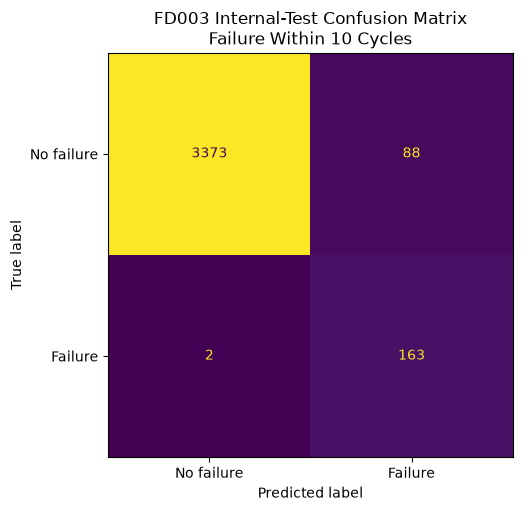

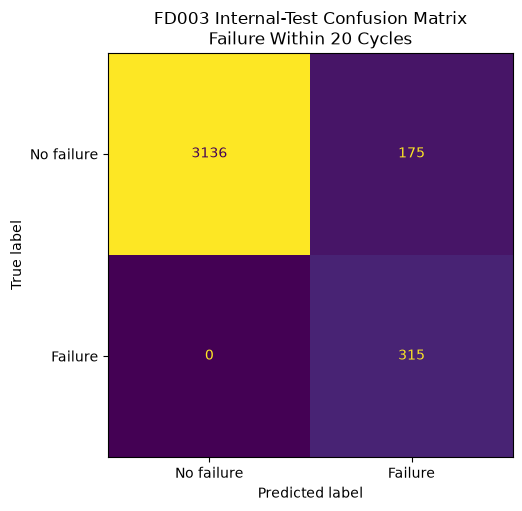

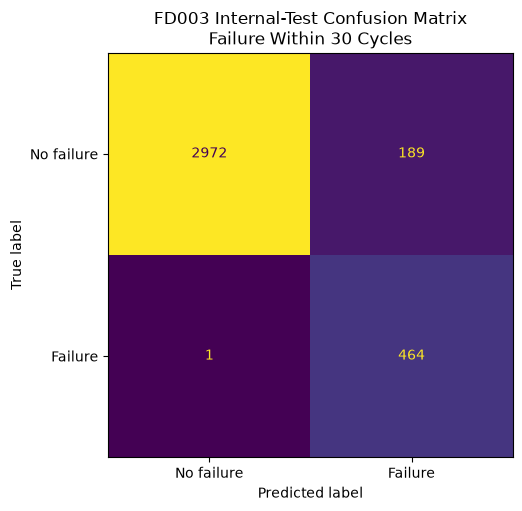

In [61]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
)


for column_index, horizon in enumerate(
    fd003_classification_horizons
):
    y_true = (
        fd003_internal_test_features_df[
            fd003_classification_target_columns[
                horizon
            ]
        ]
        .to_numpy(
            dtype=int
        )
    )

    probabilities = (
        fd003_internal_test_monotonic_probability_matrix[
            :,
            column_index
        ]
    )

    threshold = (
        fd003_locked_classification_thresholds[
            horizon
        ]
    )

    predictions = (
        probabilities
        >= threshold
    ).astype(int)


    confusion = confusion_matrix(
        y_true,
        predictions,
        labels=[
            0,
            1,
        ],
    )


    figure, axis = plt.subplots(
        figsize=(6, 5),
        constrained_layout=True,
    )


    display_object = (
        ConfusionMatrixDisplay(
            confusion_matrix=confusion,
            display_labels=[
                "No failure",
                "Failure",
            ],
        )
    )


    display_object.plot(
        ax=axis,
        values_format="d",
        colorbar=False,
    )


    axis.set_title(
        "FD003 Internal-Test Confusion Matrix\n"
        f"Failure Within {horizon} Cycles"
    )


    figure.savefig(
        FIGURES_DIR
        / (
            "fd003_internal_test_"
            f"confusion_matrix_h{horizon}.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()
    plt.close(figure)

In [62]:
fd003_internal_test_engine_classification_rows = []


for column_index, horizon in enumerate(
    fd003_classification_horizons
):
    target_column = (
        fd003_classification_target_columns[
            horizon
        ]
    )

    probability_column = (
        f"probability_{horizon}"
    )

    threshold = (
        fd003_locked_classification_thresholds[
            horizon
        ]
    )


    for engine_id, engine_frame in (
        fd003_internal_test_risk_df
        .groupby(
            "engine_id",
            sort=True,
        )
    ):
        y_true = (
            engine_frame[
                target_column
            ]
            .to_numpy(
                dtype=int
            )
        )

        probabilities = (
            engine_frame[
                probability_column
            ]
            .to_numpy(
                dtype=float
            )
        )

        predictions = (
            probabilities
            >= threshold
        ).astype(int)


        true_negative, false_positive, false_negative, true_positive = (
            confusion_matrix(
                y_true,
                predictions,
                labels=[
                    0,
                    1,
                ],
            )
            .ravel()
        )


        engine_false_positive_cost = (
            false_positive
            * fd003_false_positive_costs[
                horizon
            ]
        )

        engine_false_negative_cost = (
            false_negative
            * fd003_false_negative_costs[
                horizon
            ]
        )


        fd003_internal_test_engine_classification_rows.append(
            {
                "Horizon": horizon,
                "engine_id": int(
                    engine_id
                ),
                "Rows": int(
                    len(
                        engine_frame
                    )
                ),
                "Positive samples": int(
                    y_true.sum()
                ),
                "Predicted positives": int(
                    predictions.sum()
                ),
                "Precision": float(
                    precision_score(
                        y_true,
                        predictions,
                        zero_division=0,
                    )
                ),
                "Recall": float(
                    recall_score(
                        y_true,
                        predictions,
                        zero_division=0,
                    )
                ),
                "F1": float(
                    f1_score(
                        y_true,
                        predictions,
                        zero_division=0,
                    )
                ),
                "True negatives": int(
                    true_negative
                ),
                "False positives": int(
                    false_positive
                ),
                "False negatives": int(
                    false_negative
                ),
                "True positives": int(
                    true_positive
                ),
                "Total asymmetric cost": float(
                    engine_false_positive_cost
                    + engine_false_negative_cost
                ),
            }
        )


fd003_internal_test_per_engine_classification_df = (
    pd.DataFrame(
        fd003_internal_test_engine_classification_rows
    )
    .sort_values(
        [
            "Horizon",
            "Total asymmetric cost",
            "False negatives",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


fd003_internal_test_per_engine_classification_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_per_engine_classification.csv",
    index=False,
)


display(
    fd003_internal_test_per_engine_classification_df
    .groupby(
        "Horizon",
        as_index=False,
        group_keys=False,
    )
    .head(5)
    .round(6)
)

,Horizon,engine_id,Rows,Positive samples,Predicted positives,Precision,Recall,F1,True negatives,False positives,False negatives,True positives,Total asymmetric cost
0,10,66,165,11,9,1.000000,0.818182,0.900000,154,0,2,9,30.0
1,10,15,202,11,25,0.440000,1.000000,0.611111,177,14,0,11,14.0
2,10,67,263,11,25,0.440000,1.000000,0.611111,238,14,0,11,14.0
3,10,36,324,11,21,0.523810,1.000000,0.687500,303,10,0,11,10.0
4,10,13,185,11,20,0.550000,1.000000,0.709677,165,9,0,11,9.0
15,20,15,202,21,62,0.338710,1.000000,0.506024,140,41,0,21,41.0
16,20,67,263,21,44,0.477273,1.000000,0.646154,219,23,0,21,23.0
17,20,54,194,21,35,0.600000,1.000000,0.750000,159,14,0,21,14.0
18,20,9,406,21,34,0.617647,1.000000,0.763636,372,13,0,21,13.0
19,20,48,174,21,32,0.656250,1.000000,0.792453,142,11,0,21,11.0


In [63]:
fd003_classification_contract_df.loc[
    0,
    "Internal test accessed"
] = True

fd003_classification_contract_df[
    "Internal-test evaluation count"
] = 1

fd003_classification_contract_df[
    "Post-evaluation tuning permitted"
] = False


fd003_classification_contract_df[
    "Model 10"
] = (
    fd003_classification_bundles[
        10
    ][
        "model_name"
    ]
)

fd003_classification_contract_df[
    "Calibration 10"
] = (
    fd003_classification_bundles[
        10
    ][
        "calibration_method"
    ]
)

fd003_classification_contract_df[
    "Model 20"
] = (
    fd003_classification_bundles[
        20
    ][
        "model_name"
    ]
)

fd003_classification_contract_df[
    "Calibration 20"
] = (
    fd003_classification_bundles[
        20
    ][
        "calibration_method"
    ]
)

fd003_classification_contract_df[
    "Model 30"
] = (
    fd003_classification_bundles[
        30
    ][
        "model_name"
    ]
)

fd003_classification_contract_df[
    "Calibration 30"
] = (
    fd003_classification_bundles[
        30
    ][
        "calibration_method"
    ]
)


fd003_classification_contract_df.to_csv(
    TABLES_DIR
    / "fd003_classification_contract.csv",
    index=False,
)


assert bool(
    fd003_classification_contract_df.iloc[0][
        "Internal test accessed"
    ]
)

assert int(
    fd003_classification_contract_df.iloc[0][
        "Internal-test evaluation count"
    ]
) == 1

assert not bool(
    fd003_classification_contract_df.iloc[0][
        "Post-evaluation tuning permitted"
    ]
)


print(
    "FD003 internal-test classification "
    "results are now frozen."
)

display(
    fd003_classification_contract_df
)

FD003 internal-test classification results are now frozen.


,Dataset,Selection split,Feature configuration,Feature count,Threshold 10,Threshold 20,Threshold 30,False-negative cost 10,False-negative cost 20,False-negative cost 30,False-positive cost,Probability monotonicity,Internal test accessed,Internal-test evaluation count,Post-evaluation tuning permitted,Model 10,Calibration 10,Model 20,Calibration 20,Model 30,Calibration 30
0,FD003,Validation,Temporal,147,0.1,0.08,0.08,15.0,10.0,7.0,1.0,True,True,1,False,Weighted Logistic,Sigmoid,Weighted Logistic,Isotonic,Weighted Logistic,Isotonic


In [64]:
fd003_internal_test_classification_results_df.round(6)

,Dataset,Horizon,Model,Calibration method,Threshold,Samples,Positive rate,Predicted positive rate,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier score,Log loss,True negatives,False positives,False negatives,True positives,False-positive cost,False-negative cost,Total asymmetric cost,Evaluation engines,Feature count
0,FD003 internal test,10,Weighted Logistic,Sigmoid,0.10,3626,0.045505,0.069222,0.975179,0.649402,0.987879,0.783654,0.997899,0.962309,0.007938,0.025329,3373,88,2,163,88.0,30.0,118.0,15,147
1,FD003 internal test,20,Weighted Logistic,Isotonic,0.08,3626,0.086873,0.135135,0.951737,0.642857,1.000000,0.782609,0.996257,0.957343,0.014542,0.048126,3136,175,0,315,175.0,0.0,175.0,15,147
2,FD003 internal test,30,Weighted Logistic,Isotonic,0.08,3626,0.128240,0.180088,0.947601,0.710567,0.997849,0.830054,0.995697,0.955652,0.015728,0.120089,2972,189,1,464,189.0,7.0,196.0,15,147


In [65]:
fd003_internal_test_per_engine_classification_df.groupby(
    "Horizon",
    as_index=False,
    group_keys=False,
).head(5).round(6)

,Horizon,engine_id,Rows,Positive samples,Predicted positives,Precision,Recall,F1,True negatives,False positives,False negatives,True positives,Total asymmetric cost
0,10,66,165,11,9,1.000000,0.818182,0.900000,154,0,2,9,30.0
1,10,15,202,11,25,0.440000,1.000000,0.611111,177,14,0,11,14.0
2,10,67,263,11,25,0.440000,1.000000,0.611111,238,14,0,11,14.0
3,10,36,324,11,21,0.523810,1.000000,0.687500,303,10,0,11,10.0
4,10,13,185,11,20,0.550000,1.000000,0.709677,165,9,0,11,9.0
15,20,15,202,21,62,0.338710,1.000000,0.506024,140,41,0,21,41.0
16,20,67,263,21,44,0.477273,1.000000,0.646154,219,23,0,21,23.0
17,20,54,194,21,35,0.600000,1.000000,0.750000,159,14,0,21,14.0
18,20,9,406,21,34,0.617647,1.000000,0.763636,372,13,0,21,13.0
19,20,48,174,21,32,0.656250,1.000000,0.792453,142,11,0,21,11.0


In [66]:
fd003_classification_contract_df

,Dataset,Selection split,Feature configuration,Feature count,Threshold 10,Threshold 20,Threshold 30,False-negative cost 10,False-negative cost 20,False-negative cost 30,False-positive cost,Probability monotonicity,Internal test accessed,Internal-test evaluation count,Post-evaluation tuning permitted,Model 10,Calibration 10,Model 20,Calibration 20,Model 30,Calibration 30
0,FD003,Validation,Temporal,147,0.1,0.08,0.08,15.0,10.0,7.0,1.0,True,True,1,False,Weighted Logistic,Sigmoid,Weighted Logistic,Isotonic,Weighted Logistic,Isotonic


## 20. Engine-Level Bootstrap for Classification Metrics

Classification uncertainty is estimated by resampling complete internal-test
engines rather than individual cycles.

This preserves temporal dependence within each engine. The already locked
models, calibration methods, monotonic probabilities, and operational
thresholds are used without modification.

The bootstrap reports 95% percentile confidence intervals for discrimination,
calibration, threshold-dependent performance, and asymmetric maintenance cost.

In [67]:
# ---------------------------------------------------------
# Classification bootstrap configuration.
# ---------------------------------------------------------

fd003_classification_bootstrap_repetitions = 5000
fd003_classification_bootstrap_confidence = 0.95

fd003_classification_bootstrap_alpha = (
    1.0
    - fd003_classification_bootstrap_confidence
)

fd003_classification_bootstrap_rng = (
    np.random.default_rng(
        RANDOM_STATE
        + 3003
    )
)


fd003_classification_bootstrap_engine_ids = np.array(
    sorted(
        fd003_internal_test_risk_df[
            "engine_id"
        ]
        .astype(int)
        .unique()
    ),
    dtype=int,
)


assert len(
    fd003_classification_bootstrap_engine_ids
) == 15


# ---------------------------------------------------------
# Store complete trajectories for every engine.
# ---------------------------------------------------------

fd003_classification_engine_frames = {
    int(engine_id): (
        fd003_internal_test_risk_df.loc[
            fd003_internal_test_risk_df[
                "engine_id"
            ].eq(
                engine_id
            )
        ]
        .sort_values(
            "cycle"
        )
        .reset_index(drop=True)
    )
    for engine_id
    in fd003_classification_bootstrap_engine_ids
}


def calculate_fd003_locked_classification_metrics(
    *,
    y_true,
    probabilities,
    threshold,
    horizon,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    predictions = (
        probabilities
        >= threshold
    ).astype(int)


    true_negative, false_positive, false_negative, true_positive = (
        confusion_matrix(
            y_true,
            predictions,
            labels=[
                0,
                1,
            ],
        )
        .ravel()
    )


    if np.unique(
        y_true
    ).size == 2:
        roc_auc = float(
            roc_auc_score(
                y_true,
                probabilities,
            )
        )

        pr_auc = float(
            average_precision_score(
                y_true,
                probabilities,
            )
        )

    else:
        roc_auc = np.nan
        pr_auc = np.nan


    false_positive_cost = (
        false_positive
        * fd003_false_positive_costs[
            horizon
        ]
    )

    false_negative_cost = (
        false_negative
        * fd003_false_negative_costs[
            horizon
        ]
    )


    return {
        "Precision": float(
            precision_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "Recall": float(
            recall_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "F1": float(
            f1_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Brier score": float(
            brier_score_loss(
                y_true,
                probabilities,
            )
        ),
        "False positives": float(
            false_positive
        ),
        "False negatives": float(
            false_negative
        ),
        "Total asymmetric cost": float(
            false_positive_cost
            + false_negative_cost
        ),
        "Cost per row": float(
            (
                false_positive_cost
                + false_negative_cost
            )
            / len(
                y_true
            )
        ),
    }


# ---------------------------------------------------------
# Point estimates and bootstrap samples.
# ---------------------------------------------------------

fd003_classification_bootstrap_rows = []

fd003_classification_point_estimates = {}


for horizon in (
    fd003_classification_horizons
):
    target_column = (
        fd003_classification_target_columns[
            horizon
        ]
    )

    probability_column = (
        f"probability_{horizon}"
    )

    threshold = (
        fd003_locked_classification_thresholds[
            horizon
        ]
    )


    full_y_true = (
        fd003_internal_test_risk_df[
            target_column
        ]
        .to_numpy(
            dtype=int
        )
    )

    full_probabilities = (
        fd003_internal_test_risk_df[
            probability_column
        ]
        .to_numpy(
            dtype=float
        )
    )


    fd003_classification_point_estimates[
        horizon
    ] = (
        calculate_fd003_locked_classification_metrics(
            y_true=full_y_true,
            probabilities=full_probabilities,
            threshold=threshold,
            horizon=horizon,
        )
    )


    for bootstrap_index in range(
        fd003_classification_bootstrap_repetitions
    ):
        sampled_engine_ids = (
            fd003_classification_bootstrap_rng.choice(
                fd003_classification_bootstrap_engine_ids,
                size=len(
                    fd003_classification_bootstrap_engine_ids
                ),
                replace=True,
            )
        )


        sampled_y_true = np.concatenate(
            [
                fd003_classification_engine_frames[
                    int(engine_id)
                ][
                    target_column
                ].to_numpy(
                    dtype=int
                )
                for engine_id
                in sampled_engine_ids
            ]
        )


        sampled_probabilities = np.concatenate(
            [
                fd003_classification_engine_frames[
                    int(engine_id)
                ][
                    probability_column
                ].to_numpy(
                    dtype=float
                )
                for engine_id
                in sampled_engine_ids
            ]
        )


        bootstrap_metrics = (
            calculate_fd003_locked_classification_metrics(
                y_true=sampled_y_true,
                probabilities=sampled_probabilities,
                threshold=threshold,
                horizon=horizon,
            )
        )


        fd003_classification_bootstrap_rows.append(
            {
                "Horizon": horizon,
                "Bootstrap sample": int(
                    bootstrap_index
                    + 1
                ),
                "Sampled engines": int(
                    len(
                        sampled_engine_ids
                    )
                ),
                "Sampled rows": int(
                    len(
                        sampled_y_true
                    )
                ),
                **bootstrap_metrics,
            }
        )


        if (
            bootstrap_index
            + 1
        ) % 1000 == 0:
            print(
                f"Horizon {horizon}: "
                f"{bootstrap_index + 1} samples completed"
            )


fd003_internal_test_classification_bootstrap_df = (
    pd.DataFrame(
        fd003_classification_bootstrap_rows
    )
)


# ---------------------------------------------------------
# Percentile confidence intervals.
# ---------------------------------------------------------

fd003_classification_bootstrap_metric_names = [
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC",
    "Brier score",
    "False positives",
    "False negatives",
    "Total asymmetric cost",
    "Cost per row",
]


fd003_classification_ci_rows = []


for horizon in (
    fd003_classification_horizons
):
    horizon_bootstrap_df = (
        fd003_internal_test_classification_bootstrap_df.loc[
            fd003_internal_test_classification_bootstrap_df[
                "Horizon"
            ].eq(
                horizon
            )
        ]
    )


    for metric_name in (
        fd003_classification_bootstrap_metric_names
    ):
        metric_values = (
            horizon_bootstrap_df[
                metric_name
            ]
            .to_numpy(
                dtype=float
            )
        )


        fd003_classification_ci_rows.append(
            {
                "Horizon": horizon,
                "Metric": metric_name,
                "Estimate": float(
                    fd003_classification_point_estimates[
                        horizon
                    ][
                        metric_name
                    ]
                ),
                "CI lower": float(
                    np.nanquantile(
                        metric_values,
                        (
                            fd003_classification_bootstrap_alpha
                            / 2.0
                        ),
                    )
                ),
                "CI upper": float(
                    np.nanquantile(
                        metric_values,
                        (
                            1.0
                            - fd003_classification_bootstrap_alpha
                            / 2.0
                        ),
                    )
                ),
                "Confidence level": (
                    fd003_classification_bootstrap_confidence
                ),
                "Method": (
                    "Engine-level percentile bootstrap"
                ),
                "Bootstrap samples": (
                    fd003_classification_bootstrap_repetitions
                ),
                "Engine count": int(
                    len(
                        fd003_classification_bootstrap_engine_ids
                    )
                ),
            }
        )


fd003_internal_test_classification_ci_df = (
    pd.DataFrame(
        fd003_classification_ci_rows
    )
)


fd003_internal_test_classification_bootstrap_df.to_csv(
    TABLES_DIR
    / (
        "fd003_internal_test_"
        "classification_bootstrap_samples.csv"
    ),
    index=False,
)

fd003_internal_test_classification_ci_df.to_csv(
    TABLES_DIR
    / (
        "fd003_internal_test_"
        "classification_confidence_intervals.csv"
    ),
    index=False,
)


print("=" * 72)
print("FD003 CLASSIFICATION BOOTSTRAP COMPLETED")
print("=" * 72)


display(
    fd003_internal_test_classification_ci_df
    .round(6)
)

Horizon 10: 1000 samples completed
Horizon 10: 2000 samples completed
Horizon 10: 3000 samples completed
Horizon 10: 4000 samples completed
Horizon 10: 5000 samples completed
Horizon 20: 1000 samples completed
Horizon 20: 2000 samples completed
Horizon 20: 3000 samples completed
Horizon 20: 4000 samples completed
Horizon 20: 5000 samples completed
Horizon 30: 1000 samples completed
Horizon 30: 2000 samples completed
Horizon 30: 3000 samples completed
Horizon 30: 4000 samples completed
Horizon 30: 5000 samples completed
FD003 CLASSIFICATION BOOTSTRAP COMPLETED


,Horizon,Metric,Estimate,CI lower,CI upper,Confidence level,Method,Bootstrap samples,Engine count
0,10,Precision,0.649402,0.574913,0.737101,0.95,Engine-level percentile bootstrap,5000,15
1,10,Recall,0.987879,0.963636,1.000000,0.95,Engine-level percentile bootstrap,5000,15
2,10,F1,0.783654,0.728477,0.840206,0.95,Engine-level percentile bootstrap,5000,15
3,10,ROC-AUC,0.997899,0.996354,0.999211,0.95,Engine-level percentile bootstrap,5000,15
4,10,PR-AUC,0.962309,0.929401,0.985747,0.95,Engine-level percentile bootstrap,5000,15
5,10,Brier score,0.007938,0.005230,0.011094,0.95,Engine-level percentile bootstrap,5000,15
6,10,False positives,88.000000,57.975000,121.000000,0.95,Engine-level percentile bootstrap,5000,15
7,10,False negatives,2.000000,0.000000,6.000000,0.95,Engine-level percentile bootstrap,5000,15
8,10,Total asymmetric cost,118.000000,72.000000,179.000000,0.95,Engine-level percentile bootstrap,5000,15
9,10,Cost per row,0.032543,0.019660,0.052405,0.95,Engine-level percentile bootstrap,5000,15


## 21. Classification Calibration Diagnostics

Calibration quality is evaluated on the locked internal-test engines for three
probability representations:

1. raw classifier probability;
2. selected calibrated probability;
3. final monotonic probability used by the operational decision system.

Brier score, log loss, and expected calibration error are reported. These
results are diagnostic only and do not modify the locked calibration methods.

In [68]:
from sklearn.calibration import calibration_curve


def calculate_fd003_expected_calibration_error(
    y_true,
    probabilities,
    n_bins=10,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )


    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins
        + 1,
    )


    bin_indices = np.digitize(
        probabilities,
        bin_edges[
            1:-1
        ],
        right=True,
    )


    expected_calibration_error = 0.0


    for bin_index in range(
        n_bins
    ):
        bin_mask = (
            bin_indices
            == bin_index
        )


        if not bin_mask.any():
            continue


        bin_accuracy = float(
            y_true[
                bin_mask
            ].mean()
        )

        bin_confidence = float(
            probabilities[
                bin_mask
            ].mean()
        )

        bin_weight = float(
            bin_mask.mean()
        )


        expected_calibration_error += (
            bin_weight
            * abs(
                bin_accuracy
                - bin_confidence
            )
        )


    return float(
        expected_calibration_error
    )


fd003_calibration_diagnostic_rows = []


for horizon in (
    fd003_classification_horizons
):
    target_column = (
        fd003_classification_target_columns[
            horizon
        ]
    )

    y_true = (
        fd003_internal_test_risk_df[
            target_column
        ]
        .to_numpy(
            dtype=int
        )
    )


    probability_versions = {
        "Raw classifier": (
            fd003_internal_test_risk_df[
                f"raw_probability_{horizon}"
            ]
            .to_numpy(
                dtype=float
            )
        ),

        "Selected calibration": (
            fd003_internal_test_risk_df[
                f"calibrated_probability_{horizon}"
            ]
            .to_numpy(
                dtype=float
            )
        ),

        "Final monotonic": (
            fd003_internal_test_risk_df[
                f"probability_{horizon}"
            ]
            .to_numpy(
                dtype=float
            )
        ),
    }


    for probability_version, probabilities in (
        probability_versions.items()
    ):
        clipped_probabilities = np.clip(
            probabilities,
            1e-12,
            1.0
            - 1e-12,
        )


        fd003_calibration_diagnostic_rows.append(
            {
                "Horizon": horizon,
                "Probability version": (
                    probability_version
                ),
                "Brier score": float(
                    brier_score_loss(
                        y_true,
                        probabilities,
                    )
                ),
                "Log loss": float(
                    log_loss(
                        y_true,
                        clipped_probabilities,
                        labels=[
                            0,
                            1,
                        ],
                    )
                ),
                "Expected calibration error": float(
                    calculate_fd003_expected_calibration_error(
                        y_true,
                        probabilities,
                        n_bins=10,
                    )
                ),
                "Mean predicted probability": float(
                    probabilities.mean()
                ),
                "Observed positive rate": float(
                    y_true.mean()
                ),
            }
        )


fd003_calibration_diagnostics_df = (
    pd.DataFrame(
        fd003_calibration_diagnostic_rows
    )
    .sort_values(
        [
            "Horizon",
            "Brier score",
        ]
    )
    .reset_index(drop=True)
)


fd003_calibration_diagnostics_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_calibration_diagnostics.csv",
    index=False,
)


display(
    fd003_calibration_diagnostics_df
    .round(6)
)

,Horizon,Probability version,Brier score,Log loss,Expected calibration error,Mean predicted probability,Observed positive rate
0,10,Selected calibration,0.007938,0.025329,0.005833,0.049731,0.045505
1,10,Final monotonic,0.007938,0.025329,0.005833,0.049731,0.045505
2,10,Raw classifier,0.014448,0.059489,0.016216,0.061351,0.045505
3,20,Final monotonic,0.014542,0.048126,0.010661,0.096552,0.086873
4,20,Selected calibration,0.014614,0.048188,0.009915,0.095989,0.086873
5,20,Raw classifier,0.023182,0.091885,0.026444,0.113316,0.086873
6,30,Final monotonic,0.015728,0.120089,0.013092,0.138342,0.128240
7,30,Selected calibration,0.015883,0.119876,0.011028,0.137400,0.128240
8,30,Raw classifier,0.022525,0.090036,0.028050,0.156291,0.128240


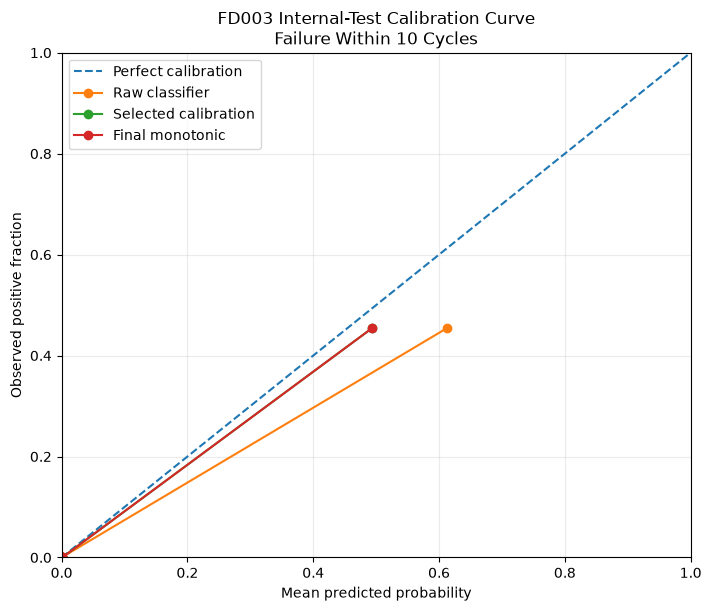

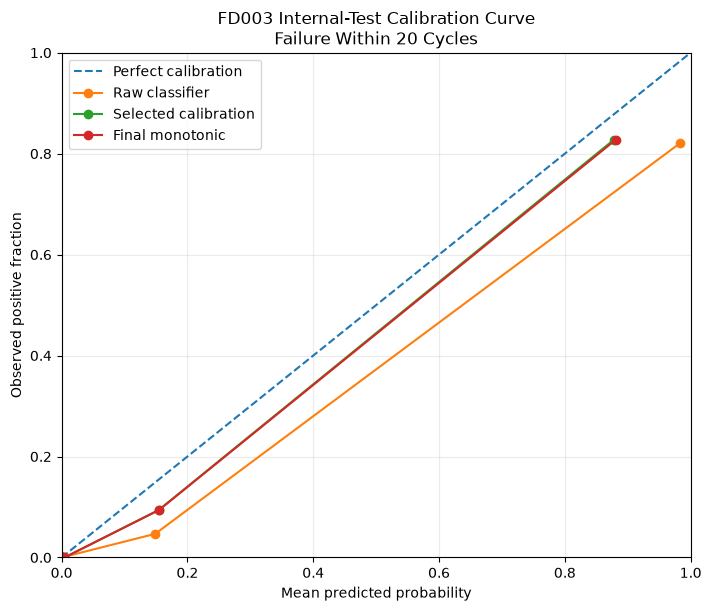

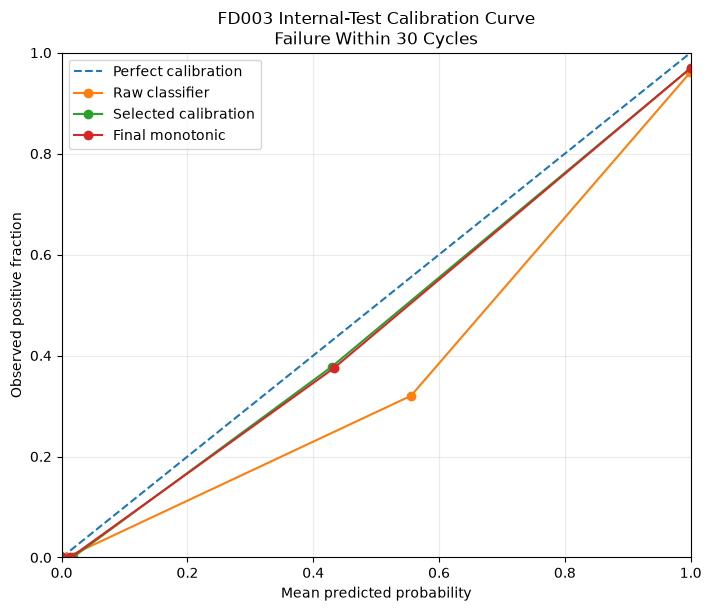

In [69]:
for horizon in (
    fd003_classification_horizons
):
    target_column = (
        fd003_classification_target_columns[
            horizon
        ]
    )

    y_true = (
        fd003_internal_test_risk_df[
            target_column
        ]
        .to_numpy(
            dtype=int
        )
    )


    probability_versions = {
        "Raw classifier": (
            fd003_internal_test_risk_df[
                f"raw_probability_{horizon}"
            ]
            .to_numpy(
                dtype=float
            )
        ),

        "Selected calibration": (
            fd003_internal_test_risk_df[
                f"calibrated_probability_{horizon}"
            ]
            .to_numpy(
                dtype=float
            )
        ),

        "Final monotonic": (
            fd003_internal_test_risk_df[
                f"probability_{horizon}"
            ]
            .to_numpy(
                dtype=float
            )
        ),
    }


    figure, axis = plt.subplots(
        figsize=(7, 6),
        constrained_layout=True,
    )


    axis.plot(
        [
            0.0,
            1.0,
        ],
        [
            0.0,
            1.0,
        ],
        linestyle="--",
        label="Perfect calibration",
    )


    for probability_version, probabilities in (
        probability_versions.items()
    ):
        observed_fraction, mean_probability = (
            calibration_curve(
                y_true,
                probabilities,
                n_bins=10,
                strategy="quantile",
            )
        )


        axis.plot(
            mean_probability,
            observed_fraction,
            marker="o",
            label=probability_version,
        )


    axis.set_title(
        "FD003 Internal-Test Calibration Curve\n"
        f"Failure Within {horizon} Cycles"
    )

    axis.set_xlabel(
        "Mean predicted probability"
    )

    axis.set_ylabel(
        "Observed positive fraction"
    )

    axis.set_xlim(
        0.0,
        1.0,
    )

    axis.set_ylim(
        0.0,
        1.0,
    )

    axis.grid(
        alpha=0.25,
    )

    axis.legend()


    figure.savefig(
        FIGURES_DIR
        / (
            "fd003_internal_test_"
            f"calibration_curve_h{horizon}.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()
    plt.close(
        figure
    )

## 22. Persistent Early-Warning Rule

Single-cycle probability threshold crossings may create unstable maintenance
alerts.

A fixed persistence rule inherited unchanged from the FD001 operational
protocol is applied:

> An alert becomes persistent when at least 2 of the most recent 3 cycles
> exceed the locked horizon-specific threshold.

No alternative persistence parameters are evaluated on the FD003 internal-test
set.

In [70]:
# ---------------------------------------------------------
# Fixed operational persistence protocol.
# ---------------------------------------------------------

fd003_persistence_required_alerts = 2
fd003_persistence_window = 3


fd003_internal_test_persistent_risk_df = (
    fd003_internal_test_risk_df
    .sort_values(
        [
            "engine_id",
            "cycle",
        ]
    )
    .reset_index(drop=True)
    .copy()
)


for horizon in (
    fd003_classification_horizons
):
    probability_column = (
        f"probability_{horizon}"
    )

    direct_alert_column = (
        f"direct_alert_{horizon}"
    )

    persistent_alert_column = (
        f"persistent_alert_{horizon}"
    )


    threshold = (
        fd003_locked_classification_thresholds[
            horizon
        ]
    )


    fd003_internal_test_persistent_risk_df[
        direct_alert_column
    ] = (
        fd003_internal_test_persistent_risk_df[
            probability_column
        ]
        >= threshold
    )


    fd003_internal_test_persistent_risk_df[
        persistent_alert_column
    ] = (
        fd003_internal_test_persistent_risk_df
        .groupby(
            "engine_id",
            sort=False,
        )[
            direct_alert_column
        ]
        .transform(
            lambda alert_series: (
                alert_series
                .astype(int)
                .rolling(
                    window=(
                        fd003_persistence_window
                    ),
                    min_periods=(
                        fd003_persistence_required_alerts
                    ),
                )
                .sum()
                .ge(
                    fd003_persistence_required_alerts
                )
            )
        )
        .fillna(False)
        .astype(bool)
    )


fd003_internal_test_persistent_risk_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_persistent_probabilities.csv",
    index=False,
)


print(
    "FD003 fixed 2-of-3 persistence rule applied."
)

display(
    fd003_internal_test_persistent_risk_df.head()
)

FD003 fixed 2-of-3 persistence rule applied.


,engine_id,cycle,RUL,failure_within_10,failure_within_20,failure_within_30,raw_probability_10,calibrated_probability_10,probability_10,raw_probability_20,calibrated_probability_20,probability_20,raw_probability_30,calibrated_probability_30,probability_30,direct_alert_10,persistent_alert_10,direct_alert_20,persistent_alert_20,direct_alert_30,persistent_alert_30
0,9,1,405,0,0,0,1.019170e-31,0.000312,0.000312,2.991896e-10,0.0,0.000312,5.240795e-10,0.0,0.000312,False,False,False,False,False,False
1,9,2,404,0,0,0,4.953808e-27,0.000312,0.000312,4.007643e-11,0.0,0.000312,2.286227e-08,0.0,0.000312,False,False,False,False,False,False
2,9,3,403,0,0,0,7.057870e-25,0.000312,0.000312,1.996449e-07,0.0,0.000312,2.287383e-06,0.0,0.000312,False,False,False,False,False,False
3,9,4,402,0,0,0,2.784819e-23,0.000312,0.000312,5.755561e-08,0.0,0.000312,5.579484e-07,0.0,0.000312,False,False,False,False,False,False
4,9,5,401,0,0,0,2.593771e-23,0.000312,0.000312,5.558048e-08,0.0,0.000312,3.578197e-07,0.0,0.000312,False,False,False,False,False,False


In [71]:
fd003_persistent_alert_result_rows = []


for horizon in (
    fd003_classification_horizons
):
    target_column = (
        fd003_classification_target_columns[
            horizon
        ]
    )

    direct_alert_column = (
        f"direct_alert_{horizon}"
    )

    persistent_alert_column = (
        f"persistent_alert_{horizon}"
    )


    y_true = (
        fd003_internal_test_persistent_risk_df[
            target_column
        ]
        .to_numpy(
            dtype=int
        )
    )


    for alert_rule, alert_column in [
        (
            "Direct threshold",
            direct_alert_column,
        ),
        (
            "Persistent 2-of-3",
            persistent_alert_column,
        ),
    ]:
        predictions = (
            fd003_internal_test_persistent_risk_df[
                alert_column
            ]
            .to_numpy(
                dtype=int
            )
        )


        true_negative, false_positive, false_negative, true_positive = (
            confusion_matrix(
                y_true,
                predictions,
                labels=[
                    0,
                    1,
                ],
            )
            .ravel()
        )


        false_positive_cost = (
            false_positive
            * fd003_false_positive_costs[
                horizon
            ]
        )

        false_negative_cost = (
            false_negative
            * fd003_false_negative_costs[
                horizon
            ]
        )


        fd003_persistent_alert_result_rows.append(
            {
                "Dataset": (
                    "FD003 internal test"
                ),
                "Horizon": horizon,
                "Alert rule": alert_rule,
                "Threshold": (
                    fd003_locked_classification_thresholds[
                        horizon
                    ]
                ),
                "Samples": int(
                    len(
                        y_true
                    )
                ),
                "Predicted positive rate": float(
                    predictions.mean()
                ),
                "Precision": float(
                    precision_score(
                        y_true,
                        predictions,
                        zero_division=0,
                    )
                ),
                "Recall": float(
                    recall_score(
                        y_true,
                        predictions,
                        zero_division=0,
                    )
                ),
                "F1": float(
                    f1_score(
                        y_true,
                        predictions,
                        zero_division=0,
                    )
                ),
                "True negatives": int(
                    true_negative
                ),
                "False positives": int(
                    false_positive
                ),
                "False negatives": int(
                    false_negative
                ),
                "True positives": int(
                    true_positive
                ),
                "Total asymmetric cost": float(
                    false_positive_cost
                    + false_negative_cost
                ),
            }
        )


fd003_persistent_alert_results_df = (
    pd.DataFrame(
        fd003_persistent_alert_result_rows
    )
)


fd003_persistent_alert_results_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_persistent_alert_results.csv",
    index=False,
)


display(
    fd003_persistent_alert_results_df
    .round(6)
)

,Dataset,Horizon,Alert rule,Threshold,Samples,Predicted positive rate,Precision,Recall,F1,True negatives,False positives,False negatives,True positives,Total asymmetric cost
0,FD003 internal test,10,Direct threshold,0.10,3626,0.069222,0.649402,0.987879,0.783654,3373,88,2,163,118.0
1,FD003 internal test,10,Persistent 2-of-3,0.10,3626,0.066189,0.675000,0.981818,0.800000,3383,78,3,162,123.0
2,FD003 internal test,20,Direct threshold,0.08,3626,0.135135,0.642857,1.000000,0.782609,3136,175,0,315,175.0
3,FD003 internal test,20,Persistent 2-of-3,0.08,3626,0.131274,0.661765,1.000000,0.796460,3150,161,0,315,161.0
4,FD003 internal test,30,Direct threshold,0.08,3626,0.180088,0.710567,0.997849,0.830054,2972,189,1,464,196.0
5,FD003 internal test,30,Persistent 2-of-3,0.08,3626,0.175124,0.729134,0.995699,0.841818,2989,172,2,463,186.0


## 23. Engine-Level Early-Warning Performance

For each engine and horizon, the persistent warning system is evaluated using:

- first persistent-alert lead time;
- delay after entering the target failure horizon;
- number of unnecessarily early alert cycles;
- whether the engine received a warning inside the required horizon;
- horizon-level miss rate.

In [72]:
fd003_early_warning_engine_rows = []


for horizon in (
    fd003_classification_horizons
):
    persistent_alert_column = (
        f"persistent_alert_{horizon}"
    )


    for engine_id, engine_frame in (
        fd003_internal_test_persistent_risk_df
        .groupby(
            "engine_id",
            sort=True,
        )
    ):
        engine_frame = (
            engine_frame
            .sort_values(
                "cycle"
            )
            .reset_index(drop=True)
        )


        persistent_alert_mask = (
            engine_frame[
                persistent_alert_column
            ].to_numpy(
                dtype=bool
            )
        )


        persistent_alert_frame = (
            engine_frame.loc[
                persistent_alert_mask
            ]
        )


        in_horizon_frame = (
            engine_frame.loc[
                engine_frame[
                    "RUL"
                ]
                <= horizon
            ]
        )


        in_horizon_alert_frame = (
            in_horizon_frame.loc[
                in_horizon_frame[
                    persistent_alert_column
                ]
            ]
        )


        if persistent_alert_frame.empty:
            first_alert_cycle = np.nan
            first_alert_rul = np.nan
        else:
            first_alert_cycle = float(
                persistent_alert_frame
                .iloc[0][
                    "cycle"
                ]
            )

            first_alert_rul = float(
                persistent_alert_frame
                .iloc[0][
                    "RUL"
                ]
            )


        missed_horizon = bool(
            in_horizon_alert_frame.empty
        )


        if missed_horizon:
            first_in_horizon_alert_cycle = np.nan
            first_in_horizon_alert_rul = np.nan
            late_delay = np.nan
        else:
            first_in_horizon_alert_cycle = float(
                in_horizon_alert_frame
                .iloc[0][
                    "cycle"
                ]
            )

            first_in_horizon_alert_rul = float(
                in_horizon_alert_frame
                .iloc[0][
                    "RUL"
                ]
            )

            late_delay = float(
                horizon
                - first_in_horizon_alert_rul
            )


        early_alert_cycles = int(
            (
                engine_frame[
                    persistent_alert_column
                ]
                & (
                    engine_frame[
                        "RUL"
                    ]
                    > horizon
                )
            )
            .sum()
        )


        in_horizon_alert_cycles = int(
            (
                engine_frame[
                    persistent_alert_column
                ]
                & (
                    engine_frame[
                        "RUL"
                    ]
                    <= horizon
                )
            )
            .sum()
        )


        lead_excess = (
            np.nan
            if pd.isna(
                first_alert_rul
            )
            else float(
                max(
                    0.0,
                    first_alert_rul
                    - horizon,
                )
            )
        )


        fd003_early_warning_engine_rows.append(
            {
                "Horizon": horizon,
                "engine_id": int(
                    engine_id
                ),
                "Engine rows": int(
                    len(
                        engine_frame
                    )
                ),
                "First persistent alert cycle": (
                    first_alert_cycle
                ),
                "First persistent alert RUL": (
                    first_alert_rul
                ),
                "First in-horizon alert cycle": (
                    first_in_horizon_alert_cycle
                ),
                "First in-horizon alert RUL": (
                    first_in_horizon_alert_rul
                ),
                "Late delay": late_delay,
                "Early lead excess": (
                    lead_excess
                ),
                "Early alert cycles": (
                    early_alert_cycles
                ),
                "In-horizon alert cycles": (
                    in_horizon_alert_cycles
                ),
                "Missed horizon": (
                    missed_horizon
                ),
            }
        )


fd003_early_warning_per_engine_df = (
    pd.DataFrame(
        fd003_early_warning_engine_rows
    )
)


# ---------------------------------------------------------
# Horizon-level early-warning summary.
# ---------------------------------------------------------

fd003_early_warning_summary_rows = []


for horizon in (
    fd003_classification_horizons
):
    horizon_frame = (
        fd003_early_warning_per_engine_df.loc[
            fd003_early_warning_per_engine_df[
                "Horizon"
            ].eq(
                horizon
            )
        ]
    )


    detected_frame = (
        horizon_frame.loc[
            ~horizon_frame[
                "Missed horizon"
            ]
        ]
    )


    fd003_early_warning_summary_rows.append(
        {
            "Horizon": horizon,
            "Engines": int(
                len(
                    horizon_frame
                )
            ),
            "Detected engines": int(
                len(
                    detected_frame
                )
            ),
            "Missed engines": int(
                horizon_frame[
                    "Missed horizon"
                ].sum()
            ),
            "Detection rate": float(
                (
                    ~horizon_frame[
                        "Missed horizon"
                    ]
                ).mean()
            ),
            "Miss rate": float(
                horizon_frame[
                    "Missed horizon"
                ].mean()
            ),
            "Mean first-alert RUL": float(
                horizon_frame[
                    "First persistent alert RUL"
                ].mean()
            ),
            "Median first-alert RUL": float(
                horizon_frame[
                    "First persistent alert RUL"
                ].median()
            ),
            "Mean late delay": float(
                detected_frame[
                    "Late delay"
                ].mean()
            ),
            "Median late delay": float(
                detected_frame[
                    "Late delay"
                ].median()
            ),
            "Mean early alert cycles": float(
                horizon_frame[
                    "Early alert cycles"
                ].mean()
            ),
            "Median early alert cycles": float(
                horizon_frame[
                    "Early alert cycles"
                ].median()
            ),
            "Maximum early alert cycles": int(
                horizon_frame[
                    "Early alert cycles"
                ].max()
            ),
        }
    )


fd003_early_warning_summary_df = (
    pd.DataFrame(
        fd003_early_warning_summary_rows
    )
)


fd003_early_warning_per_engine_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_early_warning_per_engine.csv",
    index=False,
)

fd003_early_warning_summary_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_early_warning_summary.csv",
    index=False,
)


display(
    fd003_early_warning_summary_df
    .round(6)
)

display(
    fd003_early_warning_per_engine_df
    .sort_values(
        [
            "Horizon",
            "Missed horizon",
            "Late delay",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
    .groupby(
        "Horizon",
        group_keys=False,
    )
    .head(5)
    .round(6)
)

,Horizon,Engines,Detected engines,Missed engines,Detection rate,Miss rate,Mean first-alert RUL,Median first-alert RUL,Mean late delay,Median late delay,Mean early alert cycles,Median early alert cycles,Maximum early alert cycles
0,10,15,15,0,1.0,0.0,15.000000,14.0,0.200000,0.0,5.200000,4.0,14
1,20,15,15,0,1.0,0.0,32.866667,28.0,0.000000,0.0,10.733333,8.0,39
2,30,15,15,0,1.0,0.0,55.800000,42.0,0.133333,0.0,11.466667,7.0,61


,Horizon,engine_id,Engine rows,First persistent alert cycle,First persistent alert RUL,First in-horizon alert cycle,First in-horizon alert RUL,Late delay,Early lead excess,Early alert cycles,In-horizon alert cycles,Missed horizon
12,10,66,165,158.0,7.0,158.0,7.0,3.0,0.0,0,8,False
0,10,9,406,390.0,16.0,396.0,10.0,0.0,6.0,6,11,False
1,10,13,185,167.0,18.0,175.0,10.0,0.0,8.0,8,11,False
2,10,14,207,197.0,10.0,197.0,10.0,0.0,0.0,0,11,False
3,10,15,202,178.0,24.0,192.0,10.0,0.0,14.0,14,11,False
15,20,9,406,374.0,32.0,386.0,20.0,0.0,12.0,12,21,False
16,20,13,185,157.0,28.0,165.0,20.0,0.0,8.0,8,21,False
17,20,14,207,182.0,25.0,187.0,20.0,0.0,5.0,5,21,False
18,20,15,202,123.0,79.0,182.0,20.0,0.0,59.0,39,21,False
19,20,20,338,314.0,24.0,318.0,20.0,0.0,4.0,4,21,False


In [73]:
fd003_classification_contract_df[
    "Persistence rule"
] = "2-of-3"

fd003_classification_contract_df[
    "Persistence required alerts"
] = (
    fd003_persistence_required_alerts
)

fd003_classification_contract_df[
    "Persistence window"
] = (
    fd003_persistence_window
)

fd003_classification_contract_df[
    "Persistence tuning source"
] = (
    "Fixed FD001 operational protocol; "
    "not tuned on FD003 internal test"
)

fd003_classification_contract_df[
    "Early-warning evaluation completed"
] = True


fd003_classification_contract_df.to_csv(
    TABLES_DIR
    / "fd003_classification_contract.csv",
    index=False,
)


display(
    fd003_classification_contract_df
)

,Dataset,Selection split,Feature configuration,Feature count,Threshold 10,Threshold 20,Threshold 30,False-negative cost 10,False-negative cost 20,False-negative cost 30,False-positive cost,Probability monotonicity,Internal test accessed,Internal-test evaluation count,Post-evaluation tuning permitted,Model 10,Calibration 10,Model 20,Calibration 20,Model 30,Calibration 30,Persistence rule,Persistence required alerts,Persistence window,Persistence tuning source,Early-warning evaluation completed
0,FD003,Validation,Temporal,147,0.1,0.08,0.08,15.0,10.0,7.0,1.0,True,True,1,False,Weighted Logistic,Sigmoid,Weighted Logistic,Isotonic,Weighted Logistic,Isotonic,2-of-3,2,3,Fixed FD001 operational protocol; not tuned on...,True


## 24. Unsupervised Anomaly Detection

The anomaly-detection subsystem is trained exclusively on early-life
observations from the 70 training engines.

The first 30 cycles of every training engine are used as the healthy reference
set. This produces 2,100 training observations and preserves the same healthy
reference contract used in the FD001 workflow.

Four anomaly detectors are compared:

- Isolation Forest;
- Local Outlier Factor with `novelty=True`;
- One-Class SVM;
- PCA reconstruction error.

All anomaly scores are transformed so that larger values indicate stronger
anomaly evidence. Scores are then robustly normalized using the median and
interquartile range of the healthy training-reference scores.

Model and threshold selection use validation engines only. The internal-test
engines remain untouched.

In [78]:
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM


# ---------------------------------------------------------
# Locked anomaly feature schema.
# ---------------------------------------------------------

fd003_anomaly_sensor_columns = list(
    fd003_candidate_sensor_columns
)

fd003_anomaly_reference_cycle_limit = 30


assert len(
    fd003_anomaly_sensor_columns
) == 16


# ---------------------------------------------------------
# Healthy reference: first 30 cycles of training engines.
# ---------------------------------------------------------

fd003_anomaly_reference_df = (
    fd003_train_features_df.loc[
        fd003_train_features_df[
            "cycle"
        ]
        <= fd003_anomaly_reference_cycle_limit
    ]
    .sort_values(
        [
            "engine_id",
            "cycle",
        ]
    )
    .reset_index(drop=True)
    .copy()
)


assert (
    fd003_anomaly_reference_df[
        "engine_id"
    ].nunique()
    == 70
)

assert len(
    fd003_anomaly_reference_df
) == (
    70
    * fd003_anomaly_reference_cycle_limit
)


# ---------------------------------------------------------
# Leakage-safe scaling.
# ---------------------------------------------------------

fd003_anomaly_scaler = StandardScaler()


fd003_X_anomaly_reference = (
    fd003_anomaly_scaler.fit_transform(
        fd003_anomaly_reference_df[
            fd003_anomaly_sensor_columns
        ]
    )
)


fd003_X_anomaly_validation = (
    fd003_anomaly_scaler.transform(
        fd003_validation_features_df[
            fd003_anomaly_sensor_columns
        ]
    )
)


fd003_y_anomaly_validation = (
    fd003_validation_features_df[
        "failure_within_30"
    ]
    .to_numpy(
        dtype=int
    )
)


assert (
    fd003_X_anomaly_reference.shape
    == (
        2100,
        16,
    )
)

assert (
    fd003_X_anomaly_validation.shape[0]
    == len(
        fd003_validation_features_df
    )
)

assert np.isfinite(
    fd003_X_anomaly_reference
).all()

assert np.isfinite(
    fd003_X_anomaly_validation
).all()


fd003_anomaly_reference_summary_df = pd.DataFrame(
    [
        {
            "Dataset": "FD003",
            "Training engines": 70,
            "Healthy cycles per engine": (
                fd003_anomaly_reference_cycle_limit
            ),
            "Healthy reference rows": len(
                fd003_anomaly_reference_df
            ),
            "Sensor count": len(
                fd003_anomaly_sensor_columns
            ),
            "Validation rows": len(
                fd003_validation_features_df
            ),
            "Validation engines": int(
                fd003_validation_features_df[
                    "engine_id"
                ].nunique()
            ),
            "Validation anomaly definition": (
                "RUL <= 30"
            ),
            "Internal test accessed": False,
        }
    ]
)


fd003_anomaly_reference_summary_df.to_csv(
    TABLES_DIR
    / "fd003_anomaly_reference_summary.csv",
    index=False,
)


display(
    fd003_anomaly_reference_summary_df
)

,Dataset,Training engines,Healthy cycles per engine,Healthy reference rows,Sensor count,Validation rows,Validation engines,Validation anomaly definition,Internal test accessed
0,FD003,70,30,2100,16,3688,15,RUL <= 30,False


In [79]:
def robust_normalize_fd003_anomaly_scores(
    reference_scores,
    evaluation_scores,
):
    reference_scores = np.asarray(
        reference_scores,
        dtype=float,
    )

    evaluation_scores = np.asarray(
        evaluation_scores,
        dtype=float,
    )


    reference_median = float(
        np.median(
            reference_scores
        )
    )

    reference_q1 = float(
        np.quantile(
            reference_scores,
            0.25,
        )
    )

    reference_q3 = float(
        np.quantile(
            reference_scores,
            0.75,
        )
    )

    reference_scale = float(
        reference_q3
        - reference_q1
    )


    if (
        not np.isfinite(
            reference_scale
        )
        or reference_scale
        <= 1e-12
    ):
        reference_scale = float(
            np.std(
                reference_scores
            )
        )


    if (
        not np.isfinite(
            reference_scale
        )
        or reference_scale
        <= 1e-12
    ):
        reference_scale = 1.0


    normalized_reference = (
        reference_scores
        - reference_median
    ) / reference_scale

    normalized_evaluation = (
        evaluation_scores
        - reference_median
    ) / reference_scale


    return {
        "normalized_reference": (
            normalized_reference
        ),
        "normalized_evaluation": (
            normalized_evaluation
        ),
        "reference_median": (
            reference_median
        ),
        "reference_scale": (
            reference_scale
        ),
        "reference_q1": (
            reference_q1
        ),
        "reference_q3": (
            reference_q3
        ),
    }


def calculate_fd003_anomaly_metrics(
    *,
    y_true,
    normalized_scores,
    threshold,
    false_positive_cost=1.0,
    false_negative_cost=7.0,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    normalized_scores = np.asarray(
        normalized_scores,
        dtype=float,
    )


    predictions = (
        normalized_scores
        >= threshold
    ).astype(int)


    true_negative, false_positive, false_negative, true_positive = (
        confusion_matrix(
            y_true,
            predictions,
            labels=[
                0,
                1,
            ],
        )
        .ravel()
    )


    total_cost = (
        false_positive
        * false_positive_cost
        + false_negative
        * false_negative_cost
    )


    return {
        "Threshold": float(
            threshold
        ),
        "Precision": float(
            precision_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "Recall": float(
            recall_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "F1": float(
            f1_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "ROC-AUC": float(
            roc_auc_score(
                y_true,
                normalized_scores,
            )
        ),
        "PR-AUC": float(
            average_precision_score(
                y_true,
                normalized_scores,
            )
        ),
        "True negatives": int(
            true_negative
        ),
        "False positives": int(
            false_positive
        ),
        "False negatives": int(
            false_negative
        ),
        "True positives": int(
            true_positive
        ),
        "Predicted positive rate": float(
            predictions.mean()
        ),
        "Total asymmetric cost": float(
            total_cost
        ),
        "Cost per row": float(
            total_cost
            / len(
                y_true
            )
        ),
    }

## 25. Validation Comparison of Four Anomaly Detectors

All detectors are fitted on the same standardized healthy training-reference
observations.

For every model:

1. raw scores are oriented so that larger values mean more anomalous;
2. scores are robustly normalized using healthy-reference statistics;
3. thresholds are derived from fixed healthy-reference quantiles;
4. validation `RUL <= 30` labels are used only for model and threshold
   comparison.

The declared false-negative and false-positive costs are 7 and 1,
respectively.

In [80]:
# ---------------------------------------------------------
# Define the four required anomaly models.
# ---------------------------------------------------------

fd003_anomaly_models = {
    "Isolation Forest": {
        "model": IsolationForest(
            n_estimators=300,
            max_samples="auto",
            contamination="auto",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "type": "decision_function",
    },

    "LOF": {
        "model": LocalOutlierFactor(
            n_neighbors=35,
            novelty=True,
            contamination="auto",
            metric="minkowski",
            n_jobs=-1,
        ),
        "type": "decision_function",
    },

    "One-Class SVM": {
        "model": OneClassSVM(
            kernel="rbf",
            gamma="scale",
            nu=0.05,
        ),
        "type": "decision_function",
    },

    "PCA Reconstruction": {
        "model": PCA(
            n_components=0.95,
            svd_solver="full",
            random_state=RANDOM_STATE,
        ),
        "type": "reconstruction",
    },
}


fd003_anomaly_threshold_quantiles = [
    0.950,
    0.975,
    0.990,
    0.995,
    0.999,
]


fd003_anomaly_fitted_bundles = {}

fd003_anomaly_validation_score_map = {}

fd003_anomaly_reference_score_map = {}

fd003_anomaly_threshold_search_rows = []

fd003_anomaly_timing_rows = []


for model_name, model_bundle in (
    fd003_anomaly_models.items()
):
    print(
        "Training anomaly detector:",
        model_name,
    )


    model = model_bundle[
        "model"
    ]

    score_type = model_bundle[
        "type"
    ]


    fit_start = perf_counter()

    model.fit(
        fd003_X_anomaly_reference
    )

    fit_seconds = (
        perf_counter()
        - fit_start
    )


    score_start = perf_counter()


    if score_type == "decision_function":
        reference_raw_scores = -model.decision_function(
            fd003_X_anomaly_reference
        )

        validation_raw_scores = -model.decision_function(
            fd003_X_anomaly_validation
        )

    elif score_type == "reconstruction":
        reference_reconstruction = (
            model.inverse_transform(
                model.transform(
                    fd003_X_anomaly_reference
                )
            )
        )

        validation_reconstruction = (
            model.inverse_transform(
                model.transform(
                    fd003_X_anomaly_validation
                )
            )
        )


        reference_raw_scores = np.mean(
            (
                fd003_X_anomaly_reference
                - reference_reconstruction
            )
            ** 2,
            axis=1,
        )

        validation_raw_scores = np.mean(
            (
                fd003_X_anomaly_validation
                - validation_reconstruction
            )
            ** 2,
            axis=1,
        )

    else:
        raise ValueError(
            f"Unknown anomaly score type: {score_type}"
        )


    score_seconds = (
        perf_counter()
        - score_start
    )


    normalization_result = (
        robust_normalize_fd003_anomaly_scores(
            reference_raw_scores,
            validation_raw_scores,
        )
    )


    normalized_reference_scores = (
        normalization_result[
            "normalized_reference"
        ]
    )

    normalized_validation_scores = (
        normalization_result[
            "normalized_evaluation"
        ]
    )


    assert np.isfinite(
        normalized_reference_scores
    ).all()

    assert np.isfinite(
        normalized_validation_scores
    ).all()


    fd003_anomaly_reference_score_map[
        model_name
    ] = normalized_reference_scores

    fd003_anomaly_validation_score_map[
        model_name
    ] = normalized_validation_scores


    fd003_anomaly_fitted_bundles[
        model_name
    ] = {
        "model": model,
        "score_type": score_type,
        "reference_median": (
            normalization_result[
                "reference_median"
            ]
        ),
        "reference_scale": (
            normalization_result[
                "reference_scale"
            ]
        ),
        "reference_q1": (
            normalization_result[
                "reference_q1"
            ]
        ),
        "reference_q3": (
            normalization_result[
                "reference_q3"
            ]
        ),
    }


    fd003_anomaly_timing_rows.append(
        {
            "Model": model_name,
            "Fit time (seconds)": float(
                fit_seconds
            ),
            "Scoring time (seconds)": float(
                score_seconds
            ),
            "Scoring ms per 1000 rows": float(
                score_seconds
                * 1_000_000.0
                / len(
                    normalized_validation_scores
                )
            ),
            "Healthy reference rows": len(
                fd003_X_anomaly_reference
            ),
            "Validation rows": len(
                fd003_X_anomaly_validation
            ),
        }
    )


    for threshold_quantile in (
        fd003_anomaly_threshold_quantiles
    ):
        threshold = float(
            np.quantile(
                normalized_reference_scores,
                threshold_quantile,
            )
        )


        metrics = (
            calculate_fd003_anomaly_metrics(
                y_true=(
                    fd003_y_anomaly_validation
                ),
                normalized_scores=(
                    normalized_validation_scores
                ),
                threshold=threshold,
                false_positive_cost=1.0,
                false_negative_cost=7.0,
            )
        )


        fd003_anomaly_threshold_search_rows.append(
            {
                "Model": model_name,
                "Healthy threshold quantile": float(
                    threshold_quantile
                ),
                **metrics,
                "Fit time (seconds)": float(
                    fit_seconds
                ),
                "Scoring ms per 1000 rows": float(
                    score_seconds
                    * 1_000_000.0
                    / len(
                        normalized_validation_scores
                    )
                ),
                "Reference score median": float(
                    normalization_result[
                        "reference_median"
                    ]
                ),
                "Reference score scale": float(
                    normalization_result[
                        "reference_scale"
                    ]
                ),
            }
        )


fd003_anomaly_threshold_search_df = (
    pd.DataFrame(
        fd003_anomaly_threshold_search_rows
    )
)


fd003_anomaly_timing_df = pd.DataFrame(
    fd003_anomaly_timing_rows
)


fd003_anomaly_threshold_search_df.to_csv(
    TABLES_DIR
    / "fd003_anomaly_threshold_search.csv",
    index=False,
)

fd003_anomaly_timing_df.to_csv(
    TABLES_DIR
    / "fd003_anomaly_model_timing.csv",
    index=False,
)


display(
    fd003_anomaly_timing_df
    .round(6)
)

Training anomaly detector: Isolation Forest
Training anomaly detector: LOF
Training anomaly detector: One-Class SVM
Training anomaly detector: PCA Reconstruction


,Model,Fit time (seconds),Scoring time (seconds),Scoring ms per 1000 rows,Healthy reference rows,Validation rows
0,Isolation Forest,0.913111,0.203522,55.185033,2100,3688
1,LOF,0.399594,0.161967,43.917299,2100,3688
2,One-Class SVM,0.032209,0.101624,27.555287,2100,3688
3,PCA Reconstruction,0.027485,0.005079,1.377115,2100,3688


In [81]:
fd003_anomaly_validation_results_df = (
    fd003_anomaly_threshold_search_df
    .sort_values(
        [
            "Total asymmetric cost",
            "PR-AUC",
            "F1",
            "False negatives",
        ],
        ascending=[
            True,
            False,
            False,
            True,
        ],
    )
    .groupby(
        "Model",
        as_index=False,
        sort=False,
    )
    .first()
    .sort_values(
        [
            "Total asymmetric cost",
            "PR-AUC",
            "F1",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


fd003_locked_anomaly_row = (
    fd003_anomaly_validation_results_df
    .iloc[0]
)


fd003_locked_anomaly_model_name = str(
    fd003_locked_anomaly_row[
        "Model"
    ]
)

fd003_locked_anomaly_threshold_quantile = float(
    fd003_locked_anomaly_row[
        "Healthy threshold quantile"
    ]
)

fd003_locked_anomaly_threshold = float(
    fd003_locked_anomaly_row[
        "Threshold"
    ]
)


fd003_anomaly_validation_results_df.to_csv(
    TABLES_DIR
    / "fd003_anomaly_validation_results.csv",
    index=False,
)


print("=" * 72)
print("FD003 ANOMALY VALIDATION SELECTION COMPLETED")
print("=" * 72)

print(
    "Locked anomaly model:",
    fd003_locked_anomaly_model_name,
)

print(
    "Locked healthy threshold quantile:",
    fd003_locked_anomaly_threshold_quantile,
)

print(
    "Locked normalized threshold:",
    fd003_locked_anomaly_threshold,
)


display(
    fd003_anomaly_validation_results_df
    .round(6)
)

FD003 ANOMALY VALIDATION SELECTION COMPLETED
Locked anomaly model: Isolation Forest
Locked healthy threshold quantile: 0.99
Locked normalized threshold: 3.6907450945212577


,Model,Healthy threshold quantile,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,True negatives,False positives,False negatives,True positives,Predicted positive rate,Total asymmetric cost,Cost per row,Fit time (seconds),Scoring ms per 1000 rows,Reference score median,Reference score scale
0,Isolation Forest,0.990,3.690745,0.553687,0.920430,0.691438,0.961878,0.765117,2878,345,37,428,0.209599,604.0,0.163774,0.913111,55.185033,-0.070452,0.045426
1,LOF,0.995,4.482940,0.432950,0.972043,0.599072,0.947185,0.716430,2631,592,13,452,0.283080,683.0,0.185195,0.399594,43.917299,-0.475317,0.072138
2,One-Class SVM,0.995,2.077513,0.430887,0.972043,0.597094,0.954048,0.769302,2626,597,13,452,0.284436,688.0,0.186551,0.032209,27.555287,-2.756554,2.161657
3,PCA Reconstruction,0.950,2.085699,0.341153,0.750538,0.469086,0.847894,0.551734,2549,674,116,349,0.277386,1486.0,0.402928,0.027485,1.377115,0.026476,0.029657


In [82]:
def fd003_anomaly_column_slug(
    model_name,
):
    return (
        model_name.lower()
        .replace(
            " ",
            "_",
        )
        .replace(
            "-",
            "_",
        )
    )


fd003_validation_anomaly_scores_df = (
    fd003_validation_features_df[
        [
            "engine_id",
            "cycle",
            "RUL",
            "failure_within_30",
        ]
    ]
    .reset_index(drop=True)
    .copy()
)


for model_name, normalized_scores in (
    fd003_anomaly_validation_score_map.items()
):
    score_column = (
        "normalized_anomaly_score_"
        + fd003_anomaly_column_slug(
            model_name
        )
    )

    fd003_validation_anomaly_scores_df[
        score_column
    ] = normalized_scores


fd003_locked_anomaly_score_column = (
    "normalized_anomaly_score_"
    + fd003_anomaly_column_slug(
        fd003_locked_anomaly_model_name
    )
)


fd003_validation_anomaly_scores_df[
    "locked_anomaly_alert"
] = (
    fd003_validation_anomaly_scores_df[
        fd003_locked_anomaly_score_column
    ]
    >= fd003_locked_anomaly_threshold
)


fd003_validation_anomaly_scores_df.to_csv(
    TABLES_DIR
    / "fd003_validation_anomaly_scores.csv",
    index=False,
)


display(
    fd003_validation_anomaly_scores_df.head()
)

,engine_id,cycle,RUL,failure_within_30,normalized_anomaly_score_isolation_forest,normalized_anomaly_score_lof,normalized_anomaly_score_one_class_svm,normalized_anomaly_score_pca_reconstruction,locked_anomaly_alert
0,7,1,423,0,0.890151,0.478232,0.313285,-0.314001,False
1,7,2,422,0,0.666645,0.820030,0.514453,-0.199584,False
2,7,3,421,0,0.788551,-0.033900,0.198286,-0.678104,False
3,7,4,420,0,0.418958,0.542301,0.125995,1.197844,False
4,7,5,419,0,-0.275133,-0.451521,-0.573592,-0.716782,False


## 26. Anomaly-Threshold Sensitivity

Threshold sensitivity is evaluated across five fixed healthy-reference
quantiles.

This analysis shows how conservative or aggressive anomaly thresholds affect:

- recall;
- false-positive count;
- false-negative count;
- asymmetric maintenance cost.

The analysis is diagnostic and does not access internal-test engines.

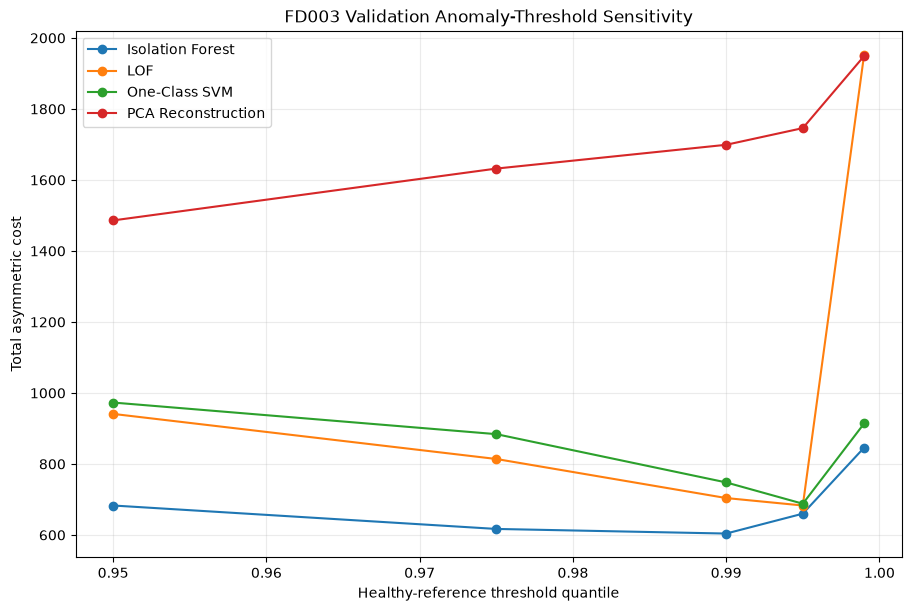

In [83]:
figure, axis = plt.subplots(
    figsize=(9, 6),
    constrained_layout=True,
)


for model_name, model_frame in (
    fd003_anomaly_threshold_search_df
    .groupby(
        "Model",
        sort=True,
    )
):
    model_frame = (
        model_frame
        .sort_values(
            "Healthy threshold quantile"
        )
    )


    axis.plot(
        model_frame[
            "Healthy threshold quantile"
        ],
        model_frame[
            "Total asymmetric cost"
        ],
        marker="o",
        label=model_name,
    )


axis.set_title(
    "FD003 Validation Anomaly-Threshold Sensitivity"
)

axis.set_xlabel(
    "Healthy-reference threshold quantile"
)

axis.set_ylabel(
    "Total asymmetric cost"
)

axis.grid(
    alpha=0.25,
)

axis.legend()


figure.savefig(
    FIGURES_DIR
    / "fd003_anomaly_threshold_sensitivity.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()
plt.close(
    figure
)

## 27. LOF Neighborhood Stability

LOF can be sensitive to the selected neighborhood size. Stability is checked
using four predeclared values:

- 10 neighbors;
- 20 neighbors;
- 35 neighbors;
- 50 neighbors.

The comparison reports discrimination metrics, fitting time, and Spearman
correlations between validation anomaly-score rankings.

In [84]:
fd003_lof_neighbor_grid = [
    10,
    20,
    35,
    50,
]


fd003_lof_neighborhood_rows = []

fd003_lof_neighborhood_score_map = {}


for neighbor_count in (
    fd003_lof_neighbor_grid
):
    lof_model = LocalOutlierFactor(
        n_neighbors=neighbor_count,
        novelty=True,
        contamination="auto",
        metric="minkowski",
        n_jobs=-1,
    )


    fit_start = perf_counter()

    lof_model.fit(
        fd003_X_anomaly_reference
    )

    fit_seconds = (
        perf_counter()
        - fit_start
    )


    reference_raw_scores = (
        -lof_model.decision_function(
            fd003_X_anomaly_reference
        )
    )

    validation_raw_scores = (
        -lof_model.decision_function(
            fd003_X_anomaly_validation
        )
    )


    normalization_result = (
        robust_normalize_fd003_anomaly_scores(
            reference_raw_scores,
            validation_raw_scores,
        )
    )


    reference_scores = (
        normalization_result[
            "normalized_reference"
        ]
    )

    validation_scores = (
        normalization_result[
            "normalized_evaluation"
        ]
    )


    threshold = float(
        np.quantile(
            reference_scores,
            0.99,
        )
    )


    metrics = (
        calculate_fd003_anomaly_metrics(
            y_true=(
                fd003_y_anomaly_validation
            ),
            normalized_scores=(
                validation_scores
            ),
            threshold=threshold,
            false_positive_cost=1.0,
            false_negative_cost=7.0,
        )
    )


    fd003_lof_neighborhood_rows.append(
        {
            "Neighbors": int(
                neighbor_count
            ),
            **metrics,
            "Fit time (seconds)": float(
                fit_seconds
            ),
        }
    )


    fd003_lof_neighborhood_score_map[
        f"neighbors_{neighbor_count}"
    ] = validation_scores


fd003_lof_neighborhood_stability_df = (
    pd.DataFrame(
        fd003_lof_neighborhood_rows
    )
    .sort_values(
        "Neighbors"
    )
    .reset_index(drop=True)
)


fd003_lof_score_correlation_df = (
    pd.DataFrame(
        fd003_lof_neighborhood_score_map
    )
    .corr(
        method="spearman"
    )
)


fd003_lof_neighborhood_stability_df.to_csv(
    TABLES_DIR
    / "fd003_lof_neighborhood_stability.csv",
    index=False,
)

fd003_lof_score_correlation_df.to_csv(
    TABLES_DIR
    / "fd003_lof_score_rank_correlations.csv",
)


display(
    fd003_lof_neighborhood_stability_df
    .round(6)
)

display(
    fd003_lof_score_correlation_df
    .round(6)
)

,Neighbors,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,True negatives,False positives,False negatives,True positives,Predicted positive rate,Total asymmetric cost,Cost per row,Fit time (seconds)
0,10,3.445154,0.381513,0.976344,0.548640,0.942447,0.692154,2487,736,11,454,0.322668,813.0,0.220445,0.134943
1,20,3.679132,0.404255,0.980645,0.572505,0.945524,0.711288,2551,672,9,456,0.305857,735.0,0.199295,0.124852
2,35,3.737882,0.413575,0.982796,0.582166,0.947185,0.716430,2575,648,8,457,0.299620,704.0,0.190889,0.149663
3,50,3.891396,0.420037,0.982796,0.588538,0.947856,0.718207,2592,631,8,457,0.295011,687.0,0.186280,0.156872


,neighbors_10,neighbors_20,neighbors_35,neighbors_50
neighbors_10,1.000000,0.986543,0.974447,0.965890
neighbors_20,0.986543,1.000000,0.992373,0.985349
neighbors_35,0.974447,0.992373,1.000000,0.996873
neighbors_50,0.965890,0.985349,0.996873,1.000000


## 28. One-Class SVM Scalability

The RBF One-Class SVM has superlinear computational cost. Its fitting time is
measured on progressively larger healthy-reference subsets.

The experiment is diagnostic only and does not alter the locked anomaly model.

In [85]:
fd003_ocsvm_sample_sizes = [
    500,
    1000,
    1500,
    len(
        fd003_X_anomaly_reference
    ),
]


fd003_ocsvm_scalability_rows = []


fd003_ocsvm_scalability_rng = (
    np.random.default_rng(
        RANDOM_STATE
        + 7
    )
)


for sample_size in (
    fd003_ocsvm_sample_sizes
):
    sampled_indices = (
        fd003_ocsvm_scalability_rng.choice(
            len(
                fd003_X_anomaly_reference
            ),
            size=sample_size,
            replace=False,
        )
    )


    sample_matrix = (
        fd003_X_anomaly_reference[
            sampled_indices
        ]
    )


    scalability_model = OneClassSVM(
        kernel="rbf",
        gamma="scale",
        nu=0.05,
    )


    fit_start = perf_counter()

    scalability_model.fit(
        sample_matrix
    )

    fit_seconds = (
        perf_counter()
        - fit_start
    )


    scoring_start = perf_counter()

    validation_scores = (
        scalability_model.decision_function(
            fd003_X_anomaly_validation
        )
    )

    scoring_seconds = (
        perf_counter()
        - scoring_start
    )


    fd003_ocsvm_scalability_rows.append(
        {
            "Training rows": int(
                sample_size
            ),
            "Feature count": int(
                sample_matrix.shape[1]
            ),
            "Fit time (seconds)": float(
                fit_seconds
            ),
            "Scoring time (seconds)": float(
                scoring_seconds
            ),
            "Scoring ms per 1000 rows": float(
                scoring_seconds
                * 1_000_000.0
                / len(
                    validation_scores
                )
            ),
            "Support-vector count": int(
                scalability_model.support_vectors_
                .shape[0]
            ),
            "Support-vector fraction": float(
                scalability_model.support_vectors_
                .shape[0]
                / sample_size
            ),
        }
    )


fd003_ocsvm_scalability_df = pd.DataFrame(
    fd003_ocsvm_scalability_rows
)


fd003_ocsvm_scalability_df.to_csv(
    TABLES_DIR
    / "fd003_ocsvm_scalability.csv",
    index=False,
)


display(
    fd003_ocsvm_scalability_df
    .round(6)
)

,Training rows,Feature count,Fit time (seconds),Scoring time (seconds),Scoring ms per 1000 rows,Support-vector count,Support-vector fraction
0,500,16,0.005575,0.028680,7.776491,60,0.120000
1,1000,16,0.009234,0.033749,9.151003,82,0.082000
2,1500,16,0.010600,0.044820,12.152820,111,0.074000
3,2100,16,0.021920,0.056526,15.326979,140,0.066667


## 29. PCA Reconstruction Sensor Contributions

PCA reconstruction error can be decomposed by sensor. The table below reports
the average standardized squared reconstruction error for validation
observations within 30 cycles of failure.

Larger values indicate sensors that contribute more strongly to PCA anomaly
evidence near failure.

In [86]:
fd003_pca_model = (
    fd003_anomaly_fitted_bundles[
        "PCA Reconstruction"
    ][
        "model"
    ]
)


fd003_pca_validation_reconstruction = (
    fd003_pca_model.inverse_transform(
        fd003_pca_model.transform(
            fd003_X_anomaly_validation
        )
    )
)


fd003_pca_validation_sensor_errors = (
    (
        fd003_X_anomaly_validation
        - fd003_pca_validation_reconstruction
    )
    ** 2
)


fd003_near_failure_validation_mask = (
    fd003_y_anomaly_validation
    == 1
)

fd003_healthy_validation_mask = (
    fd003_y_anomaly_validation
    == 0
)


fd003_pca_sensor_contribution_df = pd.DataFrame(
    {
        "Sensor": (
            fd003_anomaly_sensor_columns
        ),
        "Near-failure mean squared error": (
            fd003_pca_validation_sensor_errors[
                fd003_near_failure_validation_mask
            ]
            .mean(
                axis=0
            )
        ),
        "Non-near-failure mean squared error": (
            fd003_pca_validation_sensor_errors[
                fd003_healthy_validation_mask
            ]
            .mean(
                axis=0
            )
        ),
    }
)


fd003_pca_sensor_contribution_df[
    "Contribution ratio"
] = (
    fd003_pca_sensor_contribution_df[
        "Near-failure mean squared error"
    ]
    / np.maximum(
        fd003_pca_sensor_contribution_df[
            "Non-near-failure mean squared error"
        ],
        1e-12,
    )
)


fd003_pca_sensor_contribution_df = (
    fd003_pca_sensor_contribution_df
    .sort_values(
        [
            "Near-failure mean squared error",
            "Contribution ratio",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


fd003_pca_sensor_contribution_df.to_csv(
    TABLES_DIR
    / "fd003_pca_sensor_contributions.csv",
    index=False,
)


display(
    fd003_pca_sensor_contribution_df
    .round(6)
)

,Sensor,Near-failure mean squared error,Non-near-failure mean squared error,Contribution ratio
0,sensor_6,4.824572,0.550017,8.771671
1,sensor_15,2.304851,0.262737,8.772458
2,sensor_7,1.984403,0.264719,7.496254
3,sensor_12,1.555570,0.211675,7.348851
4,sensor_21,0.366703,0.041882,8.755571
5,sensor_20,0.360310,0.041138,8.758569
6,sensor_14,0.141355,0.089662,1.576529
7,sensor_9,0.107420,0.083188,1.291294
8,sensor_11,0.072067,0.008776,8.211799
9,sensor_4,0.060891,0.007138,8.530922


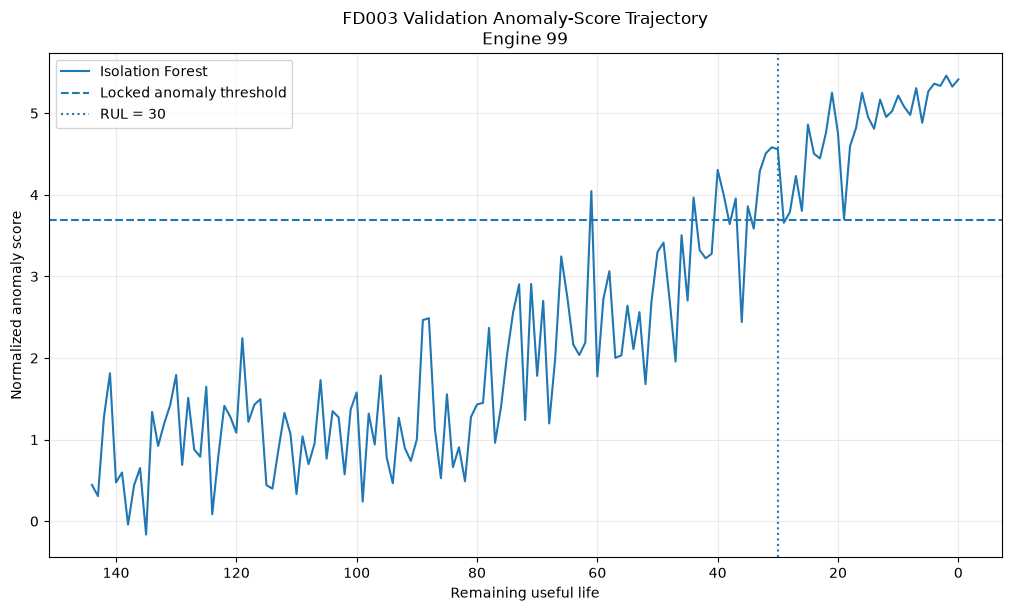

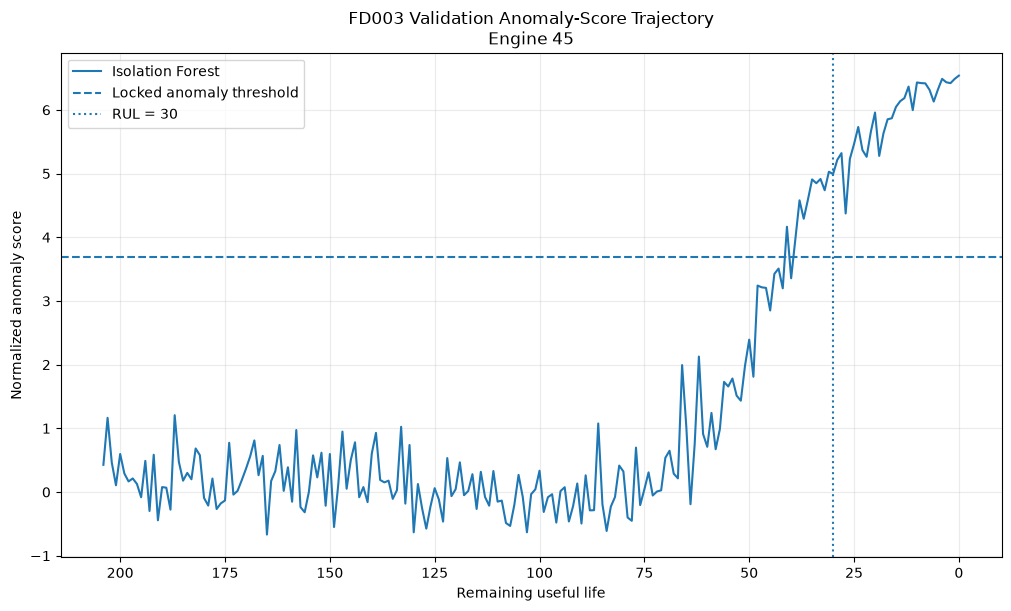

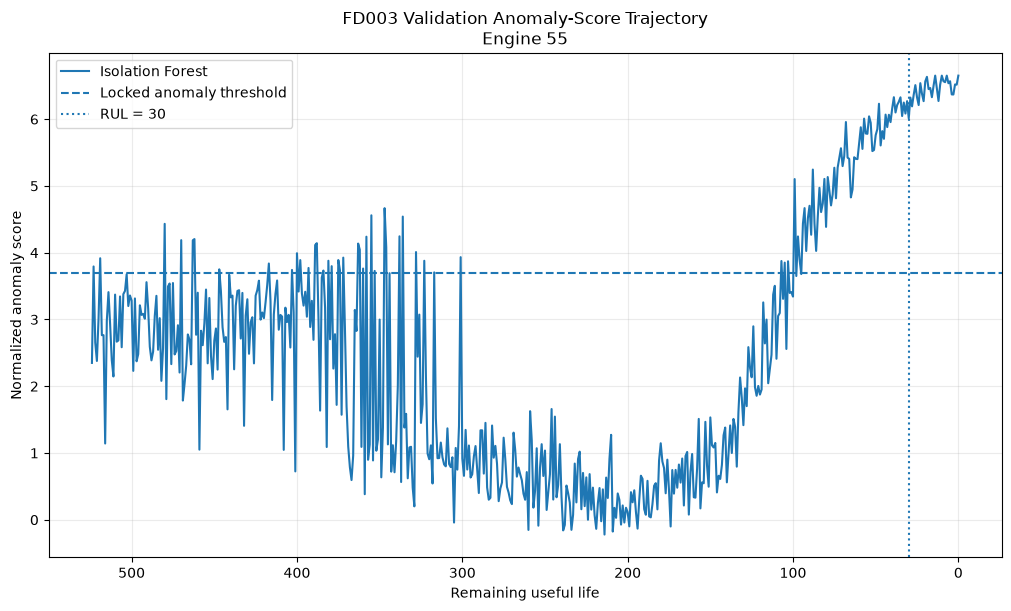

In [87]:
fd003_validation_engine_lengths = (
    fd003_validation_anomaly_scores_df
    .groupby(
        "engine_id"
    )
    .size()
    .sort_values()
)


fd003_anomaly_trajectory_engine_ids = [
    int(
        fd003_validation_engine_lengths
        .index[
            0
        ]
    ),
    int(
        fd003_validation_engine_lengths
        .index[
            len(
                fd003_validation_engine_lengths
            )
            // 2
        ]
    ),
    int(
        fd003_validation_engine_lengths
        .index[
            -1
        ]
    ),
]


for engine_id in (
    fd003_anomaly_trajectory_engine_ids
):
    engine_frame = (
        fd003_validation_anomaly_scores_df.loc[
            fd003_validation_anomaly_scores_df[
                "engine_id"
            ].eq(
                engine_id
            )
        ]
        .sort_values(
            "cycle"
        )
    )


    figure, axis = plt.subplots(
        figsize=(10, 6),
        constrained_layout=True,
    )


    axis.plot(
        engine_frame[
            "RUL"
        ],
        engine_frame[
            fd003_locked_anomaly_score_column
        ],
        label=(
            fd003_locked_anomaly_model_name
        ),
    )


    axis.axhline(
        fd003_locked_anomaly_threshold,
        linestyle="--",
        label="Locked anomaly threshold",
    )


    axis.axvline(
        30,
        linestyle=":",
        label="RUL = 30",
    )


    axis.invert_xaxis()

    axis.set_title(
        "FD003 Validation Anomaly-Score Trajectory\n"
        f"Engine {engine_id}"
    )

    axis.set_xlabel(
        "Remaining useful life"
    )

    axis.set_ylabel(
        "Normalized anomaly score"
    )

    axis.grid(
        alpha=0.25,
    )

    axis.legend()


    figure.savefig(
        FIGURES_DIR
        / (
            "fd003_validation_anomaly_trajectory_"
            f"engine_{engine_id}.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()
    plt.close(
        figure
    )

In [88]:
fd003_anomaly_contract_df = pd.DataFrame(
    [
        {
            "Dataset": "FD003",
            "Selection split": "Validation",
            "Healthy reference source": (
                "First 30 cycles of 70 training engines"
            ),
            "Healthy reference rows": len(
                fd003_anomaly_reference_df
            ),
            "Feature configuration": (
                "16 non-constant sensors"
            ),
            "Feature count": len(
                fd003_anomaly_sensor_columns
            ),
            "Compared models": (
                "Isolation Forest; LOF novelty=True; "
                "One-Class SVM; PCA Reconstruction"
            ),
            "Locked anomaly model": (
                fd003_locked_anomaly_model_name
            ),
            "Locked threshold quantile": (
                fd003_locked_anomaly_threshold_quantile
            ),
            "Locked normalized threshold": (
                fd003_locked_anomaly_threshold
            ),
            "Validation PR-AUC": float(
                fd003_locked_anomaly_row[
                    "PR-AUC"
                ]
            ),
            "Validation ROC-AUC": float(
                fd003_locked_anomaly_row[
                    "ROC-AUC"
                ]
            ),
            "Validation precision": float(
                fd003_locked_anomaly_row[
                    "Precision"
                ]
            ),
            "Validation recall": float(
                fd003_locked_anomaly_row[
                    "Recall"
                ]
            ),
            "Validation F1": float(
                fd003_locked_anomaly_row[
                    "F1"
                ]
            ),
            "Validation false positives": int(
                fd003_locked_anomaly_row[
                    "False positives"
                ]
            ),
            "Validation false negatives": int(
                fd003_locked_anomaly_row[
                    "False negatives"
                ]
            ),
            "Validation asymmetric cost": float(
                fd003_locked_anomaly_row[
                    "Total asymmetric cost"
                ]
            ),
            "Score normalization": (
                "Healthy-reference median and IQR"
            ),
            "Internal test accessed": False,
        }
    ]
)


fd003_anomaly_contract_df.to_csv(
    TABLES_DIR
    / "fd003_anomaly_contract.csv",
    index=False,
)


print(
    "FD003 anomaly model and threshold "
    "are locked using validation data only."
)


display(
    fd003_anomaly_contract_df
    .round(6)
)

FD003 anomaly model and threshold are locked using validation data only.


,Dataset,Selection split,Healthy reference source,Healthy reference rows,Feature configuration,Feature count,Compared models,Locked anomaly model,Locked threshold quantile,Locked normalized threshold,Validation PR-AUC,Validation ROC-AUC,Validation precision,Validation recall,Validation F1,Validation false positives,Validation false negatives,Validation asymmetric cost,Score normalization,Internal test accessed
0,FD003,Validation,First 30 cycles of 70 training engines,2100,16 non-constant sensors,16,Isolation Forest; LOF novelty=True; One-Class ...,Isolation Forest,0.99,3.690745,0.765117,0.961878,0.553687,0.92043,0.691438,345,37,604.0,Healthy-reference median and IQR,False


## 30. One-Time Internal-Test Anomaly Evaluation

All four anomaly detectors, their score orientations, healthy-reference
normalization parameters, and validation-selected thresholds are now locked.

This section performs the single permitted evaluation on the same 15
internal-test engines used by the regression and classification subsystems.

All four models are evaluated for a fair held-out comparison. Isolation Forest
is the validation-selected operational anomaly detector.

No model, neighborhood size, kernel parameter, PCA component rule, score
normalization, or anomaly threshold will be changed after observing these
results.

In [94]:
# ---------------------------------------------------------
# Standardize internal-test sensors using the scaler fitted
# exclusively on the healthy training reference.
# ---------------------------------------------------------

fd003_X_anomaly_internal_test = (
    fd003_anomaly_scaler.transform(
        fd003_internal_test_features_df[
            fd003_anomaly_sensor_columns
        ]
    )
)


fd003_y_anomaly_internal_test = (
    fd003_internal_test_features_df[
        "failure_within_30"
    ]
    .to_numpy(
        dtype=int
    )
)


assert (
    fd003_X_anomaly_internal_test.shape
    == (
        len(
            fd003_internal_test_features_df
        ),
        len(
            fd003_anomaly_sensor_columns
        ),
    )
)

assert (
    fd003_internal_test_features_df[
        "engine_id"
    ].nunique()
    == 15
)

assert np.isfinite(
    fd003_X_anomaly_internal_test
).all()

assert set(
    np.unique(
        fd003_y_anomaly_internal_test
    )
).issubset(
    {
        0,
        1,
    }
)


print(
    "Internal-test anomaly matrix:",
    fd003_X_anomaly_internal_test.shape,
)

print(
    "Internal-test engines:",
    fd003_internal_test_features_df[
        "engine_id"
    ].nunique(),
)

print(
    "Internal-test anomaly-positive rows:",
    int(
        fd003_y_anomaly_internal_test.sum()
    ),
)

Internal-test anomaly matrix: (3626, 16)
Internal-test engines: 15
Internal-test anomaly-positive rows: 465


In [95]:
def score_fd003_locked_anomaly_model(
    *,
    model_bundle,
    evaluation_matrix,
):
    model = model_bundle[
        "model"
    ]

    score_type = model_bundle[
        "score_type"
    ]


    if score_type == "decision_function":
        raw_scores = (
            -model.decision_function(
                evaluation_matrix
            )
        )

    elif score_type == "reconstruction":
        reconstruction = (
            model.inverse_transform(
                model.transform(
                    evaluation_matrix
                )
            )
        )

        raw_scores = np.mean(
            (
                evaluation_matrix
                - reconstruction
            )
            ** 2,
            axis=1,
        )

    else:
        raise ValueError(
            "Unknown locked anomaly score type: "
            f"{score_type}"
        )


    reference_median = float(
        model_bundle[
            "reference_median"
        ]
    )

    reference_scale = float(
        model_bundle[
            "reference_scale"
        ]
    )


    normalized_scores = (
        raw_scores
        - reference_median
    ) / reference_scale


    assert np.isfinite(
        raw_scores
    ).all()

    assert np.isfinite(
        normalized_scores
    ).all()


    return {
        "raw_scores": np.asarray(
            raw_scores,
            dtype=float,
        ),
        "normalized_scores": np.asarray(
            normalized_scores,
            dtype=float,
        ),
    }

In [96]:
# ---------------------------------------------------------
# Validation-locked threshold for every anomaly model.
# ---------------------------------------------------------

fd003_anomaly_threshold_by_model = {
    str(row["Model"]): float(
        row[
            "Threshold"
        ]
    )
    for _, row in (
        fd003_anomaly_validation_results_df
        .iterrows()
    )
}


fd003_anomaly_threshold_quantile_by_model = {
    str(row["Model"]): float(
        row[
            "Healthy threshold quantile"
        ]
    )
    for _, row in (
        fd003_anomaly_validation_results_df
        .iterrows()
    )
}


assert set(
    fd003_anomaly_threshold_by_model
) == set(
    fd003_anomaly_fitted_bundles
)


# ---------------------------------------------------------
# Score all four locked anomaly models.
# ---------------------------------------------------------

fd003_internal_test_anomaly_raw_score_map = {}

fd003_internal_test_anomaly_normalized_score_map = {}

fd003_internal_test_anomaly_result_rows = []


for model_name, model_bundle in (
    fd003_anomaly_fitted_bundles.items()
):
    print(
        "Evaluating locked anomaly model:",
        model_name,
    )


    score_start = perf_counter()


    scoring_result = (
        score_fd003_locked_anomaly_model(
            model_bundle=model_bundle,
            evaluation_matrix=(
                fd003_X_anomaly_internal_test
            ),
        )
    )


    scoring_seconds = (
        perf_counter()
        - score_start
    )


    raw_scores = scoring_result[
        "raw_scores"
    ]

    normalized_scores = scoring_result[
        "normalized_scores"
    ]


    threshold = (
        fd003_anomaly_threshold_by_model[
            model_name
        ]
    )


    metrics = calculate_fd003_anomaly_metrics(
        y_true=(
            fd003_y_anomaly_internal_test
        ),
        normalized_scores=(
            normalized_scores
        ),
        threshold=threshold,
        false_positive_cost=1.0,
        false_negative_cost=7.0,
    )


    fd003_internal_test_anomaly_result_rows.append(
        {
            "Dataset": (
                "FD003 internal test"
            ),
            "Model": model_name,
            "Healthy threshold quantile": (
                fd003_anomaly_threshold_quantile_by_model[
                    model_name
                ]
            ),
            **metrics,
            "Evaluation rows": int(
                len(
                    fd003_y_anomaly_internal_test
                )
            ),
            "Evaluation engines": int(
                fd003_internal_test_features_df[
                    "engine_id"
                ].nunique()
            ),
            "Feature count": len(
                fd003_anomaly_sensor_columns
            ),
            "Scoring time (seconds)": float(
                scoring_seconds
            ),
            "Scoring ms per 1000 rows": float(
                scoring_seconds
                * 1_000_000.0
                / len(
                    normalized_scores
                )
            ),
            "Locked operational model": bool(
                model_name
                == fd003_locked_anomaly_model_name
            ),
        }
    )


    fd003_internal_test_anomaly_raw_score_map[
        model_name
    ] = raw_scores

    fd003_internal_test_anomaly_normalized_score_map[
        model_name
    ] = normalized_scores


fd003_internal_test_anomaly_results_df = (
    pd.DataFrame(
        fd003_internal_test_anomaly_result_rows
    )
    .sort_values(
        [
            "Total asymmetric cost",
            "PR-AUC",
            "F1",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)


fd003_internal_test_anomaly_results_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_anomaly_results.csv",
    index=False,
)


print("=" * 72)
print("FD003 ONE-TIME INTERNAL-TEST ANOMALY EVALUATION COMPLETED")
print("=" * 72)


display(
    fd003_internal_test_anomaly_results_df
    .round(6)
)

Evaluating locked anomaly model: Isolation Forest
Evaluating locked anomaly model: LOF
Evaluating locked anomaly model: One-Class SVM
Evaluating locked anomaly model: PCA Reconstruction
FD003 ONE-TIME INTERNAL-TEST ANOMALY EVALUATION COMPLETED


,Dataset,Model,Healthy threshold quantile,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,True negatives,False positives,False negatives,True positives,Predicted positive rate,Total asymmetric cost,Cost per row,Evaluation rows,Evaluation engines,Feature count,Scoring time (seconds),Scoring ms per 1000 rows,Locked operational model
0,FD003 internal test,Isolation Forest,0.990,3.690745,0.570153,0.961290,0.715773,0.965862,0.762438,2824,337,18,447,0.216216,463.0,0.127689,3626,15,16,0.252999,69.773442,True
1,FD003 internal test,LOF,0.995,4.482940,0.452148,0.995699,0.621894,0.944737,0.650694,2600,561,2,463,0.282405,575.0,0.158577,3626,15,16,0.082382,22.719829,False
2,FD003 internal test,One-Class SVM,0.995,2.077513,0.434457,0.997849,0.605349,0.954497,0.726188,2557,604,1,464,0.294539,611.0,0.168505,3626,15,16,0.076249,21.028489,False
3,FD003 internal test,PCA Reconstruction,0.950,2.085699,0.363429,0.683871,0.474627,0.820042,0.500915,2604,557,147,318,0.241313,1586.0,0.437397,3626,15,16,0.012230,3.372780,False


In [97]:
fd003_internal_test_anomaly_scores_df = (
    fd003_internal_test_features_df[
        [
            "engine_id",
            "cycle",
            "RUL",
            "failure_within_30",
        ]
    ]
    .sort_values(
        [
            "engine_id",
            "cycle",
        ]
    )
    .reset_index(drop=True)
    .copy()
)


for model_name in (
    fd003_anomaly_fitted_bundles
):
    model_slug = (
        fd003_anomaly_column_slug(
            model_name
        )
    )


    fd003_internal_test_anomaly_scores_df[
        f"raw_anomaly_score_{model_slug}"
    ] = (
        fd003_internal_test_anomaly_raw_score_map[
            model_name
        ]
    )


    fd003_internal_test_anomaly_scores_df[
        f"normalized_anomaly_score_{model_slug}"
    ] = (
        fd003_internal_test_anomaly_normalized_score_map[
            model_name
        ]
    )


fd003_locked_internal_anomaly_score_column = (
    "normalized_anomaly_score_"
    + fd003_anomaly_column_slug(
        fd003_locked_anomaly_model_name
    )
)


fd003_internal_test_anomaly_scores_df[
    "locked_anomaly_score"
] = (
    fd003_internal_test_anomaly_scores_df[
        fd003_locked_internal_anomaly_score_column
    ]
)


fd003_internal_test_anomaly_scores_df[
    "direct_anomaly_alert"
] = (
    fd003_internal_test_anomaly_scores_df[
        "locked_anomaly_score"
    ]
    >= fd003_locked_anomaly_threshold
)


fd003_internal_test_anomaly_scores_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_anomaly_scores.csv",
    index=False,
)


display(
    fd003_internal_test_anomaly_scores_df.head()
)

,engine_id,cycle,RUL,failure_within_30,raw_anomaly_score_isolation_forest,normalized_anomaly_score_isolation_forest,raw_anomaly_score_lof,normalized_anomaly_score_lof,raw_anomaly_score_one_class_svm,normalized_anomaly_score_one_class_svm,raw_anomaly_score_pca_reconstruction,normalized_anomaly_score_pca_reconstruction,locked_anomaly_score,direct_anomaly_alert
0,9,1,405,0,-0.009095,1.350711,-0.450963,0.337595,-2.224551,0.246109,0.019850,-0.223415,1.350711,False
1,9,2,404,0,-0.034137,0.799432,-0.393667,1.131865,-2.219403,0.248490,0.093094,2.246311,0.799432,False
2,9,3,403,0,-0.005007,1.440688,-0.440940,0.476537,-0.911801,0.853397,0.123657,3.276866,1.440688,False
3,9,4,402,0,-0.015004,1.220620,-0.403270,0.998736,-1.544033,0.560922,0.094671,2.299491,1.220620,False
4,9,5,401,0,-0.012772,1.269753,-0.469896,0.075138,-1.745787,0.467589,0.147226,4.071586,1.269753,False


## 31. Persistent Operational Anomaly Alert

The operational Isolation Forest alert uses the same fixed persistence rule
applied elsewhere in the maintenance system:

> An anomaly alert becomes persistent when at least 2 of the most recent
> 3 cycles exceed the validation-locked anomaly threshold.

This rule is not tuned using FD003 internal-test results.

In [98]:
fd003_anomaly_persistence_required_alerts = 2
fd003_anomaly_persistence_window = 3


fd003_internal_test_anomaly_scores_df[
    "persistent_anomaly_alert"
] = (
    fd003_internal_test_anomaly_scores_df
    .groupby(
        "engine_id",
        sort=False,
    )[
        "direct_anomaly_alert"
    ]
    .transform(
        lambda alert_series: (
            alert_series
            .astype(int)
            .rolling(
                window=(
                    fd003_anomaly_persistence_window
                ),
                min_periods=(
                    fd003_anomaly_persistence_required_alerts
                ),
            )
            .sum()
            .ge(
                fd003_anomaly_persistence_required_alerts
            )
        )
    )
    .fillna(False)
    .astype(bool)
)


assert (
    fd003_internal_test_anomaly_scores_df[
        "persistent_anomaly_alert"
    ].dtype
    == bool
)


fd003_internal_test_anomaly_scores_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_anomaly_scores.csv",
    index=False,
)


print(
    "FD003 fixed 2-of-3 anomaly persistence applied."
)

display(
    fd003_internal_test_anomaly_scores_df.head()
)

FD003 fixed 2-of-3 anomaly persistence applied.


,engine_id,cycle,RUL,failure_within_30,raw_anomaly_score_isolation_forest,normalized_anomaly_score_isolation_forest,raw_anomaly_score_lof,normalized_anomaly_score_lof,raw_anomaly_score_one_class_svm,normalized_anomaly_score_one_class_svm,raw_anomaly_score_pca_reconstruction,normalized_anomaly_score_pca_reconstruction,locked_anomaly_score,direct_anomaly_alert,persistent_anomaly_alert
0,9,1,405,0,-0.009095,1.350711,-0.450963,0.337595,-2.224551,0.246109,0.019850,-0.223415,1.350711,False,False
1,9,2,404,0,-0.034137,0.799432,-0.393667,1.131865,-2.219403,0.248490,0.093094,2.246311,0.799432,False,False
2,9,3,403,0,-0.005007,1.440688,-0.440940,0.476537,-0.911801,0.853397,0.123657,3.276866,1.440688,False,False
3,9,4,402,0,-0.015004,1.220620,-0.403270,0.998736,-1.544033,0.560922,0.094671,2.299491,1.220620,False,False
4,9,5,401,0,-0.012772,1.269753,-0.469896,0.075138,-1.745787,0.467589,0.147226,4.071586,1.269753,False,False


In [99]:
def calculate_fd003_binary_anomaly_alert_metrics(
    *,
    y_true,
    predictions,
    false_positive_cost=1.0,
    false_negative_cost=7.0,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    predictions = np.asarray(
        predictions,
        dtype=int,
    )


    true_negative, false_positive, false_negative, true_positive = (
        confusion_matrix(
            y_true,
            predictions,
            labels=[
                0,
                1,
            ],
        )
        .ravel()
    )


    total_cost = (
        false_positive
        * false_positive_cost
        + false_negative
        * false_negative_cost
    )


    return {
        "Samples": int(
            len(
                y_true
            )
        ),
        "Predicted positive rate": float(
            predictions.mean()
        ),
        "Precision": float(
            precision_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "Recall": float(
            recall_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "F1": float(
            f1_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "True negatives": int(
            true_negative
        ),
        "False positives": int(
            false_positive
        ),
        "False negatives": int(
            false_negative
        ),
        "True positives": int(
            true_positive
        ),
        "Total asymmetric cost": float(
            total_cost
        ),
        "Cost per row": float(
            total_cost
            / len(
                y_true
            )
        ),
    }


fd003_anomaly_alert_comparison_rows = []


for alert_rule, alert_column in [
    (
        "Direct threshold",
        "direct_anomaly_alert",
    ),
    (
        "Persistent 2-of-3",
        "persistent_anomaly_alert",
    ),
]:
    alert_metrics = (
        calculate_fd003_binary_anomaly_alert_metrics(
            y_true=(
                fd003_y_anomaly_internal_test
            ),
            predictions=(
                fd003_internal_test_anomaly_scores_df[
                    alert_column
                ]
                .to_numpy(
                    dtype=int
                )
            ),
            false_positive_cost=1.0,
            false_negative_cost=7.0,
        )
    )


    fd003_anomaly_alert_comparison_rows.append(
        {
            "Dataset": (
                "FD003 internal test"
            ),
            "Model": (
                fd003_locked_anomaly_model_name
            ),
            "Alert rule": alert_rule,
            "Normalized threshold": (
                fd003_locked_anomaly_threshold
            ),
            **alert_metrics,
        }
    )


fd003_internal_test_anomaly_alert_comparison_df = (
    pd.DataFrame(
        fd003_anomaly_alert_comparison_rows
    )
)


fd003_internal_test_anomaly_alert_comparison_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_anomaly_alert_comparison.csv",
    index=False,
)


display(
    fd003_internal_test_anomaly_alert_comparison_df
    .round(6)
)

,Dataset,Model,Alert rule,Normalized threshold,Samples,Predicted positive rate,Precision,Recall,F1,True negatives,False positives,False negatives,True positives,Total asymmetric cost,Cost per row
0,FD003 internal test,Isolation Forest,Direct threshold,3.690745,3626,0.216216,0.570153,0.961290,0.715773,2824,337,18,447,463.0,0.127689
1,FD003 internal test,Isolation Forest,Persistent 2-of-3,3.690745,3626,0.208494,0.592593,0.963441,0.733825,2853,308,17,448,427.0,0.117761


## 32. Engine-Level Anomaly Early-Warning Analysis

The persistent anomaly alert is evaluated for every internal-test engine using:

- first persistent anomaly-alert cycle;
- RUL at the first persistent alert;
- detection within the final 30 cycles;
- delay after entering the final 30-cycle region;
- number of unnecessarily early alerts;
- engine-level miss rate.

In [100]:
fd003_anomaly_early_warning_engine_rows = []


for engine_id, engine_frame in (
    fd003_internal_test_anomaly_scores_df
    .groupby(
        "engine_id",
        sort=True,
    )
):
    engine_frame = (
        engine_frame
        .sort_values(
            "cycle"
        )
        .reset_index(drop=True)
    )


    persistent_alert_frame = (
        engine_frame.loc[
            engine_frame[
                "persistent_anomaly_alert"
            ]
        ]
    )


    final_30_frame = (
        engine_frame.loc[
            engine_frame[
                "RUL"
            ]
            <= 30
        ]
    )


    final_30_alert_frame = (
        final_30_frame.loc[
            final_30_frame[
                "persistent_anomaly_alert"
            ]
        ]
    )


    if persistent_alert_frame.empty:
        first_alert_cycle = np.nan
        first_alert_rul = np.nan
    else:
        first_alert_cycle = float(
            persistent_alert_frame.iloc[0][
                "cycle"
            ]
        )

        first_alert_rul = float(
            persistent_alert_frame.iloc[0][
                "RUL"
            ]
        )


    missed_final_30 = bool(
        final_30_alert_frame.empty
    )


    if missed_final_30:
        first_in_horizon_cycle = np.nan
        first_in_horizon_rul = np.nan
        late_delay = np.nan

    else:
        first_in_horizon_cycle = float(
            final_30_alert_frame.iloc[0][
                "cycle"
            ]
        )

        first_in_horizon_rul = float(
            final_30_alert_frame.iloc[0][
                "RUL"
            ]
        )

        late_delay = float(
            30.0
            - first_in_horizon_rul
        )


    early_alert_cycles = int(
        (
            engine_frame[
                "persistent_anomaly_alert"
            ]
            & (
                engine_frame[
                    "RUL"
                ]
                > 30
            )
        )
        .sum()
    )


    in_horizon_alert_cycles = int(
        (
            engine_frame[
                "persistent_anomaly_alert"
            ]
            & (
                engine_frame[
                    "RUL"
                ]
                <= 30
            )
        )
        .sum()
    )


    fd003_anomaly_early_warning_engine_rows.append(
        {
            "engine_id": int(
                engine_id
            ),
            "Engine rows": int(
                len(
                    engine_frame
                )
            ),
            "First persistent alert cycle": (
                first_alert_cycle
            ),
            "First persistent alert RUL": (
                first_alert_rul
            ),
            "First in-horizon alert cycle": (
                first_in_horizon_cycle
            ),
            "First in-horizon alert RUL": (
                first_in_horizon_rul
            ),
            "Late delay": late_delay,
            "Early alert cycles": (
                early_alert_cycles
            ),
            "In-horizon alert cycles": (
                in_horizon_alert_cycles
            ),
            "Missed final 30 cycles": (
                missed_final_30
            ),
        }
    )


fd003_anomaly_early_warning_per_engine_df = (
    pd.DataFrame(
        fd003_anomaly_early_warning_engine_rows
    )
)


fd003_detected_anomaly_engines_df = (
    fd003_anomaly_early_warning_per_engine_df.loc[
        ~fd003_anomaly_early_warning_per_engine_df[
            "Missed final 30 cycles"
        ]
    ]
)


fd003_anomaly_early_warning_summary_df = (
    pd.DataFrame(
        [
            {
                "Dataset": (
                    "FD003 internal test"
                ),
                "Model": (
                    fd003_locked_anomaly_model_name
                ),
                "Persistence rule": "2-of-3",
                "Engines": int(
                    len(
                        fd003_anomaly_early_warning_per_engine_df
                    )
                ),
                "Detected engines": int(
                    len(
                        fd003_detected_anomaly_engines_df
                    )
                ),
                "Missed engines": int(
                    fd003_anomaly_early_warning_per_engine_df[
                        "Missed final 30 cycles"
                    ].sum()
                ),
                "Detection rate": float(
                    (
                        ~fd003_anomaly_early_warning_per_engine_df[
                            "Missed final 30 cycles"
                        ]
                    ).mean()
                ),
                "Miss rate": float(
                    fd003_anomaly_early_warning_per_engine_df[
                        "Missed final 30 cycles"
                    ].mean()
                ),
                "Mean first-alert RUL": float(
                    fd003_anomaly_early_warning_per_engine_df[
                        "First persistent alert RUL"
                    ].mean()
                ),
                "Median first-alert RUL": float(
                    fd003_anomaly_early_warning_per_engine_df[
                        "First persistent alert RUL"
                    ].median()
                ),
                "Mean late delay": float(
                    fd003_detected_anomaly_engines_df[
                        "Late delay"
                    ].mean()
                ),
                "Median late delay": float(
                    fd003_detected_anomaly_engines_df[
                        "Late delay"
                    ].median()
                ),
                "Mean early alert cycles": float(
                    fd003_anomaly_early_warning_per_engine_df[
                        "Early alert cycles"
                    ].mean()
                ),
                "Median early alert cycles": float(
                    fd003_anomaly_early_warning_per_engine_df[
                        "Early alert cycles"
                    ].median()
                ),
                "Maximum early alert cycles": int(
                    fd003_anomaly_early_warning_per_engine_df[
                        "Early alert cycles"
                    ].max()
                ),
            }
        ]
    )
)


fd003_anomaly_early_warning_per_engine_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_anomaly_early_warning_per_engine.csv",
    index=False,
)

fd003_anomaly_early_warning_summary_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_anomaly_early_warning_summary.csv",
    index=False,
)


display(
    fd003_anomaly_early_warning_summary_df
    .round(6)
)

display(
    fd003_anomaly_early_warning_per_engine_df
    .sort_values(
        [
            "Missed final 30 cycles",
            "Late delay",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(15)
    .round(6)
)

,Dataset,Model,Persistence rule,Engines,Detected engines,Missed engines,Detection rate,Miss rate,Mean first-alert RUL,Median first-alert RUL,Mean late delay,Median late delay,Mean early alert cycles,Median early alert cycles,Maximum early alert cycles
0,FD003 internal test,Isolation Forest,2-of-3,15,15,0,1.0,0.0,60.666667,41.0,0.866667,0.0,20.533333,11.0,117


,engine_id,Engine rows,First persistent alert cycle,First persistent alert RUL,First in-horizon alert cycle,First in-horizon alert RUL,Late delay,Early alert cycles,In-horizon alert cycles,Missed final 30 cycles
12,66,165,139.0,26.0,139.0,26.0,4.0,0,27,False
11,65,234,207.0,27.0,207.0,27.0,3.0,0,27,False
2,14,207,179.0,28.0,179.0,28.0,2.0,0,29,False
5,23,196,168.0,28.0,168.0,28.0,2.0,0,29,False
6,36,324,287.0,37.0,296.0,28.0,2.0,7,29,False
0,9,406,249.0,157.0,376.0,30.0,0.0,117,31,False
1,13,185,133.0,52.0,155.0,30.0,0.0,13,31,False
3,15,202,129.0,73.0,172.0,30.0,0.0,33,31,False
4,20,338,251.0,87.0,308.0,30.0,0.0,57,31,False
7,37,324,262.0,62.0,294.0,30.0,0.0,32,31,False


In [101]:
fd003_anomaly_contract_df.loc[
    0,
    "Internal test accessed"
] = True


fd003_anomaly_contract_df[
    "Internal-test evaluation count"
] = 1

fd003_anomaly_contract_df[
    "Post-evaluation tuning permitted"
] = False

fd003_anomaly_contract_df[
    "Persistence rule"
] = "2-of-3"

fd003_anomaly_contract_df[
    "Persistence tuning source"
] = (
    "Fixed operational protocol; "
    "not tuned on FD003 internal test"
)

fd003_anomaly_contract_df[
    "Internal-test comparison includes all models"
] = True


locked_internal_result = (
    fd003_internal_test_anomaly_results_df.loc[
        fd003_internal_test_anomaly_results_df[
            "Model"
        ].eq(
            fd003_locked_anomaly_model_name
        )
    ]
    .iloc[0]
)


fd003_anomaly_contract_df[
    "Internal-test precision"
] = float(
    locked_internal_result[
        "Precision"
    ]
)

fd003_anomaly_contract_df[
    "Internal-test recall"
] = float(
    locked_internal_result[
        "Recall"
    ]
)

fd003_anomaly_contract_df[
    "Internal-test F1"
] = float(
    locked_internal_result[
        "F1"
    ]
)

fd003_anomaly_contract_df[
    "Internal-test PR-AUC"
] = float(
    locked_internal_result[
        "PR-AUC"
    ]
)

fd003_anomaly_contract_df[
    "Internal-test asymmetric cost"
] = float(
    locked_internal_result[
        "Total asymmetric cost"
    ]
)


fd003_anomaly_contract_df.to_csv(
    TABLES_DIR
    / "fd003_anomaly_contract.csv",
    index=False,
)


assert bool(
    fd003_anomaly_contract_df.iloc[0][
        "Internal test accessed"
    ]
)

assert int(
    fd003_anomaly_contract_df.iloc[0][
        "Internal-test evaluation count"
    ]
) == 1

assert not bool(
    fd003_anomaly_contract_df.iloc[0][
        "Post-evaluation tuning permitted"
    ]
)


print(
    "FD003 anomaly internal-test results are now frozen."
)

display(
    fd003_anomaly_contract_df
    .round(6)
)

FD003 anomaly internal-test results are now frozen.


,Dataset,Selection split,Healthy reference source,Healthy reference rows,Feature configuration,Feature count,Compared models,Locked anomaly model,Locked threshold quantile,Locked normalized threshold,Validation PR-AUC,Validation ROC-AUC,Validation precision,Validation recall,Validation F1,Validation false positives,Validation false negatives,Validation asymmetric cost,Score normalization,Internal test accessed,Internal-test evaluation count,Post-evaluation tuning permitted,Persistence rule,Persistence tuning source,Internal-test comparison includes all models,Internal-test precision,Internal-test recall,Internal-test F1,Internal-test PR-AUC,Internal-test asymmetric cost
0,FD003,Validation,First 30 cycles of 70 training engines,2100,16 non-constant sensors,16,Isolation Forest; LOF novelty=True; One-Class ...,Isolation Forest,0.99,3.690745,0.765117,0.961878,0.553687,0.92043,0.691438,345,37,604.0,Healthy-reference median and IQR,True,1,False,2-of-3,Fixed operational protocol; not tuned on FD003...,True,0.570153,0.96129,0.715773,0.762438,463.0


## 33. Engine-Level Bootstrap for Anomaly Detection

Uncertainty in anomaly-detection performance is estimated by resampling
complete internal-test engines.

The validation-locked Isolation Forest model, normalized threshold, and fixed
2-of-3 persistence rule remain unchanged.

Separate confidence intervals are reported for:

- direct threshold alerts;
- persistent 2-of-3 alerts;
- continuous anomaly-score discrimination.

This analysis is diagnostic and does not permit post-test tuning.

In [106]:
# ---------------------------------------------------------
# Anomaly bootstrap configuration.
# ---------------------------------------------------------

fd003_anomaly_bootstrap_repetitions = 5000
fd003_anomaly_bootstrap_confidence = 0.95

fd003_anomaly_bootstrap_alpha = (
    1.0
    - fd003_anomaly_bootstrap_confidence
)

fd003_anomaly_bootstrap_rng = (
    np.random.default_rng(
        RANDOM_STATE
        + 3303
    )
)


fd003_anomaly_bootstrap_engine_ids = np.array(
    sorted(
        fd003_internal_test_anomaly_scores_df[
            "engine_id"
        ]
        .astype(int)
        .unique()
    ),
    dtype=int,
)


assert len(
    fd003_anomaly_bootstrap_engine_ids
) == 15


fd003_anomaly_bootstrap_engine_frames = {
    int(engine_id): (
        fd003_internal_test_anomaly_scores_df.loc[
            fd003_internal_test_anomaly_scores_df[
                "engine_id"
            ].eq(
                engine_id
            )
        ]
        .sort_values(
            "cycle"
        )
        .reset_index(drop=True)
    )
    for engine_id
    in fd003_anomaly_bootstrap_engine_ids
}

In [107]:
def calculate_fd003_anomaly_bootstrap_metrics(
    *,
    y_true,
    anomaly_scores,
    predictions,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    anomaly_scores = np.asarray(
        anomaly_scores,
        dtype=float,
    )

    predictions = np.asarray(
        predictions,
        dtype=int,
    )


    true_negative, false_positive, false_negative, true_positive = (
        confusion_matrix(
            y_true,
            predictions,
            labels=[
                0,
                1,
            ],
        )
        .ravel()
    )


    total_asymmetric_cost = (
        false_positive
        + (
            7.0
            * false_negative
        )
    )


    if np.unique(
        y_true
    ).size == 2:
        roc_auc = float(
            roc_auc_score(
                y_true,
                anomaly_scores,
            )
        )

        pr_auc = float(
            average_precision_score(
                y_true,
                anomaly_scores,
            )
        )

    else:
        roc_auc = np.nan
        pr_auc = np.nan


    return {
        "Precision": float(
            precision_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "Recall": float(
            recall_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "F1": float(
            f1_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "False positives": float(
            false_positive
        ),
        "False negatives": float(
            false_negative
        ),
        "True positives": float(
            true_positive
        ),
        "True negatives": float(
            true_negative
        ),
        "Total asymmetric cost": float(
            total_asymmetric_cost
        ),
        "Cost per row": float(
            total_asymmetric_cost
            / len(
                y_true
            )
        ),
    }

In [109]:
fd003_anomaly_bootstrap_rows = []


for bootstrap_index in range(
    fd003_anomaly_bootstrap_repetitions
):
    sampled_engine_ids = (
        fd003_anomaly_bootstrap_rng.choice(
            fd003_anomaly_bootstrap_engine_ids,
            size=len(
                fd003_anomaly_bootstrap_engine_ids
            ),
            replace=True,
        )
    )


    sampled_y_true = np.concatenate(
        [
            fd003_anomaly_bootstrap_engine_frames[
                int(
                    engine_id
                )
            ][
                "failure_within_30"
            ]
            .to_numpy(
                dtype=int
            )
            for engine_id
            in sampled_engine_ids
        ]
    )


    sampled_scores = np.concatenate(
        [
            fd003_anomaly_bootstrap_engine_frames[
                int(
                    engine_id
                )
            ][
                "locked_anomaly_score"
            ]
            .to_numpy(
                dtype=float
            )
            for engine_id
            in sampled_engine_ids
        ]
    )


    sampled_direct_predictions = np.concatenate(
        [
            fd003_anomaly_bootstrap_engine_frames[
                int(
                    engine_id
                )
            ][
                "direct_anomaly_alert"
            ]
            .to_numpy(
                dtype=int
            )
            for engine_id
            in sampled_engine_ids
        ]
    )


    sampled_persistent_predictions = np.concatenate(
        [
            fd003_anomaly_bootstrap_engine_frames[
                int(
                    engine_id
                )
            ][
                "persistent_anomaly_alert"
            ]
            .to_numpy(
                dtype=int
            )
            for engine_id
            in sampled_engine_ids
        ]
    )


    direct_metrics = (
        calculate_fd003_anomaly_bootstrap_metrics(
            y_true=sampled_y_true,
            anomaly_scores=sampled_scores,
            predictions=(
                sampled_direct_predictions
            ),
        )
    )


    persistent_metrics = (
        calculate_fd003_anomaly_bootstrap_metrics(
            y_true=sampled_y_true,
            anomaly_scores=sampled_scores,
            predictions=(
                sampled_persistent_predictions
            ),
        )
    )


    for alert_rule, metrics in [
        (
            "Direct threshold",
            direct_metrics,
        ),
        (
            "Persistent 2-of-3",
            persistent_metrics,
        ),
    ]:
        fd003_anomaly_bootstrap_rows.append(
            {
                "Bootstrap sample": int(
                    bootstrap_index
                    + 1
                ),
                "Alert rule": alert_rule,
                "Sampled engines": int(
                    len(
                        sampled_engine_ids
                    )
                ),
                "Sampled rows": int(
                    len(
                        sampled_y_true
                    )
                ),
                **metrics,
            }
        )


    if (
        bootstrap_index
        + 1
    ) % 1000 == 0:
        print(
            "Completed anomaly bootstrap samples:",
            bootstrap_index + 1,
        )


fd003_internal_test_anomaly_bootstrap_df = (
    pd.DataFrame(
        fd003_anomaly_bootstrap_rows
    )
)


fd003_internal_test_anomaly_bootstrap_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_anomaly_bootstrap_samples.csv",
    index=False,
)


print(
    "FD003 engine-level anomaly bootstrap completed."
)

Completed anomaly bootstrap samples: 1000
Completed anomaly bootstrap samples: 2000
Completed anomaly bootstrap samples: 3000
Completed anomaly bootstrap samples: 4000
Completed anomaly bootstrap samples: 5000
FD003 engine-level anomaly bootstrap completed.


In [110]:
fd003_anomaly_bootstrap_metric_names = [
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC",
    "False positives",
    "False negatives",
    "Total asymmetric cost",
    "Cost per row",
]


fd003_anomaly_point_estimate_map = {}


for alert_rule, alert_column in [
    (
        "Direct threshold",
        "direct_anomaly_alert",
    ),
    (
        "Persistent 2-of-3",
        "persistent_anomaly_alert",
    ),
]:
    fd003_anomaly_point_estimate_map[
        alert_rule
    ] = (
        calculate_fd003_anomaly_bootstrap_metrics(
            y_true=(
                fd003_internal_test_anomaly_scores_df[
                    "failure_within_30"
                ]
                .to_numpy(
                    dtype=int
                )
            ),
            anomaly_scores=(
                fd003_internal_test_anomaly_scores_df[
                    "locked_anomaly_score"
                ]
                .to_numpy(
                    dtype=float
                )
            ),
            predictions=(
                fd003_internal_test_anomaly_scores_df[
                    alert_column
                ]
                .to_numpy(
                    dtype=int
                )
            ),
        )
    )


fd003_anomaly_ci_rows = []


for alert_rule in [
    "Direct threshold",
    "Persistent 2-of-3",
]:
    rule_bootstrap_df = (
        fd003_internal_test_anomaly_bootstrap_df.loc[
            fd003_internal_test_anomaly_bootstrap_df[
                "Alert rule"
            ].eq(
                alert_rule
            )
        ]
    )


    for metric_name in (
        fd003_anomaly_bootstrap_metric_names
    ):
        bootstrap_values = (
            rule_bootstrap_df[
                metric_name
            ]
            .to_numpy(
                dtype=float
            )
        )


        fd003_anomaly_ci_rows.append(
            {
                "Alert rule": alert_rule,
                "Metric": metric_name,
                "Estimate": float(
                    fd003_anomaly_point_estimate_map[
                        alert_rule
                    ][
                        metric_name
                    ]
                ),
                "CI lower": float(
                    np.nanquantile(
                        bootstrap_values,
                        (
                            fd003_anomaly_bootstrap_alpha
                            / 2.0
                        ),
                    )
                ),
                "CI upper": float(
                    np.nanquantile(
                        bootstrap_values,
                        (
                            1.0
                            - fd003_anomaly_bootstrap_alpha
                            / 2.0
                        ),
                    )
                ),
                "Confidence level": (
                    fd003_anomaly_bootstrap_confidence
                ),
                "Method": (
                    "Engine-level percentile bootstrap"
                ),
                "Bootstrap samples": (
                    fd003_anomaly_bootstrap_repetitions
                ),
                "Engine count": int(
                    len(
                        fd003_anomaly_bootstrap_engine_ids
                    )
                ),
            }
        )


fd003_internal_test_anomaly_ci_df = (
    pd.DataFrame(
        fd003_anomaly_ci_rows
    )
)


fd003_internal_test_anomaly_ci_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_anomaly_confidence_intervals.csv",
    index=False,
)


display(
    fd003_internal_test_anomaly_ci_df
    .round(6)
)

,Alert rule,Metric,Estimate,CI lower,CI upper,Confidence level,Method,Bootstrap samples,Engine count
0,Direct threshold,Precision,0.570153,0.429921,0.753448,0.95,Engine-level percentile bootstrap,5000,15
1,Direct threshold,Recall,0.961290,0.933333,0.984946,0.95,Engine-level percentile bootstrap,5000,15
2,Direct threshold,F1,0.715773,0.596051,0.839078,0.95,Engine-level percentile bootstrap,5000,15
3,Direct threshold,ROC-AUC,0.965862,0.948006,0.987595,0.95,Engine-level percentile bootstrap,5000,15
4,Direct threshold,PR-AUC,0.762438,0.674476,0.938668,0.95,Engine-level percentile bootstrap,5000,15
5,Direct threshold,False positives,337.000000,144.000000,602.000000,0.95,Engine-level percentile bootstrap,5000,15
6,Direct threshold,False negatives,18.000000,7.000000,31.000000,0.95,Engine-level percentile bootstrap,5000,15
7,Direct threshold,Total asymmetric cost,463.000000,296.000000,692.025000,0.95,Engine-level percentile bootstrap,5000,15
8,Direct threshold,Cost per row,0.127689,0.087272,0.173776,0.95,Engine-level percentile bootstrap,5000,15
9,Persistent 2-of-3,Precision,0.592593,0.445944,0.783698,0.95,Engine-level percentile bootstrap,5000,15


## 34. Split Conformal RUL Uncertainty

A symmetric 95% split-conformal interval is calibrated from absolute
validation residuals of the locked FD003 regression model.

The regression model, feature schema, prediction ceiling, and safety offset
remain unchanged.

For every internal-test observation:

\[
RUL_{lower} =
\max(0,\widehat{RUL}-q)
\]

\[
RUL_{upper} =
\widehat{RUL}+q
\]

where \(q\) is the finite-sample conformal quantile calculated exclusively from
validation residuals.

Because the same validation split was previously used for model selection,
coverage is interpreted as an empirical uncertainty estimate rather than a
strict untouched-calibration guarantee.

In [111]:
# ---------------------------------------------------------
# Validation predictions from the locked regression model.
# ---------------------------------------------------------

fd003_conformal_validation_raw_predictions = np.asarray(
    fd003_finalist_prediction_map[
        fd003_locked_regression_candidate
    ],
    dtype=float,
)


if (
    fd003_locked_prediction_ceiling
    is None
):
    fd003_conformal_validation_ceiling_predictions = (
        fd003_conformal_validation_raw_predictions
        .copy()
    )
else:
    fd003_conformal_validation_ceiling_predictions = (
        np.minimum(
            fd003_conformal_validation_raw_predictions,
            fd003_locked_prediction_ceiling,
        )
    )


fd003_conformal_validation_predictions = np.clip(
    (
        fd003_conformal_validation_ceiling_predictions
        - fd003_locked_safety_offset
    ),
    a_min=0.0,
    a_max=None,
)


fd003_conformal_validation_actual = (
    fd003_y_validation
    .to_numpy(
        dtype=float
    )
)


assert len(
    fd003_conformal_validation_predictions
) == len(
    fd003_conformal_validation_actual
)


fd003_conformal_validation_residuals = np.abs(
    fd003_conformal_validation_actual
    - fd003_conformal_validation_predictions
)


assert np.isfinite(
    fd003_conformal_validation_residuals
).all()

In [112]:
fd003_conformal_confidence_level = 0.95

fd003_conformal_alpha = (
    1.0
    - fd003_conformal_confidence_level
)


fd003_conformal_calibration_count = len(
    fd003_conformal_validation_residuals
)


fd003_conformal_quantile_level = min(
    1.0,
    (
        np.ceil(
            (
                fd003_conformal_calibration_count
                + 1
            )
            * fd003_conformal_confidence_level
        )
        / fd003_conformal_calibration_count
    ),
)


fd003_conformal_quantile = float(
    np.quantile(
        fd003_conformal_validation_residuals,
        fd003_conformal_quantile_level,
        method="higher",
    )
)


fd003_conformal_quantile_df = pd.DataFrame(
    [
        {
            "Dataset": "FD003",
            "Calibration split": "Validation",
            "Calibration rows": (
                fd003_conformal_calibration_count
            ),
            "Confidence level": (
                fd003_conformal_confidence_level
            ),
            "Finite-sample quantile level": (
                fd003_conformal_quantile_level
            ),
            "Conformal quantile": (
                fd003_conformal_quantile
            ),
            "Nominal symmetric width": (
                2.0
                * fd003_conformal_quantile
            ),
            "Point model": (
                fd003_locked_regression_candidate
            ),
            "Prediction ceiling": (
                fd003_locked_prediction_ceiling
            ),
            "Safety offset": (
                fd003_locked_safety_offset
            ),
        }
    ]
)


fd003_conformal_quantile_df.to_csv(
    TABLES_DIR
    / "fd003_conformal_quantile.csv",
    index=False,
)


display(
    fd003_conformal_quantile_df
    .round(6)
)

,Dataset,Calibration split,Calibration rows,Confidence level,Finite-sample quantile level,Conformal quantile,Nominal symmetric width,Point model,Prediction ceiling,Safety offset
0,FD003,Validation,3688,0.95,0.95038,134.019912,268.039823,Ridge — Temporal | alpha=1000,300.0,0.0


In [113]:
fd003_internal_test_conformal_df = (
    fd003_internal_test_predictions_df[
        [
            "engine_id",
            "cycle",
            "RUL",
            "Predicted RUL",
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


fd003_internal_test_conformal_df[
    "RUL lower"
] = np.maximum(
    0.0,
    (
        fd003_internal_test_conformal_df[
            "Predicted RUL"
        ]
        - fd003_conformal_quantile
    ),
)


fd003_internal_test_conformal_df[
    "RUL upper"
] = (
    fd003_internal_test_conformal_df[
        "Predicted RUL"
    ]
    + fd003_conformal_quantile
)


fd003_internal_test_conformal_df[
    "Interval width"
] = (
    fd003_internal_test_conformal_df[
        "RUL upper"
    ]
    - fd003_internal_test_conformal_df[
        "RUL lower"
    ]
)


fd003_internal_test_conformal_df[
    "Covered"
] = (
    (
        fd003_internal_test_conformal_df[
            "RUL"
        ]
        >= fd003_internal_test_conformal_df[
            "RUL lower"
        ]
    )
    & (
        fd003_internal_test_conformal_df[
            "RUL"
        ]
        <= fd003_internal_test_conformal_df[
            "RUL upper"
        ]
    )
)


fd003_internal_test_conformal_df[
    "Lower miss"
] = (
    fd003_internal_test_conformal_df[
        "RUL"
    ]
    < fd003_internal_test_conformal_df[
        "RUL lower"
    ]
)


fd003_internal_test_conformal_df[
    "Upper miss"
] = (
    fd003_internal_test_conformal_df[
        "RUL"
    ]
    > fd003_internal_test_conformal_df[
        "RUL upper"
    ]
)


for horizon in [
    10,
    20,
    30,
]:
    fd003_internal_test_conformal_df[
        f"Uncertainty risk {horizon}"
    ] = (
        fd003_internal_test_conformal_df[
            "RUL lower"
        ]
        <= horizon
    )


assert (
    fd003_internal_test_conformal_df[
        "RUL lower"
    ]
    >= 0.0
).all()

assert (
    fd003_internal_test_conformal_df[
        "RUL upper"
    ]
    >= fd003_internal_test_conformal_df[
        "RUL lower"
    ]
).all()


fd003_internal_test_conformal_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_conformal_intervals.csv",
    index=False,
)


display(
    fd003_internal_test_conformal_df.head()
)

,engine_id,cycle,RUL,Predicted RUL,RUL lower,RUL upper,Interval width,Covered,Lower miss,Upper miss,Uncertainty risk 10,Uncertainty risk 20,Uncertainty risk 30
0,9,1,405,235.772398,101.752486,369.792309,268.039823,False,False,True,False,False,False
1,9,2,404,234.766016,100.746104,368.785927,268.039823,False,False,True,False,False,False
2,9,3,403,203.130916,69.111004,337.150828,268.039823,False,False,True,False,False,False
3,9,4,402,188.312611,54.292700,322.332523,268.039823,False,False,True,False,False,False
4,9,5,401,187.046312,53.026400,321.066223,268.039823,False,False,True,False,False,False


In [114]:
fd003_internal_test_conformal_summary_df = pd.DataFrame(
    [
        {
            "Dataset": (
                "FD003 internal test"
            ),
            "Confidence level": (
                fd003_conformal_confidence_level
            ),
            "Conformal quantile": (
                fd003_conformal_quantile
            ),
            "Samples": int(
                len(
                    fd003_internal_test_conformal_df
                )
            ),
            "Engines": int(
                fd003_internal_test_conformal_df[
                    "engine_id"
                ].nunique()
            ),
            "Coverage": float(
                fd003_internal_test_conformal_df[
                    "Covered"
                ].mean()
            ),
            "Average width": float(
                fd003_internal_test_conformal_df[
                    "Interval width"
                ].mean()
            ),
            "Median width": float(
                fd003_internal_test_conformal_df[
                    "Interval width"
                ].median()
            ),
            "Minimum width": float(
                fd003_internal_test_conformal_df[
                    "Interval width"
                ].min()
            ),
            "Maximum width": float(
                fd003_internal_test_conformal_df[
                    "Interval width"
                ].max()
            ),
            "Lower misses": int(
                fd003_internal_test_conformal_df[
                    "Lower miss"
                ].sum()
            ),
            "Upper misses": int(
                fd003_internal_test_conformal_df[
                    "Upper miss"
                ].sum()
            ),
            "Total misses": int(
                (
                    ~fd003_internal_test_conformal_df[
                        "Covered"
                    ]
                ).sum()
            ),
        }
    ]
)


fd003_internal_test_conformal_summary_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_conformal_summary.csv",
    index=False,
)


display(
    fd003_internal_test_conformal_summary_df
    .round(6)
)

,Dataset,Confidence level,Conformal quantile,Samples,Engines,Coverage,Average width,Median width,Minimum width,Maximum width,Lower misses,Upper misses,Total misses
0,FD003 internal test,0.95,134.019912,3626,15,0.950359,235.296728,263.358113,134.019912,268.039823,71,109,180


In [115]:
def fd003_conformal_rul_region(
    rul_value,
):
    if rul_value <= 30:
        return "Near failure: RUL 0–30"

    if rul_value <= 125:
        return "Mid life: RUL 31–125"

    return "Early life: RUL > 125"


fd003_internal_test_conformal_df[
    "RUL region"
] = (
    fd003_internal_test_conformal_df[
        "RUL"
    ]
    .map(
        fd003_conformal_rul_region
    )
)


fd003_internal_test_conformal_region_df = (
    fd003_internal_test_conformal_df
    .groupby(
        "RUL region",
        as_index=False,
        sort=False,
    )
    .agg(
        Samples=(
            "Covered",
            "size",
        ),
        Coverage=(
            "Covered",
            "mean",
        ),
        Average_width=(
            "Interval width",
            "mean",
        ),
        Median_width=(
            "Interval width",
            "median",
        ),
        Lower_misses=(
            "Lower miss",
            "sum",
        ),
        Upper_misses=(
            "Upper miss",
            "sum",
        ),
    )
)


fd003_internal_test_conformal_region_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_conformal_regions.csv",
    index=False,
)


display(
    fd003_internal_test_conformal_region_df
    .round(6)
)

,RUL region,Samples,Coverage,Average_width,Median_width,Lower_misses,Upper_misses
0,Early life: RUL > 125,1736,0.914747,263.859937,268.039823,39,109
1,Mid life: RUL 31–125,1425,0.977544,228.793627,232.095620,32,0
2,Near failure: RUL 0–30,465,1.000000,148.589603,134.019912,0,0


In [116]:
fd003_conformal_bootstrap_repetitions = 5000

fd003_conformal_bootstrap_rng = (
    np.random.default_rng(
        RANDOM_STATE
        + 3403
    )
)


fd003_conformal_engine_ids = np.array(
    sorted(
        fd003_internal_test_conformal_df[
            "engine_id"
        ]
        .astype(int)
        .unique()
    ),
    dtype=int,
)


fd003_conformal_engine_frames = {
    int(engine_id): (
        fd003_internal_test_conformal_df.loc[
            fd003_internal_test_conformal_df[
                "engine_id"
            ].eq(
                engine_id
            )
        ]
        .copy()
    )
    for engine_id
    in fd003_conformal_engine_ids
}


fd003_conformal_bootstrap_rows = []


for bootstrap_index in range(
    fd003_conformal_bootstrap_repetitions
):
    sampled_engine_ids = (
        fd003_conformal_bootstrap_rng.choice(
            fd003_conformal_engine_ids,
            size=len(
                fd003_conformal_engine_ids
            ),
            replace=True,
        )
    )


    sampled_covered = np.concatenate(
        [
            fd003_conformal_engine_frames[
                int(
                    engine_id
                )
            ][
                "Covered"
            ]
            .to_numpy(
                dtype=bool
            )
            for engine_id
            in sampled_engine_ids
        ]
    )


    sampled_widths = np.concatenate(
        [
            fd003_conformal_engine_frames[
                int(
                    engine_id
                )
            ][
                "Interval width"
            ]
            .to_numpy(
                dtype=float
            )
            for engine_id
            in sampled_engine_ids
        ]
    )


    fd003_conformal_bootstrap_rows.append(
        {
            "Bootstrap sample": int(
                bootstrap_index
                + 1
            ),
            "Coverage": float(
                sampled_covered.mean()
            ),
            "Average interval width": float(
                sampled_widths.mean()
            ),
            "Median interval width": float(
                np.median(
                    sampled_widths
                )
            ),
            "Sampled engines": int(
                len(
                    sampled_engine_ids
                )
            ),
            "Sampled rows": int(
                len(
                    sampled_covered
                )
            ),
        }
    )


fd003_internal_test_conformal_bootstrap_df = (
    pd.DataFrame(
        fd003_conformal_bootstrap_rows
    )
)


fd003_conformal_point_metrics = {
    "Coverage": float(
        fd003_internal_test_conformal_df[
            "Covered"
        ].mean()
    ),
    "Average interval width": float(
        fd003_internal_test_conformal_df[
            "Interval width"
        ].mean()
    ),
    "Median interval width": float(
        fd003_internal_test_conformal_df[
            "Interval width"
        ].median()
    ),
}


fd003_conformal_ci_rows = []


for metric_name in [
    "Coverage",
    "Average interval width",
    "Median interval width",
]:
    bootstrap_values = (
        fd003_internal_test_conformal_bootstrap_df[
            metric_name
        ]
        .to_numpy(
            dtype=float
        )
    )


    fd003_conformal_ci_rows.append(
        {
            "Metric": metric_name,
            "Estimate": float(
                fd003_conformal_point_metrics[
                    metric_name
                ]
            ),
            "CI lower": float(
                np.quantile(
                    bootstrap_values,
                    0.025,
                )
            ),
            "CI upper": float(
                np.quantile(
                    bootstrap_values,
                    0.975,
                )
            ),
            "Confidence level": 0.95,
            "Method": (
                "Engine-level percentile bootstrap"
            ),
            "Bootstrap samples": (
                fd003_conformal_bootstrap_repetitions
            ),
            "Engine count": int(
                len(
                    fd003_conformal_engine_ids
                )
            ),
        }
    )


fd003_internal_test_conformal_ci_df = (
    pd.DataFrame(
        fd003_conformal_ci_rows
    )
)


fd003_internal_test_conformal_bootstrap_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_conformal_bootstrap_samples.csv",
    index=False,
)

fd003_internal_test_conformal_ci_df.to_csv(
    TABLES_DIR
    / "fd003_internal_test_conformal_confidence_intervals.csv",
    index=False,
)


display(
    fd003_internal_test_conformal_ci_df
    .round(6)
)

,Metric,Estimate,CI lower,CI upper,Confidence level,Method,Bootstrap samples,Engine count
0,Coverage,0.950359,0.883362,1.000000,0.95,Engine-level percentile bootstrap,5000,15
1,Average interval width,235.296728,228.975927,240.778683,0.95,Engine-level percentile bootstrap,5000,15
2,Median interval width,263.358113,246.655029,268.039823,0.95,Engine-level percentile bootstrap,5000,15


In [117]:
fd003_uncertainty_contract_df = pd.DataFrame(
    [
        {
            "Dataset": "FD003",
            "Method": (
                "Validation-calibrated symmetric split conformal"
            ),
            "Confidence level": (
                fd003_conformal_confidence_level
            ),
            "Calibration split": "Validation",
            "Calibration rows": (
                fd003_conformal_calibration_count
            ),
            "Conformal quantile": (
                fd003_conformal_quantile
            ),
            "Lower physical bound": 0.0,
            "Point model": (
                fd003_locked_regression_candidate
            ),
            "Prediction ceiling": (
                fd003_locked_prediction_ceiling
            ),
            "Safety offset": (
                fd003_locked_safety_offset
            ),
            "Internal-test coverage": float(
                fd003_internal_test_conformal_df[
                    "Covered"
                ].mean()
            ),
            "Average interval width": float(
                fd003_internal_test_conformal_df[
                    "Interval width"
                ].mean()
            ),
            "Interval role": (
                "Advisory evidence in maintenance policy"
            ),
            "Post-test tuning permitted": False,
        }
    ]
)


fd003_uncertainty_contract_df.to_csv(
    TABLES_DIR
    / "fd003_uncertainty_contract.csv",
    index=False,
)


display(
    fd003_uncertainty_contract_df
    .round(6)
)

,Dataset,Method,Confidence level,Calibration split,Calibration rows,Conformal quantile,Lower physical bound,Point model,Prediction ceiling,Safety offset,Internal-test coverage,Average interval width,Interval role,Post-test tuning permitted
0,FD003,Validation-calibrated symmetric split conformal,0.95,Validation,3688,134.019912,0.0,Ridge — Temporal | alpha=1000,300.0,0.0,0.950359,235.296728,Advisory evidence in maintenance policy,False


In [118]:
fd003_internal_test_anomaly_ci_df.round(6)

,Alert rule,Metric,Estimate,CI lower,CI upper,Confidence level,Method,Bootstrap samples,Engine count
0,Direct threshold,Precision,0.570153,0.429921,0.753448,0.95,Engine-level percentile bootstrap,5000,15
1,Direct threshold,Recall,0.961290,0.933333,0.984946,0.95,Engine-level percentile bootstrap,5000,15
2,Direct threshold,F1,0.715773,0.596051,0.839078,0.95,Engine-level percentile bootstrap,5000,15
3,Direct threshold,ROC-AUC,0.965862,0.948006,0.987595,0.95,Engine-level percentile bootstrap,5000,15
4,Direct threshold,PR-AUC,0.762438,0.674476,0.938668,0.95,Engine-level percentile bootstrap,5000,15
5,Direct threshold,False positives,337.000000,144.000000,602.000000,0.95,Engine-level percentile bootstrap,5000,15
6,Direct threshold,False negatives,18.000000,7.000000,31.000000,0.95,Engine-level percentile bootstrap,5000,15
7,Direct threshold,Total asymmetric cost,463.000000,296.000000,692.025000,0.95,Engine-level percentile bootstrap,5000,15
8,Direct threshold,Cost per row,0.127689,0.087272,0.173776,0.95,Engine-level percentile bootstrap,5000,15
9,Persistent 2-of-3,Precision,0.592593,0.445944,0.783698,0.95,Engine-level percentile bootstrap,5000,15


In [119]:
fd003_conformal_quantile_df.round(6)

,Dataset,Calibration split,Calibration rows,Confidence level,Finite-sample quantile level,Conformal quantile,Nominal symmetric width,Point model,Prediction ceiling,Safety offset
0,FD003,Validation,3688,0.95,0.95038,134.019912,268.039823,Ridge — Temporal | alpha=1000,300.0,0.0


In [120]:
fd003_internal_test_conformal_summary_df.round(6)

,Dataset,Confidence level,Conformal quantile,Samples,Engines,Coverage,Average width,Median width,Minimum width,Maximum width,Lower misses,Upper misses,Total misses
0,FD003 internal test,0.95,134.019912,3626,15,0.950359,235.296728,263.358113,134.019912,268.039823,71,109,180


In [121]:
fd003_internal_test_conformal_region_df.round(6)

,RUL region,Samples,Coverage,Average_width,Median_width,Lower_misses,Upper_misses
0,Early life: RUL > 125,1736,0.914747,263.859937,268.039823,39,109
1,Mid life: RUL 31–125,1425,0.977544,228.793627,232.095620,32,0
2,Near failure: RUL 0–30,465,1.000000,148.589603,134.019912,0,0


## 35. Integrated Maintenance Decision Policy

The final FD003 maintenance policy combines the locked outputs of the
regression, classification, anomaly-detection, and uncertainty subsystems.

Operational actions are determined only by persistent supervised failure-risk
predictions:

- persistent 10-cycle risk produces `STOP`;
- persistent 20-cycle or 30-cycle risk produces `INSPECT`;
- otherwise, the operational action is `CONTINUE`.

Isolation Forest and conformal uncertainty are retained as advisory evidence.
They cannot independently generate a `STOP` or `INSPECT` action.

A no-downgrade hysteresis rule is applied independently to every engine:

\[
CONTINUE < INSPECT < STOP
\]

Once an engine reaches a higher action level, its action cannot return to a
lower level during the observed trajectory.

All component models and thresholds were locked before this integration.

In [122]:
# ---------------------------------------------------------
# Classification policy inputs.
# ---------------------------------------------------------

fd003_policy_classification_df = (
    fd003_internal_test_persistent_risk_df[
        [
            "engine_id",
            "cycle",
            "RUL",
            "probability_10",
            "probability_20",
            "probability_30",
            "direct_alert_10",
            "direct_alert_20",
            "direct_alert_30",
            "persistent_alert_10",
            "persistent_alert_20",
            "persistent_alert_30",
        ]
    ]
    .sort_values(
        [
            "engine_id",
            "cycle",
        ]
    )
    .reset_index(drop=True)
    .copy()
)


# ---------------------------------------------------------
# Anomaly advisory inputs.
# ---------------------------------------------------------

fd003_policy_anomaly_df = (
    fd003_internal_test_anomaly_scores_df[
        [
            "engine_id",
            "cycle",
            "locked_anomaly_score",
            "direct_anomaly_alert",
            "persistent_anomaly_alert",
        ]
    ]
    .sort_values(
        [
            "engine_id",
            "cycle",
        ]
    )
    .reset_index(drop=True)
    .copy()
)


# ---------------------------------------------------------
# Regression and conformal advisory inputs.
# ---------------------------------------------------------

fd003_policy_uncertainty_df = (
    fd003_internal_test_conformal_df[
        [
            "engine_id",
            "cycle",
            "Predicted RUL",
            "RUL lower",
            "RUL upper",
            "Interval width",
            "Covered",
            "Uncertainty risk 10",
            "Uncertainty risk 20",
            "Uncertainty risk 30",
        ]
    ]
    .sort_values(
        [
            "engine_id",
            "cycle",
        ]
    )
    .reset_index(drop=True)
    .copy()
)


# ---------------------------------------------------------
# One-to-one integration contract.
# ---------------------------------------------------------

fd003_integrated_policy_df = (
    fd003_policy_classification_df
    .merge(
        fd003_policy_anomaly_df,
        on=[
            "engine_id",
            "cycle",
        ],
        how="inner",
        validate="one_to_one",
    )
    .merge(
        fd003_policy_uncertainty_df,
        on=[
            "engine_id",
            "cycle",
        ],
        how="inner",
        validate="one_to_one",
    )
    .sort_values(
        [
            "engine_id",
            "cycle",
        ]
    )
    .reset_index(drop=True)
)


assert len(
    fd003_integrated_policy_df
) == len(
    fd003_internal_test_features_df
)

assert (
    fd003_integrated_policy_df[
        "engine_id"
    ].nunique()
    == 15
)

assert not (
    fd003_integrated_policy_df[
        [
            "probability_10",
            "probability_20",
            "probability_30",
            "locked_anomaly_score",
            "Predicted RUL",
            "RUL lower",
            "RUL upper",
        ]
    ]
    .isna()
    .any()
    .any()
)


print(
    "Integrated FD003 policy rows:",
    len(
        fd003_integrated_policy_df
    ),
)

print(
    "Integrated FD003 policy engines:",
    fd003_integrated_policy_df[
        "engine_id"
    ].nunique(),
)

Integrated FD003 policy rows: 3626
Integrated FD003 policy engines: 15


In [123]:
# ---------------------------------------------------------
# Severity encoding:
# 0 = CONTINUE
# 1 = INSPECT
# 2 = STOP
# ---------------------------------------------------------

fd003_policy_severity_to_action = {
    0: "CONTINUE",
    1: "INSPECT",
    2: "STOP",
}


fd003_integrated_policy_df[
    "raw_action_severity"
] = np.select(
    condlist=[
        fd003_integrated_policy_df[
            "persistent_alert_10"
        ],
        (
            fd003_integrated_policy_df[
                "persistent_alert_20"
            ]
            | fd003_integrated_policy_df[
                "persistent_alert_30"
            ]
        ),
    ],
    choicelist=[
        2,
        1,
    ],
    default=0,
).astype(int)


fd003_integrated_policy_df[
    "raw_action"
] = (
    fd003_integrated_policy_df[
        "raw_action_severity"
    ]
    .map(
        fd003_policy_severity_to_action
    )
)


# ---------------------------------------------------------
# Advisory evidence does not directly determine action.
# ---------------------------------------------------------

fd003_integrated_policy_df[
    "anomaly_advisory"
] = (
    fd003_integrated_policy_df[
        "persistent_anomaly_alert"
    ]
    .astype(bool)
)


fd003_integrated_policy_df[
    "uncertainty_advisory"
] = (
    fd003_integrated_policy_df[
        "Uncertainty risk 30"
    ]
    .astype(bool)
)


fd003_integrated_policy_df[
    "any_advisory"
] = (
    fd003_integrated_policy_df[
        "anomaly_advisory"
    ]
    | fd003_integrated_policy_df[
        "uncertainty_advisory"
    ]
)


fd003_integrated_policy_df[
    "advisory_source"
] = np.select(
    condlist=[
        (
            fd003_integrated_policy_df[
                "anomaly_advisory"
            ]
            & fd003_integrated_policy_df[
                "uncertainty_advisory"
            ]
        ),
        fd003_integrated_policy_df[
            "anomaly_advisory"
        ],
        fd003_integrated_policy_df[
            "uncertainty_advisory"
        ],
    ],
    choicelist=[
        "Anomaly and conformal",
        "Anomaly only",
        "Conformal only",
    ],
    default="None",
)


display(
    fd003_integrated_policy_df[
        [
            "engine_id",
            "cycle",
            "RUL",
            "persistent_alert_10",
            "persistent_alert_20",
            "persistent_alert_30",
            "raw_action",
            "anomaly_advisory",
            "uncertainty_advisory",
            "advisory_source",
        ]
    ]
    .head()
)

,engine_id,cycle,RUL,persistent_alert_10,persistent_alert_20,persistent_alert_30,raw_action,anomaly_advisory,uncertainty_advisory,advisory_source
0,9,1,405,False,False,False,CONTINUE,False,False,None
1,9,2,404,False,False,False,CONTINUE,False,False,None
2,9,3,403,False,False,False,CONTINUE,False,False,None
3,9,4,402,False,False,False,CONTINUE,False,False,None
4,9,5,401,False,False,False,CONTINUE,False,False,None


In [124]:
# ---------------------------------------------------------
# No-downgrade hysteresis independently for each engine.
# ---------------------------------------------------------

fd003_integrated_policy_df[
    "policy_action_severity"
] = (
    fd003_integrated_policy_df
    .groupby(
        "engine_id",
        sort=False,
    )[
        "raw_action_severity"
    ]
    .cummax()
    .astype(int)
)


fd003_integrated_policy_df[
    "policy_action"
] = (
    fd003_integrated_policy_df[
        "policy_action_severity"
    ]
    .map(
        fd003_policy_severity_to_action
    )
)


fd003_integrated_policy_df[
    "hysteresis_applied"
] = (
    fd003_integrated_policy_df[
        "policy_action_severity"
    ]
    > fd003_integrated_policy_df[
        "raw_action_severity"
    ]
)


# ---------------------------------------------------------
# Human-readable action reason.
# ---------------------------------------------------------

fd003_integrated_policy_df[
    "action_reason"
] = np.select(
    condlist=[
        (
            fd003_integrated_policy_df[
                "policy_action"
            ].eq(
                "STOP"
            )
            & fd003_integrated_policy_df[
                "persistent_alert_10"
            ]
        ),
        (
            fd003_integrated_policy_df[
                "policy_action"
            ].eq(
                "INSPECT"
            )
            & (
                fd003_integrated_policy_df[
                    "persistent_alert_20"
                ]
                | fd003_integrated_policy_df[
                    "persistent_alert_30"
                ]
            )
        ),
        fd003_integrated_policy_df[
            "hysteresis_applied"
        ],
    ],
    choicelist=[
        "Persistent supervised 10-cycle risk",
        "Persistent supervised 20/30-cycle risk",
        "Previous higher action retained by hysteresis",
    ],
    default="No persistent supervised risk",
)


# ---------------------------------------------------------
# Verify no downgrade for every engine.
# ---------------------------------------------------------

fd003_policy_downgrade_violations = int(
    fd003_integrated_policy_df
    .groupby(
        "engine_id",
        sort=False,
    )[
        "policy_action_severity"
    ]
    .diff()
    .lt(0)
    .sum()
)


assert (
    fd003_policy_downgrade_violations
    == 0
)


print(
    "Policy downgrade violations:",
    fd003_policy_downgrade_violations,
)

display(
    fd003_integrated_policy_df[
        [
            "engine_id",
            "cycle",
            "RUL",
            "raw_action",
            "policy_action",
            "hysteresis_applied",
            "action_reason",
            "advisory_source",
        ]
    ]
    .head(20)
)

Policy downgrade violations: 0


,engine_id,cycle,RUL,raw_action,policy_action,hysteresis_applied,action_reason,advisory_source
0,9,1,405,CONTINUE,CONTINUE,False,No persistent supervised risk,None
1,9,2,404,CONTINUE,CONTINUE,False,No persistent supervised risk,None
2,9,3,403,CONTINUE,CONTINUE,False,No persistent supervised risk,None
3,9,4,402,CONTINUE,CONTINUE,False,No persistent supervised risk,None
4,9,5,401,CONTINUE,CONTINUE,False,No persistent supervised risk,None
5,9,6,400,CONTINUE,CONTINUE,False,No persistent supervised risk,None
6,9,7,399,CONTINUE,CONTINUE,False,No persistent supervised risk,None
7,9,8,398,CONTINUE,CONTINUE,False,No persistent supervised risk,None
8,9,9,397,CONTINUE,CONTINUE,False,No persistent supervised risk,None
9,9,10,396,CONTINUE,CONTINUE,False,No persistent supervised risk,None


## 36. Policy-Level Evaluation

For diagnostic evaluation, the true operational state is defined from the
known internal-test RUL:

- `STOP` for \(RUL \leq 10\);
- `INSPECT` for \(10 < RUL \leq 30\);
- `CONTINUE` for \(RUL > 30\).

The predicted policy severity is compared with this reference state.

An over-alert is safer but creates unnecessary maintenance workload. An
under-alert represents delayed intervention and is treated as the more serious
error.

In [125]:
fd003_integrated_policy_df[
    "true_action_severity"
] = np.select(
    condlist=[
        (
            fd003_integrated_policy_df[
                "RUL"
            ]
            <= 10
        ),
        (
            fd003_integrated_policy_df[
                "RUL"
            ]
            <= 30
        ),
    ],
    choicelist=[
        2,
        1,
    ],
    default=0,
).astype(int)


fd003_integrated_policy_df[
    "true_action"
] = (
    fd003_integrated_policy_df[
        "true_action_severity"
    ]
    .map(
        fd003_policy_severity_to_action
    )
)


fd003_integrated_policy_df[
    "exact_action_match"
] = (
    fd003_integrated_policy_df[
        "policy_action_severity"
    ]
    == fd003_integrated_policy_df[
        "true_action_severity"
    ]
)


fd003_integrated_policy_df[
    "over_alert"
] = (
    fd003_integrated_policy_df[
        "policy_action_severity"
    ]
    > fd003_integrated_policy_df[
        "true_action_severity"
    ]
)


fd003_integrated_policy_df[
    "under_alert"
] = (
    fd003_integrated_policy_df[
        "policy_action_severity"
    ]
    < fd003_integrated_policy_df[
        "true_action_severity"
    ]
)


fd003_integrated_policy_df[
    "severity_error"
] = (
    fd003_integrated_policy_df[
        "policy_action_severity"
    ]
    - fd003_integrated_policy_df[
        "true_action_severity"
    ]
)


fd003_integrated_policy_df.to_csv(
    TABLES_DIR
    / "fd003_integrated_internal_test_policy.csv",
    index=False,
)


display(
    fd003_integrated_policy_df.head()
)

,engine_id,cycle,RUL,probability_10,probability_20,probability_30,direct_alert_10,direct_alert_20,direct_alert_30,persistent_alert_10,persistent_alert_20,persistent_alert_30,locked_anomaly_score,direct_anomaly_alert,persistent_anomaly_alert,Predicted RUL,RUL lower,RUL upper,Interval width,Covered,Uncertainty risk 10,Uncertainty risk 20,Uncertainty risk 30,raw_action_severity,raw_action,anomaly_advisory,uncertainty_advisory,any_advisory,advisory_source,policy_action_severity,policy_action,hysteresis_applied,action_reason,true_action_severity,true_action,exact_action_match,over_alert,under_alert,severity_error
0,9,1,405,0.000312,0.000312,0.000312,False,False,False,False,False,False,1.350711,False,False,235.772398,101.752486,369.792309,268.039823,False,False,False,False,0,CONTINUE,False,False,False,None,0,CONTINUE,False,No persistent supervised risk,0,CONTINUE,True,False,False,0
1,9,2,404,0.000312,0.000312,0.000312,False,False,False,False,False,False,0.799432,False,False,234.766016,100.746104,368.785927,268.039823,False,False,False,False,0,CONTINUE,False,False,False,None,0,CONTINUE,False,No persistent supervised risk,0,CONTINUE,True,False,False,0
2,9,3,403,0.000312,0.000312,0.000312,False,False,False,False,False,False,1.440688,False,False,203.130916,69.111004,337.150828,268.039823,False,False,False,False,0,CONTINUE,False,False,False,None,0,CONTINUE,False,No persistent supervised risk,0,CONTINUE,True,False,False,0
3,9,4,402,0.000312,0.000312,0.000312,False,False,False,False,False,False,1.220620,False,False,188.312611,54.292700,322.332523,268.039823,False,False,False,False,0,CONTINUE,False,False,False,None,0,CONTINUE,False,No persistent supervised risk,0,CONTINUE,True,False,False,0
4,9,5,401,0.000312,0.000312,0.000312,False,False,False,False,False,False,1.269753,False,False,187.046312,53.026400,321.066223,268.039823,False,False,False,False,0,CONTINUE,False,False,False,None,0,CONTINUE,False,No persistent supervised risk,0,CONTINUE,True,False,False,0


In [126]:
fd003_policy_action_order = [
    "CONTINUE",
    "INSPECT",
    "STOP",
]


fd003_policy_confusion_matrix = pd.crosstab(
    fd003_integrated_policy_df[
        "true_action"
    ],
    fd003_integrated_policy_df[
        "policy_action"
    ],
    rownames=[
        "True action"
    ],
    colnames=[
        "Policy action"
    ],
    dropna=False,
)


fd003_policy_confusion_matrix = (
    fd003_policy_confusion_matrix
    .reindex(
        index=fd003_policy_action_order,
        columns=fd003_policy_action_order,
        fill_value=0,
    )
)


fd003_policy_confusion_matrix.to_csv(
    TABLES_DIR
    / "fd003_policy_action_confusion_matrix.csv"
)


display(
    fd003_policy_confusion_matrix
)

Policy action,CONTINUE,INSPECT,STOP
True action,,,
CONTINUE,2772,389,0
INSPECT,2,220,78
STOP,0,3,162


In [127]:
fd003_true_stop_mask = (
    fd003_integrated_policy_df[
        "RUL"
    ]
    <= 10
)

fd003_true_final_30_mask = (
    fd003_integrated_policy_df[
        "RUL"
    ]
    <= 30
)

fd003_outside_stop_mask = (
    fd003_integrated_policy_df[
        "RUL"
    ]
    > 10
)

fd003_outside_final_30_mask = (
    fd003_integrated_policy_df[
        "RUL"
    ]
    > 30
)


fd003_policy_summary_df = pd.DataFrame(
    [
        {
            "Dataset": (
                "FD003 internal test"
            ),
            "Rows": int(
                len(
                    fd003_integrated_policy_df
                )
            ),
            "Engines": int(
                fd003_integrated_policy_df[
                    "engine_id"
                ].nunique()
            ),
            "Exact action accuracy": float(
                fd003_integrated_policy_df[
                    "exact_action_match"
                ].mean()
            ),
            "Over-alert rate": float(
                fd003_integrated_policy_df[
                    "over_alert"
                ].mean()
            ),
            "Under-alert rate": float(
                fd003_integrated_policy_df[
                    "under_alert"
                ].mean()
            ),
            "Mean severity error": float(
                fd003_integrated_policy_df[
                    "severity_error"
                ].mean()
            ),
            "STOP recall for RUL <= 10": float(
                fd003_integrated_policy_df.loc[
                    fd003_true_stop_mask,
                    "policy_action",
                ]
                .eq(
                    "STOP"
                )
                .mean()
            ),
            "At-least-INSPECT recall for RUL <= 30": float(
                fd003_integrated_policy_df.loc[
                    fd003_true_final_30_mask,
                    "policy_action_severity",
                ]
                .ge(1)
                .mean()
            ),
            "Early STOP rate for RUL > 10": float(
                fd003_integrated_policy_df.loc[
                    fd003_outside_stop_mask,
                    "policy_action",
                ]
                .eq(
                    "STOP"
                )
                .mean()
            ),
            "Early intervention rate for RUL > 30": float(
                fd003_integrated_policy_df.loc[
                    fd003_outside_final_30_mask,
                    "policy_action_severity",
                ]
                .ge(1)
                .mean()
            ),
            "Anomaly advisory rate": float(
                fd003_integrated_policy_df[
                    "anomaly_advisory"
                ].mean()
            ),
            "Conformal advisory rate": float(
                fd003_integrated_policy_df[
                    "uncertainty_advisory"
                ].mean()
            ),
            "Hysteresis-retained row rate": float(
                fd003_integrated_policy_df[
                    "hysteresis_applied"
                ].mean()
            ),
            "Downgrade violations": int(
                fd003_policy_downgrade_violations
            ),
        }
    ]
)


fd003_policy_action_distribution_df = (
    fd003_integrated_policy_df[
        "policy_action"
    ]
    .value_counts(
        dropna=False
    )
    .reindex(
        fd003_policy_action_order,
        fill_value=0,
    )
    .rename_axis(
        "Policy action"
    )
    .reset_index(
        name="Rows"
    )
)


fd003_policy_action_distribution_df[
    "Rate"
] = (
    fd003_policy_action_distribution_df[
        "Rows"
    ]
    / len(
        fd003_integrated_policy_df
    )
)


fd003_policy_summary_df.to_csv(
    TABLES_DIR
    / "fd003_integrated_policy_summary.csv",
    index=False,
)

fd003_policy_action_distribution_df.to_csv(
    TABLES_DIR
    / "fd003_policy_action_distribution.csv",
    index=False,
)


display(
    fd003_policy_summary_df
    .round(6)
)

display(
    fd003_policy_action_distribution_df
    .round(6)
)

,Dataset,Rows,Engines,Exact action accuracy,Over-alert rate,Under-alert rate,Mean severity error,STOP recall for RUL <= 10,At-least-INSPECT recall for RUL <= 30,Early STOP rate for RUL > 10,Early intervention rate for RUL > 30,Anomaly advisory rate,Conformal advisory rate,Hysteresis-retained row rate,Downgrade violations
0,FD003 internal test,3626,15,0.869829,0.128792,0.001379,0.127413,0.981818,0.995699,0.022537,0.123062,0.208494,0.711252,0.059846,0


,Policy action,Rows,Rate
0,CONTINUE,2774,0.765030
1,INSPECT,612,0.168781
2,STOP,240,0.066189


## 37. Engine-Level Policy Lead Times

For every internal-test engine, the first final-policy `INSPECT` and `STOP`
actions are identified.

The RUL at the first action represents the practical warning lead time. A
larger value means earlier intervention, while a missing action indicates a
failure of the policy to reach the required operational state.

In [128]:
fd003_policy_engine_rows = []


for engine_id, engine_frame in (
    fd003_integrated_policy_df
    .groupby(
        "engine_id",
        sort=True,
    )
):
    engine_frame = (
        engine_frame
        .sort_values(
            "cycle"
        )
        .reset_index(drop=True)
    )


    inspect_or_stop_frame = (
        engine_frame.loc[
            engine_frame[
                "policy_action_severity"
            ]
            >= 1
        ]
    )


    stop_frame = (
        engine_frame.loc[
            engine_frame[
                "policy_action_severity"
            ]
            >= 2
        ]
    )


    if inspect_or_stop_frame.empty:
        first_intervention_cycle = np.nan
        first_intervention_rul = np.nan
        missed_inspect = True

    else:
        first_intervention_cycle = float(
            inspect_or_stop_frame.iloc[0][
                "cycle"
            ]
        )

        first_intervention_rul = float(
            inspect_or_stop_frame.iloc[0][
                "RUL"
            ]
        )

        missed_inspect = False


    if stop_frame.empty:
        first_stop_cycle = np.nan
        first_stop_rul = np.nan
        missed_stop = True

    else:
        first_stop_cycle = float(
            stop_frame.iloc[0][
                "cycle"
            ]
        )

        first_stop_rul = float(
            stop_frame.iloc[0][
                "RUL"
            ]
        )

        missed_stop = False


    fd003_policy_engine_rows.append(
        {
            "engine_id": int(
                engine_id
            ),
            "Engine rows": int(
                len(
                    engine_frame
                )
            ),
            "First intervention cycle": (
                first_intervention_cycle
            ),
            "First intervention RUL": (
                first_intervention_rul
            ),
            "First STOP cycle": (
                first_stop_cycle
            ),
            "First STOP RUL": (
                first_stop_rul
            ),
            "Intervention lead beyond RUL 30": (
                np.nan
                if pd.isna(
                    first_intervention_rul
                )
                else float(
                    first_intervention_rul
                    - 30.0
                )
            ),
            "STOP lead beyond RUL 10": (
                np.nan
                if pd.isna(
                    first_stop_rul
                )
                else float(
                    first_stop_rul
                    - 10.0
                )
            ),
            "Missed INSPECT": bool(
                missed_inspect
            ),
            "Missed STOP": bool(
                missed_stop
            ),
            "Anomaly advisory cycles": int(
                engine_frame[
                    "anomaly_advisory"
                ].sum()
            ),
            "Conformal advisory cycles": int(
                engine_frame[
                    "uncertainty_advisory"
                ].sum()
            ),
        }
    )


fd003_policy_per_engine_df = pd.DataFrame(
    fd003_policy_engine_rows
)


fd003_policy_engine_summary_df = pd.DataFrame(
    [
        {
            "Engines": int(
                len(
                    fd003_policy_per_engine_df
                )
            ),
            "Engines receiving INSPECT or STOP": int(
                (
                    ~fd003_policy_per_engine_df[
                        "Missed INSPECT"
                    ]
                ).sum()
            ),
            "Engines receiving STOP": int(
                (
                    ~fd003_policy_per_engine_df[
                        "Missed STOP"
                    ]
                ).sum()
            ),
            "Missed INSPECT engines": int(
                fd003_policy_per_engine_df[
                    "Missed INSPECT"
                ].sum()
            ),
            "Missed STOP engines": int(
                fd003_policy_per_engine_df[
                    "Missed STOP"
                ].sum()
            ),
            "Mean first-intervention RUL": float(
                fd003_policy_per_engine_df[
                    "First intervention RUL"
                ].mean()
            ),
            "Median first-intervention RUL": float(
                fd003_policy_per_engine_df[
                    "First intervention RUL"
                ].median()
            ),
            "Mean first-STOP RUL": float(
                fd003_policy_per_engine_df[
                    "First STOP RUL"
                ].mean()
            ),
            "Median first-STOP RUL": float(
                fd003_policy_per_engine_df[
                    "First STOP RUL"
                ].median()
            ),
            "Mean intervention lead beyond 30": float(
                fd003_policy_per_engine_df[
                    "Intervention lead beyond RUL 30"
                ].mean()
            ),
            "Mean STOP lead beyond 10": float(
                fd003_policy_per_engine_df[
                    "STOP lead beyond RUL 10"
                ].mean()
            ),
        }
    ]
)


fd003_policy_per_engine_df.to_csv(
    TABLES_DIR
    / "fd003_integrated_policy_per_engine.csv",
    index=False,
)

fd003_policy_engine_summary_df.to_csv(
    TABLES_DIR
    / "fd003_integrated_policy_engine_summary.csv",
    index=False,
)


display(
    fd003_policy_engine_summary_df
    .round(6)
)

display(
    fd003_policy_per_engine_df
    .sort_values(
        [
            "Missed STOP",
            "First STOP RUL",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .round(6)
)

,Engines,Engines receiving INSPECT or STOP,Engines receiving STOP,Missed INSPECT engines,Missed STOP engines,Mean first-intervention RUL,Median first-intervention RUL,Mean first-STOP RUL,Median first-STOP RUL,Mean intervention lead beyond 30,Mean STOP lead beyond 10
0,15,15,15,0,0,55.8,42.0,15.0,14.0,25.8,5.0


,engine_id,Engine rows,First intervention cycle,First intervention RUL,First STOP cycle,First STOP RUL,Intervention lead beyond RUL 30,STOP lead beyond RUL 10,Missed INSPECT,Missed STOP,Anomaly advisory cycles,Conformal advisory cycles
12,66,165,135.0,30.0,158.0,7.0,0.0,-3.0,False,False,27,84
2,14,207,179.0,28.0,197.0,10.0,-2.0,0.0,False,False,29,112
9,48,174,127.0,47.0,164.0,10.0,17.0,0.0,False,False,33,172
7,37,324,273.0,51.0,311.0,13.0,21.0,3.0,False,False,63,134
11,65,234,202.0,32.0,221.0,13.0,2.0,3.0,False,False,27,144
14,78,221,184.0,37.0,208.0,13.0,7.0,3.0,False,False,39,210
5,23,196,160.0,36.0,182.0,14.0,6.0,4.0,False,False,29,144
8,42,193,76.0,117.0,179.0,14.0,87.0,4.0,False,False,42,53
10,54,194,152.0,42.0,180.0,14.0,12.0,4.0,False,False,42,193
4,20,338,298.0,40.0,323.0,15.0,10.0,5.0,False,False,88,176


In [129]:
fd003_policy_contract_df = pd.DataFrame(
    [
        {
            "Dataset": "FD003",
            "Policy name": (
                "Supervised-only actions with advisory evidence"
            ),
            "Operational action source": (
                "Persistent calibrated classification probabilities"
            ),
            "STOP condition": (
                "Persistent 2-of-3 failure-within-10 alert"
            ),
            "INSPECT condition": (
                "Persistent 2-of-3 failure-within-20 "
                "or failure-within-30 alert"
            ),
            "CONTINUE condition": (
                "No persistent supervised alert"
            ),
            "Anomaly role": (
                "Advisory only; cannot independently escalate action"
            ),
            "Uncertainty role": (
                "Advisory only; cannot independently escalate action"
            ),
            "Anomaly model": (
                fd003_locked_anomaly_model_name
            ),
            "Anomaly threshold": (
                fd003_locked_anomaly_threshold
            ),
            "Conformal confidence": (
                fd003_conformal_confidence_level
            ),
            "Conformal quantile": (
                fd003_conformal_quantile
            ),
            "Threshold 10": (
                fd003_locked_classification_thresholds[
                    10
                ]
            ),
            "Threshold 20": (
                fd003_locked_classification_thresholds[
                    20
                ]
            ),
            "Threshold 30": (
                fd003_locked_classification_thresholds[
                    30
                ]
            ),
            "Persistence rule": "2-of-3",
            "Hysteresis rule": (
                "No downgrade: CONTINUE < INSPECT < STOP"
            ),
            "Downgrade violations": (
                fd003_policy_downgrade_violations
            ),
            "Regression model": (
                fd003_locked_regression_candidate
            ),
            "Regression prediction ceiling": (
                fd003_locked_prediction_ceiling
            ),
            "Regression safety offset": (
                fd003_locked_safety_offset
            ),
            "Internal-test integration completed": True,
            "Post-test tuning permitted": False,
        }
    ]
)


fd003_policy_contract_df.to_csv(
    TABLES_DIR
    / "fd003_policy_contract.csv",
    index=False,
)


display(
    fd003_policy_contract_df
)

,Dataset,Policy name,Operational action source,STOP condition,INSPECT condition,CONTINUE condition,Anomaly role,Uncertainty role,Anomaly model,Anomaly threshold,Conformal confidence,Conformal quantile,Threshold 10,Threshold 20,Threshold 30,Persistence rule,Hysteresis rule,Downgrade violations,Regression model,Regression prediction ceiling,Regression safety offset,Internal-test integration completed,Post-test tuning permitted
0,FD003,Supervised-only actions with advisory evidence,Persistent calibrated classification probabili...,Persistent 2-of-3 failure-within-10 alert,Persistent 2-of-3 failure-within-20 or failure...,No persistent supervised alert,Advisory only; cannot independently escalate a...,Advisory only; cannot independently escalate a...,Isolation Forest,3.690745,0.95,134.019912,0.1,0.08,0.08,2-of-3,No downgrade: CONTINUE < INSPECT < STOP,0,Ridge — Temporal | alpha=1000,300.0,0.0,True,False


## 38. FD003 Master Results Table

The master table consolidates the final held-out performance of all four
subsystems:

- RUL regression;
- failure-risk classification;
- anomaly detection;
- conformal uncertainty;
- integrated maintenance policy.

Only locked internal-test results are included.

In [130]:
fd003_master_result_rows = []


# ---------------------------------------------------------
# Regression.
# ---------------------------------------------------------

fd003_locked_regression_result = (
    fd003_internal_test_regression_results_df.loc[
        fd003_internal_test_regression_results_df[
            "Model"
        ]
        .eq(
            "FD003 Locked Model — Calibrated"
        )
    ]
    .iloc[0]
)


for metric_name in [
    "MAE",
    "RMSE",
    "R2",
    "NASA Score",
    "Near-failure MAE",
    "Late prediction rate",
]:
    fd003_master_result_rows.append(
        {
            "Dataset": "FD003",
            "Subsystem": "Regression",
            "Configuration": (
                fd003_locked_regression_candidate
            ),
            "Metric": metric_name,
            "Value": float(
                fd003_locked_regression_result[
                    metric_name
                ]
            ),
            "Evaluation split": (
                "Internal test"
            ),
        }
    )


# ---------------------------------------------------------
# Classification.
# ---------------------------------------------------------

for _, row in (
    fd003_internal_test_classification_results_df
    .iterrows()
):
    horizon = int(
        row[
            "Horizon"
        ]
    )

    configuration = (
        f"{row['Model']} + "
        f"{row['Calibration method']} + "
        f"threshold {row['Threshold']}"
    )


    for metric_name in [
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC",
        "Brier score",
        "Total asymmetric cost",
    ]:
        fd003_master_result_rows.append(
            {
                "Dataset": "FD003",
                "Subsystem": (
                    f"Classification H{horizon}"
                ),
                "Configuration": configuration,
                "Metric": metric_name,
                "Value": float(
                    row[
                        metric_name
                    ]
                ),
                "Evaluation split": (
                    "Internal test"
                ),
            }
        )


# ---------------------------------------------------------
# Persistent anomaly result.
# ---------------------------------------------------------

fd003_persistent_anomaly_result = (
    fd003_internal_test_anomaly_alert_comparison_df.loc[
        fd003_internal_test_anomaly_alert_comparison_df[
            "Alert rule"
        ]
        .eq(
            "Persistent 2-of-3"
        )
    ]
    .iloc[0]
)


for metric_name in [
    "Precision",
    "Recall",
    "F1",
    "False positives",
    "False negatives",
    "Total asymmetric cost",
]:
    fd003_master_result_rows.append(
        {
            "Dataset": "FD003",
            "Subsystem": "Anomaly",
            "Configuration": (
                "Isolation Forest + persistent 2-of-3"
            ),
            "Metric": metric_name,
            "Value": float(
                fd003_persistent_anomaly_result[
                    metric_name
                ]
            ),
            "Evaluation split": (
                "Internal test"
            ),
        }
    )


# Continuous anomaly ranking metrics.
fd003_locked_anomaly_internal_result = (
    fd003_internal_test_anomaly_results_df.loc[
        fd003_internal_test_anomaly_results_df[
            "Model"
        ]
        .eq(
            fd003_locked_anomaly_model_name
        )
    ]
    .iloc[0]
)


for metric_name in [
    "ROC-AUC",
    "PR-AUC",
]:
    fd003_master_result_rows.append(
        {
            "Dataset": "FD003",
            "Subsystem": "Anomaly",
            "Configuration": (
                "Isolation Forest continuous score"
            ),
            "Metric": metric_name,
            "Value": float(
                fd003_locked_anomaly_internal_result[
                    metric_name
                ]
            ),
            "Evaluation split": (
                "Internal test"
            ),
        }
    )


# ---------------------------------------------------------
# Conformal uncertainty.
# ---------------------------------------------------------

fd003_conformal_summary_row = (
    fd003_internal_test_conformal_summary_df
    .iloc[0]
)


for metric_name, column_name in [
    (
        "Coverage",
        "Coverage",
    ),
    (
        "Average interval width",
        "Average width",
    ),
    (
        "Median interval width",
        "Median width",
    ),
    (
        "Conformal quantile",
        "Conformal quantile",
    ),
]:
    fd003_master_result_rows.append(
        {
            "Dataset": "FD003",
            "Subsystem": "Uncertainty",
            "Configuration": (
                "95% symmetric split conformal"
            ),
            "Metric": metric_name,
            "Value": float(
                fd003_conformal_summary_row[
                    column_name
                ]
            ),
            "Evaluation split": (
                "Internal test"
            ),
        }
    )


# ---------------------------------------------------------
# Integrated policy.
# ---------------------------------------------------------

fd003_policy_summary_row = (
    fd003_policy_summary_df
    .iloc[0]
)


for metric_name in [
    "Exact action accuracy",
    "Over-alert rate",
    "Under-alert rate",
    "STOP recall for RUL <= 10",
    "At-least-INSPECT recall for RUL <= 30",
    "Early STOP rate for RUL > 10",
    "Early intervention rate for RUL > 30",
]:
    fd003_master_result_rows.append(
        {
            "Dataset": "FD003",
            "Subsystem": (
                "Integrated policy"
            ),
            "Configuration": (
                "Supervised-only + advisory evidence "
                "+ no-downgrade hysteresis"
            ),
            "Metric": metric_name,
            "Value": float(
                fd003_policy_summary_row[
                    metric_name
                ]
            ),
            "Evaluation split": (
                "Internal test"
            ),
        }
    )


fd003_master_results_df = (
    pd.DataFrame(
        fd003_master_result_rows
    )
)


fd003_master_results_df.to_csv(
    TABLES_DIR
    / "fd003_master_results.csv",
    index=False,
)


display(
    fd003_master_results_df
    .round(6)
)

,Dataset,Subsystem,Configuration,Metric,Value,Evaluation split
0,FD003,Regression,Ridge — Temporal | alpha=1000,MAE,4.252237e+01,Internal test
1,FD003,Regression,Ridge — Temporal | alpha=1000,RMSE,6.006139e+01,Internal test
2,FD003,Regression,Ridge — Temporal | alpha=1000,R2,5.313000e-01,Internal test
3,FD003,Regression,Ridge — Temporal | alpha=1000,NASA Score,2.945930e+09,Internal test
4,FD003,Regression,Ridge — Temporal | alpha=1000,Near-failure MAE,1.187067e+01,Internal test
5,FD003,Regression,Ridge — Temporal | alpha=1000,Late prediction rate,4.704910e-01,Internal test
6,FD003,Classification H10,Weighted Logistic + Sigmoid + threshold 0.0999...,Precision,6.494020e-01,Internal test
7,FD003,Classification H10,Weighted Logistic + Sigmoid + threshold 0.0999...,Recall,9.878790e-01,Internal test
8,FD003,Classification H10,Weighted Logistic + Sigmoid + threshold 0.0999...,F1,7.836540e-01,Internal test
9,FD003,Classification H10,Weighted Logistic + Sigmoid + threshold 0.0999...,ROC-AUC,9.978990e-01,Internal test


In [131]:
fd003_policy_confusion_matrix

Policy action,CONTINUE,INSPECT,STOP
True action,,,
CONTINUE,2772,389,0
INSPECT,2,220,78
STOP,0,3,162


In [132]:
fd003_policy_summary_df.round(6)

,Dataset,Rows,Engines,Exact action accuracy,Over-alert rate,Under-alert rate,Mean severity error,STOP recall for RUL <= 10,At-least-INSPECT recall for RUL <= 30,Early STOP rate for RUL > 10,Early intervention rate for RUL > 30,Anomaly advisory rate,Conformal advisory rate,Hysteresis-retained row rate,Downgrade violations
0,FD003 internal test,3626,15,0.869829,0.128792,0.001379,0.127413,0.981818,0.995699,0.022537,0.123062,0.208494,0.711252,0.059846,0


In [133]:
fd003_policy_action_distribution_df.round(6)

,Policy action,Rows,Rate
0,CONTINUE,2774,0.765030
1,INSPECT,612,0.168781
2,STOP,240,0.066189


In [134]:
fd003_policy_engine_summary_df.round(6)

,Engines,Engines receiving INSPECT or STOP,Engines receiving STOP,Missed INSPECT engines,Missed STOP engines,Mean first-intervention RUL,Median first-intervention RUL,Mean first-STOP RUL,Median first-STOP RUL,Mean intervention lead beyond 30,Mean STOP lead beyond 10
0,15,15,15,0,0,55.8,42.0,15.0,14.0,25.8,5.0


In [135]:
fd003_policy_contract_df

,Dataset,Policy name,Operational action source,STOP condition,INSPECT condition,CONTINUE condition,Anomaly role,Uncertainty role,Anomaly model,Anomaly threshold,Conformal confidence,Conformal quantile,Threshold 10,Threshold 20,Threshold 30,Persistence rule,Hysteresis rule,Downgrade violations,Regression model,Regression prediction ceiling,Regression safety offset,Internal-test integration completed,Post-test tuning permitted
0,FD003,Supervised-only actions with advisory evidence,Persistent calibrated classification probabili...,Persistent 2-of-3 failure-within-10 alert,Persistent 2-of-3 failure-within-20 or failure...,No persistent supervised alert,Advisory only; cannot independently escalate a...,Advisory only; cannot independently escalate a...,Isolation Forest,3.690745,0.95,134.019912,0.1,0.08,0.08,2-of-3,No downgrade: CONTINUE < INSPECT < STOP,0,Ridge — Temporal | alpha=1000,300.0,0.0,True,False


## 39. Final FD001–FD003 Comparison

FD001 represents one operating condition and one fault mode, whereas FD003
contains the same operating condition but two fault modes.

The comparison uses the locked internal-test and official-test outputs from
both stages. No model is retrained or retuned in this section.

The analysis compares:

- RUL regression;
- failure-horizon classification;
- conformal uncertainty;
- maintenance decisions;
- official NASA test performance.

NASA Score is also divided by the number of evaluated rows because the raw
score grows with both error severity and evaluation-set size.

In [136]:
# ---------------------------------------------------------
# Required frozen result files.
# ---------------------------------------------------------

fd001_fd003_required_files = [
    TABLES_DIR
    / "fd001_internal_test_regression_corrected.csv",

    TABLES_DIR
    / "fd001_internal_test_regression_predictions_corrected.csv",

    TABLES_DIR
    / "fd001_internal_test_classification_results.csv",

    TABLES_DIR
    / "fd001_internal_test_conformal_summary_corrected.csv",

    TABLES_DIR
    / "fd001_internal_test_decision_confusion.csv",

    TABLES_DIR
    / "fd001_official_test_regression_results.csv",

    TABLES_DIR
    / "fd003_internal_test_regression_results.csv",

    TABLES_DIR
    / "fd003_internal_test_classification_results.csv",

    TABLES_DIR
    / "fd003_internal_test_conformal_summary.csv",

    TABLES_DIR
    / "fd003_policy_action_confusion_matrix.csv",

    TABLES_DIR
    / "fd003_official_test_regression_results.csv",
]


fd001_fd003_missing_files = [
    path
    for path in fd001_fd003_required_files
    if not path.exists()
]


assert not fd001_fd003_missing_files, (
    "Missing frozen comparison files:\n"
    + "\n".join(
        str(path)
        for path in fd001_fd003_missing_files
    )
)


# ---------------------------------------------------------
# Load frozen FD001 outputs.
# ---------------------------------------------------------

fd001_comparison_regression_row = (
    pd.read_csv(
        TABLES_DIR
        / "fd001_internal_test_regression_corrected.csv"
    )
    .iloc[0]
)


fd001_comparison_regression_predictions_df = (
    pd.read_csv(
        TABLES_DIR
        / (
            "fd001_internal_test_"
            "regression_predictions_corrected.csv"
        )
    )
)


fd001_comparison_classification_df = (
    pd.read_csv(
        TABLES_DIR
        / "fd001_internal_test_classification_results.csv"
    )
)


fd001_comparison_conformal_row = (
    pd.read_csv(
        TABLES_DIR
        / "fd001_internal_test_conformal_summary_corrected.csv"
    )
    .iloc[0]
)


fd001_comparison_policy_confusion_df = (
    pd.read_csv(
        TABLES_DIR
        / "fd001_internal_test_decision_confusion.csv",
        index_col=0,
    )
)


fd001_comparison_official_row = (
    pd.read_csv(
        TABLES_DIR
        / "fd001_official_test_regression_results.csv"
    )
    .iloc[0]
)


# ---------------------------------------------------------
# Load frozen FD003 outputs.
# ---------------------------------------------------------

fd003_comparison_regression_all_df = (
    pd.read_csv(
        TABLES_DIR
        / "fd003_internal_test_regression_results.csv"
    )
)


fd003_comparison_regression_row = (
    fd003_comparison_regression_all_df.loc[
        fd003_comparison_regression_all_df[
            "Model"
        ]
        .astype(str)
        .str.contains(
            "Calibrated",
            case=False,
            na=False,
        )
    ]
    .iloc[0]
)


fd003_comparison_classification_df = (
    pd.read_csv(
        TABLES_DIR
        / "fd003_internal_test_classification_results.csv"
    )
)


fd003_comparison_conformal_row = (
    pd.read_csv(
        TABLES_DIR
        / "fd003_internal_test_conformal_summary.csv"
    )
    .iloc[0]
)


fd003_comparison_policy_confusion_df = (
    pd.read_csv(
        TABLES_DIR
        / "fd003_policy_action_confusion_matrix.csv",
        index_col=0,
    )
)


fd003_comparison_official_all_df = (
    pd.read_csv(
        TABLES_DIR
        / "fd003_official_test_regression_results.csv"
    )
)


fd003_comparison_official_row = (
    fd003_comparison_official_all_df.loc[
        fd003_comparison_official_all_df[
            "Model"
        ]
        .astype(str)
        .str.contains(
            "Calibrated",
            case=False,
            na=False,
        )
    ]
    .iloc[0]
)


print(
    "Frozen FD001 and FD003 results loaded successfully."
)

Frozen FD001 and FD003 results loaded successfully.


In [137]:
def fd003_first_existing_value(
    row,
    possible_names,
):
    for column_name in possible_names:
        if column_name in row.index:
            return float(
                row[
                    column_name
                ]
            )

    raise KeyError(
        "None of the requested columns were found: "
        f"{possible_names}"
    )


def fd003_add_dataset_comparison(
    rows,
    *,
    subsystem,
    subgroup,
    metric,
    fd001_value,
    fd003_value,
    preferred_direction,
):
    fd001_value = float(
        fd001_value
    )

    fd003_value = float(
        fd003_value
    )


    difference = (
        fd003_value
        - fd001_value
    )


    relative_change = (
        np.nan
        if np.isclose(
            fd001_value,
            0.0,
        )
        else (
            difference
            / abs(
                fd001_value
            )
            * 100.0
        )
    )


    rows.append(
        {
            "Subsystem": subsystem,
            "Subgroup": subgroup,
            "Metric": metric,
            "FD001": fd001_value,
            "FD003": fd003_value,
            "FD003 - FD001": difference,
            "Relative change (%)": (
                relative_change
            ),
            "Preferred direction": (
                preferred_direction
            ),
        }
    )

In [138]:
fd001_internal_row_count = int(
    len(
        fd001_comparison_regression_predictions_df
    )
)

fd003_internal_row_count = int(
    fd003_comparison_regression_row[
        "Evaluation rows"
    ]
)


fd001_regression_values = {
    "MAE": fd003_first_existing_value(
        fd001_comparison_regression_row,
        [
            "MAE",
        ],
    ),

    "RMSE": fd003_first_existing_value(
        fd001_comparison_regression_row,
        [
            "RMSE",
        ],
    ),

    "R2": fd003_first_existing_value(
        fd001_comparison_regression_row,
        [
            "R2",
        ],
    ),

    "NASA Score": fd003_first_existing_value(
        fd001_comparison_regression_row,
        [
            "NASA score",
            "NASA Score",
        ],
    ),

    "Near-failure MAE": fd003_first_existing_value(
        fd001_comparison_regression_row,
        [
            "Near-failure MAE",
        ],
    ),

    "Late prediction rate": (
        fd003_first_existing_value(
            fd001_comparison_regression_row,
            [
                "Late-prediction rate",
                "Late prediction rate",
            ],
        )
    ),
}


fd003_regression_values = {
    "MAE": float(
        fd003_comparison_regression_row[
            "MAE"
        ]
    ),

    "RMSE": float(
        fd003_comparison_regression_row[
            "RMSE"
        ]
    ),

    "R2": float(
        fd003_comparison_regression_row[
            "R2"
        ]
    ),

    "NASA Score": float(
        fd003_comparison_regression_row[
            "NASA Score"
        ]
    ),

    "Near-failure MAE": float(
        fd003_comparison_regression_row[
            "Near-failure MAE"
        ]
    ),

    "Late prediction rate": float(
        fd003_comparison_regression_row[
            "Late prediction rate"
        ]
    ),
}


fd001_regression_values[
    "NASA penalty per row"
] = (
    fd001_regression_values[
        "NASA Score"
    ]
    / fd001_internal_row_count
)


fd003_regression_values[
    "NASA penalty per row"
] = (
    fd003_regression_values[
        "NASA Score"
    ]
    / fd003_internal_row_count
)


fd001_fd003_comparison_rows = []


for metric_name in [
    "MAE",
    "RMSE",
    "R2",
    "NASA Score",
    "NASA penalty per row",
    "Near-failure MAE",
    "Late prediction rate",
]:
    preferred_direction = (
        "Higher"
        if metric_name == "R2"
        else "Lower"
    )


    fd003_add_dataset_comparison(
        fd001_fd003_comparison_rows,
        subsystem="Regression",
        subgroup="Internal test",
        metric=metric_name,
        fd001_value=(
            fd001_regression_values[
                metric_name
            ]
        ),
        fd003_value=(
            fd003_regression_values[
                metric_name
            ]
        ),
        preferred_direction=(
            preferred_direction
        ),
    )


fd001_fd003_regression_comparison_df = (
    pd.DataFrame(
        fd001_fd003_comparison_rows
    )
)


display(
    fd001_fd003_regression_comparison_df
    .round(6)
)

,Subsystem,Subgroup,Metric,FD001,FD003,FD003 - FD001,Relative change (%),Preferred direction
0,Regression,Internal test,MAE,24.092043,4.252237e+01,1.843033e+01,7.649965e+01,Lower
1,Regression,Internal test,RMSE,31.029150,6.006139e+01,2.903224e+01,9.356441e+01,Lower
2,Regression,Internal test,R2,0.771402,5.313000e-01,-2.401020e-01,-3.112543e+01,Higher
3,Regression,Internal test,NASA Score,136526.908677,2.945930e+09,2.945794e+09,2.157665e+06,Lower
4,Regression,Internal test,NASA penalty per row,44.587495,8.124463e+05,8.124017e+05,1.822039e+06,Lower
5,Regression,Internal test,Near-failure MAE,10.229465,1.187067e+01,1.641201e+00,1.604386e+01,Lower
6,Regression,Internal test,Late prediction rate,0.659373,4.704910e-01,-1.888820e-01,-2.864571e+01,Lower


In [139]:
fd001_fd003_classification_rows = []


fd001_fd003_classification_metrics = [
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC",
    "False positives",
    "False negatives",
]


for horizon in [
    10,
    20,
    30,
]:
    fd001_horizon_row = (
        fd001_comparison_classification_df.loc[
            fd001_comparison_classification_df[
                "Horizon"
            ]
            .eq(
                horizon
            )
        ]
        .iloc[0]
    )


    fd003_horizon_row = (
        fd003_comparison_classification_df.loc[
            fd003_comparison_classification_df[
                "Horizon"
            ]
            .eq(
                horizon
            )
        ]
        .iloc[0]
    )


    for metric_name in (
        fd001_fd003_classification_metrics
    ):
        preferred_direction = (
            "Lower"
            if metric_name
            in {
                "False positives",
                "False negatives",
            }
            else "Higher"
        )


        fd003_add_dataset_comparison(
            fd001_fd003_classification_rows,
            subsystem="Classification",
            subgroup=(
                f"Failure within {horizon} cycles"
            ),
            metric=metric_name,
            fd001_value=float(
                fd001_horizon_row[
                    metric_name
                ]
            ),
            fd003_value=float(
                fd003_horizon_row[
                    metric_name
                ]
            ),
            preferred_direction=(
                preferred_direction
            ),
        )


fd001_fd003_classification_comparison_df = (
    pd.DataFrame(
        fd001_fd003_classification_rows
    )
)


display(
    fd001_fd003_classification_comparison_df
    .round(6)
)

,Subsystem,Subgroup,Metric,FD001,FD003,FD003 - FD001,Relative change (%),Preferred direction
0,Classification,Failure within 10 cycles,Precision,0.848315,0.649402,-0.198912,-23.447930,Higher
1,Classification,Failure within 10 cycles,Recall,0.915152,0.987879,0.072727,7.947020,Higher
2,Classification,Failure within 10 cycles,F1,0.880466,0.783654,-0.096813,-10.995606,Higher
3,Classification,Failure within 10 cycles,ROC-AUC,0.996917,0.997899,0.000981,0.098430,Higher
4,Classification,Failure within 10 cycles,PR-AUC,0.953598,0.962309,0.008711,0.913518,Higher
5,Classification,Failure within 10 cycles,False positives,27.000000,88.000000,61.000000,225.925926,Lower
6,Classification,Failure within 10 cycles,False negatives,14.000000,2.000000,-12.000000,-85.714286,Lower
7,Classification,Failure within 20 cycles,Precision,0.871345,0.642857,-0.228488,-26.222435,Higher
8,Classification,Failure within 20 cycles,Recall,0.946032,1.000000,0.053968,5.704698,Higher
9,Classification,Failure within 20 cycles,F1,0.907154,0.782609,-0.124545,-13.729209,Higher


In [140]:
fd001_fd003_conformal_rows = []


fd001_fd003_conformal_mapping = [
    (
        "Coverage",
        "Coverage",
        "Higher",
    ),
    (
        "Average width",
        "Average width",
        "Lower",
    ),
    (
        "Median width",
        "Median width",
        "Lower",
    ),
    (
        "Conformal quantile",
        "Conformal quantile",
        "Lower",
    ),
]


for (
    fd001_column,
    fd003_column,
    preferred_direction,
) in fd001_fd003_conformal_mapping:
    fd003_add_dataset_comparison(
        fd001_fd003_conformal_rows,
        subsystem="Uncertainty",
        subgroup="95% conformal interval",
        metric=fd001_column,
        fd001_value=float(
            fd001_comparison_conformal_row[
                fd001_column
            ]
        ),
        fd003_value=float(
            fd003_comparison_conformal_row[
                fd003_column
            ]
        ),
        preferred_direction=(
            preferred_direction
        ),
    )


fd001_fd003_conformal_comparison_df = (
    pd.DataFrame(
        fd001_fd003_conformal_rows
    )
)


display(
    fd001_fd003_conformal_comparison_df
    .round(6)
)

,Subsystem,Subgroup,Metric,FD001,FD003,FD003 - FD001,Relative change (%),Preferred direction
0,Uncertainty,95% conformal interval,Coverage,0.927172,0.950359,0.023187,2.500803,Higher
1,Uncertainty,95% conformal interval,Average width,105.467827,235.296728,129.828901,123.098109,Lower
2,Uncertainty,95% conformal interval,Median width,111.963056,263.358113,151.395057,135.218761,Lower
3,Uncertainty,95% conformal interval,Conformal quantile,55.981528,134.019912,78.038384,139.400238,Lower


In [141]:
fd001_fd003_action_order = [
    "CONTINUE",
    "INSPECT",
    "STOP",
]


def normalize_fd003_policy_confusion(
    confusion_df,
):
    normalized_df = (
        confusion_df.copy()
    )


    normalized_df.index = (
        normalized_df.index
        .astype(str)
        .str.strip()
        .str.upper()
    )

    normalized_df.columns = (
        normalized_df.columns
        .astype(str)
        .str.strip()
        .str.upper()
    )


    return (
        normalized_df
        .reindex(
            index=fd001_fd003_action_order,
            columns=fd001_fd003_action_order,
            fill_value=0,
        )
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .fillna(0)
    )


def calculate_fd003_common_policy_metrics(
    confusion_df,
):
    confusion_df = (
        normalize_fd003_policy_confusion(
            confusion_df
        )
    )


    total_rows = float(
        confusion_df
        .to_numpy()
        .sum()
    )


    exact_count = float(
        np.trace(
            confusion_df.to_numpy()
        )
    )


    over_alert_count = 0.0
    under_alert_count = 0.0


    for true_index, true_action in enumerate(
        fd001_fd003_action_order
    ):
        for predicted_index, predicted_action in enumerate(
            fd001_fd003_action_order
        ):
            cell_count = float(
                confusion_df.loc[
                    true_action,
                    predicted_action,
                ]
            )


            if predicted_index > true_index:
                over_alert_count += cell_count

            elif predicted_index < true_index:
                under_alert_count += cell_count


    true_stop_count = float(
        confusion_df.loc[
            "STOP"
        ].sum()
    )


    stop_recall = (
        np.nan
        if true_stop_count == 0.0
        else float(
            confusion_df.loc[
                "STOP",
                "STOP",
            ]
            / true_stop_count
        )
    )


    true_final_30_count = float(
        confusion_df.loc[
            [
                "INSPECT",
                "STOP",
            ]
        ]
        .to_numpy()
        .sum()
    )


    final_30_detected_count = float(
        confusion_df.loc[
            [
                "INSPECT",
                "STOP",
            ],
            [
                "INSPECT",
                "STOP",
            ],
        ]
        .to_numpy()
        .sum()
    )


    inspect_or_higher_recall = (
        np.nan
        if true_final_30_count == 0.0
        else (
            final_30_detected_count
            / true_final_30_count
        )
    )


    predicted_totals = (
        confusion_df.sum(
            axis=0
        )
    )


    return {
        "Rows": total_rows,
        "Exact action accuracy": (
            exact_count
            / total_rows
        ),
        "Over-alert rate": (
            over_alert_count
            / total_rows
        ),
        "Under-alert rate": (
            under_alert_count
            / total_rows
        ),
        "STOP recall": stop_recall,
        "INSPECT-or-higher recall": (
            inspect_or_higher_recall
        ),
        "CONTINUE action rate": float(
            predicted_totals[
                "CONTINUE"
            ]
            / total_rows
        ),
        "INSPECT action rate": float(
            predicted_totals[
                "INSPECT"
            ]
            / total_rows
        ),
        "STOP action rate": float(
            predicted_totals[
                "STOP"
            ]
            / total_rows
        ),
    }


fd001_common_policy_metrics = (
    calculate_fd003_common_policy_metrics(
        fd001_comparison_policy_confusion_df
    )
)


fd003_common_policy_metrics = (
    calculate_fd003_common_policy_metrics(
        fd003_comparison_policy_confusion_df
    )
)


fd001_fd003_policy_rows = []


for metric_name in [
    "Exact action accuracy",
    "Over-alert rate",
    "Under-alert rate",
    "STOP recall",
    "INSPECT-or-higher recall",
    "CONTINUE action rate",
    "INSPECT action rate",
    "STOP action rate",
]:
    preferred_direction = (
        "Lower"
        if metric_name
        in {
            "Over-alert rate",
            "Under-alert rate",
        }
        else "Higher"
    )


    fd003_add_dataset_comparison(
        fd001_fd003_policy_rows,
        subsystem="Maintenance policy",
        subgroup="Internal test",
        metric=metric_name,
        fd001_value=(
            fd001_common_policy_metrics[
                metric_name
            ]
        ),
        fd003_value=(
            fd003_common_policy_metrics[
                metric_name
            ]
        ),
        preferred_direction=(
            preferred_direction
        ),
    )


fd001_fd003_policy_comparison_df = (
    pd.DataFrame(
        fd001_fd003_policy_rows
    )
)


display(
    fd001_fd003_policy_comparison_df
    .round(6)
)

,Subsystem,Subgroup,Metric,FD001,FD003,FD003 - FD001,Relative change (%),Preferred direction
0,Maintenance policy,Internal test,Exact action accuracy,0.954931,0.869829,-0.085102,-8.911887,Higher
1,Maintenance policy,Internal test,Over-alert rate,0.032005,0.128792,0.096787,302.409469,Lower
2,Maintenance policy,Internal test,Under-alert rate,0.013063,0.001379,-0.011684,-89.444291,Lower
3,Maintenance policy,Internal test,STOP recall,0.872727,0.981818,0.109091,12.500000,Higher
4,Maintenance policy,Internal test,INSPECT-or-higher recall,0.959140,0.995699,0.036559,3.811659,Higher
5,Maintenance policy,Internal test,CONTINUE action rate,0.827890,0.765030,-0.062860,-7.592785,Higher
6,Maintenance policy,Internal test,INSPECT action rate,0.119530,0.168781,0.049251,41.204235,Higher
7,Maintenance policy,Internal test,STOP action rate,0.052580,0.066189,0.013609,25.881744,Higher


In [142]:
fd001_fd003_official_rows = []


for metric_name in [
    "MAE",
    "RMSE",
    "R2",
    "NASA Score",
    "Near-failure MAE",
    "Late prediction rate",
]:
    preferred_direction = (
        "Higher"
        if metric_name == "R2"
        else "Lower"
    )


    fd001_value = (
        fd003_first_existing_value(
            fd001_comparison_official_row,
            [
                metric_name,
                metric_name.replace(
                    "Score",
                    "score",
                ),
                metric_name.replace(
                    "prediction",
                    "prediction-",
                ),
            ],
        )
    )


    fd003_value = (
        fd003_first_existing_value(
            fd003_comparison_official_row,
            [
                metric_name,
            ],
        )
    )


    fd003_add_dataset_comparison(
        fd001_fd003_official_rows,
        subsystem="Official NASA test",
        subgroup="Final snapshot per engine",
        metric=metric_name,
        fd001_value=fd001_value,
        fd003_value=fd003_value,
        preferred_direction=(
            preferred_direction
        ),
    )


fd001_fd003_official_comparison_df = (
    pd.DataFrame(
        fd001_fd003_official_rows
    )
)


display(
    fd001_fd003_official_comparison_df
    .round(6)
)

,Subsystem,Subgroup,Metric,FD001,FD003,FD003 - FD001,Relative change (%),Preferred direction
0,Official NASA test,Final snapshot per engine,MAE,20.304240,3.570320e+01,1.539896e+01,75.841092,Lower
1,Official NASA test,Final snapshot per engine,RMSE,26.438089,4.659935e+01,2.016126e+01,76.258377,Lower
2,Official NASA test,Final snapshot per engine,R2,0.595237,-2.672160e-01,-8.624540e-01,-144.892427,Higher
3,Official NASA test,Final snapshot per engine,NASA Score,4421.830307,1.822448e+07,1.822006e+07,412047.978844,Lower
4,Official NASA test,Final snapshot per engine,Near-failure MAE,13.812216,1.602988e+01,2.217658e+00,16.055776,Lower
5,Official NASA test,Final snapshot per engine,Late prediction rate,0.680000,8.000000e-01,1.200000e-01,17.647059,Lower


In [143]:
fd001_fd003_final_comparison_df = (
    pd.concat(
        [
            fd001_fd003_regression_comparison_df,
            fd001_fd003_classification_comparison_df,
            fd001_fd003_conformal_comparison_df,
            fd001_fd003_policy_comparison_df,
            fd001_fd003_official_comparison_df,
        ],
        ignore_index=True,
    )
)


fd001_fd003_final_comparison_df.to_csv(
    TABLES_DIR
    / "fd001_fd003_final_comparison.csv",
    index=False,
)


display(
    fd001_fd003_final_comparison_df
    .round(6)
)

,Subsystem,Subgroup,Metric,FD001,FD003,FD003 - FD001,Relative change (%),Preferred direction
0,Regression,Internal test,MAE,24.092043,4.252237e+01,1.843033e+01,7.649965e+01,Lower
1,Regression,Internal test,RMSE,31.029150,6.006139e+01,2.903224e+01,9.356441e+01,Lower
2,Regression,Internal test,R2,0.771402,5.313000e-01,-2.401020e-01,-3.112543e+01,Higher
3,Regression,Internal test,NASA Score,136526.908677,2.945930e+09,2.945794e+09,2.157665e+06,Lower
4,Regression,Internal test,NASA penalty per row,44.587495,8.124463e+05,8.124017e+05,1.822039e+06,Lower
5,Regression,Internal test,Near-failure MAE,10.229465,1.187067e+01,1.641201e+00,1.604386e+01,Lower
6,Regression,Internal test,Late prediction rate,0.659373,4.704910e-01,-1.888820e-01,-2.864571e+01,Lower
7,Classification,Failure within 10 cycles,Precision,0.848315,6.494020e-01,-1.989120e-01,-2.344793e+01,Higher
8,Classification,Failure within 10 cycles,Recall,0.915152,9.878790e-01,7.272700e-02,7.947020e+00,Higher
9,Classification,Failure within 10 cycles,F1,0.880466,7.836540e-01,-9.681300e-02,-1.099561e+01,Higher


## 40. Ablation Study 1 — Current-Cycle vs Temporal Features

This ablation isolates the effect of causal temporal features within the Ridge
model family.

The best validation configuration of:

- Ridge with current-cycle features;
- Ridge with temporal features;

is compared using the same engine split and validation set.

The internal-test set is not used for this ablation.

In [144]:
fd003_feature_ablation_source_df = (
    fd003_regression_tuning_results_df
    .copy()
)


fd003_best_current_ridge_row = (
    fd003_feature_ablation_source_df.loc[
        fd003_feature_ablation_source_df[
            "Family"
        ]
        .eq(
            "Ridge — Current Cycle"
        )
    ]
    .sort_values(
        [
            "NASA Score",
            "RMSE",
        ]
    )
    .iloc[0]
)


fd003_best_temporal_ridge_row = (
    fd003_feature_ablation_source_df.loc[
        fd003_feature_ablation_source_df[
            "Family"
        ]
        .eq(
            "Ridge — Temporal"
        )
    ]
    .sort_values(
        [
            "NASA Score",
            "RMSE",
        ]
    )
    .iloc[0]
)


fd003_feature_ablation_rows = []


for configuration_name, row in [
    (
        "Current-cycle Ridge",
        fd003_best_current_ridge_row,
    ),
    (
        "Temporal Ridge",
        fd003_best_temporal_ridge_row,
    ),
]:
    fd003_feature_ablation_rows.append(
        {
            "Configuration": (
                configuration_name
            ),
            "Hyperparameters": row[
                "Configuration"
            ],
            "Feature count": int(
                row[
                    "Feature count"
                ]
            ),
            "MAE": float(
                row[
                    "MAE"
                ]
            ),
            "RMSE": float(
                row[
                    "RMSE"
                ]
            ),
            "R2": float(
                row[
                    "R2"
                ]
            ),
            "NASA Score": float(
                row[
                    "NASA Score"
                ]
            ),
            "Near-failure MAE": float(
                row[
                    "Near-failure MAE"
                ]
            ),
        }
    )


fd003_feature_ablation_df = pd.DataFrame(
    fd003_feature_ablation_rows
)


fd003_feature_ablation_delta_df = pd.DataFrame(
    [
        {
            "Comparison": (
                "Temporal minus current-cycle"
            ),
            "MAE change": float(
                fd003_best_temporal_ridge_row[
                    "MAE"
                ]
                - fd003_best_current_ridge_row[
                    "MAE"
                ]
            ),
            "RMSE change": float(
                fd003_best_temporal_ridge_row[
                    "RMSE"
                ]
                - fd003_best_current_ridge_row[
                    "RMSE"
                ]
            ),
            "R2 change": float(
                fd003_best_temporal_ridge_row[
                    "R2"
                ]
                - fd003_best_current_ridge_row[
                    "R2"
                ]
            ),
            "NASA Score change": float(
                fd003_best_temporal_ridge_row[
                    "NASA Score"
                ]
                - fd003_best_current_ridge_row[
                    "NASA Score"
                ]
            ),
            "Near-failure MAE change": float(
                fd003_best_temporal_ridge_row[
                    "Near-failure MAE"
                ]
                - fd003_best_current_ridge_row[
                    "Near-failure MAE"
                ]
            ),
        }
    ]
)


fd003_feature_ablation_df.to_csv(
    TABLES_DIR
    / "fd003_feature_representation_ablation.csv",
    index=False,
)

fd003_feature_ablation_delta_df.to_csv(
    TABLES_DIR
    / "fd003_feature_representation_ablation_delta.csv",
    index=False,
)


display(
    fd003_feature_ablation_df
    .round(6)
)

display(
    fd003_feature_ablation_delta_df
    .round(6)
)

,Configuration,Hyperparameters,Feature count,MAE,RMSE,R2,NASA Score,Near-failure MAE
0,Current-cycle Ridge,alpha=0.01,19,51.619227,66.479260,0.641430,1.622011e+09,18.287721
1,Temporal Ridge,alpha=1000,147,48.727128,64.447649,0.663011,1.357810e+09,14.873434


,Comparison,MAE change,RMSE change,R2 change,NASA Score change,Near-failure MAE change
0,Temporal minus current-cycle,-2.892099,-2.03161,0.021581,-2.642013e+08,-3.414287


## 41. Ablation Study 2 — Probability Calibration

This ablation compares the selected calibrated probability with the raw
Weighted Logistic probability for each failure horizon.

The comparison uses validation engines only. Lower Brier score and lower log
loss indicate better probability calibration.

In [146]:
fd003_calibration_ablation_rows = []


for horizon in [
    10,
    20,
    30,
]:
    raw_row = (
        fd003_classification_calibration_comparison_df.loc[
            (
                fd003_classification_calibration_comparison_df[
                    "Horizon"
                ]
                .eq(
                    horizon
                )
            )
            & (
                fd003_classification_calibration_comparison_df[
                    "Calibration method"
                ]
                .eq(
                    "Raw"
                )
            )
        ]
        .iloc[0]
    )


    selected_row = (
        fd003_best_calibration_per_horizon_df.loc[
            fd003_best_calibration_per_horizon_df[
                "Horizon"
            ]
            .eq(
                horizon
            )
        ]
        .iloc[0]
    )


    fd003_calibration_ablation_rows.append(
        {
            "Horizon": horizon,
            "Selected calibration": (
                selected_row[
                    "Calibration method"
                ]
            ),
            "Raw Brier score": float(
                raw_row[
                    "Brier score"
                ]
            ),
            "Calibrated Brier score": float(
                selected_row[
                    "Brier score"
                ]
            ),
            "Brier score change": float(
                selected_row[
                    "Brier score"
                ]
                - raw_row[
                    "Brier score"
                ]
            ),
            "Raw log loss": float(
                raw_row[
                    "Log loss"
                ]
            ),
            "Calibrated log loss": float(
                selected_row[
                    "Log loss"
                ]
            ),
            "Log-loss change": float(
                selected_row[
                    "Log loss"
                ]
                - raw_row[
                    "Log loss"
                ]
            ),
            "Raw PR-AUC": float(
                raw_row[
                    "PR-AUC"
                ]
            ),
            "Calibrated PR-AUC": float(
                selected_row[
                    "PR-AUC"
                ]
            ),
        }
    )


fd003_calibration_ablation_df = (
    pd.DataFrame(
        fd003_calibration_ablation_rows
    )
)


fd003_calibration_ablation_df.to_csv(
    TABLES_DIR
    / "fd003_probability_calibration_ablation.csv",
    index=False,
)


display(
    fd003_calibration_ablation_df
    .round(6)
)

,Horizon,Selected calibration,Raw Brier score,Calibrated Brier score,Brier score change,Raw log loss,Calibrated log loss,Log-loss change,Raw PR-AUC,Calibrated PR-AUC
0,10,Sigmoid,0.006598,0.004851,-0.001747,0.023520,0.016730,-0.006790,0.982993,0.982993
1,20,Isotonic,0.013516,0.009200,-0.004316,0.043345,0.029581,-0.013764,0.983878,0.981399
2,30,Isotonic,0.020805,0.016352,-0.004453,0.074177,0.064699,-0.009478,0.976115,0.969382


In [147]:
fd003_persistence_ablation_df = (
    fd003_persistent_alert_results_df[
        [
            "Horizon",
            "Alert rule",
            "Predicted positive rate",
            "Precision",
            "Recall",
            "F1",
            "False positives",
            "False negatives",
            "Total asymmetric cost",
        ]
    ]
    .copy()
)


fd003_persistence_ablation_pivot_df = (
    fd003_persistence_ablation_df
    .pivot(
        index="Horizon",
        columns="Alert rule",
        values=[
            "Precision",
            "Recall",
            "F1",
            "False positives",
            "False negatives",
            "Total asymmetric cost",
        ],
    )
)


fd003_persistence_ablation_df.to_csv(
    TABLES_DIR
    / "fd003_persistence_ablation.csv",
    index=False,
)


display(
    fd003_persistence_ablation_df
    .round(6)
)

,Horizon,Alert rule,Predicted positive rate,Precision,Recall,F1,False positives,False negatives,Total asymmetric cost
0,10,Direct threshold,0.069222,0.649402,0.987879,0.783654,88,2,118.0
1,10,Persistent 2-of-3,0.066189,0.675000,0.981818,0.800000,78,3,123.0
2,20,Direct threshold,0.135135,0.642857,1.000000,0.782609,175,0,175.0
3,20,Persistent 2-of-3,0.131274,0.661765,1.000000,0.796460,161,0,161.0
4,30,Direct threshold,0.180088,0.710567,0.997849,0.830054,189,1,196.0
5,30,Persistent 2-of-3,0.175124,0.729134,0.995699,0.841818,172,2,186.0


In [148]:
fd001_fd003_regression_comparison_df.round(6)

,Subsystem,Subgroup,Metric,FD001,FD003,FD003 - FD001,Relative change (%),Preferred direction
0,Regression,Internal test,MAE,24.092043,4.252237e+01,1.843033e+01,7.649965e+01,Lower
1,Regression,Internal test,RMSE,31.029150,6.006139e+01,2.903224e+01,9.356441e+01,Lower
2,Regression,Internal test,R2,0.771402,5.313000e-01,-2.401020e-01,-3.112543e+01,Higher
3,Regression,Internal test,NASA Score,136526.908677,2.945930e+09,2.945794e+09,2.157665e+06,Lower
4,Regression,Internal test,NASA penalty per row,44.587495,8.124463e+05,8.124017e+05,1.822039e+06,Lower
5,Regression,Internal test,Near-failure MAE,10.229465,1.187067e+01,1.641201e+00,1.604386e+01,Lower
6,Regression,Internal test,Late prediction rate,0.659373,4.704910e-01,-1.888820e-01,-2.864571e+01,Lower


In [149]:
fd001_fd003_classification_comparison_df.round(6)

,Subsystem,Subgroup,Metric,FD001,FD003,FD003 - FD001,Relative change (%),Preferred direction
0,Classification,Failure within 10 cycles,Precision,0.848315,0.649402,-0.198912,-23.447930,Higher
1,Classification,Failure within 10 cycles,Recall,0.915152,0.987879,0.072727,7.947020,Higher
2,Classification,Failure within 10 cycles,F1,0.880466,0.783654,-0.096813,-10.995606,Higher
3,Classification,Failure within 10 cycles,ROC-AUC,0.996917,0.997899,0.000981,0.098430,Higher
4,Classification,Failure within 10 cycles,PR-AUC,0.953598,0.962309,0.008711,0.913518,Higher
5,Classification,Failure within 10 cycles,False positives,27.000000,88.000000,61.000000,225.925926,Lower
6,Classification,Failure within 10 cycles,False negatives,14.000000,2.000000,-12.000000,-85.714286,Lower
7,Classification,Failure within 20 cycles,Precision,0.871345,0.642857,-0.228488,-26.222435,Higher
8,Classification,Failure within 20 cycles,Recall,0.946032,1.000000,0.053968,5.704698,Higher
9,Classification,Failure within 20 cycles,F1,0.907154,0.782609,-0.124545,-13.729209,Higher


In [150]:
fd001_fd003_conformal_comparison_df.round(6)

,Subsystem,Subgroup,Metric,FD001,FD003,FD003 - FD001,Relative change (%),Preferred direction
0,Uncertainty,95% conformal interval,Coverage,0.927172,0.950359,0.023187,2.500803,Higher
1,Uncertainty,95% conformal interval,Average width,105.467827,235.296728,129.828901,123.098109,Lower
2,Uncertainty,95% conformal interval,Median width,111.963056,263.358113,151.395057,135.218761,Lower
3,Uncertainty,95% conformal interval,Conformal quantile,55.981528,134.019912,78.038384,139.400238,Lower


In [151]:
fd001_fd003_policy_comparison_df.round(6)

,Subsystem,Subgroup,Metric,FD001,FD003,FD003 - FD001,Relative change (%),Preferred direction
0,Maintenance policy,Internal test,Exact action accuracy,0.954931,0.869829,-0.085102,-8.911887,Higher
1,Maintenance policy,Internal test,Over-alert rate,0.032005,0.128792,0.096787,302.409469,Lower
2,Maintenance policy,Internal test,Under-alert rate,0.013063,0.001379,-0.011684,-89.444291,Lower
3,Maintenance policy,Internal test,STOP recall,0.872727,0.981818,0.109091,12.500000,Higher
4,Maintenance policy,Internal test,INSPECT-or-higher recall,0.959140,0.995699,0.036559,3.811659,Higher
5,Maintenance policy,Internal test,CONTINUE action rate,0.827890,0.765030,-0.062860,-7.592785,Higher
6,Maintenance policy,Internal test,INSPECT action rate,0.119530,0.168781,0.049251,41.204235,Higher
7,Maintenance policy,Internal test,STOP action rate,0.052580,0.066189,0.013609,25.881744,Higher


In [152]:
display(
    fd003_feature_ablation_delta_df.round(6)
)

display(
    fd003_calibration_ablation_df.round(6)
)

,Comparison,MAE change,RMSE change,R2 change,NASA Score change,Near-failure MAE change
0,Temporal minus current-cycle,-2.892099,-2.03161,0.021581,-2.642013e+08,-3.414287


,Horizon,Selected calibration,Raw Brier score,Calibrated Brier score,Brier score change,Raw log loss,Calibrated log loss,Log-loss change,Raw PR-AUC,Calibrated PR-AUC
0,10,Sigmoid,0.006598,0.004851,-0.001747,0.023520,0.016730,-0.006790,0.982993,0.982993
1,20,Isotonic,0.013516,0.009200,-0.004316,0.043345,0.029581,-0.013764,0.983878,0.981399
2,30,Isotonic,0.020805,0.016352,-0.004453,0.074177,0.064699,-0.009478,0.976115,0.969382


## 42. Normalized Cross-Dataset Classification Comparison

Raw false-positive and false-negative counts are not directly comparable
between FD001 and FD003 because their internal-test sets contain different
numbers of observations.

For a fair comparison, error counts are additionally reported as:

- error rate per evaluated row;
- number of errors per 1,000 observations.

In [153]:
# ---------------------------------------------------------
# Resolve internal-test sample counts.
# ---------------------------------------------------------

fd001_classification_sample_count = int(
    fd001_comparison_classification_df[
        "Samples"
    ].iloc[0]
)

fd003_classification_sample_count = int(
    fd003_comparison_classification_df[
        "Samples"
    ].iloc[0]
)


assert fd001_classification_sample_count > 0
assert fd003_classification_sample_count > 0


# ---------------------------------------------------------
# Build normalized error comparison.
# ---------------------------------------------------------

fd001_fd003_classification_error_rate_rows = []


for horizon in [
    10,
    20,
    30,
]:
    fd001_row = (
        fd001_comparison_classification_df.loc[
            fd001_comparison_classification_df[
                "Horizon"
            ].eq(
                horizon
            )
        ]
        .iloc[0]
    )

    fd003_row = (
        fd003_comparison_classification_df.loc[
            fd003_comparison_classification_df[
                "Horizon"
            ].eq(
                horizon
            )
        ]
        .iloc[0]
    )


    for error_name in [
        "False positives",
        "False negatives",
    ]:
        fd001_error_count = float(
            fd001_row[
                error_name
            ]
        )

        fd003_error_count = float(
            fd003_row[
                error_name
            ]
        )


        fd001_error_rate = (
            fd001_error_count
            / fd001_classification_sample_count
        )

        fd003_error_rate = (
            fd003_error_count
            / fd003_classification_sample_count
        )


        fd001_fd003_classification_error_rate_rows.append(
            {
                "Horizon": horizon,
                "Error type": error_name,
                "FD001 count": fd001_error_count,
                "FD003 count": fd003_error_count,
                "FD001 rate": fd001_error_rate,
                "FD003 rate": fd003_error_rate,
                "FD001 per 1000 rows": (
                    fd001_error_rate
                    * 1000.0
                ),
                "FD003 per 1000 rows": (
                    fd003_error_rate
                    * 1000.0
                ),
                "Rate difference": (
                    fd003_error_rate
                    - fd001_error_rate
                ),
                "Preferred direction": "Lower",
            }
        )


fd001_fd003_classification_error_rates_df = (
    pd.DataFrame(
        fd001_fd003_classification_error_rate_rows
    )
)


fd001_fd003_classification_error_rates_df.to_csv(
    TABLES_DIR
    / "fd001_fd003_classification_error_rates.csv",
    index=False,
)


display(
    fd001_fd003_classification_error_rates_df
    .round(6)
)

,Horizon,Error type,FD001 count,FD003 count,FD001 rate,FD003 rate,FD001 per 1000 rows,FD003 per 1000 rows,Rate difference,Preferred direction
0,10,False positives,27.0,88.0,0.008818,0.024269,8.817766,24.269167,0.015451,Lower
1,10,False negatives,14.0,2.0,0.004572,0.000552,4.572175,0.551572,-0.004021,Lower
2,20,False positives,44.0,175.0,0.014370,0.048263,14.369693,48.262548,0.033893,Lower
3,20,False negatives,17.0,0.0,0.005552,0.000000,5.551927,0.000000,-0.005552,Lower
4,30,False positives,73.0,189.0,0.023841,0.052124,23.840627,52.123552,0.028283,Lower
5,30,False negatives,19.0,1.0,0.006205,0.000276,6.205095,0.275786,-0.005929,Lower


In [154]:
fd001_fd003_policy_comparison_df.loc[
    fd001_fd003_policy_comparison_df[
        "Metric"
    ].isin(
        [
            "CONTINUE action rate",
            "INSPECT action rate",
            "STOP action rate",
        ]
    ),
    "Preferred direction",
] = "Descriptive"


fd001_fd003_policy_comparison_df.to_csv(
    TABLES_DIR
    / "fd001_fd003_policy_comparison.csv",
    index=False,
)


display(
    fd001_fd003_policy_comparison_df
    .round(6)
)

,Subsystem,Subgroup,Metric,FD001,FD003,FD003 - FD001,Relative change (%),Preferred direction
0,Maintenance policy,Internal test,Exact action accuracy,0.954931,0.869829,-0.085102,-8.911887,Higher
1,Maintenance policy,Internal test,Over-alert rate,0.032005,0.128792,0.096787,302.409469,Lower
2,Maintenance policy,Internal test,Under-alert rate,0.013063,0.001379,-0.011684,-89.444291,Lower
3,Maintenance policy,Internal test,STOP recall,0.872727,0.981818,0.109091,12.500000,Higher
4,Maintenance policy,Internal test,INSPECT-or-higher recall,0.959140,0.995699,0.036559,3.811659,Higher
5,Maintenance policy,Internal test,CONTINUE action rate,0.827890,0.765030,-0.062860,-7.592785,Descriptive
6,Maintenance policy,Internal test,INSPECT action rate,0.119530,0.168781,0.049251,41.204235,Descriptive
7,Maintenance policy,Internal test,STOP action rate,0.052580,0.066189,0.013609,25.881744,Descriptive


## 43. What Changed or Failed in FD003?

FD003 introduces a second fault mode while retaining one operating condition.
The final results indicate that this additional degradation heterogeneity
affects the four subsystems differently.

Regression is affected most strongly because it must estimate an exact
continuous RUL value across distinct degradation mechanisms. Classification
remains highly discriminative because predicting whether failure lies inside a
broad future horizon is less sensitive to exact trajectory shape.

The following table separates direct evidence from interpretation.

In [155]:
fd003_failure_analysis_df = pd.DataFrame(
    [
        {
            "Subsystem": "Regression",
            "Observed evidence": (
                "MAE and RMSE increased by 76.5% and 93.6%; "
                "R2 fell from 0.771 to 0.531."
            ),
            "Interpretation": (
                "A single continuous RUL mapping has difficulty representing "
                "multiple degradation mechanisms."
            ),
            "Operational consequence": (
                "Point RUL estimates should not independently determine "
                "maintenance actions."
            ),
        },
        {
            "Subsystem": "Asymmetric regression risk",
            "Observed evidence": (
                "NASA penalty per row increased dramatically and was "
                "concentrated in a small number of engines."
            ),
            "Interpretation": (
                "Rare large RUL overestimations dominate the asymmetric "
                "maintenance penalty."
            ),
            "Operational consequence": (
                "Use a locked prediction ceiling and report engine-level "
                "bootstrap uncertainty."
            ),
        },
        {
            "Subsystem": "Classification",
            "Observed evidence": (
                "ROC-AUC and PR-AUC remained high, while recall increased "
                "and precision decreased."
            ),
            "Interpretation": (
                "Broad failure horizons remain separable, but conservative "
                "thresholds generate more early alerts."
            ),
            "Operational consequence": (
                "Use calibrated persistent probabilities as the primary "
                "decision signal."
            ),
        },
        {
            "Subsystem": "Uncertainty",
            "Observed evidence": (
                "The conformal quantile increased from about 56 to 134 "
                "cycles and average width more than doubled."
            ),
            "Interpretation": (
                "FD003 point predictions are substantially less certain, "
                "especially in early life."
            ),
            "Operational consequence": (
                "Treat conformal intervals as advisory evidence only."
            ),
        },
        {
            "Subsystem": "Maintenance policy",
            "Observed evidence": (
                "Under-alert fell to 0.14%, but over-alert increased "
                "to 12.88%."
            ),
            "Interpretation": (
                "The locked cost-sensitive thresholds intentionally favour "
                "safety over inspection workload."
            ),
            "Operational consequence": (
                "The policy is suitable for safety-critical screening but "
                "may increase maintenance burden."
            ),
        },
        {
            "Subsystem": "Anomaly detection",
            "Observed evidence": (
                "Isolation Forest achieved high recall but produced many "
                "early alerts."
            ),
            "Interpretation": (
                "Deviation from the early-life reference does not always "
                "correspond to imminent failure."
            ),
            "Operational consequence": (
                "Anomaly evidence cannot independently escalate the action."
            ),
        },
    ]
)


fd003_failure_analysis_df.to_csv(
    TABLES_DIR
    / "fd003_failure_analysis.csv",
    index=False,
)


display(
    fd003_failure_analysis_df
)

,Subsystem,Observed evidence,Interpretation,Operational consequence
0,Regression,MAE and RMSE increased by 76.5% and 93.6%; R2 ...,A single continuous RUL mapping has difficulty...,Point RUL estimates should not independently d...
1,Asymmetric regression risk,NASA penalty per row increased dramatically an...,Rare large RUL overestimations dominate the as...,Use a locked prediction ceiling and report eng...
2,Classification,"ROC-AUC and PR-AUC remained high, while recall...","Broad failure horizons remain separable, but c...",Use calibrated persistent probabilities as the...
3,Uncertainty,The conformal quantile increased from about 56...,FD003 point predictions are substantially less...,Treat conformal intervals as advisory evidence...
4,Maintenance policy,"Under-alert fell to 0.14%, but over-alert incr...",The locked cost-sensitive thresholds intention...,The policy is suitable for safety-critical scr...
5,Anomaly detection,Isolation Forest achieved high recall but prod...,Deviation from the early-life reference does n...,Anomaly evidence cannot independently escalate...


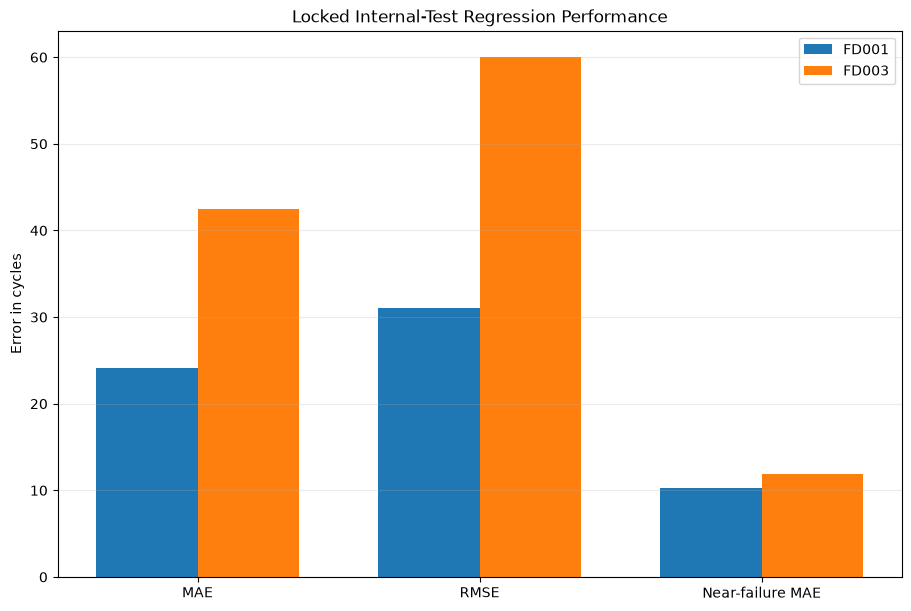

In [156]:
fd001_fd003_regression_plot_df = (
    fd001_fd003_regression_comparison_df.loc[
        fd001_fd003_regression_comparison_df[
            "Metric"
        ].isin(
            [
                "MAE",
                "RMSE",
                "Near-failure MAE",
            ]
        )
    ]
    .copy()
)


plot_positions = np.arange(
    len(
        fd001_fd003_regression_plot_df
    )
)

bar_width = 0.36


figure, axis = plt.subplots(
    figsize=(9, 6),
    constrained_layout=True,
)


axis.bar(
    plot_positions
    - bar_width / 2.0,
    fd001_fd003_regression_plot_df[
        "FD001"
    ],
    width=bar_width,
    label="FD001",
)

axis.bar(
    plot_positions
    + bar_width / 2.0,
    fd001_fd003_regression_plot_df[
        "FD003"
    ],
    width=bar_width,
    label="FD003",
)


axis.set_xticks(
    plot_positions
)

axis.set_xticklabels(
    fd001_fd003_regression_plot_df[
        "Metric"
    ]
)

axis.set_ylabel(
    "Error in cycles"
)

axis.set_title(
    "Locked Internal-Test Regression Performance"
)

axis.grid(
    axis="y",
    alpha=0.25,
)

axis.legend()


figure.savefig(
    FIGURES_DIR
    / "fd001_fd003_regression_error_comparison.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()
plt.close(
    figure
)

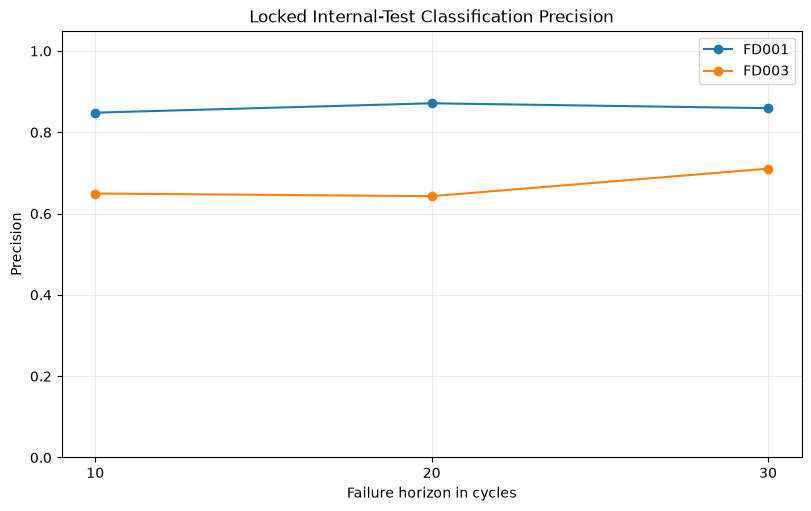

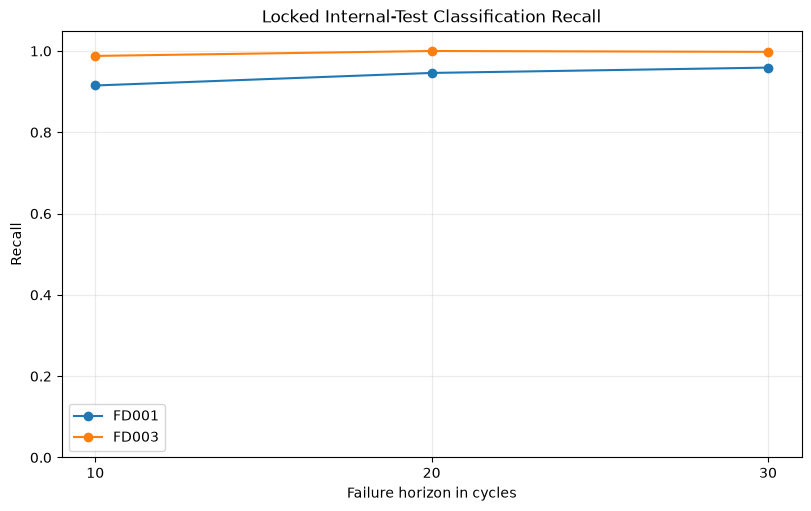

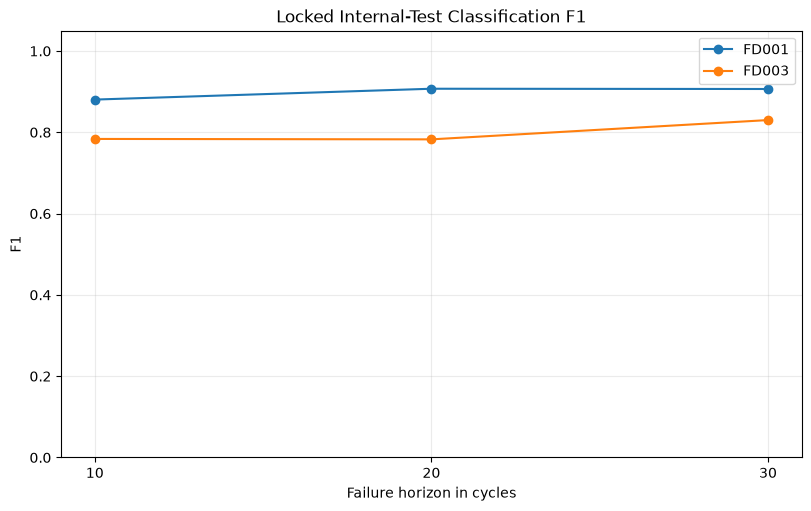

In [157]:
fd001_fd003_classification_plot_df = (
    fd001_fd003_classification_comparison_df.loc[
        fd001_fd003_classification_comparison_df[
            "Metric"
        ].isin(
            [
                "Precision",
                "Recall",
                "F1",
            ]
        )
    ]
    .copy()
)


for metric_name in [
    "Precision",
    "Recall",
    "F1",
]:
    metric_frame = (
        fd001_fd003_classification_plot_df.loc[
            fd001_fd003_classification_plot_df[
                "Metric"
            ].eq(
                metric_name
            )
        ]
        .copy()
    )


    metric_frame[
        "Horizon"
    ] = (
        metric_frame[
            "Subgroup"
        ]
        .str.extract(
            r"(\d+)"
        )
        .astype(int)
    )


    metric_frame = metric_frame.sort_values(
        "Horizon"
    )


    figure, axis = plt.subplots(
        figsize=(8, 5),
        constrained_layout=True,
    )


    axis.plot(
        metric_frame[
            "Horizon"
        ],
        metric_frame[
            "FD001"
        ],
        marker="o",
        label="FD001",
    )

    axis.plot(
        metric_frame[
            "Horizon"
        ],
        metric_frame[
            "FD003"
        ],
        marker="o",
        label="FD003",
    )


    axis.set_xticks(
        [
            10,
            20,
            30,
        ]
    )

    axis.set_ylim(
        0.0,
        1.05,
    )

    axis.set_xlabel(
        "Failure horizon in cycles"
    )

    axis.set_ylabel(
        metric_name
    )

    axis.set_title(
        f"Locked Internal-Test Classification {metric_name}"
    )

    axis.grid(
        alpha=0.25,
    )

    axis.legend()


    figure.savefig(
        FIGURES_DIR
        / (
            "fd001_fd003_classification_"
            f"{metric_name.lower().replace(' ', '_')}.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()
    plt.close(
        figure
    )

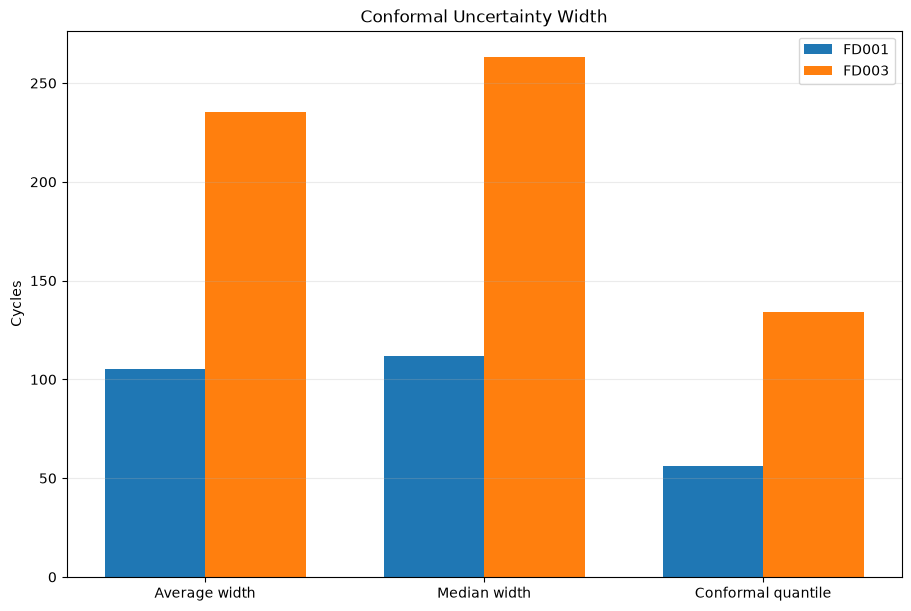

In [158]:
conformal_width_plot_df = (
    fd001_fd003_conformal_comparison_df.loc[
        fd001_fd003_conformal_comparison_df[
            "Metric"
        ].isin(
            [
                "Average width",
                "Median width",
                "Conformal quantile",
            ]
        )
    ]
    .copy()
)


plot_positions = np.arange(
    len(
        conformal_width_plot_df
    )
)

bar_width = 0.36


figure, axis = plt.subplots(
    figsize=(9, 6),
    constrained_layout=True,
)


axis.bar(
    plot_positions
    - bar_width / 2.0,
    conformal_width_plot_df[
        "FD001"
    ],
    width=bar_width,
    label="FD001",
)

axis.bar(
    plot_positions
    + bar_width / 2.0,
    conformal_width_plot_df[
        "FD003"
    ],
    width=bar_width,
    label="FD003",
)


axis.set_xticks(
    plot_positions
)

axis.set_xticklabels(
    conformal_width_plot_df[
        "Metric"
    ]
)

axis.set_ylabel(
    "Cycles"
)

axis.set_title(
    "Conformal Uncertainty Width"
)

axis.grid(
    axis="y",
    alpha=0.25,
)

axis.legend()


figure.savefig(
    FIGURES_DIR
    / "fd001_fd003_conformal_width_comparison.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()
plt.close(
    figure
)

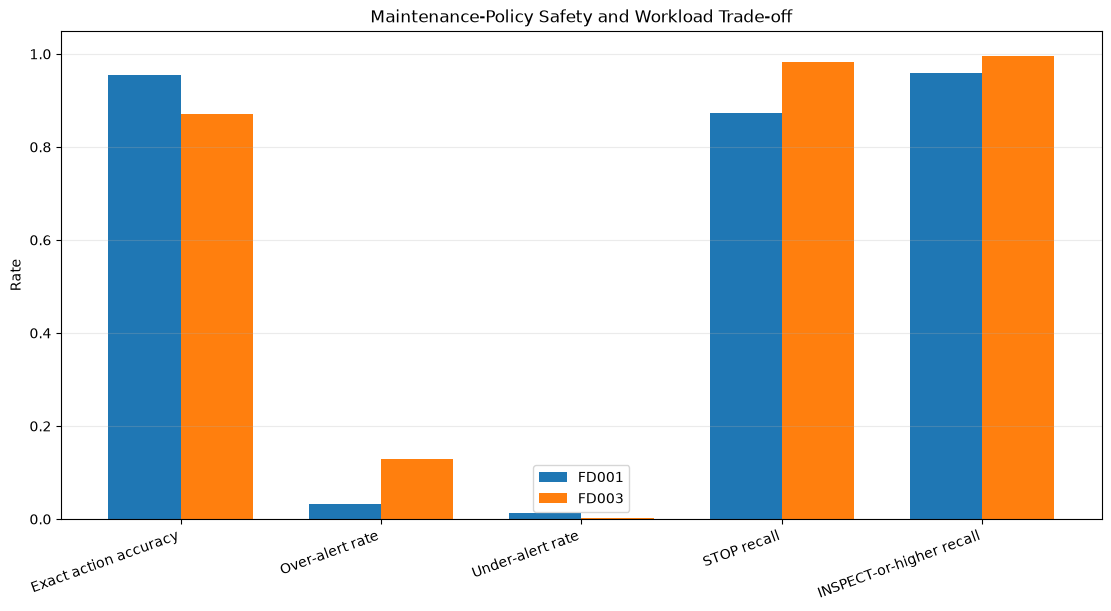

In [159]:
policy_plot_metrics = [
    "Exact action accuracy",
    "Over-alert rate",
    "Under-alert rate",
    "STOP recall",
    "INSPECT-or-higher recall",
]


policy_plot_df = (
    fd001_fd003_policy_comparison_df.loc[
        fd001_fd003_policy_comparison_df[
            "Metric"
        ].isin(
            policy_plot_metrics
        )
    ]
    .set_index(
        "Metric"
    )
    .reindex(
        policy_plot_metrics
    )
    .reset_index()
)


plot_positions = np.arange(
    len(
        policy_plot_df
    )
)

bar_width = 0.36


figure, axis = plt.subplots(
    figsize=(11, 6),
    constrained_layout=True,
)


axis.bar(
    plot_positions
    - bar_width / 2.0,
    policy_plot_df[
        "FD001"
    ],
    width=bar_width,
    label="FD001",
)

axis.bar(
    plot_positions
    + bar_width / 2.0,
    policy_plot_df[
        "FD003"
    ],
    width=bar_width,
    label="FD003",
)


axis.set_xticks(
    plot_positions
)

axis.set_xticklabels(
    policy_plot_df[
        "Metric"
    ],
    rotation=20,
    ha="right",
)

axis.set_ylim(
    0.0,
    1.05,
)

axis.set_ylabel(
    "Rate"
)

axis.set_title(
    "Maintenance-Policy Safety and Workload Trade-off"
)

axis.grid(
    axis="y",
    alpha=0.25,
)

axis.legend()


figure.savefig(
    FIGURES_DIR
    / "fd001_fd003_policy_tradeoff.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()
plt.close(
    figure
)

## 44. Final FD003 Freeze Audit

The final audit verifies that:

- engine splits are disjoint;
- temporal features passed the causality test;
- model contracts forbid post-test tuning;
- each internal-test subsystem was evaluated once;
- prediction tables contain finite values;
- the integrated policy contains no downgrade;
- all required final tables and figures exist.

In [161]:
# ---------------------------------------------------------
# Reconstruct FD003 engine-ID sets for the final audit.
# ---------------------------------------------------------

required_split_frames = [
    "fd003_train_features_df",
    "fd003_validation_features_df",
    "fd003_internal_test_features_df",
]


missing_split_frames = [
    frame_name
    for frame_name in required_split_frames
    if frame_name not in globals()
]


assert not missing_split_frames, (
    "The FD003 split feature DataFrames are missing. "
    "Run the split and feature-engineering cells first. "
    f"Missing objects: {missing_split_frames}"
)


fd003_train_engine_ids = np.array(
    sorted(
        fd003_train_features_df[
            "engine_id"
        ]
        .astype(int)
        .unique()
    ),
    dtype=int,
)


fd003_validation_engine_ids = np.array(
    sorted(
        fd003_validation_features_df[
            "engine_id"
        ]
        .astype(int)
        .unique()
    ),
    dtype=int,
)


fd003_internal_test_engine_ids = np.array(
    sorted(
        fd003_internal_test_features_df[
            "engine_id"
        ]
        .astype(int)
        .unique()
    ),
    dtype=int,
)


# ---------------------------------------------------------
# Verify the locked 70/15/15 engine split.
# ---------------------------------------------------------

assert len(
    fd003_train_engine_ids
) == 70

assert len(
    fd003_validation_engine_ids
) == 15

assert len(
    fd003_internal_test_engine_ids
) == 15


fd003_train_engine_set = set(
    fd003_train_engine_ids.tolist()
)

fd003_validation_engine_set = set(
    fd003_validation_engine_ids.tolist()
)

fd003_internal_test_engine_set = set(
    fd003_internal_test_engine_ids.tolist()
)


fd003_train_validation_overlap = (
    fd003_train_engine_set
    & fd003_validation_engine_set
)

fd003_train_internal_test_overlap = (
    fd003_train_engine_set
    & fd003_internal_test_engine_set
)

fd003_validation_internal_test_overlap = (
    fd003_validation_engine_set
    & fd003_internal_test_engine_set
)


assert not fd003_train_validation_overlap
assert not fd003_train_internal_test_overlap
assert not fd003_validation_internal_test_overlap


fd003_all_split_engine_ids = (
    fd003_train_engine_set
    | fd003_validation_engine_set
    | fd003_internal_test_engine_set
)


assert len(
    fd003_all_split_engine_ids
) == 100


print("=" * 72)
print("FD003 ENGINE SPLIT IDENTIFIERS RESTORED")
print("=" * 72)

print(
    "Train engines:",
    len(
        fd003_train_engine_ids
    ),
)

print(
    "Validation engines:",
    len(
        fd003_validation_engine_ids
    ),
)

print(
    "Internal-test engines:",
    len(
        fd003_internal_test_engine_ids
    ),
)

print(
    "Train-validation overlap:",
    len(
        fd003_train_validation_overlap
    ),
)

print(
    "Train-internal-test overlap:",
    len(
        fd003_train_internal_test_overlap
    ),
)

print(
    "Validation-internal-test overlap:",
    len(
        fd003_validation_internal_test_overlap
    ),
)

print(
    "Total unique engines:",
    len(
        fd003_all_split_engine_ids
    ),
)

FD003 ENGINE SPLIT IDENTIFIERS RESTORED
Train engines: 70
Validation engines: 15
Internal-test engines: 15
Train-validation overlap: 0
Train-internal-test overlap: 0
Validation-internal-test overlap: 0
Total unique engines: 100


In [162]:
fd003_freeze_audit_rows = []


def add_fd003_audit_check(
    check_name,
    passed,
    details,
):
    fd003_freeze_audit_rows.append(
        {
            "Check": check_name,
            "Passed": bool(
                passed
            ),
            "Details": str(
                details
            ),
        }
    )


# ---------------------------------------------------------
# Split and causality contracts.
# ---------------------------------------------------------

add_fd003_audit_check(
    "Train-validation engine overlap",
    len(
        set(
            fd003_train_engine_ids
        )
        & set(
            fd003_validation_engine_ids
        )
    ) == 0,
    "Expected overlap: 0",
)

add_fd003_audit_check(
    "Train-internal-test engine overlap",
    len(
        set(
            fd003_train_engine_ids
        )
        & set(
            fd003_internal_test_engine_ids
        )
    ) == 0,
    "Expected overlap: 0",
)

add_fd003_audit_check(
    "Validation-internal-test engine overlap",
    len(
        set(
            fd003_validation_engine_ids
        )
        & set(
            fd003_internal_test_engine_ids
        )
    ) == 0,
    "Expected overlap: 0",
)

add_fd003_audit_check(
    "Temporal causality test",
    bool(
        fd003_feature_engineering_summary_df
        .iloc[0][
            "Causality test passed"
        ]
    ),
    "Future perturbation must not change past features",
)


# ---------------------------------------------------------
# Regression freeze.
# ---------------------------------------------------------

add_fd003_audit_check(
    "Regression internal-test evaluation count",
    int(
        fd003_locked_model_contract_df
        .iloc[0][
            "Internal-test evaluation count"
        ]
    ) == 1,
    fd003_locked_model_contract_df
    .iloc[0][
        "Internal-test evaluation count"
    ],
)

add_fd003_audit_check(
    "Regression post-test tuning disabled",
    not bool(
        fd003_locked_model_contract_df
        .iloc[0][
            "Post-evaluation tuning permitted"
        ]
    ),
    "Expected: False",
)


# ---------------------------------------------------------
# Classification freeze.
# ---------------------------------------------------------

add_fd003_audit_check(
    "Classification internal-test evaluation count",
    int(
        fd003_classification_contract_df
        .iloc[0][
            "Internal-test evaluation count"
        ]
    ) == 1,
    fd003_classification_contract_df
    .iloc[0][
        "Internal-test evaluation count"
    ],
)

add_fd003_audit_check(
    "Classification post-test tuning disabled",
    not bool(
        fd003_classification_contract_df
        .iloc[0][
            "Post-evaluation tuning permitted"
        ]
    ),
    "Expected: False",
)


# ---------------------------------------------------------
# Anomaly freeze.
# ---------------------------------------------------------

add_fd003_audit_check(
    "Anomaly internal-test evaluation count",
    int(
        fd003_anomaly_contract_df
        .iloc[0][
            "Internal-test evaluation count"
        ]
    ) == 1,
    fd003_anomaly_contract_df
    .iloc[0][
        "Internal-test evaluation count"
    ],
)

add_fd003_audit_check(
    "Anomaly post-test tuning disabled",
    not bool(
        fd003_anomaly_contract_df
        .iloc[0][
            "Post-evaluation tuning permitted"
        ]
    ),
    "Expected: False",
)


# ---------------------------------------------------------
# Prediction and policy integrity.
# ---------------------------------------------------------

add_fd003_audit_check(
    "Regression predictions finite",
    np.isfinite(
        fd003_internal_test_predictions_df[
            "Predicted RUL"
        ]
    ).all(),
    (
        f"Rows: "
        f"{len(fd003_internal_test_predictions_df)}"
    ),
)

add_fd003_audit_check(
    "Classification probabilities finite",
    np.isfinite(
        fd003_internal_test_risk_df[
            [
                "probability_10",
                "probability_20",
                "probability_30",
            ]
        ]
    ).all().all(),
    (
        f"Rows: "
        f"{len(fd003_internal_test_risk_df)}"
    ),
)

add_fd003_audit_check(
    "Anomaly scores finite",
    np.isfinite(
        fd003_internal_test_anomaly_scores_df[
            "locked_anomaly_score"
        ]
    ).all(),
    (
        f"Rows: "
        f"{len(fd003_internal_test_anomaly_scores_df)}"
    ),
)

add_fd003_audit_check(
    "Policy downgrade violations",
    fd003_policy_downgrade_violations == 0,
    fd003_policy_downgrade_violations,
)

add_fd003_audit_check(
    "Integrated policy row count",
    len(
        fd003_integrated_policy_df
    ) == len(
        fd003_internal_test_features_df
    ),
    (
        f"{len(fd003_integrated_policy_df)} "
        f"of {len(fd003_internal_test_features_df)}"
    ),
)


# ---------------------------------------------------------
# Final required outputs.
# ---------------------------------------------------------

fd003_required_final_outputs = [
    TABLES_DIR
    / "fd003_master_results.csv",

    TABLES_DIR
    / "fd003_failure_analysis.csv",

    TABLES_DIR
    / "fd001_fd003_final_comparison.csv",

    TABLES_DIR
    / "fd003_feature_representation_ablation.csv",

    TABLES_DIR
    / "fd003_probability_calibration_ablation.csv",

    TABLES_DIR
    / "fd003_policy_contract.csv",

    FIGURES_DIR
    / "fd001_fd003_regression_error_comparison.png",

    FIGURES_DIR
    / "fd001_fd003_conformal_width_comparison.png",

    FIGURES_DIR
    / "fd001_fd003_policy_tradeoff.png",
]


for output_path in (
    fd003_required_final_outputs
):
    add_fd003_audit_check(
        f"Output exists: {output_path.name}",
        output_path.exists(),
        output_path,
    )


fd003_freeze_audit_df = pd.DataFrame(
    fd003_freeze_audit_rows
)


fd003_freeze_audit_passed = bool(
    fd003_freeze_audit_df[
        "Passed"
    ].all()
)


fd003_freeze_audit_df.to_csv(
    TABLES_DIR
    / "fd003_final_freeze_audit.csv",
    index=False,
)


print(
    "FD003 FINAL FREEZE AUDIT:",
    (
        "PASSED"
        if fd003_freeze_audit_passed
        else "FAILED"
    ),
)


display(
    fd003_freeze_audit_df
)

FD003 FINAL FREEZE AUDIT: PASSED


,Check,Passed,Details
0,Train-validation engine overlap,True,Expected overlap: 0
1,Train-internal-test engine overlap,True,Expected overlap: 0
2,Validation-internal-test engine overlap,True,Expected overlap: 0
3,Temporal causality test,True,Future perturbation must not change past features
4,Regression internal-test evaluation count,True,1
5,Regression post-test tuning disabled,True,Expected: False
6,Classification internal-test evaluation count,True,1
7,Classification post-test tuning disabled,True,Expected: False
8,Anomaly internal-test evaluation count,True,1
9,Anomaly post-test tuning disabled,True,Expected: False


## 45. Versioned FD003 Deployment Artifact

All model families, feature schemas, calibration methods, thresholds,
persistence rules, and policy logic are frozen.

For deployment, the locked configurations are refitted on all 100 FD003
training engines without accessing or optimizing against internal-test or
official-test results.

The deployment artifact contains:

- full-training regression model;
- group-calibrated classifiers for horizons 10, 20, and 30;
- full-training Isolation Forest anomaly detector;
- preprocessing objects;
- feature schema;
- conformal uncertainty configuration;
- integrated maintenance-policy configuration;
- model card, manifest, hashes, and a smoke-test report.

Refitting on all training engines changes fitted parameters but does not change
the locked architecture or hyperparameters.

In [167]:
from __future__ import annotations

from pathlib import Path
from datetime import datetime, timezone

import hashlib
import json
import platform
import shutil
import sys

import joblib
import numpy as np
import pandas as pd
import sklearn

from sklearn.base import clone
from sklearn.ensemble import IsolationForest
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler


# ---------------------------------------------------------
# Resolve project root robustly.
# ---------------------------------------------------------

default_project_root = Path.cwd().resolve()

if (
    not (
        default_project_root
        / "src"
    ).exists()
    and (
        default_project_root.parent
        / "src"
    ).exists()
):
    default_project_root = (
        default_project_root.parent
    )


PROJECT_ROOT = Path(
    globals().get(
        "PROJECT_ROOT",
        default_project_root,
    )
).resolve()


FD003_ARTIFACT_VERSION = "1.0.0"

FD003_ARTIFACT_ROOT = (
    PROJECT_ROOT
    / "artifacts"
    / "fd003"
)

FD003_ARTIFACT_DIR = (
    FD003_ARTIFACT_ROOT
    / f"v{FD003_ARTIFACT_VERSION}"
)

FD003_MODELS_DIR = (
    FD003_ARTIFACT_DIR
    / "models"
)

FD003_CONFIG_DIR = (
    FD003_ARTIFACT_DIR
    / "config"
)

FD003_DOCUMENTATION_DIR = (
    FD003_ARTIFACT_DIR
    / "documentation"
)

FD003_VALIDATION_DIR = (
    FD003_ARTIFACT_DIR
    / "validation"
)


for directory_path in [
    FD003_MODELS_DIR,
    FD003_CONFIG_DIR,
    FD003_DOCUMENTATION_DIR,
    FD003_VALIDATION_DIR,
]:
    directory_path.mkdir(
        parents=True,
        exist_ok=True,
    )


print(
    "Artifact directory:",
    FD003_ARTIFACT_DIR,
)

print(
    "Artifact version:",
    FD003_ARTIFACT_VERSION,
)

Artifact directory: C:\Users\User\Desktop\ML\FinalProject\artifacts\fd003\v1.0.0
Artifact version: 1.0.0


## 46. Full-Training Regression Refit

The locked temporal Ridge model is refitted on all 100 FD003 training engines.

A five-fold engine-grouped out-of-fold procedure estimates a deployment
conformal quantile without using internal-test or official-test observations.

The locked deployment configuration remains:

- temporal feature schema;
- Ridge regularization \(\alpha=1000\);
- prediction ceiling of 300 cycles;
- safety offset of zero;
- 95% symmetric conformal uncertainty.

In [168]:
# ---------------------------------------------------------
# Full FD003 training matrices.
# ---------------------------------------------------------

fd003_X_deployment_regression = (
    fd003_full_training_features_df[
        fd003_locked_feature_columns
    ]
)

fd003_y_deployment_regression = (
    fd003_full_training_features_df[
        "RUL"
    ]
    .to_numpy(
        dtype=float
    )
)

fd003_deployment_regression_groups = (
    fd003_full_training_features_df[
        "engine_id"
    ]
    .to_numpy(
        dtype=int
    )
)


assert (
    fd003_full_training_features_df[
        "engine_id"
    ].nunique()
    == 100
)

assert len(
    fd003_X_deployment_regression
) == len(
    fd003_y_deployment_regression
)

assert (
    fd003_X_deployment_regression
    .columns
    .tolist()
    == list(
        fd003_locked_feature_columns
    )
)


# ---------------------------------------------------------
# Group-aware OOF predictions for deployment conformal q.
# ---------------------------------------------------------

fd003_deployment_regression_group_kfold = (
    GroupKFold(
        n_splits=5
    )
)


fd003_deployment_regression_oof_predictions = (
    np.full(
        len(
            fd003_y_deployment_regression
        ),
        np.nan,
        dtype=float,
    )
)


fd003_deployment_regression_fold_rows = []


for fold_number, (
    fold_train_indices,
    fold_validation_indices,
) in enumerate(
    fd003_deployment_regression_group_kfold.split(
        fd003_X_deployment_regression,
        fd003_y_deployment_regression,
        groups=(
            fd003_deployment_regression_groups
        ),
    ),
    start=1,
):
    fold_model = clone(
        fd003_locked_regression_model
    )


    fold_model.fit(
        fd003_X_deployment_regression.iloc[
            fold_train_indices
        ],
        fd003_y_deployment_regression[
            fold_train_indices
        ],
    )


    fold_raw_predictions = (
        fold_model.predict(
            fd003_X_deployment_regression.iloc[
                fold_validation_indices
            ]
        )
    )


    if (
        fd003_locked_prediction_ceiling
        is None
    ):
        fold_ceiling_predictions = np.asarray(
            fold_raw_predictions,
            dtype=float,
        )

    else:
        fold_ceiling_predictions = np.minimum(
            np.asarray(
                fold_raw_predictions,
                dtype=float,
            ),
            fd003_locked_prediction_ceiling,
        )


    fold_predictions = np.clip(
        (
            fold_ceiling_predictions
            - fd003_locked_safety_offset
        ),
        a_min=0.0,
        a_max=None,
    )


    fd003_deployment_regression_oof_predictions[
        fold_validation_indices
    ] = fold_predictions


    fold_engine_count = int(
        np.unique(
            fd003_deployment_regression_groups[
                fold_validation_indices
            ]
        ).size
    )


    fold_metrics = evaluate_regression(
        model_name=(
            f"Deployment OOF fold {fold_number}"
        ),
        y_true=(
            fd003_y_deployment_regression[
                fold_validation_indices
            ]
        ),
        y_pred=(
            fold_predictions
        ),
    )


    fd003_deployment_regression_fold_rows.append(
        {
            "Fold": fold_number,
            "Validation engines": (
                fold_engine_count
            ),
            "Validation rows": int(
                len(
                    fold_validation_indices
                )
            ),
            "MAE": float(
                fold_metrics[
                    "MAE"
                ]
            ),
            "RMSE": float(
                fold_metrics[
                    "RMSE"
                ]
            ),
            "R2": float(
                fold_metrics[
                    "R2"
                ]
            ),
            "NASA Score": float(
                fold_metrics[
                    "NASA Score"
                ]
            ),
        }
    )


assert np.isfinite(
    fd003_deployment_regression_oof_predictions
).all()


# ---------------------------------------------------------
# Deployment conformal quantile from OOF residuals.
# ---------------------------------------------------------

fd003_deployment_conformal_residuals = np.abs(
    fd003_y_deployment_regression
    - fd003_deployment_regression_oof_predictions
)


fd003_deployment_conformal_count = len(
    fd003_deployment_conformal_residuals
)


fd003_deployment_conformal_level = min(
    1.0,
    (
        np.ceil(
            (
                fd003_deployment_conformal_count
                + 1
            )
            * fd003_conformal_confidence_level
        )
        / fd003_deployment_conformal_count
    ),
)


fd003_deployment_conformal_quantile = float(
    np.quantile(
        fd003_deployment_conformal_residuals,
        fd003_deployment_conformal_level,
        method="higher",
    )
)


# ---------------------------------------------------------
# Final regression model trained on all 100 engines.
# ---------------------------------------------------------

fd003_deployment_regression_model = clone(
    fd003_locked_regression_model
)


fd003_deployment_regression_model.fit(
    fd003_X_deployment_regression,
    fd003_y_deployment_regression,
)


fd003_deployment_regression_fold_df = (
    pd.DataFrame(
        fd003_deployment_regression_fold_rows
    )
)


fd003_deployment_regression_summary_df = pd.DataFrame(
    [
        {
            "Dataset": "FD003",
            "Artifact version": (
                FD003_ARTIFACT_VERSION
            ),
            "Model": (
                fd003_locked_regression_candidate
            ),
            "Training engines": 100,
            "Training rows": len(
                fd003_X_deployment_regression
            ),
            "Feature configuration": (
                fd003_locked_feature_configuration
            ),
            "Feature count": len(
                fd003_locked_feature_columns
            ),
            "Prediction ceiling": (
                fd003_locked_prediction_ceiling
            ),
            "Safety offset": (
                fd003_locked_safety_offset
            ),
            "Conformal confidence": (
                fd003_conformal_confidence_level
            ),
            "Deployment conformal quantile": (
                fd003_deployment_conformal_quantile
            ),
            "Conformal source": (
                "Five-fold engine-grouped OOF residuals "
                "from all 100 training engines"
            ),
        }
    ]
)


display(
    fd003_deployment_regression_summary_df
    .round(6)
)

display(
    fd003_deployment_regression_fold_df
    .round(6)
)

,Dataset,Artifact version,Model,Training engines,Training rows,Feature configuration,Feature count,Prediction ceiling,Safety offset,Conformal confidence,Deployment conformal quantile,Conformal source
0,FD003,1.0.0,Ridge — Temporal | alpha=1000,100,24720,Temporal,147,300.0,0.0,0.95,122.663678,Five-fold engine-grouped OOF residuals from al...


,Fold,Validation engines,Validation rows,MAE,RMSE,R2,NASA Score
0,1,20,4942,44.247419,61.223098,0.634812,1.183362e+09
1,2,20,4946,39.501079,53.828003,0.702288,2.426935e+08
2,3,20,4946,42.976772,60.387158,0.622968,1.263903e+10
3,4,20,4940,41.683342,55.953392,0.674992,6.412964e+07
4,5,20,4946,42.758390,59.763656,0.625981,2.936685e+09


## 47. Full-Training Classification Refit

The selected Weighted Logistic classifier is refitted for each horizon using
all 100 training engines.

Five-fold engine-grouped out-of-fold probabilities are used to refit the
already selected calibration mappings:

- sigmoid calibration for horizon 10;
- isotonic calibration for horizons 20 and 30.

Operational thresholds remain unchanged at 0.10, 0.08, and 0.08.

In [169]:
fd003_X_deployment_classification = (
    fd003_full_training_features_df[
        fd003_temporal_feature_columns
    ]
)


fd003_deployment_classification_groups = (
    fd003_full_training_features_df[
        "engine_id"
    ]
    .to_numpy(
        dtype=int
    )
)


fd003_deployment_classification_group_kfold = (
    GroupKFold(
        n_splits=5
    )
)


fd003_deployment_classification_bundles = {}

fd003_deployment_classification_summary_rows = []


for horizon in (
    fd003_classification_horizons
):
    target_column = (
        fd003_classification_target_columns[
            horizon
        ]
    )


    y_full_horizon = (
        fd003_full_training_features_df[
            target_column
        ]
        .to_numpy(
            dtype=int
        )
    )


    locked_model_name = (
        fd003_classification_bundles[
            horizon
        ][
            "model_name"
        ]
    )

    locked_calibration_method = (
        fd003_classification_bundles[
            horizon
        ][
            "calibration_method"
        ]
    )


    oof_probabilities = np.full(
        len(
            y_full_horizon
        ),
        np.nan,
        dtype=float,
    )


    for (
        fold_train_indices,
        fold_calibration_indices,
    ) in (
        fd003_deployment_classification_group_kfold
        .split(
            fd003_X_deployment_classification,
            y_full_horizon,
            groups=(
                fd003_deployment_classification_groups
            ),
        )
    ):
        fold_model = (
            make_fd003_classification_models()[
                locked_model_name
            ]
        )


        fold_model = fit_fd003_classifier(
            locked_model_name,
            fold_model,
            fd003_X_deployment_classification.iloc[
                fold_train_indices
            ],
            y_full_horizon[
                fold_train_indices
            ],
        )


        oof_probabilities[
            fold_calibration_indices
        ] = (
            fold_model.predict_proba(
                fd003_X_deployment_classification.iloc[
                    fold_calibration_indices
                ]
            )[
                :,
                1
            ]
        )


    assert np.isfinite(
        oof_probabilities
    ).all()


    if (
        locked_calibration_method
        == "Sigmoid"
    ):
        deployment_calibrator = (
            LogisticRegression(
                C=1_000_000.0,
                solver="lbfgs",
                max_iter=2000,
                random_state=RANDOM_STATE,
            )
        )


        deployment_calibrator.fit(
            fd003_safe_logit(
                oof_probabilities
            )
            .reshape(
                -1,
                1,
            ),
            y_full_horizon,
        )


    elif (
        locked_calibration_method
        == "Isotonic"
    ):
        deployment_calibrator = (
            IsotonicRegression(
                y_min=0.0,
                y_max=1.0,
                out_of_bounds="clip",
            )
        )


        deployment_calibrator.fit(
            oof_probabilities,
            y_full_horizon,
        )


    elif (
        locked_calibration_method
        == "Raw"
    ):
        deployment_calibrator = None


    else:
        raise ValueError(
            "Unknown locked calibration method: "
            f"{locked_calibration_method}"
        )


    deployment_base_model = (
        make_fd003_classification_models()[
            locked_model_name
        ]
    )


    deployment_base_model = (
        fit_fd003_classifier(
            locked_model_name,
            deployment_base_model,
            fd003_X_deployment_classification,
            y_full_horizon,
        )
    )


    fd003_deployment_classification_bundles[
        horizon
    ] = {
        "model_name": (
            locked_model_name
        ),
        "base_model": (
            deployment_base_model
        ),
        "calibration_method": (
            locked_calibration_method
        ),
        "calibrator": (
            deployment_calibrator
        ),
        "threshold": float(
            fd003_locked_classification_thresholds[
                horizon
            ]
        ),
    }


    fd003_deployment_classification_summary_rows.append(
        {
            "Horizon": horizon,
            "Model": locked_model_name,
            "Calibration method": (
                locked_calibration_method
            ),
            "Threshold": float(
                fd003_locked_classification_thresholds[
                    horizon
                ]
            ),
            "Training engines": 100,
            "Training rows": len(
                y_full_horizon
            ),
            "Positive samples": int(
                y_full_horizon.sum()
            ),
            "Positive rate": float(
                y_full_horizon.mean()
            ),
            "Feature count": len(
                fd003_temporal_feature_columns
            ),
            "Calibration source": (
                "Five-fold engine-grouped "
                "out-of-fold probabilities"
            ),
        }
    )


fd003_deployment_classification_summary_df = (
    pd.DataFrame(
        fd003_deployment_classification_summary_rows
    )
)


display(
    fd003_deployment_classification_summary_df
    .round(6)
)

,Horizon,Model,Calibration method,Threshold,Training engines,Training rows,Positive samples,Positive rate,Feature count,Calibration source
0,10,Weighted Logistic,Sigmoid,0.10,100,24720,1100,0.044498,147,Five-fold engine-grouped out-of-fold probabili...
1,20,Weighted Logistic,Isotonic,0.08,100,24720,2100,0.084951,147,Five-fold engine-grouped out-of-fold probabili...
2,30,Weighted Logistic,Isotonic,0.08,100,24720,3100,0.125405,147,Five-fold engine-grouped out-of-fold probabili...


## 48. Full-Training Anomaly Refit

The locked Isolation Forest configuration is refitted using the first 30
cycles of all 100 FD003 training engines.

The operational anomaly threshold remains defined as the 99th percentile of
the robustly normalized healthy-reference score distribution.

The numeric normalized threshold may change after the full-training refit
because the healthy-reference population has increased from 70 to 100 engines.

In [171]:
# ---------------------------------------------------------
# Full healthy reference from all 100 training engines.
# ---------------------------------------------------------

fd003_deployment_anomaly_reference_df = (
    fd003_full_training_features_df.loc[
        fd003_full_training_features_df[
            "cycle"
        ]
        <= fd003_anomaly_reference_cycle_limit
    ]
    .sort_values(
        [
            "engine_id",
            "cycle",
        ]
    )
    .reset_index(drop=True)
    .copy()
)


assert (
    fd003_deployment_anomaly_reference_df[
        "engine_id"
    ].nunique()
    == 100
)

assert len(
    fd003_deployment_anomaly_reference_df
) == 3000


# ---------------------------------------------------------
# Refit scaler and locked Isolation Forest.
# ---------------------------------------------------------

fd003_deployment_anomaly_scaler = (
    StandardScaler()
)


fd003_X_deployment_anomaly_reference = (
    fd003_deployment_anomaly_scaler
    .fit_transform(
        fd003_deployment_anomaly_reference_df[
            fd003_anomaly_sensor_columns
        ]
    )
)


fd003_deployment_anomaly_model = (
    IsolationForest(
        n_estimators=300,
        max_samples="auto",
        contamination="auto",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
)


fd003_deployment_anomaly_model.fit(
    fd003_X_deployment_anomaly_reference
)


fd003_deployment_anomaly_reference_raw_scores = (
    -fd003_deployment_anomaly_model
    .decision_function(
        fd003_X_deployment_anomaly_reference
    )
)


fd003_deployment_anomaly_reference_median = float(
    np.median(
        fd003_deployment_anomaly_reference_raw_scores
    )
)


fd003_deployment_anomaly_reference_q1 = float(
    np.quantile(
        fd003_deployment_anomaly_reference_raw_scores,
        0.25,
    )
)


fd003_deployment_anomaly_reference_q3 = float(
    np.quantile(
        fd003_deployment_anomaly_reference_raw_scores,
        0.75,
    )
)


fd003_deployment_anomaly_reference_scale = float(
    fd003_deployment_anomaly_reference_q3
    - fd003_deployment_anomaly_reference_q1
)


if (
    not np.isfinite(
        fd003_deployment_anomaly_reference_scale
    )
    or (
        fd003_deployment_anomaly_reference_scale
        <= 1e-12
    )
):
    fd003_deployment_anomaly_reference_scale = float(
        np.std(
            fd003_deployment_anomaly_reference_raw_scores
        )
    )


if (
    not np.isfinite(
        fd003_deployment_anomaly_reference_scale
    )
    or (
        fd003_deployment_anomaly_reference_scale
        <= 1e-12
    )
):
    fd003_deployment_anomaly_reference_scale = 1.0


fd003_deployment_anomaly_reference_normalized_scores = (
    (
        fd003_deployment_anomaly_reference_raw_scores
        - fd003_deployment_anomaly_reference_median
    )
    / fd003_deployment_anomaly_reference_scale
)


fd003_deployment_anomaly_threshold_quantile = (
    fd003_locked_anomaly_threshold_quantile
)


fd003_deployment_anomaly_threshold = float(
    np.quantile(
        fd003_deployment_anomaly_reference_normalized_scores,
        fd003_deployment_anomaly_threshold_quantile,
    )
)


fd003_deployment_anomaly_summary_df = pd.DataFrame(
    [
        {
            "Dataset": "FD003",
            "Model": (
                fd003_locked_anomaly_model_name
            ),
            "Training engines": 100,
            "Healthy cycles per engine": (
                fd003_anomaly_reference_cycle_limit
            ),
            "Healthy reference rows": len(
                fd003_deployment_anomaly_reference_df
            ),
            "Feature count": len(
                fd003_anomaly_sensor_columns
            ),
            "Score normalization": (
                "Healthy-reference median and IQR"
            ),
            "Reference median": (
                fd003_deployment_anomaly_reference_median
            ),
            "Reference scale": (
                fd003_deployment_anomaly_reference_scale
            ),
            "Threshold quantile": (
                fd003_deployment_anomaly_threshold_quantile
            ),
            "Deployment normalized threshold": (
                fd003_deployment_anomaly_threshold
            ),
            "Persistence rule": "2-of-3",
        }
    ]
)


display(
    fd003_deployment_anomaly_summary_df
    .round(6)
)

,Dataset,Model,Training engines,Healthy cycles per engine,Healthy reference rows,Feature count,Score normalization,Reference median,Reference scale,Threshold quantile,Deployment normalized threshold,Persistence rule
0,FD003,Isolation Forest,100,30,3000,16,Healthy-reference median and IQR,-0.070497,0.046518,0.99,3.715377,2-of-3


In [172]:
# ---------------------------------------------------------
# Regression.
# ---------------------------------------------------------

joblib.dump(
    fd003_deployment_regression_model,
    FD003_MODELS_DIR
    / "regression_model.joblib",
)


# ---------------------------------------------------------
# Classification models and calibrators.
# ---------------------------------------------------------

for horizon in (
    fd003_classification_horizons
):
    classification_bundle = (
        fd003_deployment_classification_bundles[
            horizon
        ]
    )


    joblib.dump(
        classification_bundle[
            "base_model"
        ],
        FD003_MODELS_DIR
        / (
            f"classification_h{horizon}_"
            "base_model.joblib"
        ),
    )


    if (
        classification_bundle[
            "calibrator"
        ]
        is not None
    ):
        joblib.dump(
            classification_bundle[
                "calibrator"
            ],
            FD003_MODELS_DIR
            / (
                f"classification_h{horizon}_"
                "calibrator.joblib"
            ),
        )


# ---------------------------------------------------------
# Anomaly subsystem.
# ---------------------------------------------------------

joblib.dump(
    fd003_deployment_anomaly_scaler,
    FD003_MODELS_DIR
    / "anomaly_scaler.joblib",
)

joblib.dump(
    fd003_deployment_anomaly_model,
    FD003_MODELS_DIR
    / "anomaly_isolation_forest.joblib",
)


print(
    "FD003 deployment models saved."
)

FD003 deployment models saved.


In [173]:
def fd003_json_default(
    value,
):
    if isinstance(
        value,
        (
            np.integer,
        ),
    ):
        return int(
            value
        )

    if isinstance(
        value,
        (
            np.floating,
        ),
    ):
        return float(
            value
        )

    if isinstance(
        value,
        np.ndarray,
    ):
        return value.tolist()

    if isinstance(
        value,
        Path,
    ):
        return str(
            value
        )

    if isinstance(
        value,
        (
            np.bool_,
        ),
    ):
        return bool(
            value
        )

    raise TypeError(
        f"Object is not JSON serializable: "
        f"{type(value)}"
    )


fd003_feature_schema = {
    "dataset": "FD003",
    "artifact_version": (
        FD003_ARTIFACT_VERSION
    ),
    "identifier_columns": [
        "engine_id",
        "cycle",
    ],
    "operational_setting_columns": [
        "operational_setting_1",
        "operational_setting_2",
    ],
    "anomaly_sensor_columns": list(
        fd003_anomaly_sensor_columns
    ),
    "current_cycle_feature_columns": list(
        fd003_current_cycle_feature_columns
    ),
    "temporal_feature_columns": list(
        fd003_temporal_feature_columns
    ),
    "regression_feature_columns": list(
        fd003_locked_feature_columns
    ),
    "classification_feature_columns": list(
        fd003_temporal_feature_columns
    ),
    "feature_counts": {
        "current_cycle": len(
            fd003_current_cycle_feature_columns
        ),
        "temporal": len(
            fd003_temporal_feature_columns
        ),
        "anomaly": len(
            fd003_anomaly_sensor_columns
        ),
    },
    "causality_test_passed": True,
}


fd003_policy_config = {
    "dataset": "FD003",
    "artifact_version": (
        FD003_ARTIFACT_VERSION
    ),
    "regression": {
        "model": (
            fd003_locked_regression_candidate
        ),
        "prediction_ceiling": (
            fd003_locked_prediction_ceiling
        ),
        "safety_offset": (
            fd003_locked_safety_offset
        ),
        "conformal_confidence": (
            fd003_conformal_confidence_level
        ),
        "deployment_conformal_quantile": (
            fd003_deployment_conformal_quantile
        ),
    },
    "classification": {
        "probability_monotonicity": True,
        "horizons": {
            str(
                horizon
            ): {
                "model": (
                    fd003_deployment_classification_bundles[
                        horizon
                    ][
                        "model_name"
                    ]
                ),
                "calibration_method": (
                    fd003_deployment_classification_bundles[
                        horizon
                    ][
                        "calibration_method"
                    ]
                ),
                "threshold": float(
                    fd003_locked_classification_thresholds[
                        horizon
                    ]
                ),
            }
            for horizon
            in fd003_classification_horizons
        },
        "persistence_required_alerts": 2,
        "persistence_window": 3,
    },
    "anomaly": {
        "model": (
            fd003_locked_anomaly_model_name
        ),
        "healthy_reference_cycles": (
            fd003_anomaly_reference_cycle_limit
        ),
        "healthy_reference_rows": len(
            fd003_deployment_anomaly_reference_df
        ),
        "threshold_quantile": (
            fd003_deployment_anomaly_threshold_quantile
        ),
        "normalized_threshold": (
            fd003_deployment_anomaly_threshold
        ),
        "reference_median": (
            fd003_deployment_anomaly_reference_median
        ),
        "reference_scale": (
            fd003_deployment_anomaly_reference_scale
        ),
        "persistence_required_alerts": 2,
        "persistence_window": 3,
        "role": "Advisory only",
    },
    "maintenance_policy": {
        "severity_order": {
            "CONTINUE": 0,
            "INSPECT": 1,
            "STOP": 2,
        },
        "stop_condition": (
            "Persistent failure-within-10 alert"
        ),
        "inspect_condition": (
            "Persistent failure-within-20 "
            "or failure-within-30 alert"
        ),
        "anomaly_role": "Advisory only",
        "uncertainty_role": "Advisory only",
        "hysteresis": (
            "No downgrade within an engine trajectory"
        ),
    },
}


with open(
    FD003_CONFIG_DIR
    / "feature_schema.json",
    "w",
    encoding="utf-8",
) as file_handle:
    json.dump(
        fd003_feature_schema,
        file_handle,
        indent=2,
        ensure_ascii=False,
        default=fd003_json_default,
    )


with open(
    FD003_CONFIG_DIR
    / "policy_config.json",
    "w",
    encoding="utf-8",
) as file_handle:
    json.dump(
        fd003_policy_config,
        file_handle,
        indent=2,
        ensure_ascii=False,
        default=fd003_json_default,
    )


print(
    "Feature schema and policy config saved."
)

Feature schema and policy config saved.


In [174]:
fd003_deployment_regression_summary_df.to_csv(
    FD003_VALIDATION_DIR
    / "deployment_regression_summary.csv",
    index=False,
)

fd003_deployment_regression_fold_df.to_csv(
    FD003_VALIDATION_DIR
    / "deployment_regression_oof_folds.csv",
    index=False,
)

fd003_deployment_classification_summary_df.to_csv(
    FD003_VALIDATION_DIR
    / "deployment_classification_summary.csv",
    index=False,
)

fd003_deployment_anomaly_summary_df.to_csv(
    FD003_VALIDATION_DIR
    / "deployment_anomaly_summary.csv",
    index=False,
)

fd003_freeze_audit_df.to_csv(
    FD003_VALIDATION_DIR
    / "final_freeze_audit.csv",
    index=False,
)

fd003_master_results_df.to_csv(
    FD003_VALIDATION_DIR
    / "internal_test_master_results.csv",
    index=False,
)

fd001_fd003_final_comparison_df.to_csv(
    FD003_VALIDATION_DIR
    / "fd001_fd003_final_comparison.csv",
    index=False,
)


print(
    "Deployment and evaluation summaries saved."
)

Deployment and evaluation summaries saved.


In [175]:
fd003_model_card_text = f"""# FD003 Jet Engine Hospital Model Card

## Artifact identity

- Dataset: NASA C-MAPSS FD003
- Artifact version: {FD003_ARTIFACT_VERSION}
- Created: {datetime.now(timezone.utc).isoformat()}
- Training engines: 100
- Operating conditions: 1
- Fault modes: 2

## Intended use

This artifact provides maintenance decision support for FD003-style engine
trajectories. It produces:

- remaining useful life estimates;
- failure probabilities for 10, 20, and 30 cycles;
- anomaly evidence;
- conformal uncertainty intervals;
- CONTINUE, INSPECT, or STOP maintenance actions.

It is an educational predictive-maintenance artifact and must not be used as
the sole authority for real aviation maintenance decisions.

## Regression

- Model: {fd003_locked_regression_candidate}
- Features: {len(fd003_locked_feature_columns)} causal temporal features
- Prediction ceiling: {fd003_locked_prediction_ceiling}
- Safety offset: {fd003_locked_safety_offset}
- Deployment conformal quantile: {fd003_deployment_conformal_quantile:.6f}
- Conformal confidence: {fd003_conformal_confidence_level:.2f}

## Classification

- Horizon 10: Weighted Logistic + Sigmoid, threshold 0.10
- Horizon 20: Weighted Logistic + Isotonic, threshold 0.08
- Horizon 30: Weighted Logistic + Isotonic, threshold 0.08
- Probability monotonicity: enabled
- Persistence rule: 2 of the latest 3 cycles

## Anomaly detection

- Model: Isolation Forest
- Sensors: {len(fd003_anomaly_sensor_columns)}
- Healthy reference: first 30 cycles of all 100 training engines
- Reference rows: {len(fd003_deployment_anomaly_reference_df)}
- Threshold quantile: {fd003_deployment_anomaly_threshold_quantile}
- Normalized threshold: {fd003_deployment_anomaly_threshold:.6f}
- Operational role: advisory only

## Maintenance policy

- Persistent 10-cycle risk: STOP
- Persistent 20-cycle or 30-cycle risk: INSPECT
- No persistent supervised risk: CONTINUE
- Anomaly evidence: advisory only
- Conformal uncertainty: advisory only
- Hysteresis: actions cannot downgrade within an engine trajectory

## Held-out FD003 internal-test performance

- Regression MAE: 42.522372 cycles
- Regression RMSE: 60.061392 cycles
- Regression R2: 0.531300
- Classification H10 recall: 0.987879
- Classification H20 recall: 1.000000
- Classification H30 recall: 0.997849
- Policy exact-action accuracy: 0.869829
- Policy under-alert rate: 0.001379
- Policy STOP recall: 0.981818

## Limitations

- Exact RUL regression is substantially less reliable on FD003 than FD001.
- Two degradation modes create heterogeneous trajectories.
- Conformal intervals are wide, especially outside the near-failure region.
- Cost-sensitive classification thresholds intentionally increase false alerts.
- The anomaly detector may signal degradation well before imminent failure.
- Input histories must be complete, chronologically ordered, and causally
  transformed with the same feature-engineering function.

## Reproducibility

The artifact includes:

- serialized estimators;
- complete feature schema;
- policy configuration;
- frozen evaluation summaries;
- final freeze audit;
- cryptographic SHA-256 hashes.
"""


with open(
    FD003_DOCUMENTATION_DIR
    / "MODEL_CARD.md",
    "w",
    encoding="utf-8",
) as file_handle:
    file_handle.write(
        fd003_model_card_text
    )


print(
    "FD003 model card saved."
)

FD003 model card saved.


In [176]:
def calculate_fd003_file_sha256(
    file_path,
):
    sha256_hasher = hashlib.sha256()

    with open(
        file_path,
        "rb",
    ) as file_handle:
        for file_chunk in iter(
            lambda: file_handle.read(
                1024
                * 1024
            ),
            b"",
        ):
            sha256_hasher.update(
                file_chunk
            )

    return sha256_hasher.hexdigest()


artifact_payload_files = sorted(
    [
        file_path
        for file_path
        in FD003_ARTIFACT_DIR.rglob(
            "*"
        )
        if file_path.is_file()
        and file_path.name
        not in {
            "manifest.json",
            "SHA256SUMS.txt",
        }
    ]
)


artifact_inventory = []


for file_path in (
    artifact_payload_files
):
    artifact_inventory.append(
        {
            "path": str(
                file_path.relative_to(
                    FD003_ARTIFACT_DIR
                )
            ).replace(
                "\\",
                "/",
            ),
            "size_bytes": int(
                file_path.stat().st_size
            ),
            "sha256": (
                calculate_fd003_file_sha256(
                    file_path
                )
            ),
        }
    )


fd003_artifact_manifest = {
    "artifact_name": (
        "jet-engine-hospital-fd003"
    ),
    "artifact_version": (
        FD003_ARTIFACT_VERSION
    ),
    "dataset": "FD003",
    "created_utc": (
        datetime.now(
            timezone.utc
        ).isoformat()
    ),
    "training_engines": 100,
    "fault_modes": 2,
    "operating_conditions": 1,
    "python_version": (
        sys.version
    ),
    "platform": (
        platform.platform()
    ),
    "package_versions": {
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": (
            sklearn.__version__
        ),
        "joblib": joblib.__version__,
    },
    "regression": {
        "configuration": (
            fd003_locked_regression_candidate
        ),
        "feature_count": len(
            fd003_locked_feature_columns
        ),
        "prediction_ceiling": (
            fd003_locked_prediction_ceiling
        ),
        "safety_offset": (
            fd003_locked_safety_offset
        ),
        "deployment_conformal_quantile": (
            fd003_deployment_conformal_quantile
        ),
    },
    "classification": {
        str(
            horizon
        ): {
            "model": (
                fd003_deployment_classification_bundles[
                    horizon
                ][
                    "model_name"
                ]
            ),
            "calibration": (
                fd003_deployment_classification_bundles[
                    horizon
                ][
                    "calibration_method"
                ]
            ),
            "threshold": (
                fd003_locked_classification_thresholds[
                    horizon
                ]
            ),
        }
        for horizon
        in fd003_classification_horizons
    },
    "anomaly": {
        "model": (
            fd003_locked_anomaly_model_name
        ),
        "threshold_quantile": (
            fd003_deployment_anomaly_threshold_quantile
        ),
        "normalized_threshold": (
            fd003_deployment_anomaly_threshold
        ),
    },
    "freeze_audit_passed": bool(
        fd003_freeze_audit_passed
    ),
    "file_count": len(
        artifact_inventory
    ),
    "files": artifact_inventory,
}


with open(
    FD003_ARTIFACT_DIR
    / "manifest.json",
    "w",
    encoding="utf-8",
) as file_handle:
    json.dump(
        fd003_artifact_manifest,
        file_handle,
        indent=2,
        ensure_ascii=False,
        default=fd003_json_default,
    )


# ---------------------------------------------------------
# SHA256SUMS includes manifest but excludes itself.
# ---------------------------------------------------------

checksum_files = sorted(
    [
        file_path
        for file_path
        in FD003_ARTIFACT_DIR.rglob(
            "*"
        )
        if file_path.is_file()
        and file_path.name
        != "SHA256SUMS.txt"
    ]
)


checksum_lines = []


for file_path in checksum_files:
    relative_path = str(
        file_path.relative_to(
            FD003_ARTIFACT_DIR
        )
    ).replace(
        "\\",
        "/",
    )

    checksum_lines.append(
        (
            f"{calculate_fd003_file_sha256(file_path)}  "
            f"{relative_path}"
        )
    )


with open(
    FD003_ARTIFACT_DIR
    / "SHA256SUMS.txt",
    "w",
    encoding="utf-8",
) as file_handle:
    file_handle.write(
        "\n".join(
            checksum_lines
        )
        + "\n"
    )


print(
    "Artifact manifest and SHA-256 checksums created."
)

Artifact manifest and SHA-256 checksums created.


In [177]:
# ---------------------------------------------------------
# Load serialized deployment artifacts.
# ---------------------------------------------------------

loaded_regression_model = joblib.load(
    FD003_MODELS_DIR
    / "regression_model.joblib"
)


loaded_classification_models = {}

loaded_classification_calibrators = {}


for horizon in (
    fd003_classification_horizons
):
    loaded_classification_models[
        horizon
    ] = joblib.load(
        FD003_MODELS_DIR
        / (
            f"classification_h{horizon}_"
            "base_model.joblib"
        )
    )


    calibrator_path = (
        FD003_MODELS_DIR
        / (
            f"classification_h{horizon}_"
            "calibrator.joblib"
        )
    )


    loaded_classification_calibrators[
        horizon
    ] = (
        joblib.load(
            calibrator_path
        )
        if calibrator_path.exists()
        else None
    )


loaded_anomaly_scaler = joblib.load(
    FD003_MODELS_DIR
    / "anomaly_scaler.joblib"
)

loaded_anomaly_model = joblib.load(
    FD003_MODELS_DIR
    / "anomaly_isolation_forest.joblib"
)


# ---------------------------------------------------------
# Five-row smoke-test batch.
# ---------------------------------------------------------

fd003_smoke_test_features_df = (
    fd003_internal_test_features_df
    .sort_values(
        [
            "engine_id",
            "cycle",
        ]
    )
    .head(5)
    .copy()
)


# Regression.
smoke_regression_raw = (
    loaded_regression_model.predict(
        fd003_smoke_test_features_df[
            fd003_locked_feature_columns
        ]
    )
)


smoke_regression_predictions = np.clip(
    np.minimum(
        smoke_regression_raw,
        fd003_locked_prediction_ceiling,
    )
    - fd003_locked_safety_offset,
    a_min=0.0,
    a_max=None,
)


# Classification.
smoke_probability_columns = []


for horizon in (
    fd003_classification_horizons
):
    raw_probabilities = (
        loaded_classification_models[
            horizon
        ]
        .predict_proba(
            fd003_smoke_test_features_df[
                fd003_temporal_feature_columns
            ]
        )[
            :,
            1
        ]
    )


    calibration_method = (
        fd003_deployment_classification_bundles[
            horizon
        ][
            "calibration_method"
        ]
    )


    calibrated_probabilities = (
        apply_fd003_calibrator(
            loaded_classification_calibrators[
                horizon
            ],
            calibration_method,
            raw_probabilities,
        )
    )


    smoke_probability_columns.append(
        calibrated_probabilities
    )


smoke_probability_matrix = np.maximum.accumulate(
    np.column_stack(
        smoke_probability_columns
    ),
    axis=1,
)


# Anomaly.
smoke_anomaly_matrix = (
    loaded_anomaly_scaler.transform(
        fd003_smoke_test_features_df[
            fd003_anomaly_sensor_columns
        ]
    )
)


smoke_anomaly_raw_scores = (
    -loaded_anomaly_model.decision_function(
        smoke_anomaly_matrix
    )
)


smoke_anomaly_normalized_scores = (
    (
        smoke_anomaly_raw_scores
        - fd003_deployment_anomaly_reference_median
    )
    / fd003_deployment_anomaly_reference_scale
)


assert np.isfinite(
    smoke_regression_predictions
).all()

assert np.isfinite(
    smoke_probability_matrix
).all()

assert np.isfinite(
    smoke_anomaly_normalized_scores
).all()

assert (
    smoke_probability_matrix
    >= 0.0
).all()

assert (
    smoke_probability_matrix
    <= 1.0
).all()


fd003_artifact_smoke_test_df = pd.DataFrame(
    {
        "engine_id": (
            fd003_smoke_test_features_df[
                "engine_id"
            ]
            .to_numpy()
        ),
        "cycle": (
            fd003_smoke_test_features_df[
                "cycle"
            ]
            .to_numpy()
        ),
        "Predicted RUL": (
            smoke_regression_predictions
        ),
        "Probability 10": (
            smoke_probability_matrix[
                :,
                0
            ]
        ),
        "Probability 20": (
            smoke_probability_matrix[
                :,
                1
            ]
        ),
        "Probability 30": (
            smoke_probability_matrix[
                :,
                2
            ]
        ),
        "Anomaly score": (
            smoke_anomaly_normalized_scores
        ),
    }
)


fd003_artifact_smoke_test_df.to_csv(
    FD003_VALIDATION_DIR
    / "artifact_smoke_test.csv",
    index=False,
)


print(
    "FD003 ARTIFACT SMOKE TEST: PASSED"
)

display(
    fd003_artifact_smoke_test_df
    .round(6)
)

FD003 ARTIFACT SMOKE TEST: PASSED


,engine_id,cycle,Predicted RUL,Probability 10,Probability 20,Probability 30,Anomaly score
0,9,1,244.335784,0.000207,0.000207,0.000207,1.220579
1,9,2,234.554097,0.000207,0.000207,0.000207,0.730849
2,9,3,220.008926,0.000207,0.000207,0.000207,1.269217
3,9,4,208.613786,0.000207,0.000207,0.000207,1.493593
4,9,5,207.552960,0.000207,0.000207,0.000207,1.167798


In [178]:
fd003_artifact_archive_base = (
    FD003_ARTIFACT_ROOT
    / (
        "jet_engine_hospital_"
        f"fd003_v{FD003_ARTIFACT_VERSION}"
    )
)


fd003_artifact_zip_path = Path(
    shutil.make_archive(
        base_name=str(
            fd003_artifact_archive_base
        ),
        format="zip",
        root_dir=(
            FD003_ARTIFACT_DIR.parent
        ),
        base_dir=(
            FD003_ARTIFACT_DIR.name
        ),
    )
)


print(
    "Artifact ZIP:",
    fd003_artifact_zip_path,
)

print(
    "ZIP size (MB):",
    round(
        fd003_artifact_zip_path
        .stat()
        .st_size
        / (
            1024
            ** 2
        ),
        3,
    ),
)

Artifact ZIP: C:\Users\User\Desktop\ML\FinalProject\artifacts\fd003\jet_engine_hospital_fd003_v1.0.0.zip
ZIP size (MB): 0.886


In [179]:
fd003_artifact_required_files = [
    FD003_MODELS_DIR
    / "regression_model.joblib",

    FD003_MODELS_DIR
    / "classification_h10_base_model.joblib",

    FD003_MODELS_DIR
    / "classification_h10_calibrator.joblib",

    FD003_MODELS_DIR
    / "classification_h20_base_model.joblib",

    FD003_MODELS_DIR
    / "classification_h20_calibrator.joblib",

    FD003_MODELS_DIR
    / "classification_h30_base_model.joblib",

    FD003_MODELS_DIR
    / "classification_h30_calibrator.joblib",

    FD003_MODELS_DIR
    / "anomaly_scaler.joblib",

    FD003_MODELS_DIR
    / "anomaly_isolation_forest.joblib",

    FD003_CONFIG_DIR
    / "feature_schema.json",

    FD003_CONFIG_DIR
    / "policy_config.json",

    FD003_DOCUMENTATION_DIR
    / "MODEL_CARD.md",

    FD003_ARTIFACT_DIR
    / "manifest.json",

    FD003_ARTIFACT_DIR
    / "SHA256SUMS.txt",

    FD003_VALIDATION_DIR
    / "final_freeze_audit.csv",

    FD003_VALIDATION_DIR
    / "artifact_smoke_test.csv",

    fd003_artifact_zip_path,
]


fd003_artifact_audit_rows = []


for required_path in (
    fd003_artifact_required_files
):
    fd003_artifact_audit_rows.append(
        {
            "Artifact": (
                required_path.name
            ),
            "Exists": bool(
                required_path.exists()
            ),
            "Size bytes": (
                int(
                    required_path
                    .stat()
                    .st_size
                )
                if required_path.exists()
                else 0
            ),
            "Path": str(
                required_path
            ),
        }
    )


fd003_artifact_audit_df = pd.DataFrame(
    fd003_artifact_audit_rows
)


fd003_artifact_audit_passed = bool(
    fd003_artifact_audit_df[
        "Exists"
    ].all()
    and (
        fd003_artifact_audit_df[
            "Size bytes"
        ]
        > 0
    ).all()
)


print(
    "FD003 ARTIFACT AUDIT:",
    (
        "PASSED"
        if fd003_artifact_audit_passed
        else "FAILED"
    ),
)


display(
    fd003_artifact_audit_df
)

FD003 ARTIFACT AUDIT: PASSED


,Artifact,Exists,Size bytes,Path
0,regression_model.joblib,True,8601,C:\Users\User\Desktop\ML\FinalProject\artifact...
1,classification_h10_base_model.joblib,True,8961,C:\Users\User\Desktop\ML\FinalProject\artifact...
2,classification_h10_calibrator.joblib,True,879,C:\Users\User\Desktop\ML\FinalProject\artifact...
3,classification_h20_base_model.joblib,True,8961,C:\Users\User\Desktop\ML\FinalProject\artifact...
4,classification_h20_calibrator.joblib,True,1591,C:\Users\User\Desktop\ML\FinalProject\artifact...
5,classification_h30_base_model.joblib,True,8961,C:\Users\User\Desktop\ML\FinalProject\artifact...
6,classification_h30_calibrator.joblib,True,1655,C:\Users\User\Desktop\ML\FinalProject\artifact...
7,anomaly_scaler.joblib,True,1399,C:\Users\User\Desktop\ML\FinalProject\artifact...
8,anomaly_isolation_forest.joblib,True,3412477,C:\Users\User\Desktop\ML\FinalProject\artifact...
9,feature_schema.json,True,11831,C:\Users\User\Desktop\ML\FinalProject\artifact...


In [180]:
fd003_deployment_regression_summary_df.round(6)

,Dataset,Artifact version,Model,Training engines,Training rows,Feature configuration,Feature count,Prediction ceiling,Safety offset,Conformal confidence,Deployment conformal quantile,Conformal source
0,FD003,1.0.0,Ridge — Temporal | alpha=1000,100,24720,Temporal,147,300.0,0.0,0.95,122.663678,Five-fold engine-grouped OOF residuals from al...


In [181]:
fd003_deployment_classification_summary_df.round(6)

,Horizon,Model,Calibration method,Threshold,Training engines,Training rows,Positive samples,Positive rate,Feature count,Calibration source
0,10,Weighted Logistic,Sigmoid,0.10,100,24720,1100,0.044498,147,Five-fold engine-grouped out-of-fold probabili...
1,20,Weighted Logistic,Isotonic,0.08,100,24720,2100,0.084951,147,Five-fold engine-grouped out-of-fold probabili...
2,30,Weighted Logistic,Isotonic,0.08,100,24720,3100,0.125405,147,Five-fold engine-grouped out-of-fold probabili...


In [182]:
fd003_deployment_anomaly_summary_df.round(6)

,Dataset,Model,Training engines,Healthy cycles per engine,Healthy reference rows,Feature count,Score normalization,Reference median,Reference scale,Threshold quantile,Deployment normalized threshold,Persistence rule
0,FD003,Isolation Forest,100,30,3000,16,Healthy-reference median and IQR,-0.070497,0.046518,0.99,3.715377,2-of-3


In [183]:
fd003_artifact_smoke_test_df.round(6)

,engine_id,cycle,Predicted RUL,Probability 10,Probability 20,Probability 30,Anomaly score
0,9,1,244.335784,0.000207,0.000207,0.000207,1.220579
1,9,2,234.554097,0.000207,0.000207,0.000207,0.730849
2,9,3,220.008926,0.000207,0.000207,0.000207,1.269217
3,9,4,208.613786,0.000207,0.000207,0.000207,1.493593
4,9,5,207.552960,0.000207,0.000207,0.000207,1.167798


In [184]:
print(
    "Artifact audit passed:",
    fd003_artifact_audit_passed,
)

print(
    "Artifact ZIP:",
    fd003_artifact_zip_path,
)

Artifact audit passed: True
Artifact ZIP: C:\Users\User\Desktop\ML\FinalProject\artifacts\fd003\jet_engine_hospital_fd003_v1.0.0.zip


## 49. GitHub and Hugging Face Release Preparation

The versioned FD003 artifact has passed its serialization, reload, prediction,
and file-integrity audits.

This section prepares:

- the final GitHub repository documentation;
- reproducible dependency files;
- a standalone Gradio application;
- a self-contained Hugging Face Space directory;
- a final release audit.

In [186]:
from importlib.metadata import (
    PackageNotFoundError,
    version as package_version,
)


# ---------------------------------------------------------
# Read the final artifact manifest from disk.
# ---------------------------------------------------------

with open(
    FD003_ARTIFACT_DIR
    / "manifest.json",
    encoding="utf-8",
) as file_handle:
    fd003_release_manifest = json.load(
        file_handle
    )


fd003_manifest_versions = (
    fd003_release_manifest[
        "package_versions"
    ]
)


# ---------------------------------------------------------
# Root requirements.
# Exact versions are used for serialized-model compatibility.
# ---------------------------------------------------------

root_requirements_text = f"""numpy=={fd003_manifest_versions['numpy']}
pandas=={fd003_manifest_versions['pandas']}
scikit-learn=={fd003_manifest_versions['scikit_learn']}
joblib=={fd003_manifest_versions['joblib']}
scipy>=1.11,<2
matplotlib>=3.8,<4
plotly>=5,<7
jupyterlab>=4,<5
ipykernel>=6,<8
pytest>=8,<10
gradio>=5,<6
"""


with open(
    PROJECT_ROOT
    / "requirements.txt",
    "w",
    encoding="utf-8",
) as file_handle:
    file_handle.write(
        root_requirements_text
    )


# ---------------------------------------------------------
# Preserve an older README before replacing it.
# ---------------------------------------------------------

root_readme_path = (
    PROJECT_ROOT
    / "README.md"
)

readme_backup_path = (
    PROJECT_ROOT
    / "reports"
    / "final"
    / "README_before_fd003_release.md"
)


if (
    root_readme_path.exists()
    and not readme_backup_path.exists()
):
    readme_backup_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    shutil.copy2(
        root_readme_path,
        readme_backup_path,
    )



In [187]:
from textwrap import dedent


# ---------------------------------------------------------
# Final combined project README.
# ---------------------------------------------------------

root_readme_text = dedent(
    f"""
    # Jet Engine Hospital

    ## Predictive Maintenance with NASA C-MAPSS

    Jet Engine Hospital is an end-to-end machine-learning system for turbofan
    predictive maintenance.

    The system combines:

    - Remaining Useful Life regression;
    - failure-risk classification for 10, 20, and 30 cycles;
    - unsupervised anomaly detection;
    - conformal prediction intervals;
    - persistent early-warning rules;
    - auditable maintenance actions: `CONTINUE`, `INSPECT`, and `STOP`.

    ## Project stages

    | Stage | Dataset | Operating conditions | Fault modes |
    |---|---|---:|---:|
    | Foundation | FD001 | 1 | 1 |
    | Multi-fault challenge | FD003 | 1 | 2 |

    ## Leakage-safe evaluation

    The 100 run-to-failure training engines in each stage are split by engine ID:

    - 70 training engines;
    - 15 validation engines;
    - 15 internal-test engines.

    No engine appears in more than one split. All temporal features are causal,
    and future rows cannot change features computed at an earlier cycle.

    The internal-test split is evaluated once after model and threshold locking.

    ## FD001 foundation stage

    FD001 implements the complete predictive-maintenance workflow for one
    operating condition and one fault mode.

    Final locked FD001 internal-test regression results:

    | Metric | Value |
    |---|---:|
    | MAE | 24.092 |
    | RMSE | 31.029 |
    | R² | 0.771 |
    | NASA Score | 136526.909 |

    FD001 deployment artifact version: `1.0.2`.

    ## FD003 deployment configuration

    ### Regression

    - Model: `{fd003_locked_regression_candidate}`
    - Feature configuration: `{fd003_locked_feature_configuration}`
    - Temporal feature count: `{len(fd003_locked_feature_columns)}`
    - Prediction ceiling: `{fd003_locked_prediction_ceiling}`
    - Safety offset: `{fd003_locked_safety_offset}`
    - Deployment conformal quantile: `{fd003_deployment_conformal_quantile:.6f}`

    ### Failure-risk classification

    | Horizon | Model | Calibration | Threshold |
    |---:|---|---|---:|
    | 10 | Weighted Logistic | Sigmoid | 0.10 |
    | 20 | Weighted Logistic | Isotonic | 0.08 |
    | 30 | Weighted Logistic | Isotonic | 0.08 |

    Probabilities satisfy:

    `P(H10) <= P(H20) <= P(H30)`

    A persistent warning requires at least 2 alerts in the latest 3 cycles.

    ### Anomaly detection

    - Model: Isolation Forest
    - Healthy reference: first 30 cycles of all 100 FD003 training engines
    - Healthy-reference rows: 3000
    - Sensors: 16
    - Threshold quantile: 0.99
    - Deployment normalized threshold: {fd003_deployment_anomaly_threshold:.6f}
    - Role: advisory evidence only

    ### Maintenance policy

    | Evidence | Action |
    |---|---|
    | Persistent 10-cycle failure risk | `STOP` |
    | Persistent 20-cycle or 30-cycle risk | `INSPECT` |
    | No persistent supervised risk | `CONTINUE` |
    | Anomaly or conformal uncertainty | Advisory only |

    Actions use no-downgrade hysteresis:

    `CONTINUE < INSPECT < STOP`

    ## FD003 held-out results

    ### Regression

    | Metric | Internal test |
    |---|---:|
    | MAE | 42.522 |
    | RMSE | 60.061 |
    | R² | 0.531 |
    | Near-failure MAE | 11.871 |
    | Conformal coverage | 0.950 |

    ### Classification

    | Horizon | Precision | Recall | F1 | PR-AUC |
    |---:|---:|---:|---:|---:|
    | 10 | 0.649 | 0.988 | 0.784 | 0.962 |
    | 20 | 0.643 | 1.000 | 0.783 | 0.957 |
    | 30 | 0.711 | 0.998 | 0.830 | 0.956 |

    ### Integrated policy

    | Metric | Value |
    |---|---:|
    | Exact action accuracy | 0.870 |
    | Under-alert rate | 0.001 |
    | Over-alert rate | 0.129 |
    | STOP recall for RUL <= 10 | 0.982 |
    | At-least-INSPECT recall for RUL <= 30 | 0.996 |
    | Downgrade violations | 0 |

    ## Repository structure

    ```text
    FinalProject/
    ├── app/
    ├── artifacts/
    │   ├── fd001/
    │   │   └── v1.0.2/
    │   └── fd003/
    │       └── v1.0.0/
    ├── data/
    │   ├── raw/
    │   └── splits/
    ├── huggingface_space_fd003/
    ├── notebooks/
    │   ├── jet_engine_hospital_fd001.ipynb
    │   └── jet_engine_hospital_fd003.ipynb
    ├── reports/
    │   ├── figures/
    │   ├── final/
    │   └── tables/
    ├── src/
    ├── tests/
    ├── README.md
    └── requirements.txt
    ```

    ## Installation

    On Windows Git Bash:

    ```bash
    python -m venv .venv
    source .venv/Scripts/activate
    python -m pip install --upgrade pip
    pip install -r requirements.txt
    ```

    ## Run the notebooks

    ```bash
    jupyter lab
    ```

    The two main notebooks are:

    - `notebooks/jet_engine_hospital_fd001.ipynb`
    - `notebooks/jet_engine_hospital_fd003.ipynb`

    For the final reproducibility check, restart each notebook kernel and run
    every cell from top to bottom.

    ## Run the FD003 Gradio application

    ```bash
    cd huggingface_space_fd003
    pip install -r requirements.txt
    python app.py
    ```

    ## Versioned artifacts

    FD001:

    ```text
    artifacts/fd001/v1.0.2/
    ```

    FD003:

    ```text
    artifacts/fd003/v{FD003_ARTIFACT_VERSION}/
    ```

    FD003 compressed release:

    ```text
    artifacts/fd003/jet_engine_hospital_fd003_v{FD003_ARTIFACT_VERSION}.zip
    ```

    ## Limitations

    FD003 contains two fault modes. Exact RUL regression is substantially harder
    than in FD001, particularly during early life.

    The classification and policy subsystems intentionally favour failure recall
    over low inspection workload. Therefore, FD003 produces more early alerts
    and false positives than FD001.

    Anomaly and conformal uncertainty outputs are advisory and cannot independently
    escalate the operational action.

    This project is an educational predictive-maintenance system and must not be
    used as the sole authority for real aviation maintenance.

    ## Author

    Partow Roshani  
    Computer Science — Shahid Beheshti University
    """
).strip() + "\n"


# ---------------------------------------------------------
# Save README.
# ---------------------------------------------------------

with open(
    root_readme_path,
    "w",
    encoding="utf-8",
) as file_handle:
    file_handle.write(
        root_readme_text
    )


print(
    "Root README.md created successfully."
)

print(
    "README path:",
    root_readme_path,
)

print(
    "README size:",
    root_readme_path.stat().st_size,
    "bytes",
)

Root README.md created successfully.
README path: C:\Users\User\Desktop\ML\FinalProject\README.md
README size: 5492 bytes
